# BLOCK 0) 프로젝트 설정 + 전역 규칙

In [8]:
# BLOCK 0) CONFIG
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
INPUT_DIR = Path("/Users/jojunho/Documents/4-1/졸업논문/데이터")
OUTPUT_ROOT = Path("/Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild")

# 새 결과 폴더 이름만 바꾸면 됨
RESULT_SUBFOLDER = "notebook_a_revised_labels_v1"

OUTPUT_DIR = OUTPUT_ROOT / RESULT_SUBFOLDER
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_DIR = OUTPUT_DIR / "_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("INPUT_DIR :", INPUT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

# -----------------------------
# 입력 옵션
# -----------------------------
USE_VOL = False  # volume은 일단 제외 권장
FORCE_REBUILD_BASE = False  # True면 base_long cache 무시
TIME_BIN_OVERRIDE = None  # None이면 자동 추정

# -----------------------------
# base metrics
# -----------------------------
BASE_METRICS = ["throughput", "latency", "iops", "cpu"]

# -----------------------------
# SPC params
# -----------------------------
BASELINE_FRAC = 0.2
MIN_N = 60
K_SIGMA = 3.0
PERSIST_WINDOW = 3
PERSIST_MIN_HITS = 2

# -----------------------------
# culprit
# -----------------------------
TOPK = 3
RANK_OUTPUT_TOPK = None
# -----------------------------
# revised hotspot design
# -----------------------------
PRIMARY_HOT_IMB = "imb_norm_top1_share"
HOT_LEVELS = ["node", "port"]
HOT_RWS = ["read", "write"]  # cpu는 본선 label에서 제외
HOT_SRC_METRICS = ["throughput", "iops", "latency"]

HOT_ALPHA = 0.35  # medium/strong 기준
HOT_WEAK_ALPHA = 0.20  # weak 기준
HOT_MIN_DURATION_BINS = 2  # medium/strong 최소 지속시간
HOT_LOAD_BASELINE_Q = 0.50  # baseline median load floor
HOT_REQUIRE_LOAD_GATE = True
HOT_TIER_STRONG_MIN_OVERUCL = 1

# -----------------------------
# revised imbalance metric set
# -----------------------------
IMB_METRICS_REVISED = [
    "imb_top1_share",
    "imb_norm_top1_share",
    "imb_hhi",
    "imb_gini",
    "imb_theil"
]

print("PRIMARY_HOT_IMB =", PRIMARY_HOT_IMB)
print("RESULT_SUBFOLDER =", RESULT_SUBFOLDER)

INPUT_DIR : /Users/jojunho/Documents/4-1/졸업논문/데이터
OUTPUT_DIR: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1
PRIMARY_HOT_IMB = imb_norm_top1_share
RESULT_SUBFOLDER = notebook_a_revised_labels_v1


In [9]:
# ============================================================
# BLOCK 0-A) ADDITIONAL CONFIG FOR REVISED PIPELINE
# ============================================================

# ---- revised hotspot design ----
PRIMARY_HOT_IMB = "imb_norm_top1_share"    # normalized top1 share
HOT_LEVELS = ["node", "port"]
HOT_RWS = ["read", "write"]                # cpu hotspot은 본선에서 분리
HOT_SRC_METRICS = ["throughput", "iops", "latency"]   # cpu는 보조분석으로 분리 권장

HOT_ALPHA = 0.35               # normalized top1 기준
HOT_MIN_DURATION_BINS = 2      # 최소 2 bins (= 1시간 if 30min)
HOT_LOAD_BASELINE_Q = 0.50     # baseline median load floor
HOT_REQUIRE_LOAD_GATE = True
HOT_REQUIRE_TRIGGER_OVER_UCL = False   # 너무 빡세면 False, strong tier 분류에 사용
HOT_TIER_STRONG_MIN_OVERUCL = 1

# ---- revised imbalance metrics ----
IMB_METRICS_REVISED = [
    "imb_top1_share",
    "imb_norm_top1_share",
    "imb_hhi",
    "imb_gini",
    "imb_theil"
]

# ---- revised Mahalanobis design ----
MAHA_LEVEL_FEATURES = {
    "system": ["throughput", "iops", "latency"],   # 3D
    "node":   ["throughput", "iops", "latency"],   # 3D
    "port":   ["throughput", "iops"]               # 2D (latency 없음)
}
MAHA_RWS = ["read", "write"]   # fair compare용
MAHA_BASELINE_FRAC = 0.2
MAHA_MIN_N = 60
MAHA_SHRINK_LAMBDA = 0.10
MAHA_EPS = 1e-6

print("PRIMARY_HOT_IMB =", PRIMARY_HOT_IMB)
print("HOT_SRC_METRICS =", HOT_SRC_METRICS)
print("MAHA_LEVEL_FEATURES =", MAHA_LEVEL_FEATURES)

PRIMARY_HOT_IMB = imb_norm_top1_share
HOT_SRC_METRICS = ['throughput', 'iops', 'latency']
MAHA_LEVEL_FEATURES = {'system': ['throughput', 'iops', 'latency'], 'node': ['throughput', 'iops', 'latency'], 'port': ['throughput', 'iops']}


# BLOCK 1 (데이터 로드 → long 포맷 통일 → base_long 생성)

In [10]:
# BLOCK 1) LOAD -> NORMALIZE -> base_long
# ============================================================

def load_base_long_standalone(input_dir: Path,
                              cache_dir: Path,
                              include_vol: bool = False,
                              force_rebuild: bool = False):
    """
    최종 schema:
    [timestamp, stg_ip, level, entity_id, rw, metric, value]
    """
    cache_file = cache_dir / "base_long_cache.pkl"
    expected_cols = ["timestamp", "stg_ip", "level", "entity_id", "rw", "metric", "value"]
    target_metrics = [m.lower().strip() for m in BASE_METRICS]

    def is_valid_base_long(df: pd.DataFrame) -> bool:
        if df is None or not isinstance(df, pd.DataFrame) or df.empty:
            return False
        if df.columns.duplicated().any():
            return False
        if list(df.columns) != expected_cols:
            return False
        if (df.columns == "metric").sum() != 1:
            return False
        return True

    if (not force_rebuild) and cache_file.exists():
        print("Loading base_long from cache...")
        cached = pd.read_pickle(cache_file)
        if is_valid_base_long(cached):
            print("✅ valid base_long cache found")
            return cached
        print("⚠️ invalid cache, rebuilding...")

    def fast_normalize(df: pd.DataFrame, level_name: str) -> pd.DataFrame:
        empty_out = pd.DataFrame(columns=expected_cols)

        if df is None or df.empty:
            return empty_out

        required = ["timestamp", "stg_ip", "level", "entity_id", "metric", "value"]
        missing = [c for c in required if c not in df.columns]
        if missing:
            print(f"⚠️ {level_name}: missing columns = {missing}")
            return empty_out

        d = df.copy()

        d["timestamp"] = pd.to_datetime(d["timestamp"], errors="coerce")
        d["value"] = pd.to_numeric(d["value"], errors="coerce")
        d = d.dropna(subset=["timestamp", "value"])
        if d.empty:
            return empty_out

        raw_metric = d["metric"].astype(str).str.lower().str.strip()

        d["rw"] = "mix"
        d.loc[raw_metric.str.startswith("read_", na=False), "rw"] = "read"
        d.loc[raw_metric.str.startswith("write_", na=False), "rw"] = "write"

        metric_std = pd.Series(index=d.index, dtype="object")
        metric_std.loc[raw_metric.str.contains("throughput|tp|bw", na=False)] = "throughput"
        metric_std.loc[raw_metric.str.contains("iops", na=False)] = "iops"
        metric_std.loc[raw_metric.str.contains("lat|resp|rs|rt", na=False)] = "latency"
        metric_std.loc[raw_metric.str.contains("cpu", na=False)] = "cpu"

        d["metric"] = metric_std
        d.loc[d["metric"] == "cpu", "rw"] = "cpu"

        d = d[d["metric"].isin(target_metrics)].copy()
        if d.empty:
            return empty_out

        out = d[expected_cols].copy()

        # 문자열 정리
        for c in ["stg_ip", "level", "entity_id", "rw", "metric"]:
            out[c] = out[c].astype(str).str.strip().str.lower()

        return out

    rows = []

    # system
    fp = input_dir / "data_system.parquet"
    if fp.exists():
        df = pd.read_parquet(fp, columns=["timestamp", "stg_ip", "metric", "value"])
        df["level"] = "system"
        df["entity_id"] = "group"
        rows.append(fast_normalize(df, "system"))
        print("✅ system loaded")

    # node
    fp = input_dir / "data_node.parquet"
    if fp.exists():
        df = pd.read_parquet(fp, columns=["timestamp", "stg_ip", "node_name", "metric", "value"])
        df["level"] = "node"
        df["entity_id"] = df["node_name"].astype(str)
        rows.append(fast_normalize(df, "node"))
        print("✅ node loaded")

    # port
    fp = input_dir / "data_port.parquet"
    if fp.exists():
        df = pd.read_parquet(fp, columns=["timestamp", "stg_ip", "node_id", "port_id", "metric", "value"])
        df["level"] = "port"
        df["entity_id"] = df["node_id"].astype(str) + ":" + df["port_id"].astype(str)
        rows.append(fast_normalize(df, "port"))
        print("✅ port loaded")

    # vol optional
    if include_vol:
        vol_files = sorted(list(input_dir.glob("data_vol_*.parquet")))
        for fp in vol_files:
            try:
                wide_metrics = ["read_iops", "write_iops", "read_throughput", "write_throughput"]
                df = pd.read_parquet(fp, columns=["timestamp", "stg_ip", "vol_id"] + wide_metrics)
                melt = df.melt(
                    id_vars=["timestamp", "stg_ip", "vol_id"],
                    value_vars=wide_metrics,
                    var_name="metric",
                    value_name="value"
                )
                melt["level"] = "vol"
                melt["entity_id"] = melt["vol_id"].astype(str)
                rows.append(fast_normalize(melt, f"vol:{fp.name}"))
                print(f"✅ vol loaded: {fp.name}")
            except Exception as e:
                print(f"⚠️ skip vol {fp.name}: {e}")

    if not rows:
        raise ValueError("❌ no data loaded")

    base_long = pd.concat(rows, ignore_index=True)
    base_long = base_long[expected_cols].copy()
    base_long = base_long.dropna(subset=expected_cols)
    base_long = base_long.sort_values(
        ["timestamp", "stg_ip", "level", "entity_id", "rw", "metric"]
    ).reset_index(drop=True)

    assert not base_long.columns.duplicated().any()
    assert list(base_long.columns) == expected_cols

    base_long.to_pickle(cache_file)
    print(f"✅ base_long saved cache: {cache_file}")

    return base_long


base_long = load_base_long_standalone(
    INPUT_DIR,
    CACHE_DIR,
    include_vol=USE_VOL,
    force_rebuild=FORCE_REBUILD_BASE
)

print("base_long:", base_long.shape)
print(base_long.head())

Loading base_long from cache...
✅ valid base_long cache found
base_long: (21861964, 7)
            timestamp                            stg_ip level  \
0 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node   
1 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node   
2 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node   
3 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node   
4 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node   

           entity_id     rw      metric     value  
0  she03_svc_78e3drx    cpu         cpu    10.000  
1  she03_svc_78e3drx   read        iops  4820.000  
2  she03_svc_78e3drx   read     latency     0.092  
3  she03_svc_78e3drx   read  throughput    92.000  
4  she03_svc_78e3drx  write        iops  1595.000  


In [11]:
# base_long의 상태를 꼼꼼히 점검합니다.
print("🔍 [base_long 데이터 상태 점검]")

# 1. 기본 정보 확인
print(f"행 개수: {len(base_long):,}")
print(f"컬럼 목록: {list(base_long.columns)}")

# 2. 인덱스 점검 (중복 여부)
print(f"인덱스 유일성 (Unique): {base_long.index.is_unique}")
if not base_long.index.is_unique:
    print("⚠️ 경고: 인덱스가 중복되어 있습니다! (이것 때문에 오류가 나는 것입니다.)")

# 3. 데이터 중복 확인
duplicate_count = base_long.duplicated().sum()
print(f"완전 중복 행 개수: {duplicate_count:,}")

# 4. 데이터 샘플 출력
print("\n🔍 [데이터 상단 5행]")
print(base_long.head())

# 5. 각 컬럼별 데이터 타입 확인
print("\n🔍 [데이터 타입 및 결측치]")
print(base_long.info())

🔍 [base_long 데이터 상태 점검]
행 개수: 21,861,964
컬럼 목록: ['timestamp', 'stg_ip', 'level', 'entity_id', 'rw', 'metric', 'value']
인덱스 유일성 (Unique): True
완전 중복 행 개수: 0

🔍 [데이터 상단 5행]
            timestamp                            stg_ip level  \
0 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node   
1 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node   
2 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node   
3 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node   
4 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node   

           entity_id     rw      metric     value  
0  she03_svc_78e3drx    cpu         cpu    10.000  
1  she03_svc_78e3drx   read        iops  4820.000  
2  she03_svc_78e3drx   read     latency     0.092  
3  she03_svc_78e3drx   read  throughput    92.000  
4  she03_svc_78e3drx  write        iops  1595.000  

🔍 [데이터 타입 및 결측치]
<class 'pandas.DataFrame'>
RangeIndex: 21861964 entries, 0 to 21861963
Data columns (total 7 columns):
 #   

# BLOCK 1.5) TIME_BIN 자동 추정 (한 번만)

In [12]:
# BLOCK 1.5) TIME_BIN inference + BINNING + RE-AGGREGATION
# ============================================================

def infer_freq_minutes(df_long: pd.DataFrame):
    if df_long is None or df_long.empty:
        return None

    d = df_long.dropna(subset=["timestamp"]).copy()
    if d.empty:
        return None

    d["timestamp"] = pd.to_datetime(d["timestamp"], errors="coerce")
    d = d.dropna(subset=["timestamp"])
    if d.empty:
        return None

    keys = ["stg_ip", "level", "entity_id", "rw", "metric"]
    d = d.sort_values(keys + ["timestamp"])

    sampled = d.groupby(keys, observed=True, group_keys=False).head(200).copy()

    diffs = sampled.groupby(keys, observed=True)["timestamp"].diff().dropna()
    if diffs.empty:
        return None

    med_sec = float(np.median(diffs.dt.total_seconds().values))
    if not np.isfinite(med_sec) or med_sec <= 0:
        return None

    return max(1, int(round(med_sec / 60.0)))


freq_min = infer_freq_minutes(base_long)

if TIME_BIN_OVERRIDE is not None:
    TIME_BIN = TIME_BIN_OVERRIDE
else:
    if freq_min is None:
        TIME_BIN = "15min"
    elif freq_min <= 2:
        TIME_BIN = "15min"
    elif freq_min <= 10:
        TIME_BIN = "30min"
    else:
        TIME_BIN = "60min"

print("estimated freq_min =", freq_min, "=> TIME_BIN =", TIME_BIN)

AGG_METHOD_BY_METRIC = {
    "throughput": "mean",
    "iops": "mean",
    "cpu": "mean",
    "latency": "median",
}


def aggregate_binned_base_long(df_long: pd.DataFrame, time_bin: str):
    empty_cols = ["timestamp", "stg_ip", "level", "entity_id", "rw", "metric", "value"]
    if df_long is None or df_long.empty:
        return pd.DataFrame(columns=empty_cols)

    d = df_long.copy()
    d["timestamp"] = pd.to_datetime(d["timestamp"], errors="coerce")
    d["value"] = pd.to_numeric(d["value"], errors="coerce")
    d = d.dropna(subset=["timestamp", "value"])
    if d.empty:
        return pd.DataFrame(columns=empty_cols)

    d["timestamp"] = d["timestamp"].dt.floor(time_bin)

    out_parts = []
    for metric_name, agg_name in AGG_METHOD_BY_METRIC.items():
        sub = d[d["metric"] == metric_name].copy()
        if sub.empty:
            continue

        grp = sub.groupby(
            ["timestamp", "stg_ip", "level", "entity_id", "rw", "metric"],
            observed=True,
            as_index=False
        )["value"]

        if agg_name == "mean":
            agg_df = grp.mean()
        elif agg_name == "median":
            agg_df = grp.median()
        elif agg_name == "max":
            agg_df = grp.max()
        else:
            raise ValueError(f"Unsupported agg: {agg_name}")

        out_parts.append(agg_df)

    if not out_parts:
        return pd.DataFrame(columns=empty_cols)

    out = pd.concat(out_parts, ignore_index=True)
    out = out.sort_values(
        ["timestamp", "stg_ip", "level", "entity_id", "rw", "metric"]
    ).reset_index(drop=True)

    return out


base_long = aggregate_binned_base_long(base_long, TIME_BIN)

dup_cnt = base_long.duplicated(
    subset=["timestamp", "stg_ip", "level", "entity_id", "rw", "metric"]
).sum()

print("base_long after binning:", base_long.shape)
print("duplicated stream rows after re-aggregation =", dup_cnt)

stg_list = sorted(base_long["stg_ip"].dropna().astype(str).unique().tolist())
print("stg_list:", len(stg_list), stg_list[:10])

base_long.to_parquet(OUTPUT_DIR / "BASE_LONG_REVISED.parquet", index=False)

estimated freq_min = 5 => TIME_BIN = 30min
base_long after binning: (3740034, 7)
duplicated stream rows after re-aggregation = 0
stg_list: 8 ['2ba5dffc731bb54e90ad3c49de181c76', '2d8b5e3a40b67c7a6d86b8d971d9bfa8', '37be52dc8d87d377dd39b421cc29d381', '96353914610fbf899a486bbc516a0fcb', '99eb4c58b38c9f508c4d543fcac1bd0a', 'dc528f7ddf17527bf8b019765e5b2dda', 'e6b9d2b55c75bce18516d6ef2167a683', 'f780b0065c37d3f594032e58cb31ba2d']


# BLOCK 2) “imbalance 파생지표”를 metric으로 추가 (핵심)

 “기존 방식의 metric 리스트 확장”이 실제로 들어가는 자리다.

node/port 레벨에서

(stg, level, metric, rw, timestamp)별로 entity 값 벡터를 모아서

HHI/Gini/Theil/top1_share를 계산

결과를 metric="imb_hhi" 같은 새 metric으로 만들어 base_long에 append

In [13]:
# BLOCK 2) REVISED IMBALANCE METRICS
# ============================================================

def gini_from_values(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    s = x.sum()
    if x.size < 2 or s <= 0:
        return 0.0
    x = np.sort(np.clip(x, 0, None))
    n = x.size
    i = np.arange(1, n + 1)
    return float((2 * np.sum(i * x) / (n * s)) - (n + 1) / n)


def hhi_from_values(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    s = x.sum()
    if x.size < 2 or s <= 0:
        return 0.0
    p = x / s
    return float(np.sum(p * p))


def theil_from_values(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    s = x.sum()
    if x.size < 2 or s <= 0:
        return 0.0
    mu = s / x.size
    y = x[x > 0]
    if y.size < 2 or mu <= 0:
        return 0.0
    return float(np.mean((y / mu) * np.log(y / mu)))


def top1_share_from_values(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    s = x.sum()
    if x.size < 2 or s <= 0:
        return 0.0
    return float(np.max(x) / s)


def norm_top1_share_from_values(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    s = x.sum()
    n = x.size
    if n < 2 or s <= 0:
        return 0.0

    raw = float(np.max(x) / s)
    floor = 1.0 / n
    denom = 1.0 - floor
    if denom <= 1e-12:
        return 0.0
    return float(max(0.0, (raw - floor) / denom))


MIN_GROUP_ENTITIES = 2


def build_imbalance_long_revised(base_long: pd.DataFrame,
                                 levels=("node", "port"),
                                 base_metrics=("throughput", "iops", "latency", "cpu")):
    empty_cols = [
        "timestamp", "stg_ip", "level", "entity_id", "rw", "metric", "value",
        "imb_metric", "src_metric", "n_entities", "active_entities", "group_total"
    ]

    if base_long is None or base_long.empty:
        return pd.DataFrame(columns=empty_cols)

    d = base_long.copy()
    d["timestamp"] = pd.to_datetime(d["timestamp"], errors="coerce")
    d["metric"] = d["metric"].astype(str).str.lower().str.strip()
    d["rw"] = d["rw"].astype(str).str.lower().str.strip()
    d["value"] = pd.to_numeric(d["value"], errors="coerce")
    d = d.dropna(subset=["timestamp", "value"])

    d = d[d["level"].isin(levels)].copy()
    d = d[d["metric"].isin([m.lower() for m in base_metrics])].copy()

    if d.empty:
        return pd.DataFrame(columns=empty_cols)

    rows = []
    grp_cols = ["stg_ip", "level", "metric", "rw", "timestamp"]

    for (stg, lvl, src_metric, rw, ts), g in d.groupby(grp_cols, observed=True):
        n_ent = g["entity_id"].nunique()
        if n_ent < MIN_GROUP_ENTITIES:
            continue

        x = pd.to_numeric(g["value"], errors="coerce").dropna().values.astype(float)
        x = x[np.isfinite(x)]

        if x.size < 2 or x.sum() <= 0:
            continue

        active_entities = int((x > 0).sum())
        group_total = float(x.sum())

        metric_values = {
            "imb_top1_share": top1_share_from_values(x),
            "imb_norm_top1_share": norm_top1_share_from_values(x),
            "imb_hhi": hhi_from_values(x),
            "imb_gini": gini_from_values(x),
            "imb_theil": theil_from_values(x),
        }

        for imb_name, val in metric_values.items():
            rows.append({
                "timestamp": ts,
                "stg_ip": stg,
                "level": lvl,
                "entity_id": "group",
                "rw": rw,
                "metric": f"{imb_name}__{src_metric}",
                "value": float(val),
                "imb_metric": imb_name,
                "src_metric": src_metric,
                "n_entities": int(n_ent),
                "active_entities": int(active_entities),
                "group_total": float(group_total),
            })

    out = pd.DataFrame(rows)
    if out.empty:
        return pd.DataFrame(columns=empty_cols)

    for c in ["stg_ip", "level", "entity_id", "rw", "metric", "imb_metric", "src_metric"]:
        out[c] = out[c].astype(str).str.strip().str.lower()

    out = out.sort_values(
        ["timestamp", "stg_ip", "level", "rw", "src_metric", "imb_metric"]
    ).reset_index(drop=True)

    return out


imb_long = build_imbalance_long_revised(
    base_long,
    levels=HOT_LEVELS,
    base_metrics=BASE_METRICS
)

print("imb_long:", imb_long.shape)
print(imb_long.head())

project_long = pd.concat([base_long, imb_long], ignore_index=True, sort=False)
project_long["timestamp"] = pd.to_datetime(project_long["timestamp"], errors="coerce")
project_long["value"] = pd.to_numeric(project_long["value"], errors="coerce")
project_long = project_long.dropna(
    subset=["timestamp", "stg_ip", "level", "entity_id", "rw", "metric", "value"]
).copy()

for c in ["stg_ip", "level", "entity_id", "rw", "metric"]:
    if c in project_long.columns:
        project_long[c] = project_long[c].astype(str).str.strip().str.lower()

print("project_long:", project_long.shape)

imb_long.to_parquet(OUTPUT_DIR / "IMB_LONG_REVISED.parquet", index=False)
project_long.to_parquet(OUTPUT_DIR / "PROJECT_LONG_REVISED.parquet", index=False)

imb_long: (1439775, 12)
            timestamp                            stg_ip level entity_id   rw  \
0 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node     group  cpu   
1 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node     group  cpu   
2 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node     group  cpu   
3 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node     group  cpu   
4 2025-08-31 16:00:00  2ba5dffc731bb54e90ad3c49de181c76  node     group  cpu   

                     metric     value           imb_metric src_metric  \
0             imb_gini__cpu  0.007538             imb_gini        cpu   
1              imb_hhi__cpu  0.500114              imb_hhi        cpu   
2  imb_norm_top1_share__cpu  0.015075  imb_norm_top1_share        cpu   
3            imb_theil__cpu  0.000114            imb_theil        cpu   
4       imb_top1_share__cpu  0.507538       imb_top1_share        cpu   

   n_entities  active_entities  group_total  
0         

# BLOCK 3) SPC 엔진(단 하나) — 모든 metric에 동일 적용

고정 SPC(정적)만 먼저 깔끔히 완성. 동적은 나중에 옵션으로.

In [14]:
# BLOCK 3) SPC ENGINE (REVISED)
# ============================================================

def robust_mad_sigma(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan, np.nan

    med = float(np.median(x))
    mad = float(np.median(np.abs(x - med)))
    sigma = 1.4826 * mad

    if not np.isfinite(sigma) or sigma < 1e-12:
        std = float(np.std(x))
        if np.isfinite(std) and std > 1e-12:
            sigma = std
        else:
            sigma = max(abs(med) * 0.01, 1e-3)

    return med, sigma


def fit_spc_limits(series: pd.Series,
                   baseline_frac=0.2,
                   min_n=60,
                   k=3.0,
                   one_sided="upper",
                   refine_once=True):
    s = pd.to_numeric(series, errors="coerce").dropna().astype(float)

    if len(s) < max(10, min_n):
        return None

    n0 = int(max(min_n, round(len(s) * baseline_frac)))
    n0 = min(n0, len(s))
    base = s.iloc[:n0].values

    cl, sigma = robust_mad_sigma(base)
    ucl = cl + k * sigma
    lcl = cl - k * sigma

    if refine_once:
        if one_sided == "upper":
            base2 = base[base <= ucl]
        elif one_sided == "lower":
            base2 = base[base >= lcl]
        else:
            base2 = base[(base >= lcl) & (base <= ucl)]

        if len(base2) >= max(10, int(min_n * 0.5)):
            cl2, sigma2 = robust_mad_sigma(base2)
            if np.isfinite(sigma2) and sigma2 > 1e-12:
                cl, sigma = cl2, sigma2
                ucl = cl + k * sigma
                lcl = cl - k * sigma

    return {
        "CL": float(cl),
        "SIGMA": float(sigma),
        "UCL": float(ucl),
        "LCL": float(lcl),
        "baseline_n": int(n0),
        "k": float(k),
        "one_sided": one_sided
    }


def persistence_event(hit: np.ndarray, win: int, hit_min: int):
    if win <= 1:
        return hit.astype(int)

    return (
            pd.Series(hit)
            .rolling(win, min_periods=win)
            .sum()
            .fillna(0)
            .values >= hit_min
    ).astype(int)


def spc_on_long_revised(df_long: pd.DataFrame,
                        baseline_frac=BASELINE_FRAC,
                        min_n=MIN_N,
                        k=K_SIGMA,
                        persist_win=PERSIST_WINDOW,
                        persist_hits=PERSIST_MIN_HITS,
                        one_sided="upper",
                        keep_extra_cols=("imb_metric", "src_metric", "n_entities", "active_entities", "group_total")):
    if df_long is None or df_long.empty:
        return pd.DataFrame(), pd.DataFrame()

    d = df_long.copy()
    d["timestamp"] = pd.to_datetime(d["timestamp"], errors="coerce")
    d["value"] = pd.to_numeric(d["value"], errors="coerce")
    d = d.dropna(subset=["timestamp", "value"])

    keys = ["stg_ip", "level", "entity_id", "rw", "metric"]
    d = d.sort_values(keys + ["timestamp"])

    ev_rows = []
    lim_rows = []

    for key, g in d.groupby(keys, observed=True):
        g = g.sort_values("timestamp").reset_index(drop=True)

        lim = fit_spc_limits(
            g["value"],
            baseline_frac=baseline_frac,
            min_n=min_n,
            k=k,
            one_sided=one_sided,
            refine_once=True
        )
        if lim is None:
            continue

        x = g["value"].astype(float).values
        if one_sided == "upper":
            hit = (x > lim["UCL"]).astype(int)
        else:
            hit = (x < lim["LCL"]).astype(int)

        event_flag = persistence_event(hit, persist_win, persist_hits)

        base_cols = ["timestamp", "stg_ip", "level", "entity_id", "rw", "metric", "value"]
        extra_cols = [c for c in keep_extra_cols if c in g.columns]

        tmp = g[base_cols + extra_cols].copy()
        tmp["CL"] = lim["CL"]
        tmp["SIGMA"] = lim["SIGMA"]
        tmp["UCL"] = lim["UCL"]
        tmp["LCL"] = lim["LCL"]
        tmp["hit"] = hit
        tmp["event_flag"] = event_flag

        if one_sided == "upper":
            denom = np.maximum(np.abs(tmp["UCL"]), 1e-12)
            tmp["severity"] = np.maximum(0.0, (tmp["value"] - tmp["UCL"]) / denom)
        else:
            denom = np.maximum(np.abs(tmp["LCL"]), 1e-12)
            tmp["severity"] = np.maximum(0.0, (tmp["LCL"] - tmp["value"]) / denom)

        ev_rows.append(tmp[tmp["event_flag"] == 1].copy())
        lim_rows.append({**{k_: v for k_, v in zip(keys, key)}, **lim})

    events = pd.concat(ev_rows, ignore_index=True) if ev_rows else pd.DataFrame()
    limits = pd.DataFrame(lim_rows)

    if not events.empty:
        events = events.sort_values(["severity", "timestamp"], ascending=[False, True]).reset_index(drop=True)

    return events, limits


base_streams = project_long[
    project_long["metric"].isin([m.lower() for m in BASE_METRICS])
].copy()

imb_streams = project_long[
    project_long["metric"].astype(str).str.startswith(tuple([m + "__" for m in IMB_METRICS_REVISED]))
].copy()

events_base, limits_base = spc_on_long_revised(base_streams)
events_imb, limits_imb = spc_on_long_revised(imb_streams)

print("events_base:", events_base.shape)
print("events_imb :", events_imb.shape)
print("limits_base:", limits_base.shape)
print("limits_imb :", limits_imb.shape)

events_base.to_parquet(OUTPUT_DIR / "SPC_EVENTS_BASE_REVISED.parquet", index=False)
events_imb.to_parquet(OUTPUT_DIR / "SPC_EVENTS_IMB_REVISED.parquet", index=False)
limits_base.to_parquet(OUTPUT_DIR / "SPC_LIMITS_BASE_REVISED.parquet", index=False)
limits_imb.to_parquet(OUTPUT_DIR / "SPC_LIMITS_IMB_REVISED.parquet", index=False)

events_base: (182127, 19)
events_imb : (67281, 19)
limits_base: (928, 12)
limits_imb : (360, 12)


# BLOCK 4) “imb_top1_share”를 기준으로 segments 생성 + culprit TopK 증거 만들기

“핫스팟 탐지”가 완결.

segments는 imbalance stream에서 만들어야 의미가 있음 (entity_id="GROUP", metric="imb_top1_share")

culprit는 해당 구간의 peak_ts에서 base metric(throughput/iops/latency/cpu) 를 다시 들여다보고 topK 뽑음

동시에 “entity SPC(UCL 초과 여부)”를 증거로 붙임

In [16]:
# BLOCK 4) REVISED HOTSPOT SEGMENTS + CULPRITS + LABELS
# ============================================================

TIME_BIN = globals().get("TIME_BIN", "30min")


def build_group_load_reference(imb_long: pd.DataFrame,
                               primary_imb_metric=PRIMARY_HOT_IMB,
                               baseline_frac=BASELINE_FRAC,
                               min_n=MIN_N,
                               q=HOT_LOAD_BASELINE_Q):
    cols = ["stg_ip", "level", "rw", "src_metric", "load_floor", "baseline_load_median", "baseline_n"]
    if imb_long is None or imb_long.empty:
        return pd.DataFrame(columns=cols)

    d = imb_long[imb_long["imb_metric"] == primary_imb_metric].copy()
    if d.empty:
        return pd.DataFrame(columns=cols)

    d = d.sort_values(["stg_ip", "level", "rw", "src_metric", "timestamp"]).copy()

    rows = []
    keys = ["stg_ip", "level", "rw", "src_metric"]

    for key, g in d.groupby(keys, observed=True):
        g = g.sort_values("timestamp").reset_index(drop=True)
        s = pd.to_numeric(g["group_total"], errors="coerce").dropna().astype(float)
        if len(s) < max(10, min_n):
            continue

        n0 = int(max(min_n, round(len(s) * baseline_frac)))
        n0 = min(n0, len(s))
        base = s.iloc[:n0]

        rows.append({
            "stg_ip": key[0],
            "level": key[1],
            "rw": key[2],
            "src_metric": key[3],
            "load_floor": float(base.quantile(q)),
            "baseline_load_median": float(base.median()),
            "baseline_n": int(n0)
        })

    return pd.DataFrame(rows)


def build_segments_from_event_points_revised(df_events: pd.DataFrame,
                                             group_cols=("stg_ip", "level", "rw", "src_metric", "metric"),
                                             time_col="timestamp",
                                             value_col="value"):
    if df_events is None or df_events.empty:
        return pd.DataFrame()

    d = df_events.copy()
    d[time_col] = pd.to_datetime(d[time_col], errors="coerce")
    d = d.dropna(subset=[time_col]).sort_values(list(group_cols) + [time_col])

    seg_rows = []

    for key, g in d.groupby(list(group_cols), observed=True):
        g = g.sort_values(time_col).reset_index(drop=True)

        step = pd.Timedelta(TIME_BIN)
        gap = g[time_col].diff()
        g["_run"] = (gap.fillna(step) > step).cumsum()

        for _, gg in g.groupby("_run", observed=True):
            start_ts = gg[time_col].min()
            end_ts = gg[time_col].max()
            dur_bins = int(len(gg))

            peak_idx = gg[value_col].astype(float).idxmax()
            peak_ts = gg.loc[peak_idx, time_col]
            peak_val = float(gg.loc[peak_idx, value_col])
            avg_val = float(pd.to_numeric(gg[value_col], errors="coerce").mean())

            # 여기서는 "peak 시점 값"을 정확히 기록
            peak_group_total = float(pd.to_numeric(gg.loc[peak_idx, "group_total"],
                                                   errors="coerce")) if "group_total" in gg.columns else np.nan
            peak_severity = float(
                pd.to_numeric(gg.loc[peak_idx, "severity"], errors="coerce")) if "severity" in gg.columns else np.nan
            peak_n_entities = int(pd.to_numeric(gg.loc[peak_idx, "n_entities"],
                                                errors="coerce")) if "n_entities" in gg.columns else np.nan

            row = {c: v for c, v in zip(group_cols, key)}
            row.update({
                "start_ts": start_ts,
                "end_ts": end_ts,
                "duration_bins": dur_bins,
                "peak_ts": peak_ts,
                "peak_value": peak_val,
                "avg_value": avg_val,
                "peak_group_total": peak_group_total,
                "peak_severity": peak_severity,
                "peak_n_entities": peak_n_entities
            })
            seg_rows.append(row)

    out = pd.DataFrame(seg_rows)
    if not out.empty:
        out = out.sort_values(["peak_value", "duration_bins"], ascending=[False, False]).reset_index(drop=True)
        out["segment_id"] = np.arange(1, len(out) + 1)

    return out


def topk_entities_at_peak_fast(pl_idx, lim_map, stg, level, base_metric, rw, peak_ts, k=3):
    key = (str(stg).lower(), level, base_metric, rw, pd.to_datetime(peak_ts))
    try:
        d = pl_idx.loc[key]
    except KeyError:
        return []

    if isinstance(d, pd.Series):
        d = d.to_frame().T
    else:
        d = d.copy()

    if d.empty:
        return []

    total = float(d["value"].sum())
    if total <= 0:
        return []

    d = d.sort_values("value", ascending=False).copy()

    # k=None이면 전체 순위 저장
    if k is not None:
        d = d.head(k).copy()

    d["share"] = d["value"] / max(total, 1e-12)

    out = []
    for rank, row in enumerate(d.itertuples(), start=1):
        ent = str(row.entity_id).lower()
        val = float(row.value)

        key_str = f"{str(stg).lower()}|{level}|{ent}|{rw}|{base_metric}"
        lim = lim_map.get(key_str, None)

        ucl = float(lim["UCL"]) if lim else np.nan
        over = int(val > ucl) if np.isfinite(ucl) else 0
        sev = float(max(0.0, (val - ucl) / max(abs(ucl), 1e-12))) if np.isfinite(ucl) else np.nan

        out.append({
            "rank": rank,
            "entity_id": ent,
            "entity_value": val,
            "entity_share": float(row.share),
            "total": total,
            "entity_UCL": ucl,
            "entity_over_UCL": over,
            "entity_severity": sev
        })

    return out


# ------------------------------------------------------------
# 4-1) primary hotspot events
# ------------------------------------------------------------
load_ref = build_group_load_reference(
    imb_long,
    primary_imb_metric=PRIMARY_HOT_IMB,
    baseline_frac=BASELINE_FRAC,
    min_n=MIN_N,
    q=HOT_LOAD_BASELINE_Q
)

hot_events = events_imb[
    (events_imb["imb_metric"] == PRIMARY_HOT_IMB) &
    (events_imb["entity_id"] == "group") &
    (events_imb["level"].isin(HOT_LEVELS)) &
    (events_imb["rw"].isin(HOT_RWS)) &
    (events_imb["src_metric"].isin(HOT_SRC_METRICS))
    ].copy()

if not load_ref.empty and not hot_events.empty:
    hot_events = hot_events.merge(
        load_ref,
        on=["stg_ip", "level", "rw", "src_metric"],
        how="left"
    )
else:
    hot_events["load_floor"] = np.nan
    hot_events["baseline_load_median"] = np.nan
    hot_events["baseline_n"] = np.nan

# load gate
if HOT_REQUIRE_LOAD_GATE and not hot_events.empty:
    hot_events["passes_load_gate"] = (
            pd.to_numeric(hot_events["group_total"], errors="coerce") >=
            pd.to_numeric(hot_events["load_floor"], errors="coerce")
    ).fillna(False)
    hot_events = hot_events[hot_events["passes_load_gate"]].copy()
else:
    hot_events["passes_load_gate"] = True

print("hot_events after load gate:", hot_events.shape)

# ------------------------------------------------------------
# 4-2) candidate segments (weak 이상 후보)
# ------------------------------------------------------------
segments_raw = build_segments_from_event_points_revised(hot_events)

if segments_raw.empty:
    raise RuntimeError("❌ No candidate segments after revised hotspot event building.")

segments_candidate = segments_raw[
    segments_raw["peak_value"] >= HOT_WEAK_ALPHA
    ].copy()

segments_candidate = segments_candidate.sort_values(
    ["peak_value", "duration_bins"],
    ascending=[False, False]
).reset_index(drop=True)

segments_candidate["segment_id"] = np.arange(1, len(segments_candidate) + 1)

print("segments_candidate:", segments_candidate.shape)

# ------------------------------------------------------------
# 4-3) culprit search index
# ------------------------------------------------------------
target_ts = pd.to_datetime(segments_candidate["peak_ts"].unique()) if not segments_candidate.empty else []

pl_fast = project_long[
    (project_long["timestamp"].isin(target_ts)) &
    (project_long["entity_id"] != "group") &
    (project_long["metric"].isin([m.lower() for m in BASE_METRICS]))
    ].copy()

pl_fast["timestamp"] = pd.to_datetime(pl_fast["timestamp"], errors="coerce")
pl_fast["value"] = pd.to_numeric(pl_fast["value"], errors="coerce")
pl_fast = pl_fast.dropna(subset=["timestamp", "value"])
pl_fast = pl_fast[pl_fast["value"] > 0].copy()
pl_fast["stg_ip"] = pl_fast["stg_ip"].astype(str).str.lower()

pl_idx = pl_fast.set_index(["stg_ip", "level", "metric", "rw", "timestamp"]).sort_index()

if not limits_base.empty:
    lim_key = ["stg_ip", "level", "entity_id", "rw", "metric"]
    lb = limits_base.copy()
    for c in lim_key:
        lb[c] = lb[c].astype(str).str.strip().str.lower()
    lb["_key"] = lb[lim_key].astype(str).agg("|".join, axis=1)
    lim_map = lb.set_index("_key")[["UCL", "CL", "SIGMA"]].to_dict("index")
else:
    lim_map = {}

# ------------------------------------------------------------
# 4-4) culprit table for candidate segments
# ------------------------------------------------------------
culprit_rows = []
print(f"building culprits for {len(segments_candidate)} candidate segments ...")

for i, seg in enumerate(segments_candidate.itertuples(index=False), start=1):
    if i % 100 == 0:
        print(f"... {i} segments processed")

    stg = str(seg.stg_ip).lower()
    lvl = str(seg.level).lower()
    peak_ts = pd.to_datetime(seg.peak_ts)
    trigger_src_metric = str(seg.src_metric).lower()

    metric_order = [trigger_src_metric] + [m.lower() for m in BASE_METRICS if m.lower() != trigger_src_metric]

    for bm in metric_order:
        rw_list = ["cpu"] if bm == "cpu" else [str(seg.rw).lower()]

        for rw in rw_list:
            topk = topk_entities_at_peak_fast(
                pl_idx, lim_map,
                stg=stg, level=lvl, base_metric=bm, rw=rw, peak_ts=peak_ts, k=RANK_OUTPUT_TOPK
            )

            for item in topk:
                culprit_rows.append({
                    "segment_id": int(seg.segment_id),
                    "stg_ip": stg,
                    "level": lvl,
                    "trigger_rw": str(seg.rw).lower(),
                    "trigger_src_metric": trigger_src_metric,
                    "seg_start_ts": seg.start_ts,
                    "seg_end_ts": seg.end_ts,
                    "seg_peak_ts": peak_ts,
                    "seg_peak_norm_top1": float(seg.peak_value),
                    "seg_peak_group_total": float(seg.peak_group_total),
                    "seg_duration_bins": int(seg.duration_bins),
                    "base_metric": bm,
                    "base_rw": rw,
                    "is_trigger_metric": int(bm == trigger_src_metric),
                    **item
                })

culprits_candidate = pd.DataFrame(culprit_rows)

if not culprits_candidate.empty:
    culprits_candidate = culprits_candidate.sort_values(
        ["seg_peak_norm_top1", "is_trigger_metric", "entity_over_UCL", "entity_share", "rank"],
        ascending=[False, False, False, False, True]
    ).reset_index(drop=True)

print("culprits_candidate:", culprits_candidate.shape)

# ------------------------------------------------------------
# 4-5) segment summary + tier assignment
# ------------------------------------------------------------
segments_labeled = segments_candidate.copy()

if not culprits_candidate.empty:
    tmp = culprits_candidate.copy()
    trigger_only = tmp[tmp["is_trigger_metric"] == 1].copy()

    seg_cul_summary = tmp.groupby("segment_id", observed=True).agg(
        n_culprits=("segment_id", "size"),
        n_over_ucl=("entity_over_UCL", "sum"),
    ).reset_index()

    trig_summary = trigger_only.groupby("segment_id", observed=True).agg(
        n_trigger_over_ucl=("entity_over_UCL", "sum"),
        max_trigger_entity_share=("entity_share", "max"),
        max_trigger_entity_severity=("entity_severity", "max"),
    ).reset_index()

    seg_cul_summary = seg_cul_summary.merge(trig_summary, on="segment_id", how="left")
    segments_labeled = segments_labeled.merge(seg_cul_summary, on="segment_id", how="left")

for c in ["n_culprits", "n_over_ucl", "n_trigger_over_ucl"]:
    if c not in segments_labeled.columns:
        segments_labeled[c] = 0
    segments_labeled[c] = segments_labeled[c].fillna(0).astype(int)

for c in ["max_trigger_entity_share", "max_trigger_entity_severity"]:
    if c not in segments_labeled.columns:
        segments_labeled[c] = np.nan

# 진짜 3단계 tier
conditions = [
    (segments_labeled["peak_value"] >= HOT_ALPHA) &
    (segments_labeled["duration_bins"] >= HOT_MIN_DURATION_BINS) &
    (segments_labeled["n_trigger_over_ucl"] >= HOT_TIER_STRONG_MIN_OVERUCL),

    (segments_labeled["peak_value"] >= HOT_ALPHA) &
    (segments_labeled["duration_bins"] >= HOT_MIN_DURATION_BINS),

    (segments_labeled["peak_value"] >= HOT_WEAK_ALPHA)
]
choices = ["strong", "medium", "weak"]

segments_labeled["hotspot_tier"] = np.select(conditions, choices, default="drop")
tier_to_score = {"drop": 0, "weak": 1, "medium": 2, "strong": 3}
segments_labeled["hotspot_score"] = segments_labeled["hotspot_tier"].map(tier_to_score).astype(int)

segments_final = segments_labeled[segments_labeled["hotspot_tier"] != "drop"].copy()
segments_final = segments_final.sort_values(
    ["hotspot_score", "peak_value", "duration_bins", "n_trigger_over_ucl"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

print("segments_final:", segments_final.shape)
print(segments_final["hotspot_tier"].value_counts(dropna=False))

# final segment_id 재부여
segments_final["segment_id"] = np.arange(1, len(segments_final) + 1)

# candidate -> final ID map
old_new_id = segments_final[
    ["segment_id", "stg_ip", "level", "rw", "src_metric", "start_ts", "end_ts", "peak_ts"]].copy()
old_new_id = old_new_id.rename(columns={"segment_id": "new_segment_id"})

# 원래 candidate id 보존용
seg_key_cols = ["stg_ip", "level", "rw", "src_metric", "start_ts", "end_ts", "peak_ts"]
candidate_key = segments_labeled[["segment_id"] + seg_key_cols].copy()
candidate_key = candidate_key.rename(columns={"segment_id": "old_segment_id"})

old_new_id = old_new_id.merge(candidate_key, on=seg_key_cols, how="left")

# final culprits
culprits_final = culprits_candidate.copy()
if not culprits_final.empty and not old_new_id.empty:
    culprits_final = culprits_final.merge(
        old_new_id[["old_segment_id", "new_segment_id"]],
        left_on="segment_id",
        right_on="old_segment_id",
        how="inner"
    ).copy()

    culprits_final["segment_id"] = culprits_final["new_segment_id"].astype(int)
    culprits_final = culprits_final.drop(columns=["old_segment_id", "new_segment_id"])
    culprits_final = culprits_final.sort_values(
        ["seg_peak_norm_top1", "is_trigger_metric", "entity_over_UCL", "entity_share", "rank"],
        ascending=[False, False, False, False, True]
    ).reset_index(drop=True)

print("culprits_final:", culprits_final.shape)

# ------------------------------------------------------------
# 4-6) point labels for metric learning
# keys: (timestamp, stg_ip, level, rw, src_metric)
# label = max tier among matched segments
# ------------------------------------------------------------
point_label_rows = []

# 점 레이블은 hot_events 원본에서 segment window 매칭
hot_events_for_label = hot_events.copy()

tier_rank = {"weak": 1, "medium": 2, "strong": 3}

for seg in segments_final.itertuples(index=False):
    stg = str(seg.stg_ip).lower()
    lvl = str(seg.level).lower()
    rw = str(seg.rw).lower()
    src_metric = str(seg.src_metric).lower()
    start_ts = pd.to_datetime(seg.start_ts)
    end_ts = pd.to_datetime(seg.end_ts)
    tier = str(seg.hotspot_tier).lower()
    score = int(tier_rank[tier])

    sub = hot_events_for_label[
        (hot_events_for_label["stg_ip"] == stg) &
        (hot_events_for_label["level"] == lvl) &
        (hot_events_for_label["rw"] == rw) &
        (hot_events_for_label["src_metric"] == src_metric) &
        (hot_events_for_label["timestamp"] >= start_ts) &
        (hot_events_for_label["timestamp"] <= end_ts)
        ].copy()

    if sub.empty:
        # 최소한 peak_ts 하나는 label point로 남긴다
        point_label_rows.append({
            "timestamp": pd.to_datetime(seg.peak_ts),
            "stg_ip": stg,
            "level": lvl,
            "rw": rw,
            "src_metric": src_metric,
            "segment_id": int(seg.segment_id),
            "hotspot_tier": tier,
            "hotspot_score": score
        })
        continue

    for row in sub.itertuples(index=False):
        point_label_rows.append({
            "timestamp": pd.to_datetime(row.timestamp),
            "stg_ip": stg,
            "level": lvl,
            "rw": rw,
            "src_metric": src_metric,
            "segment_id": int(seg.segment_id),
            "hotspot_tier": tier,
            "hotspot_score": score
        })

point_labels = pd.DataFrame(point_label_rows)

if not point_labels.empty:
    point_labels = (
        point_labels.sort_values(["hotspot_score"], ascending=[False])
        .drop_duplicates(subset=["timestamp", "stg_ip", "level", "rw", "src_metric"], keep="first")
        .sort_values(["timestamp", "stg_ip", "level", "rw", "src_metric"])
        .reset_index(drop=True)
    )

print("point_labels:", point_labels.shape)

# BLOCK 4-6A) METRIC-WISE NODE RANKING + COMMON/TARGET NODE SUMMARY
# ============================================================
# BLOCK 4-6A) HOTSPOT PEAK 기준
# - 지표별 node ranking 문자열 생성
# - 공통 상위 node / 지표 특화 node / 실행용 요약 생성
# - 기존 culprits_final을 재가공하므로 downstream 영향 거의 없음
# ============================================================

import numpy as np
import pandas as pd

if culprits_final.empty:
    ranking_long = pd.DataFrame()
    ranking_summary = pd.DataFrame()
else:
    cf = culprits_final.copy()

    # 문자열 정리
    for c in ["stg_ip", "level", "trigger_rw", "trigger_src_metric", "base_metric", "base_rw", "entity_id"]:
        if c in cf.columns:
            cf[c] = cf[c].astype(str).str.strip().str.lower()


    # --------------------------------------------------------
    # 1) metric별 ranking 문자열 만들기
    # 예: 3 > 2 > 1 > 4
    # --------------------------------------------------------
    def make_rank_string(g):
        g = g.sort_values("rank")
        return " > ".join(g["entity_id"].astype(str).tolist())


    ranking_long = (
        cf.groupby(
            ["segment_id", "stg_ip", "level", "trigger_rw", "trigger_src_metric",
             "seg_start_ts", "seg_end_ts", "seg_peak_ts", "base_metric", "base_rw"],
            observed=True
        )
        .apply(make_rank_string)
        .reset_index(name="node_rank_string")
    )

    # 같은 metric/rw에서 top1 node
    top1_df = (
        cf[cf["rank"] == 1]
        [["segment_id", "base_metric", "base_rw", "entity_id", "entity_share", "entity_over_UCL", "entity_severity"]]
        .copy()
        .rename(columns={
            "entity_id": "top1_node",
            "entity_share": "top1_share",
            "entity_over_UCL": "top1_over_ucl",
            "entity_severity": "top1_severity"
        })
    )

    ranking_long = ranking_long.merge(
        top1_df,
        on=["segment_id", "base_metric", "base_rw"],
        how="left"
    )

    # --------------------------------------------------------
    # 2) wide table: metric별 순위 문자열 펼치기
    # --------------------------------------------------------
    ranking_long["metric_rw_key"] = ranking_long["base_metric"] + "__" + ranking_long["base_rw"]

    ranking_wide = (
        ranking_long.pivot_table(
            index=["segment_id", "stg_ip", "level", "trigger_rw", "trigger_src_metric", "seg_start_ts", "seg_end_ts",
                   "seg_peak_ts"],
            columns="metric_rw_key",
            values="node_rank_string",
            aggfunc="first",
            observed=True
        )
        .reset_index()
    )
    ranking_wide.columns.name = None

    # --------------------------------------------------------
    # 3) 공통 상위 node 찾기
    # 규칙:
    # - 각 metric에서 top1 / top2에 등장한 횟수 계산
    # - 여러 metric에 반복 등장하면 common node
    # --------------------------------------------------------
    top2_df = cf[cf["rank"] <= 2].copy()

    common_node_stat = (
        top2_df.groupby(["segment_id", "entity_id"], observed=True)
        .agg(
            top2_freq=("entity_id", "size"),
            metrics_covered=("base_metric", "nunique"),
            max_share=("entity_share", "max"),
            over_ucl_count=("entity_over_UCL", "sum")
        )
        .reset_index()
        .sort_values(["segment_id", "metrics_covered", "top2_freq", "max_share"],
                     ascending=[True, False, False, False])
    )


    def join_nodes(s):
        return ", ".join(s.astype(str).tolist())


    common_nodes_summary = (
        common_node_stat.groupby("segment_id", observed=True)
        .agg(
            common_top_nodes=("entity_id", join_nodes)
        )
        .reset_index()
    )

    # --------------------------------------------------------
    # 4) metric 특화 node 찾기
    # 규칙:
    # - 어떤 metric에서만 top1인 node
    # --------------------------------------------------------
    top1_only = cf[cf["rank"] == 1].copy()

    metric_specific_rows = []
    for seg_id, g in top1_only.groupby("segment_id", observed=True):
        node_counts = g.groupby("entity_id")["base_metric"].nunique().to_dict()

        parts = []
        for row in g.itertuples(index=False):
            ent = str(row.entity_id)
            bm = str(row.base_metric)
            if node_counts.get(ent, 0) == 1:
                parts.append(f"{bm}:{ent}")

        metric_specific_rows.append({
            "segment_id": seg_id,
            "metric_specific_top1_nodes": ", ".join(parts) if len(parts) > 0 else ""
        })

    metric_specific_summary = pd.DataFrame(metric_specific_rows)

    # --------------------------------------------------------
    # 5) 실행용 추천 노드
    # 규칙:
    # - common_top_nodes 중 앞 1개 = primary
    # - 그 다음 1~2개 = secondary
    # --------------------------------------------------------
    exec_rows = []
    for seg_id, g in common_node_stat.groupby("segment_id", observed=True):
        ordered = g["entity_id"].astype(str).tolist()

        primary = ordered[0] if len(ordered) >= 1 else ""
        secondary = ", ".join(ordered[1:3]) if len(ordered) >= 2 else ""

        exec_rows.append({
            "segment_id": seg_id,
            "primary_check_node": primary,
            "secondary_check_nodes": secondary
        })

    exec_summary = pd.DataFrame(exec_rows)

    # --------------------------------------------------------
    # 6) 최종 summary table
    # --------------------------------------------------------
    ranking_summary = ranking_wide.copy()
    ranking_summary = ranking_summary.merge(common_nodes_summary, on="segment_id", how="left")
    ranking_summary = ranking_summary.merge(metric_specific_summary, on="segment_id", how="left")
    ranking_summary = ranking_summary.merge(exec_summary, on="segment_id", how="left")

    # trigger metric 우선 정렬용 부가 컬럼
    ranking_summary = ranking_summary.sort_values(["segment_id"]).reset_index(drop=True)

print("ranking_long:", ranking_long.shape if 'ranking_long' in globals() else None)
print("ranking_summary:", ranking_summary.shape if 'ranking_summary' in globals() else None)
print(ranking_summary.head() if 'ranking_summary' in globals() and len(ranking_summary) > 0 else "No ranking summary")

if "ranking_summary" not in globals() or ranking_summary is None or len(ranking_summary) == 0:
    raise ValueError("ranking_summary가 없습니다. 먼저 BLOCK 4-6A를 실행하세요.")

rs = ranking_summary.copy()

# ------------------------------------------------------------
# 0) config
# ------------------------------------------------------------
IMB_RANK_TOP_M = 3                 # 각 metric에서 top-M까지만 node selection scoring에 사용
IMB_RANK_DECAY = {1: 1.00, 2: 0.70, 3: 0.45, 4: 0.25, 5: 0.10}
IMB_TRIGGER_BONUS_TOP1 = 0.80
IMB_TRIGGER_BONUS_TOP2 = 0.45
IMB_COVERAGE_WEIGHT = 0.60
IMB_TOP1_FREQ_WEIGHT = 0.50
IMB_COMMON_NODE_BONUS = 0.35
IMB_METRIC_SPECIFIC_BONUS = 0.25

IMB_MIN_KEEP = 1
IMB_MAX_KEEP = 4

# adaptive threshold
IMB_RELATIVE_TO_MAX = 0.60         # max score의 60% 이상이면 포함
IMB_QUANTILE = 0.70               # score 분포 상위 30%도 포함 후보
IMB_FORCE_TRIGGER_TOP1 = True      # trigger metric top1은 무조건 포함
IMB_FORCE_COMMON_TOP = True        # coverage 제일 높은 node는 무조건 포함

# ------------------------------------------------------------
# 1) helper
# ------------------------------------------------------------
base_meta_cols = [
    "segment_id", "stg_ip", "level", "trigger_rw", "trigger_src_metric",
    "seg_start_ts", "seg_end_ts", "seg_peak_ts"
]

def is_metric_rank_col(col_name: str) -> bool:
    """
    metric ranking 문자열 컬럼 탐지.
    예: iops__read, throughput__write, cpu__cpu
    """
    if col_name in base_meta_cols:
        return False
    if col_name in [
        "common_top_nodes",
        "metric_specific_top1_nodes",
        "primary_check_node",
        "secondary_check_nodes"
    ]:
        return False
    return "__" in str(col_name)

def parse_rank_string(x):
    """
    'node_a > node_b > node_c' -> ['node_a', 'node_b', 'node_c']
    """
    if pd.isna(x):
        return []
    s = str(x).strip()
    if s == "":
        return []
    parts = [p.strip().lower() for p in s.split(">")]
    parts = [p for p in parts if p != ""]
    return parts

def parse_metric_specific(x):
    """
    'latency:node_4, cpu:node_1' -> {'node_4': ['latency'], 'node_1': ['cpu']}
    """
    out = {}
    if pd.isna(x):
        return out

    s = str(x).strip()
    if s == "":
        return out

    tokens = [t.strip() for t in s.split(",") if t.strip() != ""]
    for tok in tokens:
        if ":" in tok:
            m, n = tok.split(":", 1)
            m = m.strip().lower()
            n = n.strip().lower()
            out.setdefault(n, []).append(m)
    return out

def split_metric_rw(col_name: str):
    """
    'iops__read' -> ('iops', 'read')
    """
    parts = str(col_name).split("__")
    if len(parts) >= 2:
        return parts[0].lower(), parts[1].lower()
    return str(col_name).lower(), ""

def safe_join(items):
    items = [str(x) for x in items if str(x).strip() != ""]
    return ", ".join(items)

# ------------------------------------------------------------
# 2) metric ranking 컬럼 찾기
# ------------------------------------------------------------
metric_rank_cols = [c for c in rs.columns if is_metric_rank_col(c)]
if len(metric_rank_cols) == 0:
    raise ValueError("ranking_summary 안에 metric ranking 컬럼(__ 포함)이 없습니다.")

print("metric_rank_cols:", metric_rank_cols)

# ------------------------------------------------------------
# 3) segment별 node scoring
# ------------------------------------------------------------
summary_rows = []
node_score_rows = []

for row in rs.itertuples(index=False):
    row_dict = row._asdict()

    seg_id = row_dict["segment_id"]
    trigger_src_metric = str(row_dict.get("trigger_src_metric", "")).strip().lower()
    trigger_rw = str(row_dict.get("trigger_rw", "")).strip().lower()

    metric_specific_map = parse_metric_specific(row_dict.get("metric_specific_top1_nodes", ""))

    # node-level stat accumulator
    node_stat = {}
    metric_used_count = 0

    for col in metric_rank_cols:
        rank_list = parse_rank_string(row_dict.get(col, None))
        if len(rank_list) == 0:
            continue

        metric_name, rw_name = split_metric_rw(col)
        metric_used_count += 1

        # top-M만 반영
        for rank_idx, node in enumerate(rank_list[:IMB_RANK_TOP_M], start=1):
            node_stat.setdefault(node, {
                "node": node,
                "score_rank": 0.0,
                "coverage_count": 0,
                "top1_count": 0,
                "trigger_bonus": 0.0,
                "common_bonus": 0.0,
                "metric_specific_bonus": 0.0,
                "metrics_seen": set(),
                "ranks": [],
                "trigger_hits": 0
            })

            decay = IMB_RANK_DECAY.get(rank_idx, 0.0)
            node_stat[node]["score_rank"] += decay
            node_stat[node]["metrics_seen"].add(metric_name)
            node_stat[node]["ranks"].append((metric_name, rw_name, rank_idx))

            # coverage count는 metric 단위로 1번만
            # top-M 안에 등장한 metric 개수
            # 동일 metric에서 중복은 없으므로 바로 누적
            node_stat[node]["coverage_count"] += 1

            if rank_idx == 1:
                node_stat[node]["top1_count"] += 1

            # trigger metric bonus
            if metric_name == trigger_src_metric and rw_name == trigger_rw:
                node_stat[node]["trigger_hits"] += 1
                if rank_idx == 1:
                    node_stat[node]["trigger_bonus"] += IMB_TRIGGER_BONUS_TOP1
                elif rank_idx == 2:
                    node_stat[node]["trigger_bonus"] += IMB_TRIGGER_BONUS_TOP2

    # common_top_nodes bonus
    common_nodes_raw = str(row_dict.get("common_top_nodes", "")).strip()
    common_nodes = [x.strip().lower() for x in common_nodes_raw.split(",") if x.strip() != ""]
    for n in common_nodes:
        if n in node_stat:
            node_stat[n]["common_bonus"] += IMB_COMMON_NODE_BONUS

    # metric-specific bonus
    for n, metric_list in metric_specific_map.items():
        if n in node_stat:
            node_stat[n]["metric_specific_bonus"] += IMB_METRIC_SPECIFIC_BONUS * len(metric_list)

    # composite score 만들기
    node_score_df = pd.DataFrame(node_stat.values()) if len(node_stat) > 0 else pd.DataFrame()

    if node_score_df.empty:
        summary_rows.append({
            **{c: row_dict.get(c, np.nan) for c in base_meta_cols},
            "imbalance_node_set": "",
            "primary_node": "",
            "secondary_nodes": "",
            "imbalance_node_score_detail": "",
            "selection_rule_note": "no_node_detected"
        })
        continue

    node_score_df["metrics_seen_nunique"] = node_score_df["metrics_seen"].apply(len)

    node_score_df["composite_score"] = (
        node_score_df["score_rank"]
        + IMB_COVERAGE_WEIGHT * node_score_df["metrics_seen_nunique"]
        + IMB_TOP1_FREQ_WEIGHT * node_score_df["top1_count"]
        + node_score_df["trigger_bonus"]
        + node_score_df["common_bonus"]
        + node_score_df["metric_specific_bonus"]
    )

    node_score_df = node_score_df.sort_values(
        ["composite_score", "metrics_seen_nunique", "top1_count", "score_rank"],
        ascending=[False, False, False, False]
    ).reset_index(drop=True)

    # --------------------------------------------------------
    # 4) adaptive node set selection
    # --------------------------------------------------------
    max_score = float(node_score_df["composite_score"].max())
    q_score = float(node_score_df["composite_score"].quantile(IMB_QUANTILE))

    adaptive_cut = max(IMB_RELATIVE_TO_MAX * max_score, q_score)

    selected = node_score_df[node_score_df["composite_score"] >= adaptive_cut].copy()

    # 최소 1개 보장
    if len(selected) < IMB_MIN_KEEP:
        selected = node_score_df.head(IMB_MIN_KEEP).copy()

    # common coverage 제일 높은 노드 강제 포함
    if IMB_FORCE_COMMON_TOP:
        best_coverage_node = node_score_df.sort_values(
            ["metrics_seen_nunique", "composite_score"],
            ascending=[False, False]
        ).iloc[0]["node"]
        if best_coverage_node not in set(selected["node"]):
            selected = pd.concat([
                selected,
                node_score_df[node_score_df["node"] == best_coverage_node]
            ], ignore_index=True).drop_duplicates(subset=["node"])

    # trigger metric top1 강제 포함
    if IMB_FORCE_TRIGGER_TOP1:
        trigger_col = f"{trigger_src_metric}__{trigger_rw}"
        if trigger_col in metric_rank_cols:
            trigger_rank_list = parse_rank_string(row_dict.get(trigger_col, ""))
            if len(trigger_rank_list) > 0:
                trigger_top1 = trigger_rank_list[0]
                if trigger_top1 in set(node_score_df["node"]) and trigger_top1 not in set(selected["node"]):
                    selected = pd.concat([
                        selected,
                        node_score_df[node_score_df["node"] == trigger_top1]
                    ], ignore_index=True).drop_duplicates(subset=["node"])

    # metric-specific top1 node 중 score가 중간 이상이면 포함
    if len(metric_specific_map) > 0:
        median_score = float(node_score_df["composite_score"].median())
        for n in metric_specific_map.keys():
            if n in set(node_score_df["node"]):
                sc = float(node_score_df.loc[node_score_df["node"] == n, "composite_score"].iloc[0])
                if sc >= median_score and n not in set(selected["node"]):
                    selected = pd.concat([
                        selected,
                        node_score_df[node_score_df["node"] == n]
                    ], ignore_index=True).drop_duplicates(subset=["node"])

    # 최대 개수 제한
    selected = selected.sort_values(
        ["composite_score", "metrics_seen_nunique", "top1_count"],
        ascending=[False, False, False]
    ).head(IMB_MAX_KEEP).reset_index(drop=True)

    imbalance_nodes = selected["node"].astype(str).tolist()
    primary_node = imbalance_nodes[0] if len(imbalance_nodes) >= 1 else ""
    secondary_nodes = safe_join(imbalance_nodes[1:]) if len(imbalance_nodes) >= 2 else ""

    # 사람이 읽을 수 있는 점수 상세 문자열
    detail_parts = []
    for r2 in selected.itertuples(index=False):
        detail_parts.append(
            f"{r2.node}"
            f"(score={r2.composite_score:.2f},cov={int(r2.metrics_seen_nunique)},top1={int(r2.top1_count)})"
        )
    detail_str = "; ".join(detail_parts)

    # note
    rule_note = (
        f"adaptive_cut=max({IMB_RELATIVE_TO_MAX:.2f}*max_score,{IMB_QUANTILE:.2f}-quantile); "
        f"trigger_top1_force={IMB_FORCE_TRIGGER_TOP1}; common_top_force={IMB_FORCE_COMMON_TOP}"
    )

    # segment summary row
    summary_rows.append({
        **{c: row_dict.get(c, np.nan) for c in base_meta_cols},
        "common_top_nodes": row_dict.get("common_top_nodes", ""),
        "metric_specific_top1_nodes": row_dict.get("metric_specific_top1_nodes", ""),
        "imbalance_node_set": safe_join(imbalance_nodes),
        "primary_node": primary_node,
        "secondary_nodes": secondary_nodes,
        "imbalance_node_score_detail": detail_str,
        "selection_rule_note": rule_note
    })

    # node score long row
    for r2 in node_score_df.itertuples(index=False):
        node_score_rows.append({
            **{c: row_dict.get(c, np.nan) for c in base_meta_cols},
            "node": r2.node,
            "score_rank": float(r2.score_rank),
            "metrics_seen_nunique": int(r2.metrics_seen_nunique),
            "top1_count": int(r2.top1_count),
            "trigger_bonus": float(r2.trigger_bonus),
            "common_bonus": float(r2.common_bonus),
            "metric_specific_bonus": float(r2.metric_specific_bonus),
            "composite_score": float(r2.composite_score),
            "selected_flag": int(r2.node in imbalance_nodes),
            "rank_trace": str(r2.ranks)
        })

imbalance_node_set_summary = pd.DataFrame(summary_rows)
imbalance_node_score_long = pd.DataFrame(node_score_rows)

# 정렬
if not imbalance_node_set_summary.empty:
    imbalance_node_set_summary = imbalance_node_set_summary.sort_values(
        ["seg_peak_ts", "segment_id"]
    ).reset_index(drop=True)

if not imbalance_node_score_long.empty:
    imbalance_node_score_long = imbalance_node_score_long.sort_values(
        ["segment_id", "selected_flag", "composite_score"],
        ascending=[True, False, False]
    ).reset_index(drop=True)

print("imbalance_node_set_summary:", imbalance_node_set_summary.shape)
print("imbalance_node_score_long :", imbalance_node_score_long.shape)
print(imbalance_node_set_summary.head())

# ------------------------------------------------------------
# 4-7) save hotspot outputs
# ------------------------------------------------------------
with pd.ExcelWriter(OUTPUT_DIR / "HOTSPOT_SEGMENTS_REVISED.xlsx", engine="openpyxl") as writer:
    segments_raw.to_excel(writer, sheet_name="SEGMENTS_RAW", index=False)
    segments_candidate.to_excel(writer, sheet_name="SEGMENTS_CANDIDATE", index=False)
    segments_labeled.to_excel(writer, sheet_name="SEGMENTS_LABELED", index=False)
    segments_final.to_excel(writer, sheet_name="SEGMENTS_FINAL", index=False)
    load_ref.to_excel(writer, sheet_name="LOAD_REFERENCE", index=False)

with pd.ExcelWriter(OUTPUT_DIR / "HOTSPOT_CULPRITS_REVISED.xlsx", engine="openpyxl") as writer:
    culprits_candidate.to_excel(writer, sheet_name="CULPRITS_CANDIDATE", index=False)
    culprits_final.to_excel(writer, sheet_name="CULPRITS_FINAL", index=False)

    if 'ranking_long' in globals() and isinstance(ranking_long, pd.DataFrame):
        ranking_long.to_excel(writer, sheet_name="METRIC_RANKING_LONG", index=False)

    if 'ranking_summary' in globals() and isinstance(ranking_summary, pd.DataFrame):
        ranking_summary.to_excel(writer, sheet_name="METRIC_RANKING_SUMMARY", index=False)

    if 'imbalance_node_set_summary' in globals() and isinstance(imbalance_node_set_summary, pd.DataFrame):
        imbalance_node_set_summary.to_excel(writer, sheet_name="IMBALANCE_NODE_SET_SUMMARY", index=False)

    if 'imbalance_node_score_long' in globals() and isinstance(imbalance_node_score_long, pd.DataFrame):
        imbalance_node_score_long.to_excel(writer, sheet_name="IMBALANCE_NODE_SCORE_LONG", index=False)

segments_final.to_parquet(OUTPUT_DIR / "HOTSPOT_SEGMENT_LABELS_REVISED.parquet", index=False)
point_labels.to_parquet(OUTPUT_DIR / "HOTSPOT_POINT_LABELS_REVISED.parquet", index=False)

print("✅ revised hotspot outputs saved")

hot_events after load gate: (3957, 23)
segments_candidate: (1076, 15)
building culprits for 1076 candidate segments ...
... 100 segments processed
... 200 segments processed
... 300 segments processed
... 400 segments processed
... 500 segments processed
... 600 segments processed
... 700 segments processed
... 800 segments processed
... 900 segments processed
... 1000 segments processed
culprits_candidate: (13951, 22)
segments_final: (1076, 22)
hotspot_tier
strong    581
weak      463
medium     32
Name: count, dtype: int64
culprits_final: (13951, 22)
point_labels: (3237, 8)
ranking_long: (4147, 16)
ranking_summary: (1076, 19)
   segment_id                            stg_ip level trigger_rw  \
0           1  dc528f7ddf17527bf8b019765e5b2dda  node       read   
1           2  dc528f7ddf17527bf8b019765e5b2dda  node       read   
2           3  dc528f7ddf17527bf8b019765e5b2dda  node       read   
3           4  dc528f7ddf17527bf8b019765e5b2dda  node      write   
4           5  dc528f7dd

# 지금까지 결과 요약본

In [17]:
# BLOCK 5) RUN SUMMARY
# ============================================================

summary_rows = []

summary_rows.append({"item": "time_bin", "value": TIME_BIN})
summary_rows.append({"item": "base_long_rows", "value": len(base_long)})
summary_rows.append({"item": "imb_long_rows", "value": len(imb_long)})
summary_rows.append({"item": "project_long_rows", "value": len(project_long)})

summary_rows.append({"item": "events_base_rows", "value": len(events_base)})
summary_rows.append({"item": "events_imb_rows", "value": len(events_imb)})
summary_rows.append({"item": "limits_base_rows", "value": len(limits_base)})
summary_rows.append({"item": "limits_imb_rows", "value": len(limits_imb)})

summary_rows.append({"item": "segments_raw", "value": len(segments_raw)})
summary_rows.append({"item": "segments_candidate", "value": len(segments_candidate)})
summary_rows.append({"item": "segments_final", "value": len(segments_final)})
summary_rows.append({"item": "culprits_candidate", "value": len(culprits_candidate)})
summary_rows.append({"item": "culprits_final", "value": len(culprits_final)})
summary_rows.append({"item": "point_labels", "value": len(point_labels)})

if not segments_final.empty:
    for tier_name, cnt in segments_final["hotspot_tier"].value_counts().to_dict().items():
        summary_rows.append({"item": f"segments_{tier_name}", "value": cnt})

run_summary = pd.DataFrame(summary_rows)

tier_by_level = (
    segments_final.groupby(["level", "hotspot_tier"], observed=True)
    .size()
    .reset_index(name="count")
    .sort_values(["level", "count"], ascending=[True, False])
    if not segments_final.empty else pd.DataFrame()
)

tier_by_rw = (
    segments_final.groupby(["rw", "hotspot_tier"], observed=True)
    .size()
    .reset_index(name="count")
    .sort_values(["rw", "count"], ascending=[True, False])
    if not segments_final.empty else pd.DataFrame()
)

tier_by_stg = (
    segments_final.groupby(["stg_ip", "hotspot_tier"], observed=True)
    .size()
    .reset_index(name="count")
    .sort_values(["count"], ascending=[False])
    if not segments_final.empty else pd.DataFrame()
)

with pd.ExcelWriter(OUTPUT_DIR / "RUN_SUMMARY_REVISED.xlsx", engine="openpyxl") as writer:
    run_summary.to_excel(writer, sheet_name="RUN_SUMMARY", index=False)
    tier_by_level.to_excel(writer, sheet_name="TIER_BY_LEVEL", index=False)
    tier_by_rw.to_excel(writer, sheet_name="TIER_BY_RW", index=False)
    tier_by_stg.to_excel(writer, sheet_name="TIER_BY_STORAGE", index=False)

print("\n" + "=" * 80)
print("RUN SUMMARY")
print("=" * 80)
print(run_summary)
print("\nSaved all outputs to:", OUTPUT_DIR)
print("Notebook A done.")


RUN SUMMARY
                  item    value
0             time_bin    30min
1       base_long_rows  3740034
2        imb_long_rows  1439775
3    project_long_rows  5179809
4     events_base_rows   182127
5      events_imb_rows    67281
6     limits_base_rows      928
7      limits_imb_rows      360
8         segments_raw     1510
9   segments_candidate     1076
10      segments_final     1076
11  culprits_candidate    13951
12      culprits_final    13951
13        point_labels     3237
14     segments_strong      581
15       segments_weak      463
16     segments_medium       32

Saved all outputs to: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1
Notebook A done.


# block 5) mahalanobis Version 1

In [18]:
# ============================================================
# BLOCK 5) MAHALANOBIS DISTANCE (REVISED)
# - system/node : 3D (throughput, iops, latency)
# - port        : 2D (throughput, iops)
# - fair compare용 rw = read/write only
# ============================================================

import numpy as np
import pandas as pd


def build_wide_for_level(base_long: pd.DataFrame, level_name: str, features, rws=("read", "write")):
    d = base_long.copy()
    d["timestamp"] = pd.to_datetime(d["timestamp"], errors="coerce")
    d["metric"] = d["metric"].astype(str).str.lower().str.strip()
    d["rw"] = d["rw"].astype(str).str.lower().str.strip()
    d["value"] = pd.to_numeric(d["value"], errors="coerce")

    d = d[
        (d["level"] == level_name) &
        (d["rw"].isin(list(rws))) &
        (d["metric"].isin([f.lower() for f in features]))
    ].copy()

    if d.empty:
        return pd.DataFrame(columns=["timestamp", "stg_ip", "level", "entity_id", "rw"] + list(features))

    w = (
        d.pivot_table(
            index=["timestamp", "stg_ip", "level", "entity_id", "rw"],
            columns="metric",
            values="value",
            aggfunc="mean",
            observed=True
        )
        .reset_index()
    )

    w.columns.name = None

    for f in features:
        if f not in w.columns:
            w[f] = np.nan

    w = w[["timestamp", "stg_ip", "level", "entity_id", "rw"] + list(features)].copy()
    w = w.sort_values(["stg_ip", "level", "entity_id", "rw", "timestamp"]).reset_index(drop=True)
    return w


def robust_center_and_cov(X: np.ndarray, shrink_lambda=0.10, eps=1e-6):
    X = np.asarray(X, float)
    X = X[np.all(np.isfinite(X), axis=1)]

    if X.shape[0] < 3 or X.shape[1] < 2:
        return None, None, None

    center = np.median(X, axis=0)
    XC = X - center
    cov = np.cov(XC, rowvar=False)

    if cov.ndim == 0:
        return None, None, None

    d = cov.shape[0]
    diag_cov = np.diag(np.diag(cov))
    cov_reg = (1 - shrink_lambda) * cov + shrink_lambda * diag_cov
    cov_reg = cov_reg + eps * np.eye(d)

    try:
        inv_cov = np.linalg.inv(cov_reg)
    except np.linalg.LinAlgError:
        inv_cov = np.linalg.pinv(cov_reg)

    return center, cov_reg, inv_cov


def mahalanobis_d2(X: np.ndarray, center: np.ndarray, inv_cov: np.ndarray):
    X = np.asarray(X, float)
    XC = X - center
    return np.einsum("ij,jk,ik->i", XC, inv_cov, XC)


def fit_mahalanobis_on_wide_revised(wide_df: pd.DataFrame,
                                    level_name: str,
                                    features,
                                    baseline_frac=MAHA_BASELINE_FRAC,
                                    min_n=MAHA_MIN_N,
                                    shrink_lambda=MAHA_SHRINK_LAMBDA,
                                    eps=MAHA_EPS):
    if wide_df is None or wide_df.empty:
        return pd.DataFrame(), pd.DataFrame()

    keys = ["stg_ip", "level", "entity_id", "rw"]
    score_rows = []
    model_rows = []

    for key, g in wide_df.groupby(keys, observed=True):
        g = g.sort_values("timestamp").reset_index(drop=True)

        gg = g.dropna(subset=list(features)).copy()
        n = len(gg)
        d = len(features)

        if n < max(10, min_n) or d < 2:
            continue

        n0 = int(max(min_n, round(n * baseline_frac)))
        n0 = min(n0, n)

        base = gg.iloc[:n0].copy()
        X_base = base[list(features)].to_numpy(float)

        center, cov_reg, inv_cov = robust_center_and_cov(
            X_base,
            shrink_lambda=shrink_lambda,
            eps=eps
        )
        if center is None:
            continue

        X_all = gg[list(features)].to_numpy(float)
        d2 = mahalanobis_d2(X_all, center, inv_cov)

        feature_set = ",".join(list(features))
        metric_name = f"mahalanobis_d2__{level_name}__{d}d"

        tmp = gg[["timestamp", "stg_ip", "level", "entity_id", "rw"]].copy()
        tmp["metric"] = metric_name
        tmp["value"] = d2
        tmp["feature_set"] = feature_set
        tmp["n_features"] = d
        score_rows.append(tmp)

        row = {
            "stg_ip": key[0],
            "level": key[1],
            "entity_id": key[2],
            "rw": key[3],
            "metric": metric_name,
            "feature_set": feature_set,
            "baseline_n": n0,
            "total_n": n,
            "n_features": d,
            "shrink_lambda": shrink_lambda,
        }
        for i, f in enumerate(features):
            row[f"center_{f}"] = center[i]
        for i in range(d):
            for j in range(d):
                row[f"cov_{i}{j}"] = cov_reg[i, j]

        model_rows.append(row)

    maha_long = pd.concat(score_rows, ignore_index=True) if score_rows else pd.DataFrame()
    maha_models = pd.DataFrame(model_rows)

    if not maha_long.empty:
        maha_long = maha_long.sort_values(
            ["stg_ip", "level", "entity_id", "rw", "timestamp"]
        ).reset_index(drop=True)

    return maha_long, maha_models


maha_long_parts = []
maha_model_parts = []

for lvl, feats in MAHA_LEVEL_FEATURES.items():
    wide_df = build_wide_for_level(base_long, lvl, feats, rws=MAHA_RWS)
    print(f"{lvl} wide:", wide_df.shape)

    lvl_long, lvl_models = fit_mahalanobis_on_wide_revised(
        wide_df,
        level_name=lvl,
        features=feats,
        baseline_frac=MAHA_BASELINE_FRAC,
        min_n=MAHA_MIN_N,
        shrink_lambda=MAHA_SHRINK_LAMBDA,
        eps=MAHA_EPS
    )

    if not lvl_long.empty:
        maha_long_parts.append(lvl_long)
    if not lvl_models.empty:
        maha_model_parts.append(lvl_models)

maha_long = pd.concat(maha_long_parts, ignore_index=True) if maha_long_parts else pd.DataFrame()
maha_models = pd.concat(maha_model_parts, ignore_index=True) if maha_model_parts else pd.DataFrame()

print("maha_long:", maha_long.shape)
print("maha_models:", maha_models.shape)

maha_events, maha_limits = spc_on_long_revised(
    maha_long[["timestamp", "stg_ip", "level", "entity_id", "rw", "metric", "value", "feature_set", "n_features"]].copy(),
    baseline_frac=BASELINE_FRAC,
    min_n=MIN_N,
    k=K_SIGMA,
    persist_win=PERSIST_WINDOW,
    persist_hits=PERSIST_MIN_HITS,
    one_sided="upper",
    keep_extra_cols=("feature_set", "n_features")
)

print("maha_events:", maha_events.shape)
print("maha_limits:", maha_limits.shape)

maha_long.to_parquet(OUTPUT_DIR / "MAHALANOBIS_LONG_REVISED.parquet", index=False)
maha_events.to_parquet(OUTPUT_DIR / "MAHALANOBIS_EVENTS_REVISED.parquet", index=False)
maha_limits.to_parquet(OUTPUT_DIR / "MAHALANOBIS_LIMITS_REVISED.parquet", index=False)

with pd.ExcelWriter(OUTPUT_DIR / "MAHALANOBIS_MODELS_REVISED.xlsx", engine="openpyxl") as writer:
    maha_models.to_excel(writer, sheet_name="MODELS", index=False)

print("Saved revised Mahalanobis outputs.")

system wide: (64924, 8)
node wide: (194784, 8)
port wide: (2831056, 7)
maha_long: (259708, 9)
maha_models: (64, 22)
maha_events: (45919, 16)
maha_limits: (64, 12)
Saved revised Mahalanobis outputs.


# Block 6) mahalanobis vs imblance output

In [19]:
# ============================================================
# BLOCK 5.5) HOTSPOT vs MAHALANOBIS FAIR COMPARISON (REVISED)
# - fair compare = node only + read/write only
# ============================================================

import numpy as np
import pandas as pd

hot_events_cmp = events_imb[
    (events_imb["imb_metric"] == PRIMARY_HOT_IMB) &
    (events_imb["level"] == "node") &
    (events_imb["rw"].isin(["read", "write"])) &
    (events_imb["src_metric"].isin(["throughput", "iops", "latency"])) &
    (events_imb["entity_id"] == "group")
].copy()

if not load_ref.empty and not hot_events_cmp.empty:
    hot_events_cmp = hot_events_cmp.merge(
        load_ref,
        on=["stg_ip", "level", "rw", "src_metric"],
        how="left"
    )
    hot_events_cmp["passes_load_gate"] = (
        pd.to_numeric(hot_events_cmp["group_total"], errors="coerce") >=
        pd.to_numeric(hot_events_cmp["load_floor"], errors="coerce")
    ).fillna(False)
    hot_events_cmp = hot_events_cmp[hot_events_cmp["passes_load_gate"]].copy()

hot_points = (
    hot_events_cmp.groupby(["timestamp", "stg_ip", "level", "rw"], observed=True)
    .agg(
        hot_n=("timestamp", "size"),
        hot_max_value=("value", "max"),
        hot_max_severity=("severity", "max")
    )
    .reset_index()
)

maha_events_cmp = maha_events[
    (maha_events["level"] == "node") &
    (maha_events["rw"].isin(["read", "write"]))
].copy()

maha_points = (
    maha_events_cmp.groupby(["timestamp", "stg_ip", "level", "rw"], observed=True)
    .agg(
        maha_n=("timestamp", "size"),
        maha_max_value=("value", "max"),
        maha_max_severity=("severity", "max")
    )
    .reset_index()
)

cmp_keys = ["timestamp", "stg_ip", "level", "rw"]

point_compare = hot_points.merge(
    maha_points,
    on=cmp_keys,
    how="outer"
)

for c in ["hot_n", "hot_max_value", "hot_max_severity", "maha_n", "maha_max_value", "maha_max_severity"]:
    if c in point_compare.columns:
        point_compare[c] = point_compare[c].fillna(0)

point_compare["hot_flag"] = (point_compare["hot_n"] > 0).astype(int)
point_compare["maha_flag"] = (point_compare["maha_n"] > 0).astype(int)
point_compare["overlap_flag"] = ((point_compare["hot_flag"] == 1) & (point_compare["maha_flag"] == 1)).astype(int)
point_compare["hot_only_flag"] = ((point_compare["hot_flag"] == 1) & (point_compare["maha_flag"] == 0)).astype(int)
point_compare["maha_only_flag"] = ((point_compare["hot_flag"] == 0) & (point_compare["maha_flag"] == 1)).astype(int)

n_hot = int(point_compare["hot_flag"].sum())
n_maha = int(point_compare["maha_flag"].sum())
n_overlap = int(point_compare["overlap_flag"].sum())
n_union = int(((point_compare["hot_flag"] == 1) | (point_compare["maha_flag"] == 1)).sum())

overall_compare = pd.DataFrame([
    {"item": "n_hot_point_keys_fair", "value": n_hot},
    {"item": "n_maha_point_keys_fair", "value": n_maha},
    {"item": "n_overlap_point_keys_fair", "value": n_overlap},
    {"item": "n_union_point_keys_fair", "value": n_union},
    {"item": "jaccard_point_overlap_fair", "value": n_overlap / n_union if n_union > 0 else np.nan},
    {"item": "recall_hot_by_maha_fair", "value": n_overlap / n_hot if n_hot > 0 else np.nan},
    {"item": "precision_maha_vs_hot_fair", "value": n_overlap / n_maha if n_maha > 0 else np.nan},
])

segments_cmp = segments_final[
    (segments_final["level"] == "node") &
    (segments_final["rw"].isin(["read", "write"])) &
    (segments_final["src_metric"].isin(["throughput", "iops", "latency"]))
].copy()

seg_match_rows = []

for seg in segments_cmp.itertuples(index=False):
    stg = str(seg.stg_ip).lower()
    lvl = str(seg.level).lower()
    rw = str(seg.rw).lower()
    start_ts = pd.to_datetime(seg.start_ts)
    end_ts = pd.to_datetime(seg.end_ts)

    sub = maha_points[
        (maha_points["stg_ip"] == stg) &
        (maha_points["level"] == lvl) &
        (maha_points["rw"] == rw) &
        (maha_points["timestamp"] >= start_ts) &
        (maha_points["timestamp"] <= end_ts)
    ].copy()

    seg_match_rows.append({
        "segment_id": int(seg.segment_id),
        "stg_ip": stg,
        "rw": rw,
        "src_metric": str(seg.src_metric).lower(),
        "start_ts": start_ts,
        "end_ts": end_ts,
        "peak_ts": pd.to_datetime(seg.peak_ts),
        "peak_value": float(seg.peak_value),
        "duration_bins": int(seg.duration_bins),
        "maha_points_in_segment": len(sub),
        "maha_overlap_flag": int(len(sub) > 0),
        "maha_max_severity_in_segment": sub["maha_max_severity"].max() if len(sub) > 0 else np.nan
    })

segment_compare = pd.DataFrame(seg_match_rows)

segment_summary = pd.DataFrame([
    {"item": "n_segments_total_fair", "value": len(segment_compare)},
    {"item": "n_segments_with_maha_overlap_fair", "value": int(segment_compare["maha_overlap_flag"].sum()) if not segment_compare.empty else 0},
    {"item": "segment_overlap_rate_fair", "value": segment_compare["maha_overlap_flag"].mean() if not segment_compare.empty else np.nan},
])

by_stg = (
    point_compare.groupby("stg_ip", observed=True)
    .agg(
        hot_points=("hot_flag", "sum"),
        maha_points=("maha_flag", "sum"),
        overlap_points=("overlap_flag", "sum"),
        hot_only=("hot_only_flag", "sum"),
        maha_only=("maha_only_flag", "sum")
    )
    .reset_index()
)
by_stg["jaccard"] = by_stg["overlap_points"] / (
    by_stg["hot_points"] + by_stg["maha_points"] - by_stg["overlap_points"]
).replace(0, np.nan)

by_rw = (
    point_compare.groupby("rw", observed=True)
    .agg(
        hot_points=("hot_flag", "sum"),
        maha_points=("maha_flag", "sum"),
        overlap_points=("overlap_flag", "sum"),
        hot_only=("hot_only_flag", "sum"),
        maha_only=("maha_only_flag", "sum")
    )
    .reset_index()
)
by_rw["jaccard"] = by_rw["overlap_points"] / (
    by_rw["hot_points"] + by_rw["maha_points"] - by_rw["overlap_points"]
).replace(0, np.nan)

maha_only_cases = point_compare[point_compare["maha_only_flag"] == 1].copy()
if not maha_only_cases.empty:
    maha_only_cases = maha_only_cases.sort_values(
        ["maha_max_severity", "maha_max_value"],
        ascending=[False, False]
    ).reset_index(drop=True)

overlap_cases = point_compare[point_compare["overlap_flag"] == 1].copy()
if not overlap_cases.empty:
    overlap_cases["joint_score"] = overlap_cases["hot_max_severity"] * overlap_cases["maha_max_severity"]
    overlap_cases = overlap_cases.sort_values(
        ["joint_score", "maha_max_severity", "hot_max_severity"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

with pd.ExcelWriter(OUTPUT_DIR / "COMPARE_HOTSPOT_VS_MAHALANOBIS_REVISED.xlsx", engine="openpyxl") as writer:
    overall_compare.to_excel(writer, sheet_name="OVERALL_COMPARE_FAIR", index=False)
    segment_summary.to_excel(writer, sheet_name="SEGMENT_SUMMARY_FAIR", index=False)
    by_stg.to_excel(writer, sheet_name="BY_STORAGE_FAIR", index=False)
    by_rw.to_excel(writer, sheet_name="BY_RW_FAIR", index=False)
    point_compare.to_excel(writer, sheet_name="POINT_COMPARE_FAIR_ALL", index=False)
    segment_compare.to_excel(writer, sheet_name="SEGMENT_COMPARE_FAIR", index=False)
    maha_only_cases.head(200).to_excel(writer, sheet_name="MAHA_ONLY_TOP_FAIR", index=False)
    overlap_cases.head(200).to_excel(writer, sheet_name="OVERLAP_TOP_FAIR", index=False)

print("Saved revised fair comparison.")
print(overall_compare)
print(segment_summary)

Saved revised fair comparison.
                         item         value
0       n_hot_point_keys_fair   2643.000000
1      n_maha_point_keys_fair  23776.000000
2   n_overlap_point_keys_fair   2291.000000
3     n_union_point_keys_fair  24128.000000
4  jaccard_point_overlap_fair      0.094952
5     recall_hot_by_maha_fair      0.866818
6  precision_maha_vs_hot_fair      0.096358
                                item        value
0              n_segments_total_fair  1024.000000
1  n_segments_with_maha_overlap_fair   888.000000
2          segment_overlap_rate_fair     0.867188


# BLOCK 6-A) Weighted Learning Config + Inputs

In [20]:
# ============================================================
# BLOCK 6-A) WEIGHTED LEARNING CONFIG + INPUTS
# - Notebook A 이후 바로 이어서 실행
# - in-memory 변수 우선 사용, 없으면 저장 파일에서 재로드
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

try:
    from scipy.optimize import minimize
    from scipy.special import expit
except Exception as e:
    raise ImportError("scipy가 필요합니다. 현재 환경에 scipy 설치 여부를 확인하세요.") from e

# ------------------------------------------------------------
# helper: memory 우선, 없으면 파일에서 로드
# ------------------------------------------------------------
def get_df_from_memory_or_file(var_name, file_path=None, reader="parquet", sheet_name=None):
    if var_name in globals():
        obj = globals()[var_name]
        if isinstance(obj, pd.DataFrame):
            print(f"✅ using in-memory: {var_name} {obj.shape}")
            return obj.copy()

    if file_path is None:
        raise ValueError(f"{var_name} not found in memory and no file_path provided")

    if reader == "parquet":
        df = pd.read_parquet(file_path)
    elif reader == "excel":
        df = pd.read_excel(file_path, sheet_name=sheet_name)
    else:
        raise ValueError(f"unsupported reader: {reader}")

    print(f"✅ loaded from file: {var_name} {df.shape}")
    return df.copy()


# ------------------------------------------------------------
# load required inputs
# ------------------------------------------------------------
project_long = get_df_from_memory_or_file(
    "project_long",
    OUTPUT_DIR / "PROJECT_LONG_REVISED.parquet",
    reader="parquet"
)

imb_long = get_df_from_memory_or_file(
    "imb_long",
    OUTPUT_DIR / "IMB_LONG_REVISED.parquet",
    reader="parquet"
)

limits_imb = get_df_from_memory_or_file(
    "limits_imb",
    OUTPUT_DIR / "SPC_LIMITS_IMB_REVISED.parquet",
    reader="parquet"
)

segments_final = get_df_from_memory_or_file(
    "segments_final",
    OUTPUT_DIR / "HOTSPOT_SEGMENTS_REVISED.xlsx",
    reader="excel",
    sheet_name="SEGMENTS_FINAL"
)

point_labels = get_df_from_memory_or_file(
    "point_labels",
    OUTPUT_DIR / "HOTSPOT_POINT_LABELS_REVISED.parquet",
    reader="parquet"
)

load_ref = get_df_from_memory_or_file(
    "load_ref",
    OUTPUT_DIR / "HOTSPOT_SEGMENTS_REVISED.xlsx",
    reader="excel",
    sheet_name="LOAD_REFERENCE"
)

# ------------------------------------------------------------
# weighted learning config
# ------------------------------------------------------------
WL_LEVEL = "node"                         # 1차는 node만
WL_RWS = ["read", "write"]
WL_SRC_METRICS = ["throughput", "iops", "latency"]

WL_POS_TIERS = ["strong"]                # 1차 positive는 strong만
WL_NEG_BUFFER_BINS = 1                   # hotspot window ±1bin 제외
WL_NEG_PER_POS = 2                       # positive 1개당 negative 2개
WL_POS_NEIGHBORS = 2                     # positive 1개당 similar pair용 positive 이웃 수
WL_MIN_NEG_POOL_PER_CONTEXT = 5          # 같은 context에서 neg가 너무 적으면 fallback 허용
WL_ALLOW_NEG_FALLBACK_ACROSS_STG = True  # same rw/src_metric across storage fallback
WL_ALLOW_POS_FALLBACK_ACROSS_STG = True

# leakage 방지: 1차에서는 primary metric 자체는 feature에서 제외
WL_USE_RAW_IMB = ["imb_hhi", "imb_gini", "imb_theil"]
WL_USE_SEV_IMB = ["imb_hhi", "imb_gini", "imb_theil"]

# optional context numeric
WL_USE_LOAD_RATIO = True
WL_USE_ACTIVE_RATIO = True

# time split
WL_TRAIN_Q = 0.70
WL_VALID_Q = 0.85

# optimizer
WL_L2 = 1e-2
WL_MARGIN = 1.0
WL_MAXITER = 300

WL_OUT_DIR = OUTPUT_DIR / "weighted_learning_v1"
WL_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("WL_OUT_DIR:", WL_OUT_DIR)
print("segments_final:", segments_final.shape)
print("point_labels   :", point_labels.shape)
print("imb_long       :", imb_long.shape)
print("limits_imb     :", limits_imb.shape)

✅ using in-memory: project_long (5179809, 12)
✅ using in-memory: imb_long (1439775, 12)
✅ using in-memory: limits_imb (360, 12)
✅ using in-memory: segments_final (1076, 22)
✅ using in-memory: point_labels (3237, 8)
✅ using in-memory: load_ref (72, 7)
WL_OUT_DIR: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/weighted_learning_v1
segments_final: (1076, 22)
point_labels   : (3237, 8)
imb_long       : (1439775, 12)
limits_imb     : (360, 12)


# BLOCK 6-B) Point Feature Table 생성

In [21]:
# ============================================================
# BLOCK 6-B) BUILD POINT FEATURE TABLE
# - 단위: (timestamp, stg_ip, level, rw, src_metric)
# - peak segment와 clean negative 둘 다 여기서 가져감
# - leakage feature는 넣지 않음
# ============================================================

# 기본 정리
for df_name in ["imb_long", "limits_imb", "segments_final", "point_labels", "load_ref"]:
    df = globals()[df_name]
    for c in df.columns:
        if c in ["stg_ip", "level", "entity_id", "rw", "metric", "imb_metric", "src_metric", "hotspot_tier"]:
            df[c] = df[c].astype(str).str.strip().str.lower()
    for c in ["timestamp", "start_ts", "end_ts", "peak_ts"]:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    globals()[df_name] = df

# ------------------------------------------------------------
# 1) imbalance rows만 사용
# ------------------------------------------------------------
imb_use = imb_long[
    (imb_long["level"] == WL_LEVEL) &
    (imb_long["rw"].isin(WL_RWS)) &
    (imb_long["src_metric"].isin(WL_SRC_METRICS)) &
    (imb_long["imb_metric"].isin(IMB_METRICS_REVISED))
].copy()

# limits merge
lim_key = ["stg_ip", "level", "entity_id", "rw", "metric"]
lim_use = limits_imb.copy()
for c in lim_key:
    lim_use[c] = lim_use[c].astype(str).str.strip().str.lower()

imb_use["entity_id"] = imb_use["entity_id"].astype(str).str.strip().str.lower()
imb_use["metric"] = imb_use["metric"].astype(str).str.strip().str.lower()

imb_use = imb_use.merge(
    lim_use[lim_key + ["CL", "SIGMA", "UCL", "LCL"]],
    on=lim_key,
    how="left"
)

# severity (upper one-sided)
imb_use["severity_over_ucl"] = np.maximum(
    0.0,
    (pd.to_numeric(imb_use["value"], errors="coerce") - pd.to_numeric(imb_use["UCL"], errors="coerce")) /
    np.maximum(np.abs(pd.to_numeric(imb_use["UCL"], errors="coerce")), 1e-12)
)

# ------------------------------------------------------------
# 2) point-wide feature 생성
# ------------------------------------------------------------
point_keys = ["timestamp", "stg_ip", "level", "rw", "src_metric"]

base_meta = (
    imb_use.groupby(point_keys, observed=True)
    .agg(
        group_total=("group_total", "max"),
        n_entities=("n_entities", "max"),
        active_entities=("active_entities", "max")
    )
    .reset_index()
)

raw_wide = (
    imb_use.pivot_table(
        index=point_keys,
        columns="imb_metric",
        values="value",
        aggfunc="first",
        observed=True
    )
    .reset_index()
)
raw_wide.columns.name = None
raw_wide = raw_wide.rename(columns={c: f"raw_{c}" for c in raw_wide.columns if c not in point_keys})

sev_wide = (
    imb_use.pivot_table(
        index=point_keys,
        columns="imb_metric",
        values="severity_over_ucl",
        aggfunc="first",
        observed=True
    )
    .reset_index()
)
sev_wide.columns.name = None
sev_wide = sev_wide.rename(columns={c: f"sev_{c}" for c in sev_wide.columns if c not in point_keys})

point_features = base_meta.merge(raw_wide, on=point_keys, how="left")
point_features = point_features.merge(sev_wide, on=point_keys, how="left")

# load reference merge
point_features = point_features.merge(
    load_ref[["stg_ip", "level", "rw", "src_metric", "load_floor", "baseline_load_median", "baseline_n"]],
    on=["stg_ip", "level", "rw", "src_metric"],
    how="left"
)

point_features["load_ratio"] = (
    pd.to_numeric(point_features["group_total"], errors="coerce") /
    np.maximum(pd.to_numeric(point_features["load_floor"], errors="coerce"), 1e-12)
)
point_features["active_ratio"] = (
    pd.to_numeric(point_features["active_entities"], errors="coerce") /
    np.maximum(pd.to_numeric(point_features["n_entities"], errors="coerce"), 1e-12)
)

point_features["passes_load_gate"] = (
    pd.to_numeric(point_features["group_total"], errors="coerce") >=
    pd.to_numeric(point_features["load_floor"], errors="coerce")
).fillna(False)

# point label merge (hot window에 속하는지)
point_label_key = ["timestamp", "stg_ip", "level", "rw", "src_metric"]
point_label_flag = point_labels[point_label_key + ["segment_id", "hotspot_tier", "hotspot_score"]].copy()
point_label_flag["has_hot_label"] = 1

point_features = point_features.merge(
    point_label_flag,
    on=point_label_key,
    how="left"
)
point_features["has_hot_label"] = point_features["has_hot_label"].fillna(0).astype(int)

# unique point id
point_features = point_features.sort_values(point_keys).reset_index(drop=True)
point_features["point_id"] = np.arange(1, len(point_features) + 1)

# ------------------------------------------------------------
# 3) leakage-free feature list
# ------------------------------------------------------------
WL_FEATURE_COLS = []

for m in WL_USE_RAW_IMB:
    c = f"raw_{m}"
    if c in point_features.columns:
        WL_FEATURE_COLS.append(c)

for m in WL_USE_SEV_IMB:
    c = f"sev_{m}"
    if c in point_features.columns:
        WL_FEATURE_COLS.append(c)

if WL_USE_LOAD_RATIO and "load_ratio" in point_features.columns:
    WL_FEATURE_COLS.append("load_ratio")

if WL_USE_ACTIVE_RATIO and "active_ratio" in point_features.columns:
    WL_FEATURE_COLS.append("active_ratio")

# missing fill
for c in WL_FEATURE_COLS:
    point_features[c] = pd.to_numeric(point_features[c], errors="coerce").fillna(0.0)

print("point_features:", point_features.shape)
print("WL_FEATURE_COLS:", WL_FEATURE_COLS)

# save
point_features.to_parquet(WL_OUT_DIR / "WL_POINT_FEATURES_NODE.parquet", index=False)

feature_manifest = pd.DataFrame({
    "feature_col": WL_FEATURE_COLS,
    "feature_type": [
        "raw_imb" if c.startswith("raw_") else
        "sev_imb" if c.startswith("sev_") else
        "load" if c == "load_ratio" else
        "activity" if c == "active_ratio" else
        "other"
        for c in WL_FEATURE_COLS
    ]
})
feature_manifest.to_excel(WL_OUT_DIR / "WL_FEATURE_MANIFEST.xlsx", index=False)

print("✅ point feature table saved")

point_features: (192265, 29)
WL_FEATURE_COLS: ['raw_imb_hhi', 'raw_imb_gini', 'raw_imb_theil', 'sev_imb_hhi', 'sev_imb_gini', 'sev_imb_theil', 'load_ratio', 'active_ratio']
✅ point feature table saved


In [40]:
# ============================================================
# BLOCK 6-B-ALT) HEAVY-TAIL LOG1P TRANSFORM
# - 기존 point_features / WL_FEATURE_COLS 그대로 사용
# - heavy-tail 가능성이 큰 컬럼만 log1p 적용
# - 원본 컬럼을 직접 덮어씀 (이후 6-C, 6-D가 그대로 사용)
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0) sanity check
# ------------------------------------------------------------
required_objs = ["point_features", "WL_FEATURE_COLS", "WL_OUT_DIR"]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"❌ required object not found: {obj_name}")

# ------------------------------------------------------------
# 1) heavy-tail candidate
#    - 보고서 기준: theil / sev_* / load_ratio 우선
# ------------------------------------------------------------
WL_HEAVY_TAIL_COLS = [
    c for c in WL_FEATURE_COLS
    if (
        ("theil" in c.lower()) or
        (c.lower().startswith("sev_")) or
        (c.lower() == "load_ratio")
    )
]

print("=" * 80)
print("BLOCK 6-B-ALT) HEAVY-TAIL LOG1P")
print("=" * 80)
print("WL_HEAVY_TAIL_COLS =", WL_HEAVY_TAIL_COLS)

# ------------------------------------------------------------
# 2) before summary
# ------------------------------------------------------------
before_rows = []
for c in WL_HEAVY_TAIL_COLS:
    s = pd.to_numeric(point_features[c], errors="coerce")
    before_rows.append({
        "feature": c,
        "stage": "before",
        "min": float(s.min()) if len(s.dropna()) else np.nan,
        "p50": float(s.quantile(0.50)) if len(s.dropna()) else np.nan,
        "p90": float(s.quantile(0.90)) if len(s.dropna()) else np.nan,
        "p99": float(s.quantile(0.99)) if len(s.dropna()) else np.nan,
        "max": float(s.max()) if len(s.dropna()) else np.nan
    })

# ------------------------------------------------------------
# 3) log1p 적용
#    - 음수 방지: clip(lower=0)
# ------------------------------------------------------------
for c in WL_HEAVY_TAIL_COLS:
    point_features[c] = np.log1p(
        pd.to_numeric(point_features[c], errors="coerce").fillna(0.0).clip(lower=0.0)
    )

# ------------------------------------------------------------
# 4) after summary
# ------------------------------------------------------------
after_rows = []
for c in WL_HEAVY_TAIL_COLS:
    s = pd.to_numeric(point_features[c], errors="coerce")
    after_rows.append({
        "feature": c,
        "stage": "after",
        "min": float(s.min()) if len(s.dropna()) else np.nan,
        "p50": float(s.quantile(0.50)) if len(s.dropna()) else np.nan,
        "p90": float(s.quantile(0.90)) if len(s.dropna()) else np.nan,
        "p99": float(s.quantile(0.99)) if len(s.dropna()) else np.nan,
        "max": float(s.max()) if len(s.dropna()) else np.nan
    })

heavy_tail_log_summary = pd.DataFrame(before_rows + after_rows)

# ------------------------------------------------------------
# 5) save
# ------------------------------------------------------------
point_features.to_parquet(WL_OUT_DIR / "WL_POINT_FEATURES_NODE_LOG1P.parquet", index=False)
heavy_tail_log_summary.to_excel(WL_OUT_DIR / "WL_HEAVY_TAIL_LOG1P_SUMMARY.xlsx", index=False)

print("✅ saved:", WL_OUT_DIR / "WL_POINT_FEATURES_NODE_LOG1P.parquet")
print("✅ saved:", WL_OUT_DIR / "WL_HEAVY_TAIL_LOG1P_SUMMARY.xlsx")
print(heavy_tail_log_summary)

BLOCK 6-B-ALT) HEAVY-TAIL LOG1P
WL_HEAVY_TAIL_COLS = ['raw_imb_theil', 'sev_imb_hhi', 'sev_imb_gini', 'sev_imb_theil', 'load_ratio']
✅ saved: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/weighted_learning_v1/WL_POINT_FEATURES_NODE_LOG1P.parquet
✅ saved: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/weighted_learning_v1/WL_HEAVY_TAIL_LOG1P_SUMMARY.xlsx
         feature   stage           min       p50       p90       p99  \
0  raw_imb_theil  before -1.110223e-16  0.024899  0.150286  1.386294   
1    sev_imb_hhi  before  0.000000e+00  0.000000  0.026886  0.329447   
2   sev_imb_gini  before  0.000000e+00  0.000000  0.000000  0.209378   
3  sev_imb_theil  before  0.000000e+00  0.000000  0.338504  4.065949   
4     load_ratio  before  3.262643e-03  0.993109  1.722905  4.412331   
5  raw_imb_theil   after  0.000000e+00  0.024594  0.140011  0.869742   
6    sev_imb_hhi   after  0.000000e+00  0.000000  0.026531  0.284763   
7   sev_i

# BLOCK 6-C) Positive Peak / Clean Negative / Pair Table 생성

In [22]:
# ============================================================
# BLOCK 6-C) POSITIVE PEAKS + CLEAN NEGATIVES + PAIRS (FIXED)
# - positive  : strong segment peak
# - negative  : same context, hotspot window 밖, load gate 통과
# - pair type : similar / dissimilar
# - fixes:
#   1) duplicate column 방지
#   2) safer merge / safer numeric handling
#   3) recovery-friendly outputs
# ============================================================

import numpy as np
import pandas as pd

TIME_BIN_TD = pd.Timedelta(TIME_BIN)

# ------------------------------------------------------------
# helper
# ------------------------------------------------------------
def unique_cols(cols):
    return list(dict.fromkeys(cols))

def assert_no_duplicate_columns(df, df_name):
    dup = df.columns[df.columns.duplicated()].tolist()
    if dup:
        raise ValueError(f"❌ {df_name} has duplicate columns: {dup}")

def safe_numeric_series(df, col):
    """
    중복 컬럼명이 있어도 첫 번째 컬럼만 Series로 꺼내도록 방어.
    """
    obj = df[col]
    if isinstance(obj, pd.DataFrame):
        obj = obj.iloc[:, 0]
    return pd.to_numeric(obj, errors="coerce")

def safe_datetime_series(df, col):
    obj = df[col]
    if isinstance(obj, pd.DataFrame):
        obj = obj.iloc[:, 0]
    return pd.to_datetime(obj, errors="coerce")

# ------------------------------------------------------------
# 0) base checks + clean duplicated columns
# ------------------------------------------------------------
point_features = point_features.loc[:, ~point_features.columns.duplicated()].copy()
segments_final = segments_final.loc[:, ~segments_final.columns.duplicated()].copy()

assert_no_duplicate_columns(point_features, "point_features")
assert_no_duplicate_columns(segments_final, "segments_final")

# ------------------------------------------------------------
# 1) time split assignment
# ------------------------------------------------------------
all_ts = point_features["timestamp"].dropna().sort_values()

if len(all_ts) == 0:
    raise RuntimeError("❌ point_features에 timestamp가 없습니다.")

t1 = all_ts.quantile(WL_TRAIN_Q)
t2 = all_ts.quantile(WL_VALID_Q)

def assign_split(ts):
    if pd.isna(ts):
        return "drop"
    if ts <= t1:
        return "train"
    elif ts <= t2:
        return "valid"
    else:
        return "test"

point_features["split"] = point_features["timestamp"].apply(assign_split)

print("time split cutoffs:", t1, t2)
print(point_features["split"].value_counts(dropna=False).to_dict())

# ------------------------------------------------------------
# 2) strong segment peak -> positive samples
# ------------------------------------------------------------
pos_seg = segments_final[
    (segments_final["level"] == WL_LEVEL) &
    (segments_final["rw"].isin(WL_RWS)) &
    (segments_final["src_metric"].isin(WL_SRC_METRICS)) &
    (segments_final["hotspot_tier"].isin(WL_POS_TIERS))
].copy()

if pos_seg.empty:
    raise RuntimeError("❌ positive segment가 0개입니다. WL_POS_TIERS / level / rw / src_metric 조건을 확인하세요.")

# peak_ts를 point_features의 timestamp와 맞춤
pos_seg = pos_seg.rename(columns={"peak_ts": "timestamp"})
pos_seg["timestamp"] = pd.to_datetime(pos_seg["timestamp"], errors="coerce")

# merge용 컬럼: 중복 방지
pos_feature_cols = unique_cols(
    point_keys + ["point_id", "split"] + WL_FEATURE_COLS + [
        "group_total", "n_entities", "active_entities",
        "load_floor", "baseline_load_median",
        "load_ratio", "active_ratio",
        "passes_load_gate", "has_hot_label"
    ]
)

pos_samples = pos_seg.merge(
    point_features[pos_feature_cols].copy(),
    on=point_keys,
    how="inner"
)

pos_samples = pos_samples.loc[:, ~pos_samples.columns.duplicated()].copy()
pos_samples["sample_role"] = "positive"
pos_samples = pos_samples.sort_values(["timestamp", "stg_ip", "rw", "src_metric"]).reset_index(drop=True)

assert_no_duplicate_columns(pos_samples, "pos_samples")

print("pos_samples:", pos_samples.shape)
print("pos_samples split:", pos_samples["split"].value_counts(dropna=False).to_dict())

if pos_samples.empty:
    raise RuntimeError("❌ pos_samples가 0개입니다. segments_final peak_ts와 point_features timestamp 정합성을 확인하세요.")

# ------------------------------------------------------------
# 3) hotspot exclusion window 생성
#    - negative는 final hotspot window ± buffer 밖
# ------------------------------------------------------------
seg_excl = segments_final[
    (segments_final["level"] == WL_LEVEL) &
    (segments_final["rw"].isin(WL_RWS)) &
    (segments_final["src_metric"].isin(WL_SRC_METRICS))
][["segment_id", "stg_ip", "level", "rw", "src_metric", "start_ts", "end_ts"]].copy()

seg_excl["start_excl"] = pd.to_datetime(seg_excl["start_ts"], errors="coerce") - WL_NEG_BUFFER_BINS * TIME_BIN_TD
seg_excl["end_excl"]   = pd.to_datetime(seg_excl["end_ts"], errors="coerce")   + WL_NEG_BUFFER_BINS * TIME_BIN_TD

point_features["is_excluded_by_hot_window"] = False

ctx_cols = ["stg_ip", "level", "rw", "src_metric"]

for ctx_key, gseg in seg_excl.groupby(ctx_cols, observed=True):
    mask_ctx = (
        (point_features["stg_ip"] == ctx_key[0]) &
        (point_features["level"] == ctx_key[1]) &
        (point_features["rw"] == ctx_key[2]) &
        (point_features["src_metric"] == ctx_key[3])
    )
    if mask_ctx.sum() == 0:
        continue

    ts_vals = point_features.loc[mask_ctx, "timestamp"].values.astype("datetime64[ns]")
    excl = np.zeros(mask_ctx.sum(), dtype=bool)

    for row in gseg.itertuples(index=False):
        s = np.datetime64(pd.to_datetime(row.start_excl))
        e = np.datetime64(pd.to_datetime(row.end_excl))
        excl |= (ts_vals >= s) & (ts_vals <= e)

    point_features.loc[mask_ctx, "is_excluded_by_hot_window"] = excl

# ------------------------------------------------------------
# 4) clean negative pool
# ------------------------------------------------------------
neg_pool_cols = unique_cols(
    point_keys + ["point_id", "split"] + WL_FEATURE_COLS + [
        "group_total", "n_entities", "active_entities",
        "load_floor", "baseline_load_median",
        "load_ratio", "active_ratio",
        "passes_load_gate", "has_hot_label",
        "is_excluded_by_hot_window"
    ]
)

neg_pool = point_features[
    (point_features["level"] == WL_LEVEL) &
    (point_features["rw"].isin(WL_RWS)) &
    (point_features["src_metric"].isin(WL_SRC_METRICS)) &
    (point_features["passes_load_gate"] == True) &
    (point_features["has_hot_label"] == 0) &
    (point_features["is_excluded_by_hot_window"] == False)
][neg_pool_cols].copy()

neg_pool = neg_pool.loc[:, ~neg_pool.columns.duplicated()].copy()
neg_pool["sample_role"] = "negative"
neg_pool = neg_pool.sort_values(["timestamp", "stg_ip", "rw", "src_metric"]).reset_index(drop=True)

assert_no_duplicate_columns(neg_pool, "neg_pool")

print("neg_pool:", neg_pool.shape)
print("neg_pool split:", neg_pool["split"].value_counts(dropna=False).to_dict())

if neg_pool.empty:
    raise RuntimeError("❌ neg_pool이 0개입니다. load gate / exclusion window / point label 조건이 너무 빡센지 확인하세요.")

# ------------------------------------------------------------
# 5) similar pair 만들기
#    - strong vs strong
#    - 우선 same storage/context + same split
#    - 부족하면 same rw/src_metric fallback
# ------------------------------------------------------------
def build_similar_pairs(pos_df, max_neighbors=2, allow_fallback_across_stg=True):
    rows = []

    if pos_df.empty:
        return pd.DataFrame(columns=[
            "pair_type", "y", "split", "left_point_id", "right_point_id",
            "left_role", "right_role", "left_stg_ip", "right_stg_ip", "rw", "src_metric"
        ])

    for anchor in pos_df.itertuples(index=False):
        # 1차 후보: same storage/context + same split
        cand = pos_df[
            (pos_df["point_id"] != anchor.point_id) &
            (pos_df["split"] == anchor.split) &
            (pos_df["stg_ip"] == anchor.stg_ip) &
            (pos_df["level"] == anchor.level) &
            (pos_df["rw"] == anchor.rw) &
            (pos_df["src_metric"] == anchor.src_metric)
        ].copy()

        # fallback: same rw/src_metric + same split
        if len(cand) == 0 and allow_fallback_across_stg:
            cand = pos_df[
                (pos_df["point_id"] != anchor.point_id) &
                (pos_df["split"] == anchor.split) &
                (pos_df["level"] == anchor.level) &
                (pos_df["rw"] == anchor.rw) &
                (pos_df["src_metric"] == anchor.src_metric)
            ].copy()

        if cand.empty:
            continue

        anchor_load_ratio = float(pd.to_numeric(pd.Series([anchor.load_ratio]), errors="coerce").iloc[0])

        cand["load_gap"] = (safe_numeric_series(cand, "load_ratio") - anchor_load_ratio).abs()
        cand["time_gap_sec"] = (
            safe_datetime_series(cand, "timestamp") - pd.to_datetime(anchor.timestamp)
        ).abs().dt.total_seconds()

        cand = cand.sort_values(["load_gap", "time_gap_sec"]).head(max_neighbors)

        for mate in cand.itertuples(index=False):
            left_id = int(min(anchor.point_id, mate.point_id))
            right_id = int(max(anchor.point_id, mate.point_id))

            rows.append({
                "pair_type": "similar",
                "y": 1,
                "split": anchor.split,
                "left_point_id": left_id,
                "right_point_id": right_id,
                "left_role": "positive",
                "right_role": "positive",
                "left_stg_ip": anchor.stg_ip,
                "right_stg_ip": mate.stg_ip,
                "rw": anchor.rw,
                "src_metric": anchor.src_metric
            })

    if not rows:
        return pd.DataFrame(columns=[
            "pair_type", "y", "split", "left_point_id", "right_point_id",
            "left_role", "right_role", "left_stg_ip", "right_stg_ip", "rw", "src_metric"
        ])

    pair_df = pd.DataFrame(rows).drop_duplicates(
        subset=["pair_type", "left_point_id", "right_point_id"]
    )
    return pair_df.reset_index(drop=True)

similar_pairs = build_similar_pairs(
    pos_samples,
    max_neighbors=WL_POS_NEIGHBORS,
    allow_fallback_across_stg=WL_ALLOW_POS_FALLBACK_ACROSS_STG
)

print("similar_pairs:", similar_pairs.shape)

# ------------------------------------------------------------
# 6) dissimilar pair 만들기
#    - strong vs clean negative
#    - 우선 same storage/context + same split
#    - 부족하면 same rw/src_metric fallback
# ------------------------------------------------------------
def build_dissimilar_pairs(pos_df, neg_df, neg_per_pos=2,
                           min_pool_per_context=5,
                           allow_fallback_across_stg=True):
    rows = []

    if pos_df.empty or neg_df.empty:
        return pd.DataFrame(columns=[
            "pair_type", "y", "split", "left_point_id", "right_point_id",
            "left_role", "right_role", "left_stg_ip", "right_stg_ip", "rw", "src_metric"
        ])

    for anchor in pos_df.itertuples(index=False):
        cand = neg_df[
            (neg_df["split"] == anchor.split) &
            (neg_df["stg_ip"] == anchor.stg_ip) &
            (neg_df["level"] == anchor.level) &
            (neg_df["rw"] == anchor.rw) &
            (neg_df["src_metric"] == anchor.src_metric)
        ].copy()

        if len(cand) < min_pool_per_context and allow_fallback_across_stg:
            cand = neg_df[
                (neg_df["split"] == anchor.split) &
                (neg_df["level"] == anchor.level) &
                (neg_df["rw"] == anchor.rw) &
                (neg_df["src_metric"] == anchor.src_metric)
            ].copy()

        if cand.empty:
            continue

        anchor_load_ratio = float(pd.to_numeric(pd.Series([anchor.load_ratio]), errors="coerce").iloc[0])

        cand["load_gap"] = (safe_numeric_series(cand, "load_ratio") - anchor_load_ratio).abs()
        cand["time_gap_sec"] = (
            safe_datetime_series(cand, "timestamp") - pd.to_datetime(anchor.timestamp)
        ).abs().dt.total_seconds()

        cand = cand.sort_values(["load_gap", "time_gap_sec"]).head(neg_per_pos)

        for mate in cand.itertuples(index=False):
            rows.append({
                "pair_type": "dissimilar",
                "y": 0,
                "split": anchor.split,
                "left_point_id": int(anchor.point_id),
                "right_point_id": int(mate.point_id),
                "left_role": "positive",
                "right_role": "negative",
                "left_stg_ip": anchor.stg_ip,
                "right_stg_ip": mate.stg_ip,
                "rw": anchor.rw,
                "src_metric": anchor.src_metric
            })

    if not rows:
        return pd.DataFrame(columns=[
            "pair_type", "y", "split", "left_point_id", "right_point_id",
            "left_role", "right_role", "left_stg_ip", "right_stg_ip", "rw", "src_metric"
        ])

    pair_df = pd.DataFrame(rows).drop_duplicates(
        subset=["pair_type", "left_point_id", "right_point_id"]
    )
    return pair_df.reset_index(drop=True)

dissimilar_pairs = build_dissimilar_pairs(
    pos_samples,
    neg_pool,
    neg_per_pos=WL_NEG_PER_POS,
    min_pool_per_context=WL_MIN_NEG_POOL_PER_CONTEXT,
    allow_fallback_across_stg=WL_ALLOW_NEG_FALLBACK_ACROSS_STG
)

print("dissimilar_pairs:", dissimilar_pairs.shape)

# ------------------------------------------------------------
# 7) sample universe + pair table
# ------------------------------------------------------------
sample_cols = unique_cols(
    point_keys + ["point_id", "split", "sample_role"] + WL_FEATURE_COLS
)

train_samples = pd.concat([
    pos_samples[sample_cols].copy(),
    neg_pool[sample_cols].copy()
], ignore_index=True).drop_duplicates(subset=["point_id"]).reset_index(drop=True)

train_samples = train_samples.loc[:, ~train_samples.columns.duplicated()].copy()
assert_no_duplicate_columns(train_samples, "train_samples")

pair_table = pd.concat([similar_pairs, dissimilar_pairs], ignore_index=True).reset_index(drop=True)

# pair 양 끝점이 sample universe 안에 있는지 보장
valid_ids = set(train_samples["point_id"].tolist())
pair_table = pair_table[
    pair_table["left_point_id"].isin(valid_ids) &
    pair_table["right_point_id"].isin(valid_ids)
].copy().reset_index(drop=True)

assert_no_duplicate_columns(pair_table, "pair_table")

print("train_samples:", train_samples.shape)
print("pair_table   :", pair_table.shape)

if not pair_table.empty:
    print(pair_table.groupby(["split", "pair_type"], observed=True).size())
else:
    print("⚠️ pair_table is empty")

# ------------------------------------------------------------
# 8) save
# ------------------------------------------------------------
train_samples.to_parquet(WL_OUT_DIR / "WL_TRAIN_SAMPLES_NODE.parquet", index=False)
neg_pool.to_parquet(WL_OUT_DIR / "WL_NEG_POOL_NODE.parquet", index=False)
pair_table.to_parquet(WL_OUT_DIR / "WL_PAIR_TABLE_NODE.parquet", index=False)

with pd.ExcelWriter(WL_OUT_DIR / "WL_SAMPLE_AND_PAIR_SUMMARY.xlsx", engine="openpyxl") as writer:
    pos_samples.to_excel(writer, sheet_name="POS_SAMPLES", index=False)
    neg_pool.head(5000).to_excel(writer, sheet_name="NEG_POOL_HEAD", index=False)
    pair_table.to_excel(writer, sheet_name="PAIR_TABLE", index=False)

print("✅ positive / negative / pair tables saved")

# ------------------------------------------------------------
# 9) final quick checks
# ------------------------------------------------------------
print("\n[CHECK]")
print("n_pos_samples          =", len(pos_samples))
print("n_neg_pool             =", len(neg_pool))
print("n_similar_pairs        =", len(similar_pairs))
print("n_dissimilar_pairs     =", len(dissimilar_pairs))
print("n_train_samples        =", len(train_samples))
print("n_pair_table           =", len(pair_table))

if len(similar_pairs) == 0:
    print("⚠️ similar_pairs가 0개입니다. strong positive가 같은 context에 너무 적을 수 있습니다.")
if len(dissimilar_pairs) == 0:
    print("⚠️ dissimilar_pairs가 0개입니다. clean negative pool 조건이 너무 강할 수 있습니다.")
if len(train_samples) == 0 or len(pair_table) == 0:
    raise RuntimeError("❌ train_samples 또는 pair_table이 비었습니다. 조건을 완화하거나 입력 정합성을 확인하세요.")

time split cutoffs: 2025-10-31 10:00:00 2025-11-13 00:00:00
{'train': 134612, 'test': 28839, 'valid': 28814}
pos_samples: (577, 40)
pos_samples split: {'train': 347, 'test': 130, 'valid': 100}
neg_pool: (90001, 24)
neg_pool split: {'train': 62806, 'valid': 13983, 'test': 13212}
similar_pairs: (744, 11)
dissimilar_pairs: (1154, 11)
train_samples: (90578, 16)
pair_table   : (1898, 11)
split  pair_type 
test   dissimilar    260
       similar       169
train  dissimilar    694
       similar       444
valid  dissimilar    200
       similar       131
dtype: int64
✅ positive / negative / pair tables saved

[CHECK]
n_pos_samples          = 577
n_neg_pool             = 90001
n_similar_pairs        = 744
n_dissimilar_pairs     = 1154
n_train_samples        = 90578
n_pair_table           = 1898


In [41]:
# ============================================================
# BLOCK 6-C-ALT) TRIPLET TABLE BUILD
# - 기존 pair_table은 유지
# - 새로 triplet_table_v1 생성
# - anchor = positive
# - positive mate = 같은 split/context 내 가장 가까운 positive
# - negative = 같은 split/context 내 가장 가까운 clean negative
# - 이후 6-D-ALT에서 round-2 hard negative mining 수행 가능
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0) sanity check
# ------------------------------------------------------------
required_objs = ["pos_samples", "neg_pool", "WL_FEATURE_COLS", "WL_OUT_DIR"]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"❌ required object not found: {obj_name}")

# ------------------------------------------------------------
# 1) helper
# ------------------------------------------------------------
def _safe_num(df, col):
    return pd.to_numeric(df[col], errors="coerce")

def _safe_dt(df, col):
    return pd.to_datetime(df[col], errors="coerce")

def _get_triplet_distance_cols():
    base_cols = []
    for c in WL_FEATURE_COLS:
        if c in pos_samples.columns and c in neg_pool.columns:
            base_cols.append(c)
    if len(base_cols) < 2:
        raise ValueError("❌ usable triplet feature columns < 2")
    return base_cols

TRIPLET_FEATURE_COLS = _get_triplet_distance_cols()

def _nearest_positive(anchor_row, pos_df, feature_cols,
                      allow_fallback_across_stg=True):
    cand = pos_df[
        (pos_df["point_id"] != anchor_row.point_id) &
        (pos_df["split"] == anchor_row.split) &
        (pos_df["level"] == anchor_row.level) &
        (pos_df["rw"] == anchor_row.rw) &
        (pos_df["src_metric"] == anchor_row.src_metric) &
        (pos_df["stg_ip"] == anchor_row.stg_ip)
    ].copy()

    if cand.empty and allow_fallback_across_stg:
        cand = pos_df[
            (pos_df["point_id"] != anchor_row.point_id) &
            (pos_df["split"] == anchor_row.split) &
            (pos_df["level"] == anchor_row.level) &
            (pos_df["rw"] == anchor_row.rw) &
            (pos_df["src_metric"] == anchor_row.src_metric)
        ].copy()

    if cand.empty:
        return None

    a_vec = np.array([float(getattr(anchor_row, c)) for c in feature_cols], dtype=float)
    C = cand[feature_cols].astype(float).values
    cand["feat_l2"] = np.sqrt(((C - a_vec[None, :]) ** 2).sum(axis=1))

    if "load_ratio" in cand.columns:
        cand["load_gap"] = (_safe_num(cand, "load_ratio") - float(getattr(anchor_row, "load_ratio", np.nan))).abs()
    else:
        cand["load_gap"] = 0.0

    cand["time_gap_sec"] = (
        _safe_dt(cand, "timestamp") - pd.to_datetime(anchor_row.timestamp)
    ).abs().dt.total_seconds()

    cand = cand.sort_values(["feat_l2", "load_gap", "time_gap_sec"]).reset_index(drop=True)
    return cand.iloc[0]

def _nearest_negative(anchor_row, neg_df, feature_cols,
                      min_pool_per_context=5,
                      allow_fallback_across_stg=True):
    cand = neg_df[
        (neg_df["split"] == anchor_row.split) &
        (neg_df["level"] == anchor_row.level) &
        (neg_df["rw"] == anchor_row.rw) &
        (neg_df["src_metric"] == anchor_row.src_metric) &
        (neg_df["stg_ip"] == anchor_row.stg_ip)
    ].copy()

    if len(cand) < min_pool_per_context and allow_fallback_across_stg:
        cand = neg_df[
            (neg_df["split"] == anchor_row.split) &
            (neg_df["level"] == anchor_row.level) &
            (neg_df["rw"] == anchor_row.rw) &
            (neg_df["src_metric"] == anchor_row.src_metric)
        ].copy()

    if cand.empty:
        return None

    a_vec = np.array([float(getattr(anchor_row, c)) for c in feature_cols], dtype=float)
    C = cand[feature_cols].astype(float).values
    cand["feat_l2"] = np.sqrt(((C - a_vec[None, :]) ** 2).sum(axis=1))

    if "load_ratio" in cand.columns:
        cand["load_gap"] = (_safe_num(cand, "load_ratio") - float(getattr(anchor_row, "load_ratio", np.nan))).abs()
    else:
        cand["load_gap"] = 0.0

    cand["time_gap_sec"] = (
        _safe_dt(cand, "timestamp") - pd.to_datetime(anchor_row.timestamp)
    ).abs().dt.total_seconds()

    cand = cand.sort_values(["feat_l2", "load_gap", "time_gap_sec"]).reset_index(drop=True)
    return cand.iloc[0]

# ------------------------------------------------------------
# 2) build triplets
# ------------------------------------------------------------
triplet_rows = []

for anchor in pos_samples.itertuples(index=False):
    pos_mate = _nearest_positive(
        anchor,
        pos_samples,
        TRIPLET_FEATURE_COLS,
        allow_fallback_across_stg=WL_ALLOW_POS_FALLBACK_ACROSS_STG
    )
    neg_mate = _nearest_negative(
        anchor,
        neg_pool,
        TRIPLET_FEATURE_COLS,
        min_pool_per_context=WL_MIN_NEG_POOL_PER_CONTEXT,
        allow_fallback_across_stg=WL_ALLOW_NEG_FALLBACK_ACROSS_STG
    )

    if pos_mate is None or neg_mate is None:
        continue

    triplet_rows.append({
        "split": anchor.split,
        "anchor_point_id": int(anchor.point_id),
        "positive_point_id": int(pos_mate["point_id"]),
        "negative_point_id": int(neg_mate["point_id"]),
        "anchor_stg_ip": str(anchor.stg_ip).lower(),
        "positive_stg_ip": str(pos_mate["stg_ip"]).lower(),
        "negative_stg_ip": str(neg_mate["stg_ip"]).lower(),
        "level": str(anchor.level).lower(),
        "rw": str(anchor.rw).lower(),
        "src_metric": str(anchor.src_metric).lower(),
        "triplet_source": "initial_nearest"
    })

triplet_table_v1 = pd.DataFrame(triplet_rows).drop_duplicates(
    subset=["split", "anchor_point_id", "positive_point_id", "negative_point_id"]
).reset_index(drop=True)

print("=" * 80)
print("BLOCK 6-C-ALT) TRIPLET TABLE")
print("=" * 80)
print("triplet_table_v1:", triplet_table_v1.shape)
if not triplet_table_v1.empty:
    print(triplet_table_v1.groupby(["split"], observed=True).size())

# ------------------------------------------------------------
# 3) save
# ------------------------------------------------------------
triplet_table_v1.to_parquet(WL_OUT_DIR / "WL_TRIPLET_TABLE_NODE_V1.parquet", index=False)

with pd.ExcelWriter(WL_OUT_DIR / "WL_TRIPLET_TABLE_NODE_V1.xlsx", engine="openpyxl") as writer:
    triplet_table_v1.to_excel(writer, sheet_name="TRIPLETS", index=False)

print("✅ saved:", WL_OUT_DIR / "WL_TRIPLET_TABLE_NODE_V1.parquet")
print("✅ saved:", WL_OUT_DIR / "WL_TRIPLET_TABLE_NODE_V1.xlsx")

BLOCK 6-C-ALT) TRIPLET TABLE
triplet_table_v1: (577, 11)
split
test     130
train    347
valid    100
dtype: int64
✅ saved: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/weighted_learning_v1/WL_TRIPLET_TABLE_NODE_V1.parquet
✅ saved: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/weighted_learning_v1/WL_TRIPLET_TABLE_NODE_V1.xlsx


# BLOCK 6-D) Diagonal Weighted Metric Learning

In [23]:
# ============================================================
# BLOCK 6-D) DIAGONAL WEIGHTED METRIC LEARNING (REPLACED)
# - objective/eval 일치: w = softmax(alpha)
# - data-driven margin
# - univariate gap initialization
# - multi-start optimization
# ============================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import softmax
from scipy.stats import rankdata

# ------------------------------------------------------------
# 0) config for revised 6-D
# ------------------------------------------------------------
WL_MULTI_START_SEEDS = [7, 21, 42, 84, 168]
WL_INIT_NOISE = 0.05
WL_NEG_HINGE_WEIGHT = 1.0
WL_L2_SIMPLEX = 1e-3
WL_USE_DATA_DRIVEN_MARGIN = True

# ------------------------------------------------------------
# 1) helpers
# ------------------------------------------------------------
def robust_scale_fit(X_df: pd.DataFrame):
    med = X_df.median()
    mad = (X_df - med).abs().median()
    mad = mad.replace(0, 1.0)
    return med, mad

def robust_scale_transform(X_df: pd.DataFrame, med, mad):
    return (X_df - med) / mad

def softmax_logits(alpha: np.ndarray):
    alpha = np.asarray(alpha, dtype=float)
    alpha = alpha - np.max(alpha)
    e = np.exp(alpha)
    return e / np.sum(e)

def fast_auc_binary(labels, scores):
    """
    labels: 0/1
    scores: 큰 점수가 label=1 쪽으로 갈수록 좋음
    """
    labels = np.asarray(labels).astype(int)
    scores = np.asarray(scores, dtype=float)

    if len(labels) == 0 or len(np.unique(labels)) < 2:
        return np.nan

    ranks = rankdata(scores, method="average")
    n_pos = int(labels.sum())
    n_neg = int(len(labels) - n_pos)
    if n_pos == 0 or n_neg == 0:
        return np.nan

    sum_ranks_pos = ranks[labels == 1].sum()
    auc = (sum_ranks_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)
    return float(auc)

def eval_pairs(Z, y, w):
    if len(Z) == 0:
        return {
            "n_pairs": 0,
            "pos_mean_dist": np.nan,
            "neg_mean_dist": np.nan,
            "gap_neg_minus_pos": np.nan,
            "auc_pair_distance": np.nan
        }

    dist = Z @ w
    pos_mask = (y == 1)
    neg_mask = (y == 0)

    pos_mean = float(dist[pos_mask].mean()) if np.any(pos_mask) else np.nan
    neg_mean = float(dist[neg_mask].mean()) if np.any(neg_mask) else np.nan
    gap = float(neg_mean - pos_mean) if np.isfinite(pos_mean) and np.isfinite(neg_mean) else np.nan

    # dist가 클수록 negative에 가깝다 -> label_neg = 1 - y
    label_neg = 1 - y
    auc = fast_auc_binary(label_neg, dist)

    return {
        "n_pairs": int(len(y)),
        "pos_mean_dist": pos_mean,
        "neg_mean_dist": neg_mean,
        "gap_neg_minus_pos": gap,
        "auc_pair_distance": auc
    }

def feature_gap_diagnostic(Z, y, feature_names):
    rows = []
    for j, f in enumerate(feature_names):
        zj = Z[:, j]
        pos_mean = float(zj[y == 1].mean()) if np.any(y == 1) else np.nan
        neg_mean = float(zj[y == 0].mean()) if np.any(y == 0) else np.nan
        gap = float(neg_mean - pos_mean) if np.isfinite(pos_mean) and np.isfinite(neg_mean) else np.nan
        ratio = float(neg_mean / max(pos_mean, 1e-12)) if np.isfinite(pos_mean) and np.isfinite(neg_mean) else np.nan

        rows.append({
            "feature": f,
            "pos_mean_sqdiff": pos_mean,
            "neg_mean_sqdiff": neg_mean,
            "gap_neg_minus_pos_feature": gap,
            "ratio_neg_div_pos_feature": ratio
        })
    out = pd.DataFrame(rows).sort_values("gap_neg_minus_pos_feature", ascending=False).reset_index(drop=True)
    return out

def choose_margin_from_equal(Z, y, w_equal):
    d = Z @ w_equal
    pos = d[y == 1]
    neg = d[y == 0]

    if len(pos) == 0 or len(neg) == 0:
        return 1.0

    # positive mean과 negative mean의 중간값
    return float(0.5 * (pos.mean() + neg.mean()))

def simplex_metric_loss(alpha, Z, y, margin,
                        neg_hinge_weight=1.0,
                        l2_simplex=1e-3):
    """
    w = softmax(alpha), sum(w)=1
    similar(y=1): distance 작게
    dissimilar(y=0): margin보다 작으면 penalty
    """
    w = softmax_logits(alpha)
    d = Z @ w

    pos = d[y == 1]
    neg = d[y == 0]

    pos_loss = float(pos.mean()) if len(pos) > 0 else 0.0
    neg_hinge = float(np.maximum(0.0, margin - neg).mean()) if len(neg) > 0 else 0.0
    reg = float(l2_simplex * np.sum(w * w))

    total = pos_loss + neg_hinge_weight * neg_hinge + reg

    parts = {
        "total_loss": total,
        "pos_loss": pos_loss,
        "neg_hinge_loss": neg_hinge,
        "l2_loss": reg
    }
    return total, parts

# ------------------------------------------------------------
# 2) split
# ------------------------------------------------------------
samples_train = train_samples[train_samples["split"] == "train"].copy()
samples_valid = train_samples[train_samples["split"] == "valid"].copy()
samples_test  = train_samples[train_samples["split"] == "test"].copy()

pairs_train = pair_table[pair_table["split"] == "train"].copy()
pairs_valid = pair_table[pair_table["split"] == "valid"].copy()
pairs_test  = pair_table[pair_table["split"] == "test"].copy()

print("samples_train:", samples_train.shape)
print("pairs_train  :", pairs_train.shape)

# ------------------------------------------------------------
# 3) robust scaling (train 기준)
# ------------------------------------------------------------
X_train_df = samples_train.set_index("point_id")[WL_FEATURE_COLS].copy()
med, mad = robust_scale_fit(X_train_df)

for df_name in ["samples_train", "samples_valid", "samples_test"]:
    tmp = globals()[df_name].copy()
    tmp_scaled = robust_scale_transform(tmp[WL_FEATURE_COLS], med, mad).fillna(0.0)
    for c in WL_FEATURE_COLS:
        tmp[f"scaled__{c}"] = tmp_scaled[c].values
    globals()[df_name] = tmp

SCALED_COLS = [f"scaled__{c}" for c in WL_FEATURE_COLS]

def build_feature_map(df_samples, scaled_cols):
    mat = df_samples.set_index("point_id")[scaled_cols].astype(float)
    return {idx: row.values for idx, row in mat.iterrows()}

feat_map_train = build_feature_map(samples_train, SCALED_COLS)
feat_map_valid = build_feature_map(samples_valid, SCALED_COLS)
feat_map_test  = build_feature_map(samples_test,  SCALED_COLS)

# ------------------------------------------------------------
# 4) pair -> squared diff matrix
# ------------------------------------------------------------
def pair_to_Z(pair_df, feat_map):
    rows = []
    ys = []
    keep_idx = []

    for i, row in pair_df.iterrows():
        li = int(row["left_point_id"])
        ri = int(row["right_point_id"])
        if li not in feat_map or ri not in feat_map:
            continue

        xi = feat_map[li]
        xj = feat_map[ri]
        z = (xi - xj) ** 2

        rows.append(z)
        ys.append(float(row["y"]))
        keep_idx.append(i)

    Z = np.vstack(rows) if rows else np.zeros((0, len(WL_FEATURE_COLS)))
    y = np.array(ys, dtype=float)
    kept = pair_df.loc[keep_idx].copy().reset_index(drop=True) if keep_idx else pair_df.iloc[:0].copy()
    return Z, y, kept

Z_train, y_train, pairs_train_used = pair_to_Z(pairs_train, feat_map_train)
Z_valid, y_valid, pairs_valid_used = pair_to_Z(pairs_valid, feat_map_valid)
Z_test,  y_test,  pairs_test_used  = pair_to_Z(pairs_test,  feat_map_test)

print("Z_train:", Z_train.shape, "y_train:", y_train.shape)
print("Z_valid:", Z_valid.shape, "y_valid:", y_valid.shape)
print("Z_test :", Z_test.shape,  "y_test :", y_test.shape)

if len(Z_train) == 0:
    raise RuntimeError("❌ train pair가 0개입니다. pair 생성 규칙을 확인하세요.")

# ------------------------------------------------------------
# 5) equal baseline + feature 단독 분리력 진단
# ------------------------------------------------------------
w_equal = np.ones(len(WL_FEATURE_COLS), dtype=float) / len(WL_FEATURE_COLS)

feature_diag_table = feature_gap_diagnostic(Z_train, y_train, WL_FEATURE_COLS)
print("\n[feature single separation diagnostic]")
print(feature_diag_table)

margin_equal = choose_margin_from_equal(Z_train, y_train, w_equal)
selected_margin = margin_equal if WL_USE_DATA_DRIVEN_MARGIN else WL_MARGIN

print("\nselected_margin =", selected_margin)

baseline_train_equal = eval_pairs(Z_train, y_train, w_equal)
baseline_valid_equal = eval_pairs(Z_valid, y_valid, w_equal)
baseline_test_equal  = eval_pairs(Z_test,  y_test,  w_equal)

print("\n[equal baseline]")
print(pd.DataFrame([
    {"split": "train", **baseline_train_equal},
    {"split": "valid", **baseline_valid_equal},
    {"split": "test",  **baseline_test_equal},
]))

# ------------------------------------------------------------
# 6) initialization: 단독 gap 기반 + small noise
# ------------------------------------------------------------
gap_arr = feature_diag_table.set_index("feature").loc[WL_FEATURE_COLS, "gap_neg_minus_pos_feature"].fillna(0.0).values
gap_std = float(np.std(gap_arr))
if gap_std < 1e-12:
    alpha_base = np.zeros(len(WL_FEATURE_COLS), dtype=float)
else:
    alpha_base = (gap_arr - np.mean(gap_arr)) / gap_std

print("\nalpha_base:", alpha_base)

# ------------------------------------------------------------
# 7) multi-start optimization
# ------------------------------------------------------------
restart_rows = []
best_obj = None
best_alpha = None
best_w = None
best_history = None
best_seed = None

def run_one_restart(seed, alpha_base, Z_train, y_train, Z_valid, y_valid):
    rng = np.random.default_rng(seed)
    alpha0 = alpha_base + rng.normal(0.0, WL_INIT_NOISE, size=len(alpha_base))

    local_history = []

    def obj(alpha):
        total, parts = simplex_metric_loss(
            alpha, Z_train, y_train,
            margin=selected_margin,
            neg_hinge_weight=WL_NEG_HINGE_WEIGHT,
            l2_simplex=WL_L2_SIMPLEX
        )
        w_now = softmax_logits(alpha)
        local_history.append({
            "seed": seed,
            "total_loss": parts["total_loss"],
            "pos_loss": parts["pos_loss"],
            "neg_hinge_loss": parts["neg_hinge_loss"],
            "l2_loss": parts["l2_loss"],
            "w_max": float(w_now.max()),
            "w_min": float(w_now.min())
        })
        return total

    res = minimize(
        obj,
        alpha0,
        method="L-BFGS-B",
        options={"maxiter": WL_MAXITER}
    )

    alpha_hat = res.x
    w_hat = softmax_logits(alpha_hat)

    tr_eval = eval_pairs(Z_train, y_train, w_hat)
    va_eval = eval_pairs(Z_valid, y_valid, w_hat) if len(Z_valid) > 0 else {
        "gap_neg_minus_pos": np.nan,
        "auc_pair_distance": np.nan,
        "pos_mean_dist": np.nan,
        "neg_mean_dist": np.nan,
        "n_pairs": 0
    }

    # valid gap 우선, 없으면 train gap
    score = va_eval["gap_neg_minus_pos"]
    if not np.isfinite(score):
        score = tr_eval["gap_neg_minus_pos"]

    summary = {
        "seed": seed,
        "success": bool(res.success),
        "message": str(res.message),
        "score_to_maximize": score,
        "train_gap": tr_eval["gap_neg_minus_pos"],
        "valid_gap": va_eval["gap_neg_minus_pos"],
        "train_auc": tr_eval["auc_pair_distance"],
        "valid_auc": va_eval["auc_pair_distance"],
    }
    for j, f in enumerate(WL_FEATURE_COLS):
        summary[f"w__{f}"] = float(w_hat[j])

    return res, alpha_hat, w_hat, pd.DataFrame(local_history), summary

for seed in WL_MULTI_START_SEEDS:
    res_i, alpha_i, w_i, hist_i, summary_i = run_one_restart(
        seed, alpha_base, Z_train, y_train, Z_valid, y_valid
    )
    restart_rows.append(summary_i)

    current_score = summary_i["score_to_maximize"]
    if best_obj is None or (np.isfinite(current_score) and current_score > best_obj):
        best_obj = current_score
        best_alpha = alpha_i
        best_w = w_i
        best_history = hist_i.copy()
        best_seed = seed

restart_summary = pd.DataFrame(restart_rows).sort_values("score_to_maximize", ascending=False).reset_index(drop=True)

if best_w is None:
    raise RuntimeError("❌ optimization failed in all restarts.")

w = best_w.copy()
opt_history_df = best_history.copy()

weight_table = pd.DataFrame({
    "feature": WL_FEATURE_COLS,
    "weight": w
}).sort_values("weight", ascending=False).reset_index(drop=True)

print("\n[best restart seed]", best_seed)
print(weight_table)

# ------------------------------------------------------------
# 8) final evaluation
# ------------------------------------------------------------
eval_summary = pd.DataFrame([
    {"split": "train", "scheme": "equal",   **eval_pairs(Z_train, y_train, w_equal)},
    {"split": "train", "scheme": "learned", **eval_pairs(Z_train, y_train, w)},
    {"split": "valid", "scheme": "equal",   **eval_pairs(Z_valid, y_valid, w_equal)},
    {"split": "valid", "scheme": "learned", **eval_pairs(Z_valid, y_valid, w)},
    {"split": "test",  "scheme": "equal",   **eval_pairs(Z_test,  y_test,  w_equal)},
    {"split": "test",  "scheme": "learned", **eval_pairs(Z_test,  y_test,  w)},
])

print("\n[eval_summary]")
print(eval_summary)

# ------------------------------------------------------------
# 9) save
# ------------------------------------------------------------
config_df = pd.DataFrame([
    {"item": "selected_margin", "value": selected_margin},
    {"item": "WL_NEG_HINGE_WEIGHT", "value": WL_NEG_HINGE_WEIGHT},
    {"item": "WL_L2_SIMPLEX", "value": WL_L2_SIMPLEX},
    {"item": "WL_INIT_NOISE", "value": WL_INIT_NOISE},
    {"item": "best_seed", "value": best_seed},
])

scaler_df = pd.DataFrame({
    "feature": WL_FEATURE_COLS,
    "median": [med[c] for c in WL_FEATURE_COLS],
    "mad": [mad[c] for c in WL_FEATURE_COLS]
})

with pd.ExcelWriter(WL_OUT_DIR / "WL_DIAG_METRIC_LEARNING_RESULTS.xlsx", engine="openpyxl") as writer:
    weight_table.to_excel(writer, sheet_name="LEARNED_WEIGHTS", index=False)
    eval_summary.to_excel(writer, sheet_name="EVAL_SUMMARY", index=False)
    feature_diag_table.to_excel(writer, sheet_name="FEATURE_DIAG", index=False)
    restart_summary.to_excel(writer, sheet_name="RESTART_SUMMARY", index=False)
    opt_history_df.to_excel(writer, sheet_name="BEST_OPT_HISTORY", index=False)
    config_df.to_excel(writer, sheet_name="CONFIG", index=False)
    scaler_df.to_excel(writer, sheet_name="SCALER", index=False)
    pairs_train_used.to_excel(writer, sheet_name="PAIRS_TRAIN_USED", index=False)
    pairs_valid_used.to_excel(writer, sheet_name="PAIRS_VALID_USED", index=False)
    pairs_test_used.to_excel(writer, sheet_name="PAIRS_TEST_USED", index=False)

# 변수 유지: 6-E에서 그대로 사용 가능
print("✅ revised weighted learning results saved")

samples_train: (63153, 16)
pairs_train  : (1138, 11)
Z_train: (1138, 8) y_train: (1138,)
Z_valid: (331, 8) y_valid: (331,)
Z_test : (429, 8) y_test : (429,)

[feature single separation diagnostic]
         feature  pos_mean_sqdiff  neg_mean_sqdiff  gap_neg_minus_pos_feature  \
0  raw_imb_theil        26.959050        88.565894                  61.606845   
1  sev_imb_theil        18.586419        43.226357                  24.639938   
2   raw_imb_gini         0.947310         7.488788                   6.541479   
3     load_ratio         3.624665         9.936897                   6.312233   
4    raw_imb_hhi         0.792442         2.724605                   1.932163   
5    sev_imb_hhi         0.049868         0.137466                   0.087598   
6   sev_imb_gini         0.059134         0.141237                   0.082103   
7   active_ratio         0.000000         0.000000                   0.000000   

   ratio_neg_div_pos_feature  
0                   3.285201  
1          

In [42]:
# ============================================================
# BLOCK 6-D-ALT) FULL PSD / LMNN-LITE
# - 입력: triplet_table_v1, train_samples, pos_samples, neg_pool
# - robust scaling은 기존 6-D 함수 재사용
# - M = L L^T (PSD 보장)
# - round-1 학습 후 round-2 hard negative mining
# - 기존 diagonal 6-D는 유지, 이 블록은 ALT 실험용
# ============================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize

# ------------------------------------------------------------
# 0) sanity check
# ------------------------------------------------------------
required_objs = [
    "triplet_table_v1", "train_samples", "pos_samples", "neg_pool",
    "WL_FEATURE_COLS", "WL_OUT_DIR",
    "robust_scale_fit", "robust_scale_transform"
]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"❌ required object not found: {obj_name}")

PSD_MULTI_START_SEEDS = [7, 21, 42]
PSD_INIT_NOISE = 0.03
PSD_L2 = 1e-3
PSD_MARGIN = 0.75
PSD_PULL_WEIGHT = 1.0
PSD_PUSH_WEIGHT = 1.0

# ------------------------------------------------------------
# 1) split sample tables
# ------------------------------------------------------------
samples_train_alt = train_samples[train_samples["split"] == "train"].copy()
samples_valid_alt = train_samples[train_samples["split"] == "valid"].copy()
samples_test_alt  = train_samples[train_samples["split"] == "test"].copy()

# robust scaling fit on train
X_train_df_alt = samples_train_alt.set_index("point_id")[WL_FEATURE_COLS].copy()
psd_med, psd_mad = robust_scale_fit(X_train_df_alt)

def _add_scaled_cols(df, med, mad, feat_cols):
    x = df.copy()
    scaled = robust_scale_transform(x[feat_cols].fillna(0.0), med, mad).fillna(0.0)
    for c in feat_cols:
        x[f"scaled__{c}"] = scaled[c].values
    return x

samples_train_alt = _add_scaled_cols(samples_train_alt, psd_med, psd_mad, WL_FEATURE_COLS)
samples_valid_alt = _add_scaled_cols(samples_valid_alt, psd_med, psd_mad, WL_FEATURE_COLS)
samples_test_alt  = _add_scaled_cols(samples_test_alt,  psd_med, psd_mad, WL_FEATURE_COLS)

PSD_SCALED_COLS = [f"scaled__{c}" for c in WL_FEATURE_COLS]

def _build_feat_map(df, scaled_cols):
    mat = df.set_index("point_id")[scaled_cols].astype(float)
    return {idx: row.values for idx, row in mat.iterrows()}

feat_map_train_alt = _build_feat_map(samples_train_alt, PSD_SCALED_COLS)
feat_map_valid_alt = _build_feat_map(samples_valid_alt, PSD_SCALED_COLS)
feat_map_test_alt  = _build_feat_map(samples_test_alt,  PSD_SCALED_COLS)

# ------------------------------------------------------------
# 2) lower-triangular param helpers
# ------------------------------------------------------------
PSD_D = len(WL_FEATURE_COLS)

def tril_dim(d):
    return d * (d + 1) // 2

def unpack_lower_triangular(theta, d):
    L = np.zeros((d, d), dtype=float)
    idx = 0
    for i in range(d):
        for j in range(i + 1):
            L[i, j] = theta[idx]
            idx += 1
    return L

def pack_identity_like(d, diag_scale=1.0):
    vals = []
    for i in range(d):
        for j in range(i + 1):
            vals.append(diag_scale if i == j else 0.0)
    return np.array(vals, dtype=float)

def M_from_theta(theta, d):
    L = unpack_lower_triangular(theta, d)
    M = L @ L.T
    return M, L

def dM(x, y, M):
    diff = x - y
    return float(diff @ M @ diff)

# ------------------------------------------------------------
# 3) triplet extraction
# ------------------------------------------------------------
def triplet_to_arrays(triplet_df, feat_map):
    A, P, N = [], [], []
    keep_idx = []

    for i, row in triplet_df.iterrows():
        a = int(row["anchor_point_id"])
        p = int(row["positive_point_id"])
        n = int(row["negative_point_id"])

        if (a not in feat_map) or (p not in feat_map) or (n not in feat_map):
            continue

        A.append(feat_map[a])
        P.append(feat_map[p])
        N.append(feat_map[n])
        keep_idx.append(i)

    A = np.vstack(A) if A else np.zeros((0, PSD_D))
    P = np.vstack(P) if P else np.zeros((0, PSD_D))
    N = np.vstack(N) if N else np.zeros((0, PSD_D))
    kept = triplet_df.loc[keep_idx].copy().reset_index(drop=True) if keep_idx else triplet_df.iloc[:0].copy()
    return A, P, N, kept

triplets_train = triplet_table_v1[triplet_table_v1["split"] == "train"].copy()
triplets_valid = triplet_table_v1[triplet_table_v1["split"] == "valid"].copy()
triplets_test  = triplet_table_v1[triplet_table_v1["split"] == "test"].copy()

A_tr, P_tr, N_tr, triplets_train_used = triplet_to_arrays(triplets_train, feat_map_train_alt)
A_va, P_va, N_va, triplets_valid_used = triplet_to_arrays(triplets_valid, feat_map_valid_alt)
A_te, P_te, N_te, triplets_test_used  = triplet_to_arrays(triplets_test,  feat_map_test_alt)

if len(A_tr) == 0:
    raise RuntimeError("❌ train triplet이 0개입니다. BLOCK 6-C-ALT 결과를 확인하세요.")

print("A_tr:", A_tr.shape, "A_va:", A_va.shape, "A_te:", A_te.shape)

# ------------------------------------------------------------
# 4) loss / eval
# ------------------------------------------------------------
def loss_lmnn_lite(theta, A, P, N, d, margin=0.75, pull_weight=1.0, push_weight=1.0, l2=1e-3):
    M, L = M_from_theta(theta, d)

    ap = A - P
    an = A - N

    d_ap = np.einsum("ij,jk,ik->i", ap, M, ap)
    d_an = np.einsum("ij,jk,ik->i", an, M, an)

    pull = float(np.mean(d_ap)) if len(d_ap) else 0.0
    push = float(np.mean(np.maximum(0.0, d_ap - d_an + margin))) if len(d_ap) else 0.0
    reg = float(l2 * np.sum(L * L))

    total = pull_weight * pull + push_weight * push + reg
    return total, {
        "total_loss": total,
        "pull_loss": pull,
        "push_loss": push,
        "l2_loss": reg
    }

def eval_triplets(theta, A, P, N, d):
    if len(A) == 0:
        return {
            "n_triplets": 0,
            "mean_d_ap": np.nan,
            "mean_d_an": np.nan,
            "gap_an_minus_ap": np.nan,
            "triplet_acc": np.nan
        }

    M, _ = M_from_theta(theta, d)
    ap = A - P
    an = A - N

    d_ap = np.einsum("ij,jk,ik->i", ap, M, ap)
    d_an = np.einsum("ij,jk,ik->i", an, M, an)

    return {
        "n_triplets": int(len(A)),
        "mean_d_ap": float(np.mean(d_ap)),
        "mean_d_an": float(np.mean(d_an)),
        "gap_an_minus_ap": float(np.mean(d_an) - np.mean(d_ap)),
        "triplet_acc": float(np.mean(d_an > d_ap))
    }

# ------------------------------------------------------------
# 5) round-1 optimization
# ------------------------------------------------------------
restart_rows = []
best_theta_r1 = None
best_gap_r1 = None
best_seed_r1 = None
best_hist_r1 = None

for seed in PSD_MULTI_START_SEEDS:
    rng = np.random.default_rng(seed)
    theta0 = pack_identity_like(PSD_D, diag_scale=1.0) + rng.normal(0.0, PSD_INIT_NOISE, size=tril_dim(PSD_D))

    local_hist = []

    def obj(theta):
        total, parts = loss_lmnn_lite(
            theta, A_tr, P_tr, N_tr, PSD_D,
            margin=PSD_MARGIN,
            pull_weight=PSD_PULL_WEIGHT,
            push_weight=PSD_PUSH_WEIGHT,
            l2=PSD_L2
        )
        local_hist.append(parts)
        return total

    res = minimize(
        obj,
        theta0,
        method="L-BFGS-B",
        options={"maxiter": 300}
    )

    theta_hat = res.x
    tr_eval = eval_triplets(theta_hat, A_tr, P_tr, N_tr, PSD_D)
    va_eval = eval_triplets(theta_hat, A_va, P_va, N_va, PSD_D)

    score = va_eval["gap_an_minus_ap"]
    if not np.isfinite(score):
        score = tr_eval["gap_an_minus_ap"]

    row = {
        "seed": seed,
        "success": bool(res.success),
        "message": str(res.message),
        "train_gap_an_minus_ap": tr_eval["gap_an_minus_ap"],
        "valid_gap_an_minus_ap": va_eval["gap_an_minus_ap"],
        "train_triplet_acc": tr_eval["triplet_acc"],
        "valid_triplet_acc": va_eval["triplet_acc"],
        "score_to_maximize": score
    }
    restart_rows.append(row)

    if (best_gap_r1 is None) or (np.isfinite(score) and score > best_gap_r1):
        best_gap_r1 = score
        best_theta_r1 = theta_hat.copy()
        best_seed_r1 = seed
        best_hist_r1 = pd.DataFrame(local_hist)

restart_summary_r1 = pd.DataFrame(restart_rows).sort_values("score_to_maximize", ascending=False).reset_index(drop=True)

if best_theta_r1 is None:
    raise RuntimeError("❌ round-1 optimization failed")

print("=" * 80)
print("ROUND-1 BEST SEED =", best_seed_r1)
print(restart_summary_r1)

# ------------------------------------------------------------
# 6) round-2 hard negative mining
#    - round-1 metric 기준, 같은 split/context에서 가장 가까운 negative 재선정
# ------------------------------------------------------------
M_r1, L_r1 = M_from_theta(best_theta_r1, PSD_D)

neg_pool_scaled_alt = _add_scaled_cols(neg_pool.copy(), psd_med, psd_mad, WL_FEATURE_COLS)

def _mine_hard_negative_with_M(anchor_row, neg_df_scaled, M,
                               min_pool_per_context=5,
                               allow_fallback_across_stg=True):
    cand = neg_df_scaled[
        (neg_df_scaled["split"] == anchor_row.split) &
        (neg_df_scaled["level"] == anchor_row.level) &
        (neg_df_scaled["rw"] == anchor_row.rw) &
        (neg_df_scaled["src_metric"] == anchor_row.src_metric) &
        (neg_df_scaled["stg_ip"] == anchor_row.stg_ip)
    ].copy()

    if len(cand) < min_pool_per_context and allow_fallback_across_stg:
        cand = neg_df_scaled[
            (neg_df_scaled["split"] == anchor_row.split) &
            (neg_df_scaled["level"] == anchor_row.level) &
            (neg_df_scaled["rw"] == anchor_row.rw) &
            (neg_df_scaled["src_metric"] == anchor_row.src_metric)
        ].copy()

    if cand.empty:
        return None

    a_vec = np.array([float(getattr(anchor_row, f"scaled__{c}")) for c in WL_FEATURE_COLS], dtype=float)
    Xn = cand[[f"scaled__{c}" for c in WL_FEATURE_COLS]].astype(float).values
    diff = Xn - a_vec[None, :]
    cand["dM_to_anchor"] = np.einsum("ij,jk,ik->i", diff, M, diff)

    cand = cand.sort_values(["dM_to_anchor"]).reset_index(drop=True)
    return cand.iloc[0]

# pos_samples에도 scaled 추가
pos_samples_scaled_alt = _add_scaled_cols(pos_samples.copy(), psd_med, psd_mad, WL_FEATURE_COLS)

triplet_rows_r2 = []
for anchor in pos_samples_scaled_alt.itertuples(index=False):
    pos_mate = _nearest_positive(
        anchor,
        pos_samples_scaled_alt,
        [f"scaled__{c}" for c in WL_FEATURE_COLS],
        allow_fallback_across_stg=WL_ALLOW_POS_FALLBACK_ACROSS_STG
    )
    neg_mate = _mine_hard_negative_with_M(
        anchor,
        neg_pool_scaled_alt,
        M_r1,
        min_pool_per_context=WL_MIN_NEG_POOL_PER_CONTEXT,
        allow_fallback_across_stg=WL_ALLOW_NEG_FALLBACK_ACROSS_STG
    )

    if pos_mate is None or neg_mate is None:
        continue

    triplet_rows_r2.append({
        "split": anchor.split,
        "anchor_point_id": int(anchor.point_id),
        "positive_point_id": int(pos_mate["point_id"]),
        "negative_point_id": int(neg_mate["point_id"]),
        "anchor_stg_ip": str(anchor.stg_ip).lower(),
        "positive_stg_ip": str(pos_mate["stg_ip"]).lower(),
        "negative_stg_ip": str(neg_mate["stg_ip"]).lower(),
        "level": str(anchor.level).lower(),
        "rw": str(anchor.rw).lower(),
        "src_metric": str(anchor.src_metric).lower(),
        "triplet_source": "round2_hard_negative"
    })

triplet_table_v2 = pd.DataFrame(triplet_rows_r2).drop_duplicates(
    subset=["split", "anchor_point_id", "positive_point_id", "negative_point_id"]
).reset_index(drop=True)

A_tr2, P_tr2, N_tr2, triplets_train_used_r2 = triplet_to_arrays(
    triplet_table_v2[triplet_table_v2["split"] == "train"].copy(),
    feat_map_train_alt
)
A_va2, P_va2, N_va2, triplets_valid_used_r2 = triplet_to_arrays(
    triplet_table_v2[triplet_table_v2["split"] == "valid"].copy(),
    feat_map_valid_alt
)
A_te2, P_te2, N_te2, triplets_test_used_r2 = triplet_to_arrays(
    triplet_table_v2[triplet_table_v2["split"] == "test"].copy(),
    feat_map_test_alt
)

print("triplet_table_v2:", triplet_table_v2.shape)

# ------------------------------------------------------------
# 7) round-2 optimization
# ------------------------------------------------------------
local_hist_r2 = []

def obj_r2(theta):
    total, parts = loss_lmnn_lite(
        theta, A_tr2, P_tr2, N_tr2, PSD_D,
        margin=PSD_MARGIN,
        pull_weight=PSD_PULL_WEIGHT,
        push_weight=PSD_PUSH_WEIGHT,
        l2=PSD_L2
    )
    local_hist_r2.append(parts)
    return total

res_r2 = minimize(
    obj_r2,
    best_theta_r1.copy(),
    method="L-BFGS-B",
    options={"maxiter": 300}
)

theta_psd_final = res_r2.x
M_psd_final, L_psd_final = M_from_theta(theta_psd_final, PSD_D)

psd_eval_summary = pd.DataFrame([
    {"split": "train_r1", **eval_triplets(best_theta_r1, A_tr,  P_tr,  N_tr,  PSD_D)},
    {"split": "valid_r1", **eval_triplets(best_theta_r1, A_va,  P_va,  N_va,  PSD_D)},
    {"split": "test_r1",  **eval_triplets(best_theta_r1, A_te,  P_te,  N_te,  PSD_D)},
    {"split": "train_r2", **eval_triplets(theta_psd_final, A_tr2, P_tr2, N_tr2, PSD_D)},
    {"split": "valid_r2", **eval_triplets(theta_psd_final, A_va2, P_va2, N_va2, PSD_D)},
    {"split": "test_r2",  **eval_triplets(theta_psd_final, A_te2, P_te2, N_te2, PSD_D)},
])

M_diag_table = pd.DataFrame({
    "feature": WL_FEATURE_COLS,
    "M_diag": np.diag(M_psd_final)
}).sort_values("M_diag", ascending=False).reset_index(drop=True)

# ------------------------------------------------------------
# 8) save
# ------------------------------------------------------------
psd_opt_history_r1 = best_hist_r1.copy()
psd_opt_history_r2 = pd.DataFrame(local_hist_r2)

pd.DataFrame(M_psd_final, index=WL_FEATURE_COLS, columns=WL_FEATURE_COLS).to_excel(
    WL_OUT_DIR / "WL_FULL_PSD_MATRIX_NODE.xlsx"
)
pd.DataFrame(L_psd_final, index=WL_FEATURE_COLS, columns=WL_FEATURE_COLS).to_excel(
    WL_OUT_DIR / "WL_FULL_PSD_L_NODE.xlsx"
)
triplet_table_v2.to_parquet(WL_OUT_DIR / "WL_TRIPLET_TABLE_NODE_V2_HARDNEG.parquet", index=False)

with pd.ExcelWriter(WL_OUT_DIR / "WL_FULL_PSD_LMNN_NODE_RESULTS.xlsx", engine="openpyxl") as writer:
    restart_summary_r1.to_excel(writer, sheet_name="ROUND1_RESTART", index=False)
    psd_eval_summary.to_excel(writer, sheet_name="EVAL_SUMMARY", index=False)
    M_diag_table.to_excel(writer, sheet_name="M_DIAG", index=False)
    psd_opt_history_r1.to_excel(writer, sheet_name="ROUND1_OPT_HISTORY", index=False)
    psd_opt_history_r2.to_excel(writer, sheet_name="ROUND2_OPT_HISTORY", index=False)
    triplets_train_used.to_excel(writer, sheet_name="TRIPLETS_TRAIN_V1", index=False)
    triplets_valid_used.to_excel(writer, sheet_name="TRIPLETS_VALID_V1", index=False)
    triplets_test_used.to_excel(writer, sheet_name="TRIPLETS_TEST_V1", index=False)
    triplets_train_used_r2.to_excel(writer, sheet_name="TRIPLETS_TRAIN_V2", index=False)
    triplets_valid_used_r2.to_excel(writer, sheet_name="TRIPLETS_VALID_V2", index=False)
    triplets_test_used_r2.to_excel(writer, sheet_name="TRIPLETS_TEST_V2", index=False)

print("✅ saved:", WL_OUT_DIR / "WL_FULL_PSD_LMNN_NODE_RESULTS.xlsx")
print(psd_eval_summary)
print(M_diag_table)

A_tr: (347, 8) A_va: (100, 8) A_te: (130, 8)
ROUND-1 BEST SEED = 42
   seed  success                                            message  \
0    42     True  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...   
1    21     True  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...   
2     7     True  CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...   

   train_gap_an_minus_ap  valid_gap_an_minus_ap  train_triplet_acc  \
0               0.048742               0.002240           0.515850   
1               0.048935               0.002204           0.518732   
2               0.049119               0.001822           0.507205   

   valid_triplet_acc  score_to_maximize  
0               0.54           0.002240  
1               0.54           0.002204  
2               0.53           0.001822  
triplet_table_v2: (577, 11)
✅ saved: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/weighted_learning_v1/WL_FULL_PSD_LMNN_NODE_RESULTS.xlsx
      split  n_triplets  mean

# BLOCK 6-E) Learned Weight를 Point Feature Table에 투영해서 참고 점수 만들기

In [24]:
# ============================================================
# BLOCK 6-E) APPLY LEARNED WEIGHTS TO POINT FEATURE TABLE
# - 참고용 score
# - 1차는 weighted linear score + train strong centroid distance 둘 다 저장
# ============================================================

# ------------------------------------------------------------
# 1) point_features scaling
# ------------------------------------------------------------
point_features_scored = point_features.copy()

scaled_full = robust_scale_transform(
    point_features_scored[WL_FEATURE_COLS].fillna(0.0),
    med, mad
).fillna(0.0)

for c in WL_FEATURE_COLS:
    point_features_scored[f"scaled__{c}"] = scaled_full[c].values

SCALED_COLS = [f"scaled__{c}" for c in WL_FEATURE_COLS]

# linear weighted score
point_features_scored["wl_linear_score"] = (
    point_features_scored[SCALED_COLS].to_numpy(float) @ w
)

# train strong centroid
train_pos_ids = set(pos_samples[pos_samples["split"] == "train"]["point_id"].tolist())
train_pos_full = point_features_scored[point_features_scored["point_id"].isin(train_pos_ids)].copy()

if len(train_pos_full) > 0:
    center = train_pos_full[SCALED_COLS].median().to_numpy(float)
    X_all = point_features_scored[SCALED_COLS].to_numpy(float)
    diff = X_all - center[None, :]
    point_features_scored["wl_dist_to_strong_center"] = np.sum((diff ** 2) * w[None, :], axis=1)
else:
    point_features_scored["wl_dist_to_strong_center"] = np.nan

# save
point_features_scored.to_parquet(WL_OUT_DIR / "WL_POINT_FEATURES_SCORED_NODE.parquet", index=False)

with pd.ExcelWriter(WL_OUT_DIR / "WL_POINT_SCORE_HEAD.xlsx", engine="openpyxl") as writer:
    point_features_scored.sort_values("wl_linear_score", ascending=False).head(2000).to_excel(
        writer, sheet_name="TOP_BY_LINEAR_SCORE", index=False
    )
    point_features_scored.sort_values("wl_dist_to_strong_center", ascending=True).head(2000).to_excel(
        writer, sheet_name="CLOSE_TO_STRONG_CENTER", index=False
    )

print("✅ point scoring table saved")
print(weight_table)
print(eval_summary)

✅ point scoring table saved
         feature        weight
0   raw_imb_gini  9.357510e-01
1     load_ratio  3.897029e-02
2  raw_imb_theil  2.522572e-02
3  sev_imb_theil  5.295650e-05
4    raw_imb_hhi  7.171451e-13
5   sev_imb_gini  2.928022e-13
6   active_ratio  2.274829e-13
7    sev_imb_hhi  1.960317e-13
   split   scheme  n_pairs  pos_mean_dist  neg_mean_dist  gap_neg_minus_pos  \
0  train    equal     1138       6.377361      19.027656          12.650295   
1  train  learned     1138       1.708746       9.631313           7.922567   
2  valid    equal      331       9.537150      17.195878           7.658727   
3  valid  learned      331       3.049381      10.366174           7.316793   
4   test    equal      429       8.451207      26.406689          17.955482   
5   test  learned      429       2.275308      11.516443           9.241135   

   auc_pair_distance  
0           0.747602  
1           0.793224  
2           0.744313  
3           0.800076  
4           0.785048  
5

In [43]:
# ============================================================
# BLOCK 6-E-ALT) FULL-METRIC SCORING
# - point_features 전체에 full PSD metric 투영
# - score_psd_learned = d_M(x, strong-pos centroid)
# - threshold는 valid split q95
# - 기존 wl_linear_score / wl_dist_to_strong_center는 그대로 둠
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0) sanity check
# ------------------------------------------------------------
required_objs = [
    "point_features", "WL_FEATURE_COLS", "pos_samples",
    "psd_med", "psd_mad", "M_psd_final", "WL_OUT_DIR"
]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"❌ required object not found: {obj_name}")

# ------------------------------------------------------------
# 1) full-point scaling
# ------------------------------------------------------------
point_features_psd = point_features.copy()

scaled_full_psd = robust_scale_transform(
    point_features_psd[WL_FEATURE_COLS].fillna(0.0),
    psd_med, psd_mad
).fillna(0.0)

for c in WL_FEATURE_COLS:
    point_features_psd[f"scaled__{c}"] = scaled_full_psd[c].values

PSD_FULL_SCALED_COLS = [f"scaled__{c}" for c in WL_FEATURE_COLS]
X_psd = point_features_psd[PSD_FULL_SCALED_COLS].to_numpy(float)

# ------------------------------------------------------------
# 2) train positive centroid
# ------------------------------------------------------------
train_pos_ids_psd = set(pos_samples[pos_samples["split"] == "train"]["point_id"].tolist())
train_pos_full_psd = point_features_psd[
    point_features_psd["point_id"].isin(train_pos_ids_psd)
].copy()

if len(train_pos_full_psd) == 0:
    raise RuntimeError("❌ train positive sample이 0개입니다.")

psd_center = train_pos_full_psd[PSD_FULL_SCALED_COLS].median().to_numpy(float)

# ------------------------------------------------------------
# 3) score = d_M(x, center)
# ------------------------------------------------------------
diff = X_psd - psd_center[None, :]
point_features_psd["score_psd_learned"] = np.einsum("ij,jk,ik->i", diff, M_psd_final, diff)

# 참고용: diagonal M diag only score도 같이 저장
M_diag_only = np.diag(np.diag(M_psd_final))
point_features_psd["score_psd_diagonly"] = np.einsum("ij,jk,ik->i", diff, M_diag_only, diff)

# ------------------------------------------------------------
# 4) valid q95 threshold
# ------------------------------------------------------------
valid_base = point_features_psd.loc[
    point_features_psd["split"] == "valid", "score_psd_learned"
].dropna().astype(float)

if len(valid_base) == 0:
    psd_q95 = float(point_features_psd["score_psd_learned"].dropna().quantile(0.95))
else:
    psd_q95 = float(valid_base.quantile(0.95))

point_features_psd["score_psd_learned_q95"] = psd_q95
point_features_psd["score_psd_learned_hot"] = (
    point_features_psd["score_psd_learned"] >= psd_q95
).astype(int)

# ------------------------------------------------------------
# 5) save
# ------------------------------------------------------------
point_features_psd.to_parquet(WL_OUT_DIR / "WL_POINT_FEATURES_PSD_SCORED_NODE.parquet", index=False)

with pd.ExcelWriter(WL_OUT_DIR / "WL_POINT_FEATURES_PSD_SCORED_NODE.xlsx", engine="openpyxl") as writer:
    point_features_psd.sort_values("score_psd_learned", ascending=False).head(3000).to_excel(
        writer, sheet_name="TOP_PSD_SCORE", index=False
    )
    point_features_psd.sort_values("score_psd_diagonly", ascending=False).head(3000).to_excel(
        writer, sheet_name="TOP_PSD_DIAGONLY", index=False
    )
    pd.DataFrame([{
        "psd_q95_valid_threshold": psd_q95,
        "n_hot_points": int(point_features_psd["score_psd_learned_hot"].sum()),
        "point_ratio": float(point_features_psd["score_psd_learned_hot"].mean())
    }]).to_excel(writer, sheet_name="THRESHOLD", index=False)

print("✅ saved:", WL_OUT_DIR / "WL_POINT_FEATURES_PSD_SCORED_NODE.parquet")
print("psd_q95 =", psd_q95)
print(point_features_psd[["score_psd_learned", "score_psd_learned_hot"]].describe())

✅ saved: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/weighted_learning_v1/WL_POINT_FEATURES_PSD_SCORED_NODE.parquet
psd_q95 = 5.194315894948617
       score_psd_learned  score_psd_learned_hot
count      192265.000000          192265.000000
mean            3.594127               0.044366
std             1.590939               0.205907
min             0.000369               0.000000
25%             2.693994               0.000000
50%             3.890284               0.000000
75%             4.653370               0.000000
max            22.031817               1.000000


# Block-6-F. Robustness 실험 (鲁棒性）

In [25]:
# 6-F) ROBUSTNESS EXPERIMENTS
#   - pair_table은 고정
#   - train pair만 subsampling
#   - valid/test는 고정
#   - learned weight 안정성 + separation 성능 확인
# ============================================================
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

ROB_OUT_DIR = Path(WL_OUT_DIR) / "6F_robustness"
ROB_OUT_DIR.mkdir(parents=True, exist_ok=True)

SEEDS = [0, 1, 2]
PAIR_FRACTIONS = [1.0, 0.7, 0.5]
MIN_WEIGHT_EPS = 1e-12

# --------------------------------------------
# helper: pick first existing column
# --------------------------------------------
def _pick_col(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"Cannot find any of columns: {candidates}")
    return None

# --------------------------------------------
# helper: infer key columns
# --------------------------------------------
def infer_pair_columns(pair_df: pd.DataFrame):
    split_col = _pick_col(pair_df, ["split", "data_split", "set"])
    type_col  = _pick_col(pair_df, ["pair_type", "type", "label_name"])

    left_candidates = [
        "left_id", "id_left", "sample_id_left", "sample_left_id",
        "point_id_left", "lhs_id", "id1", "sample_id_1", "left_sample_id",
        "anchor_id"
    ]
    right_candidates = [
        "right_id", "id_right", "sample_id_right", "sample_right_id",
        "point_id_right", "rhs_id", "id2", "sample_id_2", "right_sample_id",
        "pair_id"
    ]

    left_col = _pick_col(pair_df, left_candidates, required=False)
    right_col = _pick_col(pair_df, right_candidates, required=False)

    # fallback: find two *_id columns excluding obvious metadata
    if left_col is None or right_col is None:
        id_like = [
            c for c in pair_df.columns
            if ("id" in c.lower())
            and (c not in [split_col, type_col])
            and ("pair" not in c.lower())
        ]
        if len(id_like) >= 2:
            left_col, right_col = id_like[:2]

    if left_col is None or right_col is None:
        raise KeyError(
            "Could not infer pair left/right id columns. "
            "Please set left_col/right_col manually."
        )

    return split_col, type_col, left_col, right_col

def infer_sample_id_col(df: pd.DataFrame):
    candidates = [
        "sample_id", "point_id", "id", "row_id", "idx",
        "sample_idx", "point_idx"
    ]
    c = _pick_col(df, candidates, required=False)
    if c is not None:
        return c

    id_like = [x for x in df.columns if x.lower().endswith("_id") or x.lower() == "id"]
    if len(id_like) >= 1:
        return id_like[0]

    raise KeyError("Could not infer sample id column in sample table.")

def infer_time_col(df: pd.DataFrame):
    return _pick_col(df, ["timestamp", "ts", "time", "dt"], required=False)

def infer_entity_col(df: pd.DataFrame):
    return _pick_col(df, ["stg_ip", "entity_id", "storage_id", "group_id"], required=False)

def infer_label_col(df: pd.DataFrame):
    return _pick_col(
        df,
        ["is_hotspot", "label", "y", "point_label", "target", "hotspot_flag"],
        required=False
    )

# --------------------------------------------
# helper: collect sample master from memory
# --------------------------------------------
def build_sample_master():
    frames = []
    for name in ["sample_master", "all_samples", "all_points", "pos_samples", "neg_pool", "train_samples"]:
        if name in globals():
            x = globals()[name]
            if isinstance(x, pd.DataFrame) and len(x) > 0:
                tmp = x.copy()
                tmp["__src__"] = name
                frames.append(tmp)

    if not frames:
        raise ValueError("No sample-like dataframe found in memory.")

    base = pd.concat(frames, ignore_index=True, sort=False)

    sample_id_col = infer_sample_id_col(base)

    # deduplicate by sample_id if possible
    base = base.sort_values(sample_id_col).drop_duplicates(subset=[sample_id_col], keep="first").reset_index(drop=True)
    return base

sample_master = build_sample_master().copy()

split_col_pair, type_col_pair, left_col_pair, right_col_pair = infer_pair_columns(pair_table)
sample_id_col = infer_sample_id_col(sample_master)
time_col = infer_time_col(sample_master)
entity_col = infer_entity_col(sample_master)
label_col = infer_label_col(sample_master)

print("[INFO] pair columns:", split_col_pair, type_col_pair, left_col_pair, right_col_pair)
print("[INFO] sample_id_col:", sample_id_col)
print("[INFO] time_col:", time_col, "| entity_col:", entity_col, "| label_col:", label_col)

# --------------------------------------------
# feature selection
# --------------------------------------------
PREFERRED_FEATURES = [
    "raw_imb_gini", "load_ratio", "raw_imb_theil", "sev_imb_theil",
    "raw_imb_hhi", "sev_imb_gini", "active_ratio", "sev_imb_hhi"
]

def choose_feature_cols(df: pd.DataFrame):
    preferred = [c for c in PREFERRED_FEATURES if c in df.columns]

    if len(preferred) >= 2:
        return preferred

    meta_like = {
        sample_id_col, time_col, entity_col, label_col, "__src__",
        "split", "pair_type", "type", "stg_ip", "timestamp"
    }
    meta_like = {x for x in meta_like if x is not None}

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [
        c for c in num_cols
        if c not in meta_like
        and not c.lower().endswith("_label")
        and not c.lower().startswith("is_")
    ]
    return num_cols

FEATURE_COLS = choose_feature_cols(sample_master)
if len(FEATURE_COLS) < 2:
    raise ValueError("Need at least 2 numeric feature columns.")

print("[INFO] FEATURE_COLS:", FEATURE_COLS)

# --------------------------------------------
# keep only rows used by pair_table
# --------------------------------------------
pair_ids = pd.Index(pair_table[left_col_pair]).append(pd.Index(pair_table[right_col_pair])).unique()
sample_master = sample_master[sample_master[sample_id_col].isin(pair_ids)].copy()

# if split col missing on sample table, derive from pair table membership
if "split" not in sample_master.columns:
    left_split = pair_table[[left_col_pair, split_col_pair]].rename(columns={left_col_pair: sample_id_col, split_col_pair: "split"})
    right_split = pair_table[[right_col_pair, split_col_pair]].rename(columns={right_col_pair: sample_id_col, split_col_pair: "split"})
    split_map = pd.concat([left_split, right_split], ignore_index=True).drop_duplicates(subset=[sample_id_col], keep="first")
    sample_master = sample_master.merge(split_map, on=sample_id_col, how="left")

sample_master = sample_master.dropna(subset=FEATURE_COLS).copy()
sample_master = sample_master.reset_index(drop=True)
sample_master["__row_idx__"] = np.arange(len(sample_master))

id_to_row = pd.Series(sample_master["__row_idx__"].values, index=sample_master[sample_id_col]).to_dict()

# normalize pair type to binary
def pair_type_to_binary(s):
    s = str(s).lower()
    if s in ["similar", "pos", "positive", "match", "same"]:
        return 1
    elif s in ["dissimilar", "neg", "negative", "unmatch", "different"]:
        return 0
    else:
        raise ValueError(f"Unknown pair_type value: {s}")

pair_table_rb = pair_table.copy()
pair_table_rb["pair_y"] = pair_table_rb[type_col_pair].map(pair_type_to_binary)

# drop invalid pairs whose ids are missing in sample_master
mask_ok = pair_table_rb[left_col_pair].isin(id_to_row) & pair_table_rb[right_col_pair].isin(id_to_row)
pair_table_rb = pair_table_rb[mask_ok].copy().reset_index(drop=True)

print("[INFO] sample_master shape:", sample_master.shape)
print("[INFO] pair_table_rb shape:", pair_table_rb.shape)
print(pair_table_rb.groupby([split_col_pair, type_col_pair]).size())

# --------------------------------------------
# helper functions
# --------------------------------------------
def stratified_subsample_pairs(df_train: pd.DataFrame, frac: float, seed: int):
    if frac >= 0.999999:
        return df_train.copy()

    out = []
    rng = np.random.RandomState(seed)
    for _, g in df_train.groupby("pair_y"):
        n = max(1, int(round(len(g) * frac)))
        idx = rng.choice(g.index.values, size=min(n, len(g)), replace=False)
        out.append(g.loc[idx])
    return pd.concat(out, axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)

def get_pair_xy(df_pairs: pd.DataFrame, sample_df: pd.DataFrame, feature_cols):
    left_idx = df_pairs[left_col_pair].map(id_to_row).values
    right_idx = df_pairs[right_col_pair].map(id_to_row).values

    X = sample_df[feature_cols].values.astype(float)
    XA = X[left_idx]
    XB = X[right_idx]
    y = df_pairs["pair_y"].values.astype(int)
    return XA, XB, y

def fit_scaler_from_train_pairs(df_train_pairs: pd.DataFrame, sample_df: pd.DataFrame, feature_cols):
    train_ids = pd.Index(df_train_pairs[left_col_pair]).append(pd.Index(df_train_pairs[right_col_pair])).unique()
    fit_df = sample_df[sample_df[sample_id_col].isin(train_ids)].copy()
    scaler = StandardScaler()
    scaler.fit(fit_df[feature_cols].values.astype(float))
    return scaler

def learn_diag_weights_from_pairs(XA, XB, y):
    # transparent diagonal learning:
    # if a feature shows larger difference on dissimilar pairs than on similar pairs,
    # it gets larger weight
    D = np.abs(XA - XB)
    pos = D[y == 1]
    neg = D[y == 0]

    pos_mean = pos.mean(axis=0) if len(pos) else np.zeros(D.shape[1])
    neg_mean = neg.mean(axis=0) if len(neg) else np.ones(D.shape[1])

    raw = np.clip(neg_mean - pos_mean, 0.0, None)
    if raw.sum() <= MIN_WEIGHT_EPS:
        raw = np.ones_like(raw, dtype=float)

    w = raw / raw.sum()
    return w, pos_mean, neg_mean

def get_scheme_weights(feature_cols, learned_w):
    d = len(feature_cols)

    # equal
    w_equal = np.ones(d, dtype=float) / d

    # gini only
    gini_candidates = [c for c in feature_cols if "gini" in c.lower()]
    if "raw_imb_gini" in feature_cols:
        gini_col = "raw_imb_gini"
    elif len(gini_candidates) > 0:
        gini_col = gini_candidates[0]
    else:
        gini_col = feature_cols[0]

    w_gini = np.zeros(d, dtype=float)
    w_gini[feature_cols.index(gini_col)] = 1.0

    return {
        "gini_only": w_gini,
        "equal": w_equal,
        "learned": learned_w
    }

def weighted_pair_distance(XA, XB, w):
    return np.sqrt(((XA - XB) ** 2 * w.reshape(1, -1)).sum(axis=1))

def evaluate_scheme(df_pairs, sample_df, feature_cols, scaler, w):
    XA_raw, XB_raw, y = get_pair_xy(df_pairs, sample_df, feature_cols)
    XA = scaler.transform(XA_raw)
    XB = scaler.transform(XB_raw)

    dist = weighted_pair_distance(XA, XB, w)

    pos_dist = dist[y == 1]
    neg_dist = dist[y == 0]

    out = {
        "n_pairs": len(df_pairs),
        "n_similar": int((y == 1).sum()),
        "n_dissimilar": int((y == 0).sum()),
        "pos_mean_dist": float(np.mean(pos_dist)) if len(pos_dist) else np.nan,
        "neg_mean_dist": float(np.mean(neg_dist)) if len(neg_dist) else np.nan,
        "gap_neg_minus_pos": float(np.mean(neg_dist) - np.mean(pos_dist)) if len(pos_dist) and len(neg_dist) else np.nan,
    }
    return out

def run_one_robustness(seed, frac):
    df_train = pair_table_rb[pair_table_rb[split_col_pair] == "train"].copy()
    df_valid = pair_table_rb[pair_table_rb[split_col_pair] == "valid"].copy()
    df_test  = pair_table_rb[pair_table_rb[split_col_pair] == "test"].copy()

    df_train_sub = stratified_subsample_pairs(df_train, frac=frac, seed=seed)
    scaler = fit_scaler_from_train_pairs(df_train_sub, sample_master, FEATURE_COLS)

    XA_tr_raw, XB_tr_raw, y_tr = get_pair_xy(df_train_sub, sample_master, FEATURE_COLS)
    XA_tr = scaler.transform(XA_tr_raw)
    XB_tr = scaler.transform(XB_tr_raw)

    learned_w, pos_mean_vec, neg_mean_vec = learn_diag_weights_from_pairs(XA_tr, XB_tr, y_tr)
    schemes = get_scheme_weights(FEATURE_COLS, learned_w)

    rows = []
    for scheme_name, w in schemes.items():
        for split_name, df_sp in [("train", df_train_sub), ("valid", df_valid), ("test", df_test)]:
            ev = evaluate_scheme(df_sp, sample_master, FEATURE_COLS, scaler, w)
            row = {
                "seed": seed,
                "pair_fraction": frac,
                "scheme": scheme_name,
                "split": split_name,
                **ev
            }
            rows.append(row)

    weight_rows = []
    for rank_idx, feat_idx in enumerate(np.argsort(-learned_w), start=1):
        weight_rows.append({
            "seed": seed,
            "pair_fraction": frac,
            "feature": FEATURE_COLS[feat_idx],
            "weight": float(learned_w[feat_idx]),
            "rank": rank_idx
        })

    feature_summary_row = {
        "seed": seed,
        "pair_fraction": frac,
        "n_train_pairs_used": len(df_train_sub),
        "top1_feature": FEATURE_COLS[int(np.argmax(learned_w))],
        "top1_weight": float(np.max(learned_w)),
    }

    return pd.DataFrame(rows), pd.DataFrame(weight_rows), pd.DataFrame([feature_summary_row])

# --------------------------------------------
# run grid
# --------------------------------------------
all_eval = []
all_weights = []
all_run_summary = []

for seed in SEEDS:
    for frac in PAIR_FRACTIONS:
        ev_df, wt_df, sm_df = run_one_robustness(seed=seed, frac=frac)
        all_eval.append(ev_df)
        all_weights.append(wt_df)
        all_run_summary.append(sm_df)

robust_eval = pd.concat(all_eval, ignore_index=True)
robust_weights = pd.concat(all_weights, ignore_index=True)
robust_run_summary = pd.concat(all_run_summary, ignore_index=True)

# stability summary
tmp = robust_weights.copy()
tmp["is_top1"] = (tmp["rank"] == 1).astype(int)
tmp["is_top3"] = (tmp["rank"] <= 3).astype(int)

stability_summary = (
    tmp.groupby("feature", as_index=False)
       .agg(
           mean_weight=("weight", "mean"),
           std_weight=("weight", "std"),
           min_weight=("weight", "min"),
           max_weight=("weight", "max"),
           top1_count=("is_top1", "sum"),
           top3_count=("is_top3", "sum"),
       )
       .sort_values(["mean_weight", "top1_count"], ascending=[False, False])
       .reset_index(drop=True)
)

# wide summary for learned scheme only
robust_learned = robust_eval[robust_eval["scheme"] == "learned"].copy()
robust_learned_pivot = (
    robust_learned.pivot_table(
        index=["seed", "pair_fraction"],
        columns="split",
        values=["pos_mean_dist", "neg_mean_dist", "gap_neg_minus_pos", "n_pairs"],
        aggfunc="first"
    )
)
robust_learned_pivot.columns = [f"{a}_{b}" for a, b in robust_learned_pivot.columns]
robust_learned_pivot = robust_learned_pivot.reset_index()

# save
robust_xlsx = ROB_OUT_DIR / "robustness_results.xlsx"
with pd.ExcelWriter(robust_xlsx, engine="openpyxl") as writer:
    robust_eval.to_excel(writer, index=False, sheet_name="eval_all_schemes")
    robust_weights.to_excel(writer, index=False, sheet_name="learned_weights")
    stability_summary.to_excel(writer, index=False, sheet_name="stability_summary")
    robust_run_summary.to_excel(writer, index=False, sheet_name="run_summary")
    robust_learned_pivot.to_excel(writer, index=False, sheet_name="learned_pivot")

print(f"✅ robustness saved: {robust_xlsx}")
print("\n[ROBUSTNESS] learned pivot")
print(robust_learned_pivot)
print("\n[ROBUSTNESS] stability summary")
print(stability_summary)

[INFO] pair columns: split pair_type left_point_id right_point_id
[INFO] sample_id_col: point_id
[INFO] time_col: timestamp | entity_col: stg_ip | label_col: None
[INFO] FEATURE_COLS: ['raw_imb_gini', 'load_ratio', 'raw_imb_theil', 'sev_imb_theil', 'raw_imb_hhi', 'sev_imb_gini', 'active_ratio', 'sev_imb_hhi']
[INFO] sample_master shape: (1387, 43)
[INFO] pair_table_rb shape: (1898, 12)
split  pair_type 
test   dissimilar    260
       similar       169
train  dissimilar    694
       similar       444
valid  dissimilar    200
       similar       131
dtype: int64
✅ robustness saved: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/weighted_learning_v1/6F_robustness/robustness_results.xlsx

[ROBUSTNESS] learned pivot
   seed  pair_fraction  gap_neg_minus_pos_test  gap_neg_minus_pos_train  \
0     0            0.5                0.629301                 0.457937   
1     0            0.7                0.620440                 0.434729   
2     0            1.0

# Block 7-A) FINAL WEIGHT SELECTION

In [26]:
# BLOCK 7-A) FINAL WEIGHT SELECTION
# ============================================================
# BLOCK 7-A) FINAL WEIGHT SELECTION
# - 6-F robustness 결과에서 대표 learned weight 1개 확정
# - 우선순위:
#   1) seed=0, pair_fraction=1.0
#   2) 없으면 valid learned gap 최대 run
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

FINAL_OUT_DIR = Path(WL_OUT_DIR) / "final_hotspot_pipeline"
FINAL_OUT_DIR.mkdir(parents=True, exist_ok=True)


def select_final_weight(robust_weights: pd.DataFrame,
                        robust_eval: pd.DataFrame,
                        prefer_seed=0,
                        prefer_pair_fraction=1.0):
    cand = robust_weights[
        (robust_weights["seed"] == prefer_seed) &
        (robust_weights["pair_fraction"] == prefer_pair_fraction)
        ].copy()

    if cand.empty:
        best_run = (
            robust_eval[
                (robust_eval["scheme"] == "learned") &
                (robust_eval["split"] == "valid")
                ]
            .sort_values("gap_neg_minus_pos", ascending=False)
            .iloc[0]
        )

        cand = robust_weights[
            (robust_weights["seed"] == best_run["seed"]) &
            (robust_weights["pair_fraction"] == best_run["pair_fraction"])
            ].copy()

    cand = cand.sort_values("rank").reset_index(drop=True)
    w = cand["weight"].astype(float).values
    w = w / np.maximum(w.sum(), 1e-12)

    return cand, w


final_weight_df, w_final = select_final_weight(robust_weights, robust_eval)

print("=" * 80)
print("FINAL WEIGHT")
print("=" * 80)
print(final_weight_df[["feature", "weight", "rank"]])

final_weight_df.to_excel(FINAL_OUT_DIR / "FINAL_WEIGHT_SELECTED.xlsx", index=False)

FINAL WEIGHT
         feature    weight  rank
0   raw_imb_gini  0.242701     1
1    raw_imb_hhi  0.195047     2
2    sev_imb_hhi  0.172865     3
3  raw_imb_theil  0.167591     4
4  sev_imb_theil  0.115306     5
5   sev_imb_gini  0.099628     6
6     load_ratio  0.006862     7
7   active_ratio  0.000000     8


# Block 7-B) POINT SCORE GENERATION

In [27]:
# BLOCK 7-B) POINT SCORE GENERATION
# ============================================================
# BLOCK 7-B) POINT SCORE GENERATION
# - leakage-free point_features에 learned weight 투영
# - score_gini / score_equal / score_learned 생성
# - original hotspot label과 merge
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0) point_features 복사
# ------------------------------------------------------------
point_score_df = point_features.copy()

# 문자열 / 시간 정리
for c in ["stg_ip", "level", "rw", "src_metric"]:
    if c in point_score_df.columns:
        point_score_df[c] = point_score_df[c].astype(str).str.strip().str.lower()

if "timestamp" in point_score_df.columns:
    point_score_df["timestamp"] = pd.to_datetime(point_score_df["timestamp"], errors="coerce")

# ------------------------------------------------------------
# 1) scaling
# - 6-D에서 만든 robust_scale_fit / robust_scale_transform / med / mad 재사용
# ------------------------------------------------------------
scaled_full = robust_scale_transform(
    point_score_df[WL_FEATURE_COLS].fillna(0.0),
    med, mad
).fillna(0.0)

for c in WL_FEATURE_COLS:
    point_score_df[f"scaled__{c}"] = scaled_full[c].values

SCALED_COLS = [f"scaled__{c}" for c in WL_FEATURE_COLS]

# ------------------------------------------------------------
# 2) score weight 정의
# ------------------------------------------------------------
w_equal = np.ones(len(WL_FEATURE_COLS), dtype=float) / len(WL_FEATURE_COLS)

w_gini = np.zeros(len(WL_FEATURE_COLS), dtype=float)
if "raw_imb_gini" in WL_FEATURE_COLS:
    w_gini[WL_FEATURE_COLS.index("raw_imb_gini")] = 1.0
else:
    w_gini[0] = 1.0

X = point_score_df[SCALED_COLS].to_numpy(float)

# linear weighted score
point_score_df["score_gini"] = X @ w_gini
point_score_df["score_equal"] = X @ w_equal
point_score_df["score_learned"] = X @ w_final

# ------------------------------------------------------------
# 3) original hotspot point label merge
# - 기존 rule 기반 hotspot point와 비교용
# ------------------------------------------------------------
label_key = ["timestamp", "stg_ip", "level", "rw", "src_metric"]

point_labels_use = point_labels.copy()
for c in ["stg_ip", "level", "rw", "src_metric", "hotspot_tier"]:
    if c in point_labels_use.columns:
        point_labels_use[c] = point_labels_use[c].astype(str).str.strip().str.lower()
if "timestamp" in point_labels_use.columns:
    point_labels_use["timestamp"] = pd.to_datetime(point_labels_use["timestamp"], errors="coerce")

orig_label = point_labels_use[label_key + ["segment_id", "hotspot_tier", "hotspot_score"]].copy()
orig_label["original_hot"] = 1

point_score_df = point_score_df.merge(
    orig_label,
    on=label_key,
    how="left"
)

point_score_df["original_hot"] = point_score_df["original_hot"].fillna(0).astype(int)

# ------------------------------------------------------------
# 4) split 정보 확인
# - 6-C에서 point_features에 split이 들어가 있음
# ------------------------------------------------------------
if "split" not in point_score_df.columns:
    raise ValueError("point_score_df에 split 컬럼이 없습니다. 6-C까지 정상 실행되었는지 확인하세요.")

# ------------------------------------------------------------
# 5) 저장
# ------------------------------------------------------------
point_score_df = point_score_df.sort_values(
    ["timestamp", "stg_ip", "level", "rw", "src_metric"]
).reset_index(drop=True)

point_score_df.to_parquet(FINAL_OUT_DIR / "POINT_SCORE_TABLE.parquet", index=False)

with pd.ExcelWriter(FINAL_OUT_DIR / "POINT_SCORE_TABLE_HEAD.xlsx", engine="openpyxl") as writer:
    point_score_df.head(5000).to_excel(writer, sheet_name="HEAD_5000", index=False)
    point_score_df.sort_values("score_learned", ascending=False).head(2000).to_excel(
        writer, sheet_name="TOP_LEARNED_SCORE", index=False
    )

print("=" * 80)
print("POINT SCORE TABLE READY")
print("=" * 80)
print("point_score_df:", point_score_df.shape)
print(point_score_df[["score_gini", "score_equal", "score_learned"]].describe())

POINT SCORE TABLE READY
point_score_df: (192265, 46)
          score_gini    score_equal  score_learned
count  192265.000000  192265.000000  192265.000000
mean        0.388083       0.142099       0.209751
std         1.913819       1.405114       1.683806
min        -1.871780      -1.368478      -1.233327
25%        -0.917167      -0.541815      -0.534714
50%        -0.048494      -0.251355      -0.279501
75%         1.142270       0.280862       0.324501
max         9.788130      28.255549      18.909307


# Block 7-C) FINAL EPISODE EXTRACTION

In [28]:
# BLOCK 7-C) FINAL EPISODE EXTRACTION
# ============================================================
# BLOCK 7-C) FINAL EPISODE EXTRACTION
# - baseline(train) 기준 threshold 생성
# - learned / equal / gini 세 방식으로 hotspot point 생성
# - episode로 묶기
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0) final config
# ------------------------------------------------------------
FINAL_SIGMA_K = 2.5
FINAL_MIN_DURATION_BINS = 2
FINAL_GAP_ALLOW_BINS = 2

# episode 단위 entity
# 너무 크게 stg_ip만 쓰면 rw/src_metric 혼합됨
# 따라서 논문용으로는 stg_ip|rw|src_metric context 단위 추천
point_score_df["episode_entity"] = (
        point_score_df["stg_ip"].astype(str) + "|" +
        point_score_df["rw"].astype(str) + "|" +
        point_score_df["src_metric"].astype(str)
)


# ------------------------------------------------------------
# 1) frequency inference
# ------------------------------------------------------------
def infer_freq_minutes_from_points(df):
    s = pd.to_datetime(df["timestamp"], errors="coerce").dropna().sort_values().diff().dropna()
    if len(s) == 0:
        return 30
    med_sec = float(np.median(s.dt.total_seconds().values))
    if not np.isfinite(med_sec) or med_sec <= 0:
        return 30
    return max(1, int(round(med_sec / 60.0)))


FREQ_MIN = infer_freq_minutes_from_points(point_score_df)
ALLOW_GAP_MIN = FINAL_GAP_ALLOW_BINS * FREQ_MIN

print("FREQ_MIN =", FREQ_MIN)
print("ALLOW_GAP_MIN =", ALLOW_GAP_MIN)


# ------------------------------------------------------------
# 2) threshold 함수
# ------------------------------------------------------------
def make_threshold_from_train(df, score_col, sigma_k=2.5):
    base = df.loc[df["split"] == "train", score_col].dropna().astype(float)
    if len(base) == 0:
        raise ValueError(f"No train baseline found for {score_col}")

    mu = float(base.mean())
    sd = float(base.std(ddof=0))
    ucl = mu + sigma_k * sd
    return mu, sd, ucl


# ------------------------------------------------------------
# 3) episode extraction 함수
# ------------------------------------------------------------
def extract_episodes(df, score_col, hot_col,
                     entity_col="episode_entity",
                     time_col="timestamp",
                     min_bins=2,
                     gap_allow_min=60):
    x = df[[entity_col, "stg_ip", "rw", "src_metric", time_col, score_col, hot_col]].copy()
    x[time_col] = pd.to_datetime(x[time_col], errors="coerce")
    x = x.dropna(subset=[entity_col, time_col]).sort_values([entity_col, time_col]).reset_index(drop=True)

    rows = []
    allow_gap = pd.Timedelta(minutes=gap_allow_min)

    for ent, g in x.groupby(entity_col):
        hot = g[g[hot_col] == 1].copy()
        if hot.empty:
            continue

        hot["gap"] = hot[time_col].diff()
        hot["new_ep"] = ((hot["gap"].isna()) | (hot["gap"] > allow_gap)).astype(int)
        hot["ep_id"] = hot["new_ep"].cumsum()

        for _, ge in hot.groupby("ep_id"):
            if len(ge) < min_bins:
                continue

            peak_idx = ge[score_col].idxmax()
            peak_row = ge.loc[peak_idx]

            rows.append({
                "method": score_col.replace("score_", ""),
                "episode_entity": ent,
                "stg_ip": str(peak_row["stg_ip"]).lower(),
                "rw": str(peak_row["rw"]).lower(),
                "src_metric": str(peak_row["src_metric"]).lower(),
                "start_ts": ge[time_col].min(),
                "end_ts": ge[time_col].max(),
                "duration_bins": int(len(ge)),
                "duration_minutes": int(len(ge) * FREQ_MIN),
                "peak_ts": peak_row[time_col],
                "peak_score": float(peak_row[score_col]),
                "n_points_in_episode": int(len(ge))
            })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# 4) 세 방식 모두 실행
# ------------------------------------------------------------
summary_rows = []
episode_list = []

for score_col in ["score_gini", "score_equal", "score_learned"]:
    mu, sd, ucl = make_threshold_from_train(point_score_df, score_col, sigma_k=FINAL_SIGMA_K)
    hot_col = f"{score_col}_hot"

    point_score_df[f"{score_col}_mu"] = mu
    point_score_df[f"{score_col}_sd"] = sd
    point_score_df[f"{score_col}_ucl"] = ucl
    point_score_df[hot_col] = (point_score_df[score_col] > ucl).astype(int)

    eps = extract_episodes(
        point_score_df,
        score_col=score_col,
        hot_col=hot_col,
        entity_col="episode_entity",
        time_col="timestamp",
        min_bins=FINAL_MIN_DURATION_BINS,
        gap_allow_min=ALLOW_GAP_MIN
    )

    if not eps.empty:
        episode_list.append(eps)

    summary_rows.append({
        "method": score_col.replace("score_", ""),
        "ucl": ucl,
        "n_hot_points": int(point_score_df[hot_col].sum()),
        "point_ratio": float(point_score_df[hot_col].mean()),
        "n_episodes": int(len(eps)),
        "avg_duration_bins": float(eps["duration_bins"].mean()) if not eps.empty else np.nan,
        "median_duration_bins": float(eps["duration_bins"].median()) if not eps.empty else np.nan,
        "avg_peak_score": float(eps["peak_score"].mean()) if not eps.empty else np.nan,
        "max_peak_score": float(eps["peak_score"].max()) if not eps.empty else np.nan,
    })

episode_df = pd.concat(episode_list, ignore_index=True) if episode_list else pd.DataFrame()
episode_summary = pd.DataFrame(summary_rows).sort_values("method").reset_index(drop=True)

print("=" * 80)
print("EPISODE SUMMARY")
print("=" * 80)
print(episode_summary)


# ------------------------------------------------------------
# 5) culprit feature 붙이기
# - peak 시점에서 |z| * weight 기준
# ------------------------------------------------------------
def add_peak_culprit_features(ep_df, score_df, feature_cols, method_name):
    if ep_df.empty:
        return ep_df.copy()

    out = ep_df.copy()

    if method_name == "gini":
        weight_map = {f: 0.0 for f in feature_cols}
        gcol = "raw_imb_gini" if "raw_imb_gini" in feature_cols else feature_cols[0]
        weight_map[gcol] = 1.0
    elif method_name == "equal":
        weight_map = {f: 1.0 / len(feature_cols) for f in feature_cols}
    elif method_name == "learned":
        weight_map = dict(zip(final_weight_df["feature"], final_weight_df["weight"]))
    else:
        weight_map = {f: 0.0 for f in feature_cols}

    top1_list = []
    top2_list = []

    for _, r in out.iterrows():
        m = (
                (score_df["episode_entity"] == r["episode_entity"]) &
                (pd.to_datetime(score_df["timestamp"]) == pd.to_datetime(r["peak_ts"]))
        )
        gp = score_df.loc[m]
        if gp.empty:
            top1_list.append(None)
            top2_list.append(None)
            continue

        row = gp.iloc[0]
        contrib = []

        for f in feature_cols:
            zc = f"scaled__{f}"
            zabs = abs(float(row[zc])) if zc in row.index and pd.notna(row[zc]) else 0.0
            wv = float(weight_map.get(f, 0.0))
            contrib.append((f, zabs * wv))

        contrib = sorted(contrib, key=lambda x: x[1], reverse=True)
        top1_list.append(contrib[0][0] if len(contrib) >= 1 else None)
        top2_list.append(contrib[1][0] if len(contrib) >= 2 else None)

    out["culprit_feature_top1"] = top1_list
    out["culprit_feature_top2"] = top2_list
    return out


episode_parts = []
for m in ["gini", "equal", "learned"]:
    sub = episode_df[episode_df["method"] == m].copy()
    sub = add_peak_culprit_features(sub, point_score_df, WL_FEATURE_COLS, m)
    episode_parts.append(sub)

episode_df = pd.concat(episode_parts, ignore_index=True) if episode_parts else pd.DataFrame()

# ------------------------------------------------------------
# 6) 저장
# ------------------------------------------------------------
point_score_df.to_parquet(FINAL_OUT_DIR / "POINT_SCORE_WITH_HOT_FLAGS.parquet", index=False)
episode_df.to_parquet(FINAL_OUT_DIR / "EPISODES_FINAL.parquet", index=False)
episode_summary.to_excel(FINAL_OUT_DIR / "EPISODE_SUMMARY_FINAL.xlsx", index=False)

with pd.ExcelWriter(FINAL_OUT_DIR / "EPISODE_DETAIL_FINAL.xlsx", engine="openpyxl") as writer:
    episode_summary.to_excel(writer, sheet_name="SUMMARY", index=False)
    episode_df.to_excel(writer, sheet_name="EPISODES", index=False)

print("✅ final episode extraction saved")

FREQ_MIN = 30
ALLOW_GAP_MIN = 60
EPISODE SUMMARY
    method       ucl  n_hot_points  point_ratio  n_episodes  \
0    equal  3.479752          5669     0.029485         996   
1     gini  5.049058          5872     0.030541         743   
2  learned  4.379471          4690     0.024393         859   

   avg_duration_bins  median_duration_bins  avg_peak_score  max_peak_score  
0           4.442771                   3.0        8.141665       15.961716  
1           6.492598                   3.0        8.046685        9.788130  
2           3.834692                   2.0        9.635343       18.909307  
✅ final episode extraction saved


In [29]:
# ============================================================
# BLOCK 7-C-1) ATTACH PRIMARY / SECONDARY NODE TO EPISODE_DF
# - episode_df 에 imbalance_node_set_summary를 nearest peak 기준으로 매칭
# - 현재 변수명 그대로 사용
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0) sanity check
# ------------------------------------------------------------
required_objs = ["episode_df", "imbalance_node_set_summary"]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"❌ required object not found: {obj_name}")

if episode_df is None or len(episode_df) == 0:
    raise ValueError("❌ episode_df is empty")

if imbalance_node_set_summary is None or len(imbalance_node_set_summary) == 0:
    raise ValueError("❌ imbalance_node_set_summary is empty")

# ------------------------------------------------------------
# 1) copy + normalize
# ------------------------------------------------------------
ep = episode_df.copy()
cand = imbalance_node_set_summary.copy()

# episode_df 정리
for c in ["method", "episode_entity", "stg_ip", "rw", "src_metric"]:
    if c in ep.columns:
        ep[c] = ep[c].astype(str).str.strip().str.lower()

for c in ["start_ts", "end_ts", "peak_ts"]:
    if c in ep.columns:
        ep[c] = pd.to_datetime(ep[c], errors="coerce")

# imbalance_node_set_summary 정리
for c in ["stg_ip", "level", "trigger_rw", "trigger_src_metric",
          "common_top_nodes", "metric_specific_top1_nodes",
          "imbalance_node_set", "primary_node", "secondary_nodes",
          "imbalance_node_score_detail", "selection_rule_note"]:
    if c in cand.columns:
        cand[c] = cand[c].astype(str).str.strip().str.lower()

for c in ["seg_start_ts", "seg_end_ts", "seg_peak_ts"]:
    if c in cand.columns:
        cand[c] = pd.to_datetime(cand[c], errors="coerce")

# learned/equal/gini 모두 node 기준 point_score_df에서 만든 것이므로
# 현재 weighted learning 파이프라인은 WL_LEVEL="node" 기준으로 돌아감
# 따라서 level이 없는 episode_df에는 node를 넣어준다.
if "level" not in ep.columns:
    ep["level"] = WL_LEVEL if "WL_LEVEL" in globals() else "node"

ep["level"] = ep["level"].astype(str).str.strip().str.lower()

# candidate 쪽 컬럼명 episode_df 쪽과 맞추기 위한 사본
cand2 = cand.copy()
cand2 = cand2.rename(columns={
    "trigger_rw": "rw",
    "trigger_src_metric": "src_metric",
    "seg_start_ts": "cand_start_ts",
    "seg_end_ts": "cand_end_ts",
    "seg_peak_ts": "cand_peak_ts"
})

# 필요한 컬럼만 남김
keep_cols = [
    "segment_id",
    "stg_ip", "level", "rw", "src_metric",
    "cand_start_ts", "cand_end_ts", "cand_peak_ts",
    "common_top_nodes",
    "metric_specific_top1_nodes",
    "imbalance_node_set",
    "primary_node",
    "secondary_nodes",
    "imbalance_node_score_detail",
    "selection_rule_note"
]
keep_cols = [c for c in keep_cols if c in cand2.columns]
cand2 = cand2[keep_cols].copy()

# ------------------------------------------------------------
# 2) exact peak match 먼저
# ------------------------------------------------------------
merge_keys_exact = ["stg_ip", "level", "rw", "src_metric"]
ep_exact = ep.merge(
    cand2,
    left_on=merge_keys_exact + ["peak_ts"],
    right_on=merge_keys_exact + ["cand_peak_ts"],
    how="left"
)

# ------------------------------------------------------------
# 3) exact match 실패 row에 대해 nearest peak match
#    - 같은 context(stg_ip, level, rw, src_metric) 안에서
#    - |episode peak_ts - candidate seg_peak_ts| 최소인 row 선택
# ------------------------------------------------------------
need_nearest_mask = ep_exact["primary_node"].isna()

if need_nearest_mask.any():
    ep_need = ep_exact.loc[need_nearest_mask, ep.columns].copy()

    nearest_rows = []

    ctx_cols = ["stg_ip", "level", "rw", "src_metric"]

    for r in ep_need.itertuples(index=False):
        sub = cand2[
            (cand2["stg_ip"] == str(r.stg_ip).lower()) &
            (cand2["level"] == str(r.level).lower()) &
            (cand2["rw"] == str(r.rw).lower()) &
            (cand2["src_metric"] == str(r.src_metric).lower())
        ].copy()

        if sub.empty:
            nearest_rows.append({
                "method": r.method,
                "episode_entity": r.episode_entity,
                "stg_ip": r.stg_ip,
                "level": r.level,
                "rw": r.rw,
                "src_metric": r.src_metric,
                "start_ts": r.start_ts,
                "end_ts": r.end_ts,
                "duration_bins": r.duration_bins,
                "duration_minutes": r.duration_minutes,
                "peak_ts": r.peak_ts,
                "peak_score": r.peak_score,
                "n_points_in_episode": r.n_points_in_episode,
                "matched_by": "unmatched",
                "matched_time_gap_min": np.nan,
                "matched_segment_id": np.nan,
                "common_top_nodes": "",
                "metric_specific_top1_nodes": "",
                "imbalance_node_set": "",
                "primary_node": "",
                "secondary_nodes": "",
                "imbalance_node_score_detail": "",
                "selection_rule_note": ""
            })
            continue

        sub["time_gap_abs"] = (sub["cand_peak_ts"] - pd.to_datetime(r.peak_ts)).abs()
        best = sub.sort_values(["time_gap_abs", "cand_peak_ts"]).iloc[0]

        gap_min = best["time_gap_abs"].total_seconds() / 60.0 if pd.notna(best["time_gap_abs"]) else np.nan

        nearest_rows.append({
            "method": r.method,
            "episode_entity": r.episode_entity,
            "stg_ip": r.stg_ip,
            "level": r.level,
            "rw": r.rw,
            "src_metric": r.src_metric,
            "start_ts": r.start_ts,
            "end_ts": r.end_ts,
            "duration_bins": r.duration_bins,
            "duration_minutes": r.duration_minutes,
            "peak_ts": r.peak_ts,
            "peak_score": r.peak_score,
            "n_points_in_episode": r.n_points_in_episode,
            "matched_by": "nearest_peak",
            "matched_time_gap_min": gap_min,
            "matched_segment_id": best["segment_id"] if "segment_id" in best.index else np.nan,
            "common_top_nodes": best["common_top_nodes"] if "common_top_nodes" in best.index else "",
            "metric_specific_top1_nodes": best["metric_specific_top1_nodes"] if "metric_specific_top1_nodes" in best.index else "",
            "imbalance_node_set": best["imbalance_node_set"] if "imbalance_node_set" in best.index else "",
            "primary_node": best["primary_node"] if "primary_node" in best.index else "",
            "secondary_nodes": best["secondary_nodes"] if "secondary_nodes" in best.index else "",
            "imbalance_node_score_detail": best["imbalance_node_score_detail"] if "imbalance_node_score_detail" in best.index else "",
            "selection_rule_note": best["selection_rule_note"] if "selection_rule_note" in best.index else ""
        })

    ep_nearest = pd.DataFrame(nearest_rows)

    # exact match 성공 row
    ep_ok = ep_exact.loc[~need_nearest_mask].copy()
    ep_ok["matched_by"] = "exact_peak"
    ep_ok["matched_time_gap_min"] = 0.0
    ep_ok["matched_segment_id"] = ep_ok["segment_id"] if "segment_id" in ep_ok.columns else np.nan

    # exact/nearest 결과 합치기
    # exact match 쪽에는 cand_* 컬럼과 기존 segment_id가 섞여 있을 수 있으므로 정리
    final_cols = [
        "method", "episode_entity", "stg_ip", "level", "rw", "src_metric",
        "start_ts", "end_ts", "duration_bins", "duration_minutes",
        "peak_ts", "peak_score", "n_points_in_episode",
        "culprit_feature_top1", "culprit_feature_top2",
        "matched_by", "matched_time_gap_min", "matched_segment_id",
        "common_top_nodes", "metric_specific_top1_nodes",
        "imbalance_node_set", "primary_node", "secondary_nodes",
        "imbalance_node_score_detail", "selection_rule_note"
    ]

    for c in final_cols:
        if c not in ep_ok.columns:
            ep_ok[c] = np.nan
        if c not in ep_nearest.columns:
            ep_nearest[c] = np.nan

    episode_df = pd.concat([
        ep_ok[final_cols].copy(),
        ep_nearest[final_cols].copy()
    ], ignore_index=True)

else:
    # 전부 exact match 된 경우
    ep_exact["matched_by"] = "exact_peak"
    ep_exact["matched_time_gap_min"] = 0.0
    ep_exact["matched_segment_id"] = ep_exact["segment_id"] if "segment_id" in ep_exact.columns else np.nan

    final_cols = [
        "method", "episode_entity", "stg_ip", "level", "rw", "src_metric",
        "start_ts", "end_ts", "duration_bins", "duration_minutes",
        "peak_ts", "peak_score", "n_points_in_episode",
        "culprit_feature_top1", "culprit_feature_top2",
        "matched_by", "matched_time_gap_min", "matched_segment_id",
        "common_top_nodes", "metric_specific_top1_nodes",
        "imbalance_node_set", "primary_node", "secondary_nodes",
        "imbalance_node_score_detail", "selection_rule_note"
    ]

    for c in final_cols:
        if c not in ep_exact.columns:
            ep_exact[c] = np.nan

    episode_df = ep_exact[final_cols].copy()

# ------------------------------------------------------------
# 4) 정리
# ------------------------------------------------------------
episode_df = episode_df.sort_values(
    ["method", "peak_ts", "stg_ip", "rw", "src_metric"],
    ascending=[True, True, True, True, True]
).reset_index(drop=True)

print("=" * 80)
print("EPISODE_DF WITH PRIMARY / SECONDARY NODE ATTACHED")
print("=" * 80)
print("episode_df:", episode_df.shape)

if "matched_by" in episode_df.columns:
    print(episode_df["matched_by"].value_counts(dropna=False))

print(
    episode_df[
        ["method", "peak_ts", "stg_ip", "rw", "src_metric",
         "primary_node", "secondary_nodes", "matched_by", "matched_time_gap_min"]
    ].head(20)
)

EPISODE_DF WITH PRIMARY / SECONDARY NODE ATTACHED
episode_df: (2598, 25)
matched_by
unmatched       1742
nearest_peak     463
exact_peak       393
Name: count, dtype: int64
   method             peak_ts                            stg_ip     rw  \
0   equal 2025-08-31 18:00:00  f780b0065c37d3f594032e58cb31ba2d   read   
1   equal 2025-08-31 20:00:00  dc528f7ddf17527bf8b019765e5b2dda   read   
2   equal 2025-08-31 20:00:00  dc528f7ddf17527bf8b019765e5b2dda   read   
3   equal 2025-08-31 20:30:00  f780b0065c37d3f594032e58cb31ba2d  write   
4   equal 2025-08-31 21:00:00  96353914610fbf899a486bbc516a0fcb   read   
5   equal 2025-08-31 23:30:00  96353914610fbf899a486bbc516a0fcb  write   
6   equal 2025-09-01 05:00:00  f780b0065c37d3f594032e58cb31ba2d   read   
7   equal 2025-09-01 07:30:00  96353914610fbf899a486bbc516a0fcb  write   
8   equal 2025-09-01 13:00:00  96353914610fbf899a486bbc516a0fcb  write   
9   equal 2025-09-01 13:00:00  dc528f7ddf17527bf8b019765e5b2dda   read   
10  equal 202

In [30]:
# ============================================================
# BLOCK 7-C-2) RECOMPUTE RAW CULPRIT NODES/PORTS FROM LEARNED PEAK
# - learned / equal / gini episode의 peak 시점에서
#   project_long 원시값으로 primary / secondary culprit 재계산
# - 현재 변수명 그대로 사용
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0) sanity check
# ------------------------------------------------------------
required_objs = ["episode_df", "project_long"]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"❌ required object not found: {obj_name}")

if episode_df is None or len(episode_df) == 0:
    raise ValueError("❌ episode_df is empty")

if project_long is None or len(project_long) == 0:
    raise ValueError("❌ project_long is empty")

# optional object
if "limits_base" not in globals():
    limits_base = pd.DataFrame()

# ------------------------------------------------------------
# 1) config
# ------------------------------------------------------------
RAW_CULPRIT_METRICS = ["throughput", "iops", "latency"]   # cpu는 필요하면 뒤에 추가 가능
RAW_CULPRIT_TOPK = 3
RAW_CULPRIT_USE_TRIGGER_FIRST = True

# ------------------------------------------------------------
# 2) normalize inputs
# ------------------------------------------------------------
ep = episode_df.copy()
pl = project_long.copy()

for c in ["method", "episode_entity", "stg_ip", "level", "rw", "src_metric"]:
    if c in ep.columns:
        ep[c] = ep[c].astype(str).str.strip().str.lower()

for c in ["start_ts", "end_ts", "peak_ts"]:
    if c in ep.columns:
        ep[c] = pd.to_datetime(ep[c], errors="coerce")

for c in ["stg_ip", "level", "entity_id", "rw", "metric"]:
    if c in pl.columns:
        pl[c] = pl[c].astype(str).str.strip().str.lower()

if "timestamp" in pl.columns:
    pl["timestamp"] = pd.to_datetime(pl["timestamp"], errors="coerce")

if "value" in pl.columns:
    pl["value"] = pd.to_numeric(pl["value"], errors="coerce")

pl = pl.dropna(subset=["timestamp", "value"]).copy()

# 현재 weighted learning은 node 기준이므로
# level이 없으면 node로 간주
if "level" not in ep.columns:
    ep["level"] = WL_LEVEL if "WL_LEVEL" in globals() else "node"

ep["level"] = ep["level"].astype(str).str.strip().str.lower()

# ------------------------------------------------------------
# 3) nearest timestamp helper
# ------------------------------------------------------------
ts_all = pl["timestamp"].dropna().drop_duplicates().sort_values().reset_index(drop=True)
ts_all_set = set(ts_all.tolist())

def align_to_existing_timestamp(ts):
    ts = pd.to_datetime(ts, errors="coerce")
    if pd.isna(ts):
        return pd.NaT
    if ts in ts_all_set:
        return ts
    if len(ts_all) == 0:
        return pd.NaT
    return ts_all.iloc[(ts_all - ts).abs().argmin()]

# ------------------------------------------------------------
# 4) limits_base -> lim_map
# ------------------------------------------------------------
if limits_base is not None and len(limits_base) > 0:
    lb = limits_base.copy()
    for c in ["stg_ip", "level", "entity_id", "rw", "metric"]:
        if c in lb.columns:
            lb[c] = lb[c].astype(str).str.strip().str.lower()
    lb["_key"] = lb[["stg_ip", "level", "entity_id", "rw", "metric"]].astype(str).agg("|".join, axis=1)
    lim_map = lb.set_index("_key")[["UCL", "CL", "SIGMA"]].to_dict("index")
else:
    lim_map = {}

# ------------------------------------------------------------
# 5) peak raw topk helper
# ------------------------------------------------------------
def recompute_topk_entities_at_peak(df_long, lim_map, stg, level, base_metric, rw, peak_ts, k=3):
    sub = df_long[
        (df_long["timestamp"] == pd.to_datetime(peak_ts)) &
        (df_long["stg_ip"] == str(stg).lower()) &
        (df_long["level"] == str(level).lower()) &
        (df_long["metric"] == str(base_metric).lower()) &
        (df_long["rw"] == str(rw).lower()) &
        (df_long["entity_id"] != "group")
    ].copy()

    if sub.empty:
        return []

    sub = sub.dropna(subset=["value"]).copy()
    sub = sub[sub["value"] > 0].copy()
    if sub.empty:
        return []

    total = float(sub["value"].sum())
    if total <= 0:
        return []

    sub = sub.sort_values("value", ascending=False).copy()
    if k is not None:
        sub = sub.head(k).copy()

    sub["share"] = sub["value"] / max(total, 1e-12)

    out = []
    for rank, row in enumerate(sub.itertuples(index=False), start=1):
        ent = str(row.entity_id).lower()
        val = float(row.value)

        key_str = f"{str(stg).lower()}|{str(level).lower()}|{ent}|{str(rw).lower()}|{str(base_metric).lower()}"
        lim = lim_map.get(key_str, None)

        ucl = float(lim["UCL"]) if lim and pd.notna(lim.get("UCL", np.nan)) else np.nan
        over = int(val > ucl) if np.isfinite(ucl) else 0
        sev = float(max(0.0, (val - ucl) / max(abs(ucl), 1e-12))) if np.isfinite(ucl) else np.nan

        out.append({
            "rank": rank,
            "entity_id": ent,
            "entity_value": val,
            "entity_share": float(row.share),
            "total": total,
            "entity_UCL": ucl,
            "entity_over_UCL": over,
            "entity_severity": sev
        })

    return out

# ------------------------------------------------------------
# 6) metric별 raw culprit long table 생성
# ------------------------------------------------------------
raw_culprit_rows = []

for i, r in enumerate(ep.itertuples(index=False), start=1):
    if i % 200 == 0:
        print(f"... {i} episodes processed")

    stg = str(r.stg_ip).lower()
    lvl = str(r.level).lower()
    rw = str(r.rw).lower()
    trigger_src_metric = str(r.src_metric).lower()
    peak_ts = align_to_existing_timestamp(r.peak_ts)

    if pd.isna(peak_ts):
        continue

    metric_order = list(RAW_CULPRIT_METRICS)
    if RAW_CULPRIT_USE_TRIGGER_FIRST and trigger_src_metric in metric_order:
        metric_order = [trigger_src_metric] + [m for m in metric_order if m != trigger_src_metric]

    for bm in metric_order:
        topk = recompute_topk_entities_at_peak(
            pl, lim_map,
            stg=stg,
            level=lvl,
            base_metric=bm,
            rw=rw,
            peak_ts=peak_ts,
            k=RAW_CULPRIT_TOPK
        )

        for item in topk:
            raw_culprit_rows.append({
                "method": str(r.method).lower(),
                "episode_entity": str(r.episode_entity).lower() if "episode_entity" in ep.columns else "",
                "stg_ip": stg,
                "level": lvl,
                "rw": rw,
                "src_metric": trigger_src_metric,
                "start_ts": pd.to_datetime(r.start_ts),
                "end_ts": pd.to_datetime(r.end_ts),
                "peak_ts": pd.to_datetime(r.peak_ts),
                "aligned_peak_ts": peak_ts,
                "peak_score": float(r.peak_score),
                "duration_bins": int(r.duration_bins),
                "duration_minutes": int(r.duration_minutes) if "duration_minutes" in ep.columns and pd.notna(r.duration_minutes) else np.nan,
                "n_points_in_episode": int(r.n_points_in_episode) if "n_points_in_episode" in ep.columns and pd.notna(r.n_points_in_episode) else np.nan,
                "base_metric": bm,
                "is_trigger_metric": int(bm == trigger_src_metric),
                **item
            })

raw_culprit_long = pd.DataFrame(raw_culprit_rows)

print("=" * 80)
print("RAW_CULPRIT_LONG")
print("=" * 80)
print(raw_culprit_long.shape)

# ------------------------------------------------------------
# 7) episode별 node scoring
#    - trigger metric 우선
#    - 여러 metric에서 반복 등장한 node에 가점
# ------------------------------------------------------------
def _safe_join(xs):
    xs = [str(x) for x in xs if str(x).strip() != ""]
    return ", ".join(xs)

summary_rows = []

if raw_culprit_long.empty:
    episode_df["raw_primary_node"] = ""
    episode_df["raw_secondary_nodes"] = ""
    episode_df["raw_imbalance_node_set"] = ""
    episode_df["raw_common_top_nodes"] = ""
    episode_df["raw_metric_specific_top1_nodes"] = ""
    episode_df["raw_node_score_detail"] = ""
else:
    for key, g in raw_culprit_long.groupby(
        ["method", "episode_entity", "stg_ip", "level", "rw", "src_metric", "start_ts", "end_ts", "peak_ts"],
        observed=True
    ):
        # node별 통계
        node_rows = []

        # top2 빈도, top1 빈도, trigger metric 보너스
        for node, gn in g.groupby("entity_id", observed=True):
            metrics_seen = set(gn["base_metric"].astype(str).tolist())
            top1_count = int((gn["rank"] == 1).sum())
            top2_count = int((gn["rank"] <= 2).sum())
            trigger_top1 = int(((gn["is_trigger_metric"] == 1) & (gn["rank"] == 1)).sum())
            trigger_top2 = int(((gn["is_trigger_metric"] == 1) & (gn["rank"] <= 2)).sum())
            max_share = float(pd.to_numeric(gn["entity_share"], errors="coerce").max())
            over_ucl_count = int(pd.to_numeric(gn["entity_over_UCL"], errors="coerce").fillna(0).sum())

            # 간단하고 해석 쉬운 composite
            # trigger metric top1을 가장 강하게 반영
            score = (
                2.0 * trigger_top1 +
                1.0 * trigger_top2 +
                1.2 * top1_count +
                0.8 * top2_count +
                0.8 * len(metrics_seen) +
                0.5 * over_ucl_count +
                1.0 * max_share
            )

            node_rows.append({
                "entity_id": str(node).lower(),
                "metrics_seen_nunique": len(metrics_seen),
                "top1_count": top1_count,
                "top2_count": top2_count,
                "trigger_top1": trigger_top1,
                "trigger_top2": trigger_top2,
                "max_share": max_share,
                "over_ucl_count": over_ucl_count,
                "composite_score": score
            })

        node_score_df = pd.DataFrame(node_rows).sort_values(
            ["composite_score", "trigger_top1", "top1_count", "metrics_seen_nunique", "max_share"],
            ascending=[False, False, False, False, False]
        ).reset_index(drop=True)

        selected_nodes = node_score_df["entity_id"].head(RAW_CULPRIT_TOPK + 1).tolist()
        primary_node = selected_nodes[0] if len(selected_nodes) >= 1 else ""
        secondary_nodes = _safe_join(selected_nodes[1:3]) if len(selected_nodes) >= 2 else ""

        # common top nodes: top2에 자주 뜨는 node
        common_stat = (
            g[g["rank"] <= 2]
            .groupby("entity_id", observed=True)
            .agg(top2_freq=("entity_id", "size"))
            .reset_index()
            .sort_values(["top2_freq", "entity_id"], ascending=[False, True])
        )
        common_top_nodes = _safe_join(common_stat["entity_id"].head(4).tolist()) if len(common_stat) > 0 else ""

        # metric-specific top1 node
        top1_only = g[g["rank"] == 1].copy()
        metric_specific_parts = []
        if not top1_only.empty:
            node_metric_cnt = top1_only.groupby("entity_id", observed=True)["base_metric"].nunique().to_dict()
            for rr in top1_only.itertuples(index=False):
                if node_metric_cnt.get(rr.entity_id, 0) == 1:
                    metric_specific_parts.append(f"{rr.base_metric}:{rr.entity_id}")
        metric_specific_top1_nodes = _safe_join(metric_specific_parts)

        detail_parts = []
        for rr in node_score_df.head(4).itertuples(index=False):
            detail_parts.append(
                f"{rr.entity_id}(score={rr.composite_score:.2f},cov={int(rr.metrics_seen_nunique)},top1={int(rr.top1_count)},trigger_top1={int(rr.trigger_top1)})"
            )
        raw_node_score_detail = "; ".join(detail_parts)

        summary_rows.append({
            "method": key[0],
            "episode_entity": key[1],
            "stg_ip": key[2],
            "level": key[3],
            "rw": key[4],
            "src_metric": key[5],
            "start_ts": key[6],
            "end_ts": key[7],
            "peak_ts": key[8],
            "raw_primary_node": primary_node,
            "raw_secondary_nodes": secondary_nodes,
            "raw_imbalance_node_set": _safe_join(selected_nodes),
            "raw_common_top_nodes": common_top_nodes,
            "raw_metric_specific_top1_nodes": metric_specific_top1_nodes,
            "raw_node_score_detail": raw_node_score_detail
        })

raw_culprit_summary = pd.DataFrame(summary_rows)

print("=" * 80)
print("RAW_CULPRIT_SUMMARY")
print("=" * 80)
print(raw_culprit_summary.shape)

# ------------------------------------------------------------
# 8) episode_df에 merge
# ------------------------------------------------------------
merge_keys = ["method", "episode_entity", "stg_ip", "level", "rw", "src_metric", "start_ts", "end_ts", "peak_ts"]

for c in merge_keys:
    if c in episode_df.columns:
        if c in ["start_ts", "end_ts", "peak_ts"]:
            episode_df[c] = pd.to_datetime(episode_df[c], errors="coerce")
        else:
            episode_df[c] = episode_df[c].astype(str).str.strip().str.lower()

if not raw_culprit_summary.empty:
    episode_df = episode_df.merge(
        raw_culprit_summary,
        on=merge_keys,
        how="left"
    )
else:
    episode_df["raw_primary_node"] = ""
    episode_df["raw_secondary_nodes"] = ""
    episode_df["raw_imbalance_node_set"] = ""
    episode_df["raw_common_top_nodes"] = ""
    episode_df["raw_metric_specific_top1_nodes"] = ""
    episode_df["raw_node_score_detail"] = ""

# 결측 정리
for c in [
    "raw_primary_node",
    "raw_secondary_nodes",
    "raw_imbalance_node_set",
    "raw_common_top_nodes",
    "raw_metric_specific_top1_nodes",
    "raw_node_score_detail"
]:
    if c in episode_df.columns:
        episode_df[c] = episode_df[c].fillna("")

print("=" * 80)
print("EPISODE_DF WITH RAW CULPRIT RECOMPUTED")
print("=" * 80)
print(episode_df.shape)
print(
    episode_df[
        ["method", "peak_ts", "stg_ip", "rw", "src_metric",
         "raw_primary_node", "raw_secondary_nodes", "raw_imbalance_node_set"]
    ].head(20)
)

# ------------------------------------------------------------
# 9) save
# ------------------------------------------------------------
raw_out_dir = FINAL_OUT_DIR if "FINAL_OUT_DIR" in globals() else OUTPUT_DIR

raw_culprit_long.to_parquet(raw_out_dir / "RAW_CULPRIT_LONG_FROM_EPISODES.parquet", index=False)
raw_culprit_summary.to_parquet(raw_out_dir / "RAW_CULPRIT_SUMMARY_FROM_EPISODES.parquet", index=False)

with pd.ExcelWriter(raw_out_dir / "RAW_CULPRIT_FROM_EPISODES.xlsx", engine="openpyxl") as writer:
    raw_culprit_long.to_excel(writer, sheet_name="RAW_CULPRIT_LONG", index=False)
    raw_culprit_summary.to_excel(writer, sheet_name="RAW_CULPRIT_SUMMARY", index=False)
    episode_df.to_excel(writer, sheet_name="EPISODE_WITH_RAW_CULPRIT", index=False)

print("✅ saved: RAW_CULPRIT_FROM_EPISODES.xlsx")

... 200 episodes processed
... 400 episodes processed
... 600 episodes processed
... 800 episodes processed
... 1000 episodes processed
... 1200 episodes processed
... 1400 episodes processed
... 1600 episodes processed
... 1800 episodes processed
... 2000 episodes processed
... 2200 episodes processed
... 2400 episodes processed
RAW_CULPRIT_LONG
(19019, 24)
RAW_CULPRIT_SUMMARY
(2598, 15)
EPISODE_DF WITH RAW CULPRIT RECOMPUTED
(2598, 31)
   method             peak_ts                            stg_ip     rw  \
0   equal 2025-08-31 18:00:00  f780b0065c37d3f594032e58cb31ba2d   read   
1   equal 2025-08-31 20:00:00  dc528f7ddf17527bf8b019765e5b2dda   read   
2   equal 2025-08-31 20:00:00  dc528f7ddf17527bf8b019765e5b2dda   read   
3   equal 2025-08-31 20:30:00  f780b0065c37d3f594032e58cb31ba2d  write   
4   equal 2025-08-31 21:00:00  96353914610fbf899a486bbc516a0fcb   read   
5   equal 2025-08-31 23:30:00  96353914610fbf899a486bbc516a0fcb  write   
6   equal 2025-09-01 05:00:00  f780b0065

# Block 7-D) ORIGINAL VS NEW COMPARISON + FINAL EXPORT

In [35]:
# BLOCK 7-D) ORIGINAL VS NEW COMPARISON + FINAL EXPORT
# ============================================================
# BLOCK 7-D) ORIGINAL VS NEW COMPARISON
# - original rule hotspot vs new methods
# - point overlap / episode summary / case table export
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1) point-level comparison
# ------------------------------------------------------------
compare_rows = []

for method, hot_col in [
    ("gini", "score_gini_hot"),
    ("equal", "score_equal_hot"),
    ("learned", "score_learned_hot")
]:
    orig = point_score_df["original_hot"].fillna(0).astype(int).values
    pred = point_score_df[hot_col].fillna(0).astype(int).values

    inter = int(((orig == 1) & (pred == 1)).sum())
    union = int(((orig == 1) | (pred == 1)).sum())
    jacc = inter / union if union > 0 else np.nan

    compare_rows.append({
        "method": method,
        "overlap_points": inter,
        "union_points": union,
        "jaccard_vs_original": jacc,
        "new_only_points": int(((orig == 0) & (pred == 1)).sum()),
        "missed_original_points": int(((orig == 1) & (pred == 0)).sum()),
        "n_original_hot_points": int(orig.sum()),
        "n_method_hot_points": int(pred.sum())
    })

point_compare_df = pd.DataFrame(compare_rows).sort_values("method").reset_index(drop=True)


# ------------------------------------------------------------
# 2) learned vs equal episode 비교
# ------------------------------------------------------------
def episode_key(df):
    if df.empty:
        return set()
    return set(
        zip(
            df["episode_entity"].astype(str),
            pd.to_datetime(df["start_ts"]).astype(str),
            pd.to_datetime(df["end_ts"]).astype(str)
        )
    )


learned_eps = episode_df[episode_df["method"] == "learned"].copy()
equal_eps = episode_df[episode_df["method"] == "equal"].copy()
gini_eps = episode_df[episode_df["method"] == "gini"].copy()

learned_keys = episode_key(learned_eps)
equal_keys = episode_key(equal_eps)
gini_keys = episode_key(gini_eps)

episode_compare_df = pd.DataFrame([
    {
        "compare": "learned_vs_equal",
        "left_episode_count": len(learned_keys),
        "right_episode_count": len(equal_keys),
        "overlap_episode_count": len(learned_keys & equal_keys),
        "left_only_episode_count": len(learned_keys - equal_keys),
        "right_only_episode_count": len(equal_keys - learned_keys),
    },
    {
        "compare": "learned_vs_gini",
        "left_episode_count": len(learned_keys),
        "right_episode_count": len(gini_keys),
        "overlap_episode_count": len(learned_keys & gini_keys),
        "left_only_episode_count": len(learned_keys - gini_keys),
        "right_only_episode_count": len(gini_keys - learned_keys),
    }
])

# ------------------------------------------------------------
# 3) case study candidate
# - learned episode 중 peak 크고 duration 긴 순서
# ------------------------------------------------------------
case_study_candidates = (
    learned_eps.sort_values(["peak_score", "duration_bins"], ascending=[False, False])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 4) final summary text table
# ------------------------------------------------------------
final_run_config = pd.DataFrame([
    {
        "FINAL_SIGMA_K": FINAL_SIGMA_K,
        "FINAL_MIN_DURATION_BINS": FINAL_MIN_DURATION_BINS,
        "FINAL_GAP_ALLOW_BINS": FINAL_GAP_ALLOW_BINS,
        "FREQ_MIN": FREQ_MIN,
        "ALLOW_GAP_MIN": ALLOW_GAP_MIN
    }
])

# ------------------------------------------------------------
# 5) save all
# ------------------------------------------------------------
final_xlsx = FINAL_OUT_DIR / "FINAL_HOTSPOT_PIPELINE_RESULTS.xlsx"

with pd.ExcelWriter(final_xlsx, engine="openpyxl") as writer:
    final_weight_df.to_excel(writer, sheet_name="FINAL_WEIGHT", index=False)
    final_run_config.to_excel(writer, sheet_name="RUN_CONFIG", index=False)
    episode_summary.to_excel(writer, sheet_name="EPISODE_SUMMARY", index=False)
    point_compare_df.to_excel(writer, sheet_name="POINT_COMPARE", index=False)
    episode_compare_df.to_excel(writer, sheet_name="EPISODE_COMPARE", index=False)
    episode_df.to_excel(writer, sheet_name="EPISODE_DETAIL", index=False)
    case_study_candidates.to_excel(writer, sheet_name="CASE_STUDY_CANDIDATES", index=False)

print("=" * 80)
print("POINT COMPARE")
print("=" * 80)
print(point_compare_df)

print("=" * 80)
print("EPISODE COMPARE")
print("=" * 80)
print(episode_compare_df)

print("=" * 80)
print("TOP CASE STUDY CANDIDATES")
print("=" * 80)
print(case_study_candidates.head(10))

print(f"✅ final results saved: {final_xlsx}")

POINT COMPARE
    method  overlap_points  union_points  jaccard_vs_original  \
0    equal             835          7816             0.106832   
1     gini             423          8431             0.050172   
2  learned             447          7225             0.061869   

   new_only_points  missed_original_points  n_original_hot_points  \
0             4834                    2147                   2982   
1             5449                    2559                   2982   
2             4243                    2535                   2982   

   n_method_hot_points  
0                 5669  
1                 5872  
2                 4690  
EPISODE COMPARE
            compare  left_episode_count  right_episode_count  \
0  learned_vs_equal                 859                  996   
1   learned_vs_gini                 859                  743   

   overlap_episode_count  left_only_episode_count  right_only_episode_count  
0                    481                      378            

# BLOCK 7-E: LEARNED HOTSPOT RAW VALIDATION (FINAL)


🎯 SELECTED LEARNED HOTSPOT
timestamp : 2025-09-12 08:30:00
stg_ip    : 96353914610fbf899a486bbc516a0fcb
level     : node
rw        : write
src_metric: latency
score     : 18.9093
✅ aligned timestamp: 2025-09-12 08:30:00

📦 RAW DATA
rows: 12

📊 Metric: throughput
           entity_id   value     share
515114  node_78fgcw0  403.25  0.403351
515107  node_78fgbh0  359.75  0.359840
515128  node_78ghzb0  125.75  0.125781
515121  node_78ghxg0  111.00  0.111028


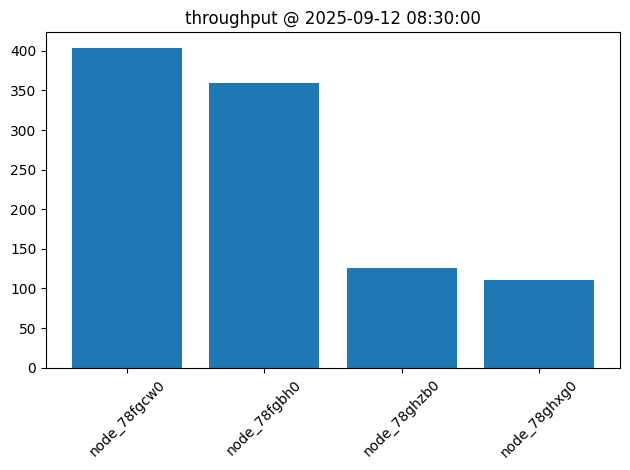


📊 Metric: iops
           entity_id    value     share
515112  node_78fgcw0  7425.25  0.564851
515105  node_78fgbh0  3288.25  0.250143
515119  node_78ghxg0  1524.00  0.115933
515126  node_78ghzb0   908.00  0.069073


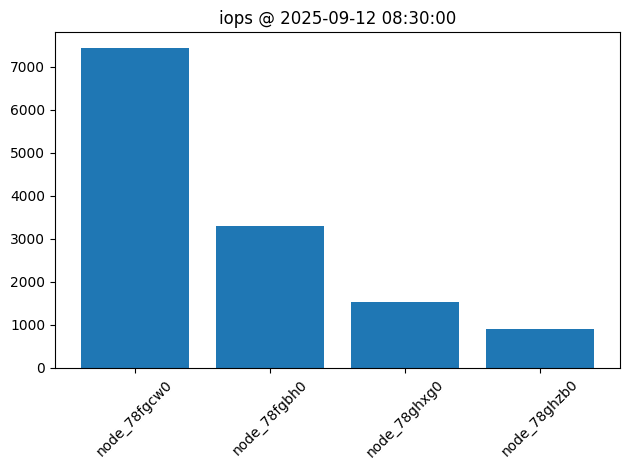


📊 Metric: latency
           entity_id  value     share
515106  node_78fgbh0    6.5  0.928571
515127  node_78ghzb0    0.5  0.071429
515113  node_78fgcw0    0.0  0.000000
515120  node_78ghxg0    0.0  0.000000


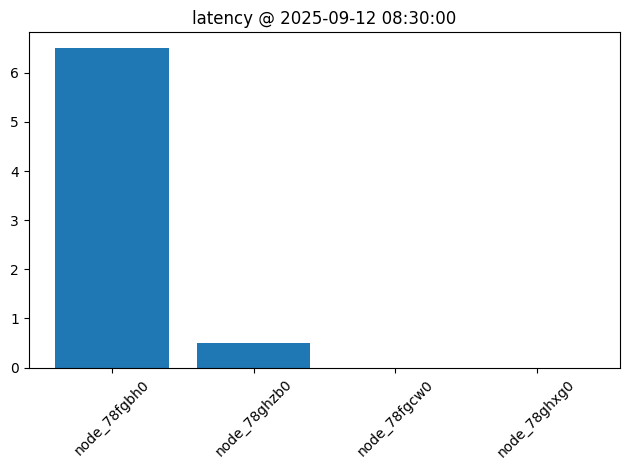


📉 IMBALANCE METRICS
                                 metric     value
198130                   imb_gini__iops  0.405386
198131                    imb_hhi__iops  0.399840
198132        imb_norm_top1_share__iops  0.419801
198133                  imb_theil__iops  0.282617
198134             imb_top1_share__iops  0.564851
198135                imb_gini__latency  0.714286
198136                 imb_hhi__latency  0.867347
198137     imb_norm_top1_share__latency  0.904762
198138               imb_theil__latency  2.257951
198139          imb_top1_share__latency  0.928571
198140             imb_gini__throughput  0.277757
198141              imb_hhi__throughput  0.320325
198142  imb_norm_top1_share__throughput  0.204468
198143            imb_theil__throughput  0.147474
198144       imb_top1_share__throughput  0.403351

🧠 INTERPRETATION
throughput: Top1 share = 0.403
iops: Top1 share = 0.565
latency: Top1 share = 0.929

👉 판단 기준:
- > 0.5  : 매우 강한 hotspot
- 0.3~0.5: 중간 hotspot
- < 0.3  : 약한 or noi

In [61]:
# ============================================================
# 🔥 BLOCK 7-E: LEARNED HOTSPOT RAW VALIDATION (FINAL)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========= [설정] =========
TOPK = 10
SHOW_PLOT = True

# ========= [0] sanity check =========
required_cols = ["timestamp","stg_ip","level","rw","src_metric","score_learned","score_learned_hot"]
for c in required_cols:
    if c not in point_score_df.columns:
        raise ValueError(f"❌ point_score_df missing column: {c}")

# ========= [1] learned hotspot 선택 =========
df_hot = point_score_df[
    (point_score_df["score_learned_hot"] == 1)
].copy()

if df_hot.empty:
    raise RuntimeError("❌ learned hotspot이 없음")

# 가장 강한 hotspot 선택
row = df_hot.sort_values("score_learned", ascending=False).iloc[0]

peak_ts = pd.to_datetime(row["timestamp"])
stg_ip  = str(row["stg_ip"]).lower()
level   = str(row["level"]).lower()
rw      = str(row["rw"]).lower()
src_metric = str(row["src_metric"]).lower()

print("\n==============================")
print("🎯 SELECTED LEARNED HOTSPOT")
print("==============================")
print(f"timestamp : {peak_ts}")
print(f"stg_ip    : {stg_ip}")
print(f"level     : {level}")
print(f"rw        : {rw}")
print(f"src_metric: {src_metric}")
print(f"score     : {row['score_learned']:.4f}")

# ========= [2] timestamp 정합 보정 =========
ts_list = project_long["timestamp"].drop_duplicates().sort_values()

if peak_ts not in set(ts_list):
    print("\n⚠️ timestamp mismatch → nearest match 사용")
    peak_ts = ts_list.iloc[(ts_list - peak_ts).abs().argmin()]

print(f"✅ aligned timestamp: {peak_ts}")

# ========= [3] RAW DATA 추출 =========
metrics = ["throughput", "iops", "latency", "cpu"]

df_peak = project_long[
    (project_long["timestamp"] == peak_ts) &
    (project_long["stg_ip"] == stg_ip) &
    (project_long["level"] == level) &
    (project_long["rw"] == rw) &
    (project_long["metric"].isin(metrics))
].copy()

print("\n==============================")
print("📦 RAW DATA")
print("==============================")
print("rows:", len(df_peak))

if df_peak.empty:
    raise RuntimeError("❌ raw data 없음 → 조건 mismatch")

# ========= [4] METRIC별 분석 =========
all_results = []

for m in metrics:
    tmp = df_peak[df_peak["metric"] == m].copy()

    if tmp.empty:
        continue

    tmp = tmp.sort_values("value", ascending=False)

    total = tmp["value"].sum()
    tmp["share"] = tmp["value"] / total if total > 0 else 0

    print("\n==============================")
    print(f"📊 Metric: {m}")
    print("==============================")
    print(tmp[["entity_id","value","share"]].head(TOPK))

    # 저장
    tmp["metric"] = m
    all_results.append(tmp.head(TOPK))

    # ========= [시각화] =========
    if SHOW_PLOT:
        plt.figure()
        plt.bar(tmp["entity_id"][:TOPK], tmp["value"][:TOPK])
        plt.xticks(rotation=45)
        plt.title(f"{m} @ {peak_ts}")
        plt.tight_layout()
        plt.show()

# ========= [5] IMBALANCE METRIC 확인 =========
imb_peak = imb_long[
    (imb_long["timestamp"] == peak_ts) &
    (imb_long["stg_ip"] == stg_ip) &
    (imb_long["level"] == level) &
    (imb_long["rw"] == rw)
]

print("\n==============================")
print("📉 IMBALANCE METRICS")
print("==============================")

if not imb_peak.empty:
    print(imb_peak[["metric","value"]])
else:
    print("❌ imbalance 없음")

# ========= [6] 자동 해석 =========
print("\n==============================")
print("🧠 INTERPRETATION")
print("==============================")

interpret_rows = []

for m in metrics:
    tmp = df_peak[df_peak["metric"] == m]
    if tmp.empty:
        continue

    tmp = tmp.sort_values("value", ascending=False)

    top1 = tmp.iloc[0]["value"]
    total = tmp["value"].sum()
    share = top1 / total if total > 0 else 0

    interpret_rows.append({
        "metric": m,
        "top1_share": share
    })

    print(f"{m}: Top1 share = {share:.3f}")

# ========= [7] 판단 =========
print("\n👉 판단 기준:")
print("- > 0.5  : 매우 강한 hotspot")
print("- 0.3~0.5: 중간 hotspot")
print("- < 0.3  : 약한 or noise")

# ========= [8] trigger metric 강조 =========
trigger_row = [r for r in interpret_rows if r["metric"] == src_metric]

if trigger_row:
    trigger_share = trigger_row[0]["top1_share"]

    print("\n==============================")
    print("🔥 TRIGGER METRIC ANALYSIS")
    print("==============================")
    print(f"trigger metric: {src_metric}")
    print(f"top1 share   : {trigger_share:.3f}")

    if trigger_share > 0.5:
        print("👉 매우 강한 쏠림 → TRUE hotspot 가능성 높음")
    elif trigger_share > 0.3:
        print("👉 중간 수준 쏠림")
    else:
        print("👉 약함 → learned 모델이 noise 잡았을 가능성")

# ========= [9] 결과 dataframe =========
result_df = pd.DataFrame(interpret_rows)
result_df["timestamp"] = peak_ts
result_df["stg_ip"] = stg_ip
result_df["level"] = level
result_df["rw"] = rw
result_df["src_metric"] = src_metric

print("\n==============================")
print("📋 SUMMARY TABLE")
print("==============================")
print(result_df)

# ========= [10] 저장 (optional) =========
try:
    result_df.to_excel(OUTPUT_DIR / "DEBUG_LEARNED_HOTSPOT_RAW_CHECK.xlsx", index=False)
    print("\n✅ saved debug result")
except:
    pass

# BLOCK 7-F)  LEARNED ONLY VALIDATION (자동 검증 + 통계)
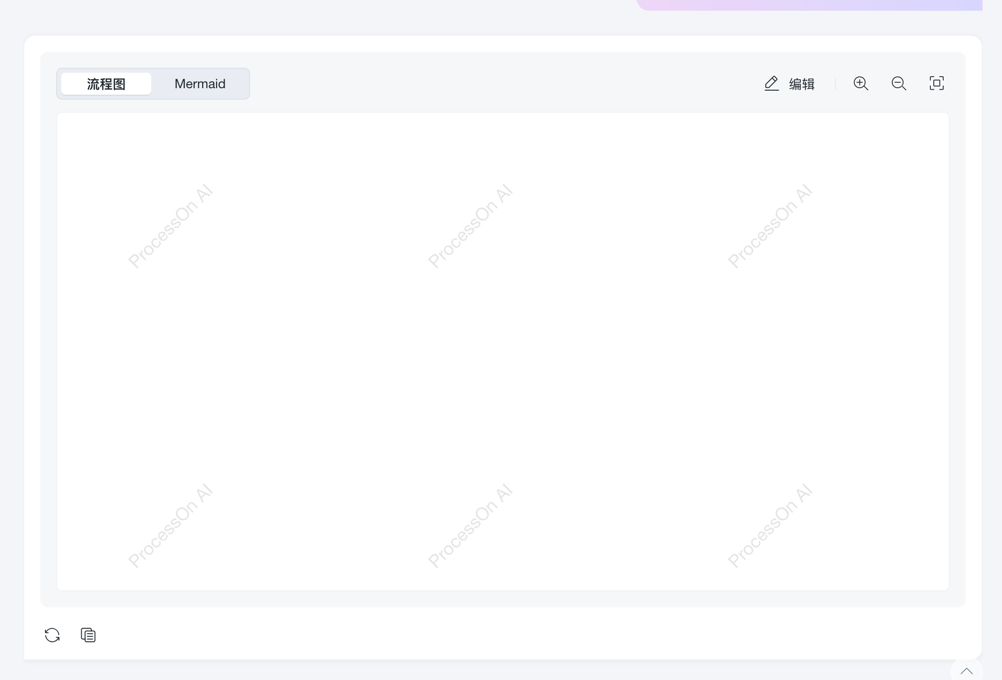

In [66]:
# BLOCK 7-F) LEARNED ONLY VALIDATION (MULTI-METRIC VERSION)
# ============================================================
# 🔥 BLOCK 7-F: LEARNED ONLY VALIDATION (MULTI-METRIC)
# - learned_only 샘플링
# - raw throughput / iops / latency 기반 검증
# - metric별 top1 share + 종합 score 계산
# - strong / medium / weak_or_noise 자동 분류
# ============================================================

import pandas as pd
import numpy as np

# ============================================================
# [0] 설정
# ============================================================
N_TOP = 10
N_RANDOM = 10
RANDOM_STATE = 42

VALIDATION_METRICS = ["throughput", "iops", "latency"]

# metric별 share threshold
# strong: 특정 노드/포트 쏠림이 매우 강함
# medium: 눈에 띄는 쏠림 존재
TOP1_SHARE_STRONG_TH = 0.70
TOP1_SHARE_MEDIUM_TH = 0.40

# support signal:
# top2/top1 격차가 크면 "상위 1개가 압도한다"는 뜻
TOP12_GAP_STRONG_TH = 0.25
TOP12_GAP_MEDIUM_TH = 0.10

# 최종 종합판정 threshold
# metric별 점수 strong=2, medium=1, weak=0
# 예:
#   latency strong + iops medium = 3점 → strong
#   2개 metric이 medium = 2점 → medium
FINAL_STRONG_SCORE_TH = 3
FINAL_MEDIUM_SCORE_TH = 2

# ============================================================
# [1] learned_only 추출
# ============================================================
required_objs = ["point_score_df", "project_long"]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"❌ required object not found: {obj_name}")

df_learned_only = point_score_df[
    (point_score_df["score_learned_hot"] == 1) &
    (point_score_df["original_hot"] == 0)
    ].copy()

print("\n==============================")
print("📌 LEARNED ONLY COUNT")
print("==============================")
print(f"total learned_only points: {len(df_learned_only)}")

if df_learned_only.empty:
    raise RuntimeError("❌ learned_only 없음")

# ============================================================
# [2] 샘플링
# ============================================================
if "score_learned" in df_learned_only.columns:
    df_top = df_learned_only.sort_values("score_learned", ascending=False).head(N_TOP)
else:
    print("⚠️ 'score_learned' column not found → top sample 없이 random만 사용")
    df_top = df_learned_only.head(0).copy()

df_rand = df_learned_only.sample(
    min(N_RANDOM, len(df_learned_only)),
    random_state=RANDOM_STATE
)

df_samples = (
    pd.concat([df_top, df_rand], axis=0)
    .drop_duplicates(subset=["timestamp", "stg_ip", "level", "rw"])
    .reset_index(drop=True)
)

print("\n==============================")
print("📌 SAMPLE SIZE")
print("==============================")
print(len(df_samples))

if df_samples.empty:
    raise RuntimeError("❌ validation sample이 비어 있음")

# ============================================================
# [3] helper 함수
# ============================================================
project_long = project_long.copy()
project_long["timestamp"] = pd.to_datetime(project_long["timestamp"], errors="coerce")
project_long["metric"] = project_long["metric"].astype(str).str.strip().str.lower()
project_long["level"] = project_long["level"].astype(str).str.strip().str.lower()
project_long["rw"] = project_long["rw"].astype(str).str.strip().str.lower()
project_long["stg_ip"] = project_long["stg_ip"].astype(str).str.strip().str.lower()

ts_list = project_long["timestamp"].dropna().drop_duplicates().sort_values().reset_index(drop=True)
ts_set = set(ts_list)


def classify_one_metric(top1_share, top12_gap):
    """
    metric 단위 판정:
    strong = share와 top1-top2 격차가 둘 다 매우 큼
    medium = 둘 중 하나라도 일정 수준 이상
    weak   = 나머지
    """
    if pd.isna(top1_share):
        return "no_data", 0

    if (top1_share >= TOP1_SHARE_STRONG_TH) or (top12_gap >= TOP12_GAP_STRONG_TH):
        return "strong", 2
    elif (top1_share >= TOP1_SHARE_MEDIUM_TH) or (top12_gap >= TOP12_GAP_MEDIUM_TH):
        return "medium", 1
    else:
        return "weak", 0


def classify_final(total_score, n_metric_medium_plus, n_metric_strong):
    """
    최종 종합 판정:
    - strong metric이 1개라도 있거나
    - 총점이 충분히 높으면 strong
    - medium 이상 metric이 2개 이상이거나
    - 총점이 일정 수준이면 medium
    """
    if (n_metric_strong >= 1) or (total_score >= FINAL_STRONG_SCORE_TH):
        return "strong"
    elif (n_metric_medium_plus >= 2) or (total_score >= FINAL_MEDIUM_SCORE_TH):
        return "medium"
    else:
        return "weak_or_noise"


def summarize_metric_distribution(df_metric):
    """
    하나의 metric 분포 요약
    """
    if df_metric.empty:
        return {
            "n_entities": 0,
            "total": np.nan,
            "top1_value": np.nan,
            "top2_value": np.nan,
            "top1_entity": None,
            "top2_entity": None,
            "top1_share": np.nan,
            "top2_share": np.nan,
            "top12_gap": np.nan
        }

    tmp = df_metric.copy()
    tmp["value"] = pd.to_numeric(tmp["value"], errors="coerce")
    tmp = tmp.dropna(subset=["value"]).sort_values("value", ascending=False).reset_index(drop=True)

    if tmp.empty:
        return {
            "n_entities": 0,
            "total": np.nan,
            "top1_value": np.nan,
            "top2_value": np.nan,
            "top1_entity": None,
            "top2_entity": None,
            "top1_share": np.nan,
            "top2_share": np.nan,
            "top12_gap": np.nan
        }

    total = float(tmp["value"].sum())
    n_entities = int(len(tmp))

    top1_value = float(tmp.iloc[0]["value"])
    top1_entity = str(tmp.iloc[0]["entity_id"]) if "entity_id" in tmp.columns else None
    top1_share = top1_value / total if total > 0 else np.nan

    if len(tmp) >= 2:
        top2_value = float(tmp.iloc[1]["value"])
        top2_entity = str(tmp.iloc[1]["entity_id"]) if "entity_id" in tmp.columns else None
        top2_share = top2_value / total if total > 0 else np.nan
    else:
        top2_value = np.nan
        top2_entity = None
        top2_share = np.nan

    top12_gap = (
        (top1_share - top2_share)
        if (not pd.isna(top1_share) and not pd.isna(top2_share))
        else top1_share
    )

    return {
        "n_entities": n_entities,
        "total": total,
        "top1_value": top1_value,
        "top2_value": top2_value,
        "top1_entity": top1_entity,
        "top2_entity": top2_entity,
        "top1_share": top1_share,
        "top2_share": top2_share,
        "top12_gap": top12_gap
    }


# ============================================================
# [4] multi-metric validation
# ============================================================
results = []

for _, row in df_samples.iterrows():

    peak_ts = pd.to_datetime(row["timestamp"], errors="coerce")
    stg_ip = str(row["stg_ip"]).strip().lower()
    level = str(row["level"]).strip().lower()
    rw = str(row["rw"]).strip().lower()

    if pd.isna(peak_ts):
        continue

    # timestamp 보정
    if peak_ts not in ts_set:
        peak_ts = ts_list.iloc[(ts_list - peak_ts).abs().argmin()]

    df_peak = project_long[
        (project_long["timestamp"] == peak_ts) &
        (project_long["stg_ip"] == stg_ip) &
        (project_long["level"] == level) &
        (project_long["rw"] == rw)
        ].copy()

    if df_peak.empty:
        continue

    one_row = {
        "timestamp": peak_ts,
        "stg_ip": stg_ip,
        "level": level,
        "rw": rw
    }

    total_score = 0
    n_metric_available = 0
    n_metric_strong = 0
    n_metric_medium = 0
    n_metric_medium_plus = 0

    best_metric = None
    best_metric_share = -np.inf

    for m in VALIDATION_METRICS:
        df_m = df_peak[df_peak["metric"] == m].copy()
        stat = summarize_metric_distribution(df_m)

        metric_label, metric_score = classify_one_metric(
            top1_share=stat["top1_share"],
            top12_gap=stat["top12_gap"]
        )

        one_row[f"{m}_n_entities"] = stat["n_entities"]
        one_row[f"{m}_total"] = stat["total"]
        one_row[f"{m}_top1_value"] = stat["top1_value"]
        one_row[f"{m}_top2_value"] = stat["top2_value"]
        one_row[f"{m}_top1_entity"] = stat["top1_entity"]
        one_row[f"{m}_top2_entity"] = stat["top2_entity"]
        one_row[f"{m}_top1_share"] = stat["top1_share"]
        one_row[f"{m}_top2_share"] = stat["top2_share"]
        one_row[f"{m}_top12_gap"] = stat["top12_gap"]
        one_row[f"{m}_label"] = metric_label
        one_row[f"{m}_score"] = metric_score

        if metric_label != "no_data":
            n_metric_available += 1
            total_score += metric_score

            if metric_label == "strong":
                n_metric_strong += 1
                n_metric_medium_plus += 1
            elif metric_label == "medium":
                n_metric_medium += 1
                n_metric_medium_plus += 1

            share_for_best = stat["top1_share"]
            if not pd.isna(share_for_best) and share_for_best > best_metric_share:
                best_metric_share = share_for_best
                best_metric = m

    final_label = classify_final(
        total_score=total_score,
        n_metric_medium_plus=n_metric_medium_plus,
        n_metric_strong=n_metric_strong
    )

    one_row["validation_score"] = total_score
    one_row["n_metric_available"] = n_metric_available
    one_row["n_metric_strong"] = n_metric_strong
    one_row["n_metric_medium"] = n_metric_medium
    one_row["n_metric_medium_plus"] = n_metric_medium_plus
    one_row["best_metric"] = best_metric
    one_row["best_metric_share"] = np.nan if best_metric is None else best_metric_share
    one_row["label"] = final_label

    results.append(one_row)

df_validation = pd.DataFrame(results)

if df_validation.empty:
    raise RuntimeError("❌ df_validation이 비어 있습니다. project_long / sample 조건을 확인하세요.")

# ============================================================
# [5] 결과 출력
# ============================================================
print("\n==============================")
print("📊 VALIDATION RESULT")
print("==============================")
display_cols = [
    "timestamp", "stg_ip", "level", "rw",
    "validation_score", "n_metric_available",
    "n_metric_strong", "n_metric_medium_plus",
    "best_metric", "best_metric_share", "label"
]
print(df_validation[display_cols].head(10))

# ============================================================
# [6] 통계
# ============================================================
summary = df_validation["label"].value_counts()
ratio = df_validation["label"].value_counts(normalize=True)

print("\n==============================")
print("📊 VALIDATION SUMMARY (COUNT)")
print("==============================")
print(summary)

print("\n==============================")
print("📊 VALIDATION SUMMARY (RATIO)")
print("==============================")
print(ratio)

# metric별 strong/medium 비율도 추가 요약
metric_summary_rows = []
for m in VALIDATION_METRICS:
    vc = df_validation[f"{m}_label"].value_counts(normalize=True)
    metric_summary_rows.append({
        "metric": m,
        "strong_ratio": vc.get("strong", 0.0),
        "medium_ratio": vc.get("medium", 0.0),
        "weak_ratio": vc.get("weak", 0.0),
        "no_data_ratio": vc.get("no_data", 0.0),
        "medium_plus_ratio": vc.get("strong", 0.0) + vc.get("medium", 0.0)
    })

metric_validation_summary = pd.DataFrame(metric_summary_rows)

print("\n==============================")
print("📊 METRIC-WISE VALIDATION SUMMARY")
print("==============================")
print(metric_validation_summary)

# ============================================================
# [7] 핵심 지표
# ============================================================
strong_ratio = ratio.get("strong", 0)
medium_ratio = ratio.get("medium", 0)
weak_ratio = ratio.get("weak_or_noise", 0)

print("\n==============================")
print("🔥 FINAL INTERPRETATION")
print("==============================")
print(f"strong ratio      : {strong_ratio:.3f}")
print(f"medium ratio      : {medium_ratio:.3f}")
print(f"weak/noise ratio  : {weak_ratio:.3f}")
print(f"strong+medium     : {(strong_ratio + medium_ratio):.3f}")
print(f"avg val score     : {df_validation['validation_score'].mean():.3f}")
print(f"avg metric avail  : {df_validation['n_metric_available'].mean():.3f}")
print(f"avg medium+ count : {df_validation['n_metric_medium_plus'].mean():.3f}")


📌 LEARNED ONLY COUNT
total learned_only points: 4243

📌 SAMPLE SIZE
20

📊 VALIDATION RESULT
            timestamp                            stg_ip level     rw  \
0 2025-09-12 08:30:00  96353914610fbf899a486bbc516a0fcb  node  write   
1 2025-09-10 02:30:00  96353914610fbf899a486bbc516a0fcb  node  write   
2 2025-10-31 21:30:00  96353914610fbf899a486bbc516a0fcb  node  write   
3 2025-11-02 07:30:00  96353914610fbf899a486bbc516a0fcb  node  write   
4 2025-10-27 11:30:00  96353914610fbf899a486bbc516a0fcb  node  write   
5 2025-09-14 05:30:00  96353914610fbf899a486bbc516a0fcb  node  write   
6 2025-09-29 22:30:00  96353914610fbf899a486bbc516a0fcb  node  write   
7 2025-11-05 20:30:00  96353914610fbf899a486bbc516a0fcb  node  write   
8 2025-10-29 22:00:00  96353914610fbf899a486bbc516a0fcb  node  write   
9 2025-11-02 04:30:00  96353914610fbf899a486bbc516a0fcb  node  write   

   validation_score  n_metric_available  n_metric_strong  \
0                 5                   3               

# BLOCK 7-G) FINAL VALIDATION FIGURE (MULTI-METRIC VERSION, SHOW ONLY)

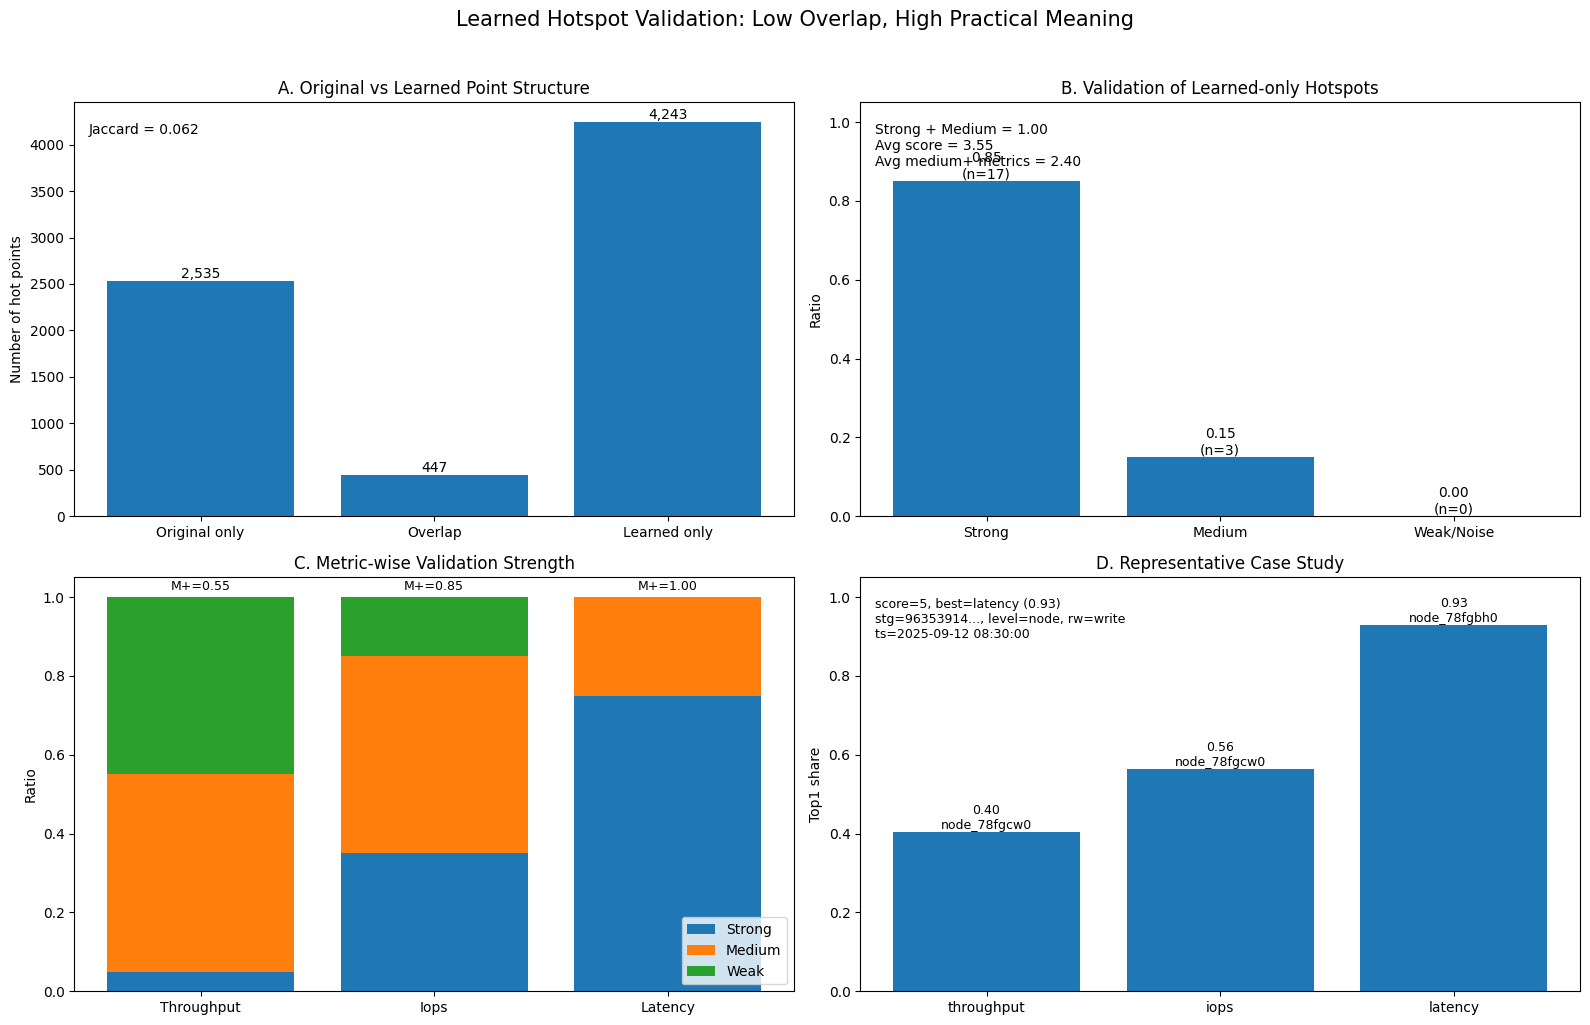


PANEL A DATA
        category  count
0  Original only   2535
1        Overlap    447
2   Learned only   4243

PANEL B DATA
        label  ratio  count
0      Strong   0.85     17
1      Medium   0.15      3
2  Weak/Noise   0.00      0

PANEL C DATA
       metric  strong_ratio  medium_ratio  weak_ratio  no_data_ratio  \
0  throughput          0.05          0.50        0.45            0.0   
1        iops          0.35          0.50        0.15            0.0   
2     latency          0.75          0.25        0.00            0.0   

   medium_plus_ratio  
0               0.55  
1               0.85  
2               1.00  

PANEL D DATA
       metric  top1_share   top1_entity  top1_value
0  throughput    0.403351  node_78fgcw0      403.25
1        iops    0.564851  node_78fgcw0     7425.25
2     latency    0.928571  node_78fgbh0        6.50


In [67]:
# BLOCK 7-G) FINAL VALIDATION FIGURE (MULTI-METRIC VERSION, SHOW ONLY)
# ============================================================
# 🔥 BLOCK 7-G: FINAL VALIDATION FIGURE (MULTI-METRIC)
# - 저장하지 않고 화면에만 출력
# - Panel A: Original vs Learned overlap structure
# - Panel B: Learned-only validation summary
# - Panel C: Metric-wise validation strength
# - Panel D: Representative case study
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) sanity check
# ------------------------------------------------------------
required_objs = ["point_compare_df", "df_validation", "project_long"]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"❌ required object not found: {obj_name}")

if df_validation.empty:
    raise ValueError("❌ df_validation이 비어 있습니다. BLOCK 7-F를 먼저 실행하세요.")

# ------------------------------------------------------------
# 1) Panel A data: Original vs Learned overlap structure
# ------------------------------------------------------------
pc = point_compare_df.copy()
pc["method"] = pc["method"].astype(str).str.strip().str.lower()

learned_row = pc[pc["method"] == "learned"]
if learned_row.empty:
    raise ValueError("❌ point_compare_df 안에 method='learned'가 없습니다.")

learned_row = learned_row.iloc[0]

n_overlap = int(learned_row["overlap_points"])
n_learned_only = int(learned_row["new_only_points"])
n_original_only = int(learned_row["missed_original_points"])
jaccard_val = float(learned_row["jaccard_vs_original"])

panelA_labels = ["Original only", "Overlap", "Learned only"]
panelA_values = [n_original_only, n_overlap, n_learned_only]

# ------------------------------------------------------------
# 2) Panel B data: final validation summary
# ------------------------------------------------------------
val = df_validation.copy()
val["label"] = val["label"].astype(str).str.strip().str.lower()

label_order = ["strong", "medium", "weak_or_noise"]
label_counts = val["label"].value_counts().reindex(label_order, fill_value=0)
label_ratios = (label_counts / max(label_counts.sum(), 1)).fillna(0.0)

panelB_labels = ["Strong", "Medium", "Weak/Noise"]
panelB_values = [
    label_ratios.get("strong", 0.0),
    label_ratios.get("medium", 0.0),
    label_ratios.get("weak_or_noise", 0.0)
]

strong_plus_medium = panelB_values[0] + panelB_values[1]
avg_val_score = float(val["validation_score"].mean()) if "validation_score" in val.columns else np.nan
avg_medium_plus = float(val["n_metric_medium_plus"].mean()) if "n_metric_medium_plus" in val.columns else np.nan

# ------------------------------------------------------------
# 3) Panel C data: metric-wise validation summary
# ------------------------------------------------------------
metrics = ["throughput", "iops", "latency"]

metric_rows = []
for m in metrics:
    col = f"{m}_label"
    if col not in val.columns:
        raise ValueError(f"❌ required column missing: {col}")

    vc = val[col].astype(str).str.strip().str.lower().value_counts(normalize=True)

    metric_rows.append({
        "metric": m,
        "strong_ratio": vc.get("strong", 0.0),
        "medium_ratio": vc.get("medium", 0.0),
        "weak_ratio": vc.get("weak", 0.0),
        "no_data_ratio": vc.get("no_data", 0.0),
        "medium_plus_ratio": vc.get("strong", 0.0) + vc.get("medium", 0.0)
    })

metric_validation_summary = pd.DataFrame(metric_rows)

# ------------------------------------------------------------
# 4) Panel D data: representative case study
#    대표 케이스 = validation_score 가장 높고,
#    동점이면 best_metric_share가 높은 것
# ------------------------------------------------------------
sort_cols = []
ascending_list = []

if "validation_score" in val.columns:
    sort_cols.append("validation_score")
    ascending_list.append(False)

if "best_metric_share" in val.columns:
    sort_cols.append("best_metric_share")
    ascending_list.append(False)

sort_cols.append("timestamp")
ascending_list.append(True)

val_case = val.sort_values(sort_cols, ascending=ascending_list).iloc[0]

case_ts = pd.to_datetime(val_case["timestamp"])
case_stg = str(val_case["stg_ip"]).lower()
case_level = str(val_case["level"]).lower()
case_rw = str(val_case["rw"]).lower()

project_long = project_long.copy()
project_long["timestamp"] = pd.to_datetime(project_long["timestamp"], errors="coerce")
project_long["stg_ip"] = project_long["stg_ip"].astype(str).str.strip().str.lower()
project_long["level"] = project_long["level"].astype(str).str.strip().str.lower()
project_long["rw"] = project_long["rw"].astype(str).str.strip().str.lower()
project_long["metric"] = project_long["metric"].astype(str).str.strip().str.lower()

ts_list = project_long["timestamp"].dropna().drop_duplicates().sort_values().reset_index(drop=True)
ts_set = set(ts_list)

if case_ts not in ts_set:
    case_ts = ts_list.iloc[(ts_list - case_ts).abs().argmin()]

case_rows = []
for m in metrics:
    tmp = project_long[
        (project_long["timestamp"] == case_ts) &
        (project_long["stg_ip"] == case_stg) &
        (project_long["level"] == case_level) &
        (project_long["rw"] == case_rw) &
        (project_long["metric"] == m)
        ].copy()

    if tmp.empty:
        case_rows.append({
            "metric": m,
            "top1_share": np.nan,
            "top1_entity": "N/A",
            "top1_value": np.nan
        })
        continue

    tmp["value"] = pd.to_numeric(tmp["value"], errors="coerce")
    tmp = tmp.dropna(subset=["value"]).sort_values("value", ascending=False)

    total = float(tmp["value"].sum())
    top1_value = float(tmp.iloc[0]["value"])
    top1_share = top1_value / total if total > 0 else np.nan
    top1_entity = str(tmp.iloc[0]["entity_id"]) if "entity_id" in tmp.columns else "N/A"

    case_rows.append({
        "metric": m,
        "top1_share": top1_share,
        "top1_entity": top1_entity,
        "top1_value": top1_value
    })

case_df = pd.DataFrame(case_rows)

# ------------------------------------------------------------
# 5) figure drawing
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# ---------------- Panel A ----------------
ax = axes[0]
barsA = ax.bar(panelA_labels, panelA_values)
ax.set_title("A. Original vs Learned Point Structure")
ax.set_ylabel("Number of hot points")

for b, v in zip(barsA, panelA_values):
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height(),
        f"{v:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.text(
    0.02, 0.95,
    f"Jaccard = {jaccard_val:.3f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10
)

# ---------------- Panel B ----------------
ax = axes[1]
barsB = ax.bar(panelB_labels, panelB_values)
ax.set_title("B. Validation of Learned-only Hotspots")
ax.set_ylabel("Ratio")
ax.set_ylim(0, 1.05)

for b, ratio_val, cnt_val in zip(barsB, panelB_values, label_counts.values):
    ax.text(
        b.get_x() + b.get_width() / 2,
        b.get_height(),
        f"{ratio_val:.2f}\n(n={cnt_val})",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.text(
    0.02, 0.95,
    f"Strong + Medium = {strong_plus_medium:.2f}\n"
    f"Avg score = {avg_val_score:.2f}\n"
    f"Avg medium+ metrics = {avg_medium_plus:.2f}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10
)

# ---------------- Panel C ----------------
ax = axes[2]

x = np.arange(len(metrics))
strong_vals = metric_validation_summary["strong_ratio"].values
medium_vals = metric_validation_summary["medium_ratio"].values
weak_vals = metric_validation_summary["weak_ratio"].values

bars_strong = ax.bar(x, strong_vals, label="Strong")
bars_medium = ax.bar(x, medium_vals, bottom=strong_vals, label="Medium")
bars_weak = ax.bar(x, weak_vals, bottom=(strong_vals + medium_vals), label="Weak")

ax.set_title("C. Metric-wise Validation Strength")
ax.set_ylabel("Ratio")
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics])
ax.set_ylim(0, 1.05)
ax.legend()

for i, row in metric_validation_summary.iterrows():
    ax.text(
        i,
        1.01,
        f"M+={row['medium_plus_ratio']:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# ---------------- Panel D ----------------
ax = axes[3]
barsD = ax.bar(case_df["metric"], case_df["top1_share"])
ax.set_title("D. Representative Case Study")
ax.set_ylabel("Top1 share")
ax.set_ylim(0, 1.05)

for _, r in case_df.iterrows():
    metric_name = r["metric"]
    y = r["top1_share"]

    if pd.isna(y):
        continue

    x_pos = list(case_df["metric"]).index(metric_name)
    txt = f"{r['top1_share']:.2f}\n{r['top1_entity']}"
    ax.text(
        x_pos,
        y,
        txt,
        ha="center",
        va="bottom",
        fontsize=9
    )

case_title = (
    f"score={val_case['validation_score']}, "
    f"best={val_case['best_metric']} ({val_case['best_metric_share']:.2f})\n"
    f"stg={case_stg[:8]}..., level={case_level}, rw={case_rw}\n"
    f"ts={str(case_ts)}"
)
ax.text(
    0.02, 0.95,
    case_title,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9
)

fig.suptitle(
    "Learned Hotspot Validation: Low Overlap, High Practical Meaning",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6) source table display only
# ------------------------------------------------------------
panelA_df = pd.DataFrame({
    "category": panelA_labels,
    "count": panelA_values
})

panelB_df = pd.DataFrame({
    "label": panelB_labels,
    "ratio": panelB_values,
    "count": label_counts.values
})

print("\n==============================")
print("PANEL A DATA")
print("==============================")
print(panelA_df)

print("\n==============================")
print("PANEL B DATA")
print("==============================")
print(panelB_df)

print("\n==============================")
print("PANEL C DATA")
print("==============================")
print(metric_validation_summary)

print("\n==============================")
print("PANEL D DATA")
print("==============================")
print(case_df)


🎯 REPRESENTATIVE CASE
timestamp : 2025-09-12 08:30:00
stg_ip    : 96353914610fbf899a486bbc516a0fcb
level     : node
rw        : write
lat_share : 0.929


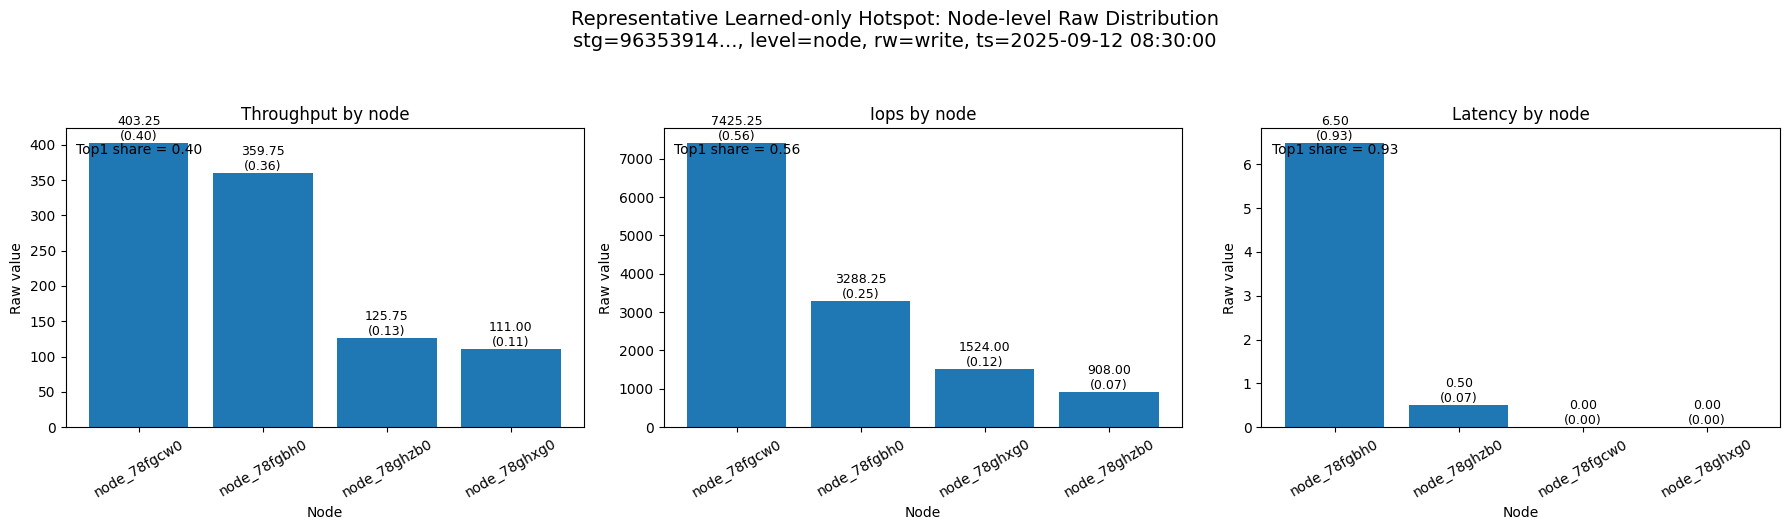


THROUGHPUT TABLE
      entity_id   value     share
0  node_78fgcw0  403.25  0.403351
1  node_78fgbh0  359.75  0.359840
2  node_78ghzb0  125.75  0.125781
3  node_78ghxg0  111.00  0.111028

IOPS TABLE
      entity_id    value     share
0  node_78fgcw0  7425.25  0.564851
1  node_78fgbh0  3288.25  0.250143
2  node_78ghxg0  1524.00  0.115933
3  node_78ghzb0   908.00  0.069073

LATENCY TABLE
      entity_id  value     share
0  node_78fgbh0    6.5  0.928571
1  node_78ghzb0    0.5  0.071429
2  node_78fgcw0    0.0  0.000000
3  node_78ghxg0    0.0  0.000000


In [65]:
# ============================================================
# 🔥 BLOCK 7-H: REPRESENTATIVE CASE RAW DISTRIBUTION (SHOW ONLY)
# - 대표 learned-only case 1개 선택
# - node-level raw values를 metric별로 비교
# - throughput / iops / latency 3개 패널
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) sanity check
# ------------------------------------------------------------
required_objs = ["df_validation", "project_long"]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"❌ required object not found: {obj_name}")

if df_validation.empty:
    raise ValueError("❌ df_validation이 비어 있습니다. BLOCK 7-F를 먼저 실행하세요.")

# ------------------------------------------------------------
# 1) 대표 case 선택
#    - latency_top1_share가 가장 높은 case
# ------------------------------------------------------------
val_case = df_validation.sort_values(
    ["latency_top1_share", "timestamp"],
    ascending=[False, True]
).iloc[0]

case_ts = pd.to_datetime(val_case["timestamp"])
case_stg = str(val_case["stg_ip"]).lower()
case_level = str(val_case["level"]).lower()
case_rw = str(val_case["rw"]).lower()

# timestamp 보정
project_long["timestamp"] = pd.to_datetime(project_long["timestamp"], errors="coerce")
ts_list = project_long["timestamp"].dropna().drop_duplicates().sort_values()

if case_ts not in set(ts_list):
    case_ts = ts_list.iloc[(ts_list - case_ts).abs().argmin()]

print("\n==============================")
print("🎯 REPRESENTATIVE CASE")
print("==============================")
print(f"timestamp : {case_ts}")
print(f"stg_ip    : {case_stg}")
print(f"level     : {case_level}")
print(f"rw        : {case_rw}")
print(f"lat_share : {val_case['latency_top1_share']:.3f}")

# ------------------------------------------------------------
# 2) metric별 raw table 만들기
# ------------------------------------------------------------
metrics = ["throughput", "iops", "latency"]
metric_tables = {}

for m in metrics:
    tmp = project_long[
        (project_long["timestamp"] == case_ts) &
        (project_long["stg_ip"].astype(str).str.lower() == case_stg) &
        (project_long["level"].astype(str).str.lower() == case_level) &
        (project_long["rw"].astype(str).str.lower() == case_rw) &
        (project_long["metric"].astype(str).str.lower() == m)
    ].copy()

    if tmp.empty:
        metric_tables[m] = pd.DataFrame(columns=["entity_id", "value", "share"])
        continue

    tmp["value"] = pd.to_numeric(tmp["value"], errors="coerce")
    tmp = tmp.dropna(subset=["value"]).sort_values("value", ascending=False).copy()

    total = float(tmp["value"].sum())
    tmp["share"] = tmp["value"] / total if total > 0 else 0.0

    metric_tables[m] = tmp[["entity_id", "value", "share"]].reset_index(drop=True)

# ------------------------------------------------------------
# 3) figure
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, m in zip(axes, metrics):
    tmp = metric_tables[m].copy()

    if tmp.empty:
        ax.set_title(f"{m} (no data)")
        ax.axis("off")
        continue

    x = tmp["entity_id"].astype(str).tolist()
    y = tmp["value"].astype(float).tolist()
    bars = ax.bar(x, y)

    ax.set_title(f"{m.capitalize()} by node")
    ax.set_xlabel("Node")
    ax.set_ylabel("Raw value")
    ax.tick_params(axis="x", rotation=30)

    # top1 share 표시
    top1_share = float(tmp.iloc[0]["share"]) if len(tmp) > 0 else np.nan
    ax.text(
        0.02, 0.95,
        f"Top1 share = {top1_share:.2f}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10
    )

    # 각 막대 위 value + share 표시
    for b, (_, row) in zip(bars, tmp.iterrows()):
        ax.text(
            b.get_x() + b.get_width()/2,
            b.get_height(),
            f"{row['value']:.2f}\n({row['share']:.2f})",
            ha="center",
            va="bottom",
            fontsize=9
        )

fig.suptitle(
    f"Representative Learned-only Hotspot: Node-level Raw Distribution\n"
    f"stg={case_stg[:8]}..., level={case_level}, rw={case_rw}, ts={case_ts}",
    fontsize=14,
    y=1.05
)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4) 테이블도 화면에 출력
# ------------------------------------------------------------
for m in metrics:
    print("\n==============================")
    print(f"{m.upper()} TABLE")
    print("==============================")
    print(metric_tables[m])


A-SUMMARY TABLE
         feature  weight  std_before  std_after  mean_abs_before  \
0    raw_imb_hhi  0.2427         1.0     0.4926           0.8200   
1   raw_imb_gini  0.1950         1.0     0.0828           0.7278   
2  raw_imb_theil  0.1729         1.0     0.4094           0.7775   
3    sev_imb_hhi  0.1676         1.0     0.3396           0.5361   
4   sev_imb_gini  0.1153         1.0     0.4416           0.7869   
5  sev_imb_theil  0.0996         1.0     0.3156           0.6197   
6     load_ratio  0.0069         0.0     0.0000           0.0000   
7   active_ratio  0.0000         1.0     0.4158           0.7579   

   mean_abs_after  pair_abs_before  pair_abs_after  std_ratio_after_before  \
0          0.4040           0.2311          0.3220                  0.4926   
1          0.0603           0.0543          0.0127                  0.0828   
2          0.3183           0.2248          0.2603                  0.4094   
3          0.1820           0.2044          0.1963        

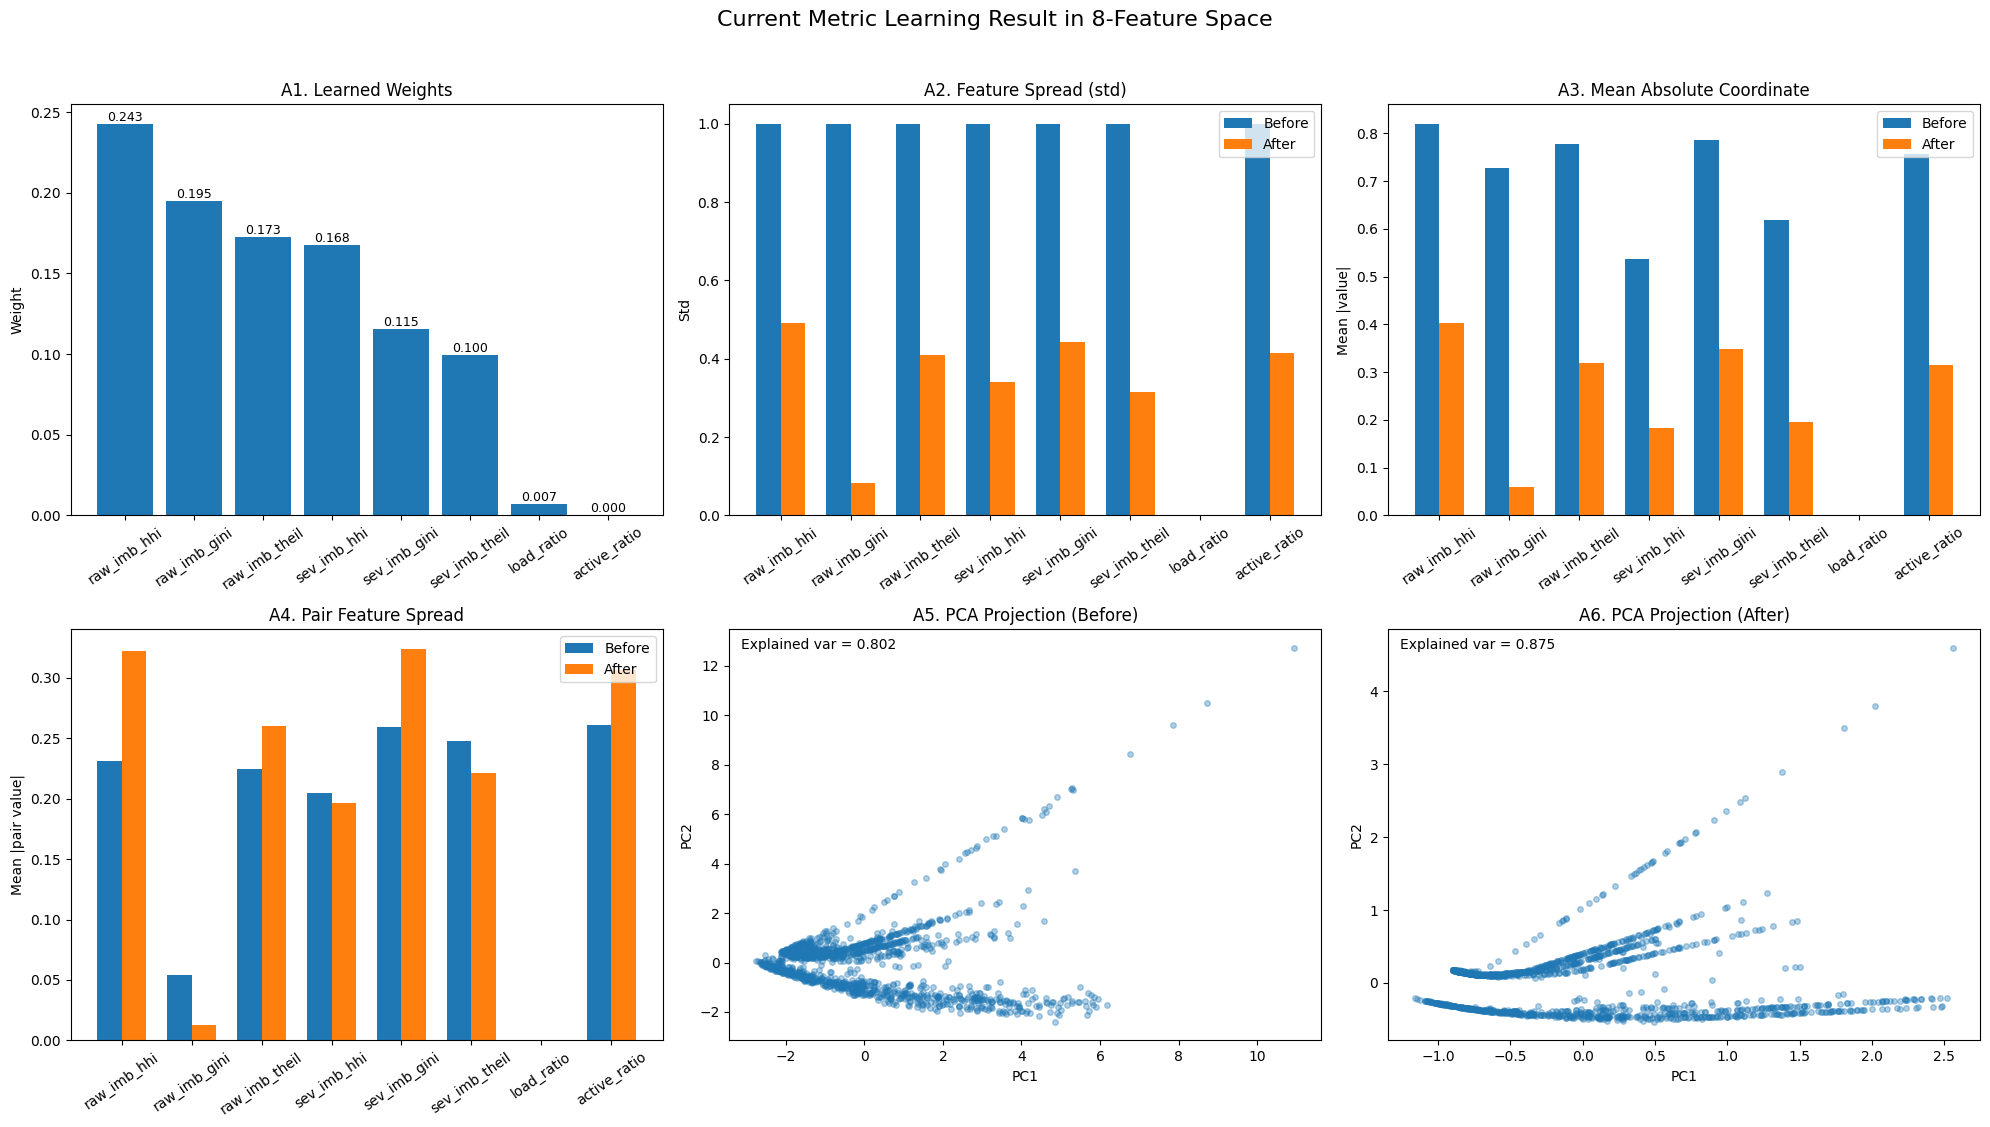

In [79]:
# ============================================================
# A) CURRENT 8-FEATURE SPACE: BEFORE vs AFTER VISUALIZATION
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 0) sanity check
# ------------------------------------------------------------
required = ["WL_FEATURE_COLS", "X_z", "X_learned", "P_equal", "P_learned"]
for name in required:
    if name not in globals():
        raise ValueError(f"❌ missing object: {name}")

w_use = final_learned_w if "final_learned_w" in globals() else w_learned

feat_cols = list(WL_FEATURE_COLS)
Xb = np.asarray(X_z, dtype=float)
Xa = np.asarray(X_learned, dtype=float)
Pb = np.asarray(P_equal, dtype=float)
Pa = np.asarray(P_learned, dtype=float)

if Xb.shape[1] != len(feat_cols):
    raise ValueError(f"❌ X_z dim mismatch: {Xb.shape[1]} vs len(WL_FEATURE_COLS)={len(feat_cols)}")
if Xa.shape[1] != len(feat_cols):
    raise ValueError(f"❌ X_learned dim mismatch: {Xa.shape[1]} vs len(WL_FEATURE_COLS)={len(feat_cols)}")
if len(w_use) != len(feat_cols):
    raise ValueError(f"❌ weight dim mismatch: len(w_use)={len(w_use)} vs len(WL_FEATURE_COLS)={len(feat_cols)}")

# ------------------------------------------------------------
# 1) summary table
# ------------------------------------------------------------
summary_df = pd.DataFrame({
    "feature": feat_cols,
    "weight": np.asarray(w_use, dtype=float),
    "std_before": Xb.std(axis=0),
    "std_after": Xa.std(axis=0),
    "mean_abs_before": np.abs(Xb).mean(axis=0),
    "mean_abs_after": np.abs(Xa).mean(axis=0),
    "pair_abs_before": np.abs(Pb).mean(axis=0),
    "pair_abs_after": np.abs(Pa).mean(axis=0),
})

summary_df["std_ratio_after_before"] = summary_df["std_after"] / summary_df["std_before"].replace(0, np.nan)
summary_df["mean_abs_ratio_after_before"] = summary_df["mean_abs_after"] / summary_df["mean_abs_before"].replace(0, np.nan)
summary_df["pair_abs_ratio_after_before"] = summary_df["pair_abs_after"] / summary_df["pair_abs_before"].replace(0, np.nan)

print("\n==============================")
print("A-SUMMARY TABLE")
print("==============================")
print(summary_df.round(4))

# ------------------------------------------------------------
# 2) PCA for before / after
# ------------------------------------------------------------
pca_before = PCA(n_components=2)
pca_after = PCA(n_components=2)

Zb2 = pca_before.fit_transform(Xb)
Za2 = pca_after.fit_transform(Xa)

# ------------------------------------------------------------
# 3) figure
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

# ---------------- panel 1: learned weights ----------------
ax = axes[0]
bars = ax.bar(summary_df["feature"], summary_df["weight"])
ax.set_title("A1. Learned Weights")
ax.set_ylabel("Weight")
ax.tick_params(axis="x", rotation=35)

for b, v in zip(bars, summary_df["weight"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.3f}",
            ha="center", va="bottom", fontsize=9)

# ---------------- panel 2: std before/after ----------------
ax = axes[1]
x = np.arange(len(summary_df))
w = 0.35
bars1 = ax.bar(x - w/2, summary_df["std_before"], width=w, label="Before")
bars2 = ax.bar(x + w/2, summary_df["std_after"], width=w, label="After")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["feature"], rotation=35)
ax.set_title("A2. Feature Spread (std)")
ax.set_ylabel("Std")
ax.legend()

# ---------------- panel 3: mean abs before/after ----------------
ax = axes[2]
bars1 = ax.bar(x - w/2, summary_df["mean_abs_before"], width=w, label="Before")
bars2 = ax.bar(x + w/2, summary_df["mean_abs_after"], width=w, label="After")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["feature"], rotation=35)
ax.set_title("A3. Mean Absolute Coordinate")
ax.set_ylabel("Mean |value|")
ax.legend()

# ---------------- panel 4: pair abs before/after ----------------
ax = axes[3]
bars1 = ax.bar(x - w/2, summary_df["pair_abs_before"], width=w, label="Before")
bars2 = ax.bar(x + w/2, summary_df["pair_abs_after"], width=w, label="After")
ax.set_xticks(x)
ax.set_xticklabels(summary_df["feature"], rotation=35)
ax.set_title("A4. Pair Feature Spread")
ax.set_ylabel("Mean |pair value|")
ax.legend()

# ---------------- panel 5: PCA before ----------------
ax = axes[4]
ax.scatter(Zb2[:, 0], Zb2[:, 1], alpha=0.35, s=16)
ax.set_title("A5. PCA Projection (Before)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.text(
    0.02, 0.98,
    f"Explained var = {pca_before.explained_variance_ratio_.sum():.3f}",
    transform=ax.transAxes, ha="left", va="top", fontsize=10
)

# ---------------- panel 6: PCA after ----------------
ax = axes[5]
ax.scatter(Za2[:, 0], Za2[:, 1], alpha=0.35, s=16)
ax.set_title("A6. PCA Projection (After)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.text(
    0.02, 0.98,
    f"Explained var = {pca_after.explained_variance_ratio_.sum():.3f}",
    transform=ax.transAxes, ha="left", va="top", fontsize=10
)

fig.suptitle("Current Metric Learning Result in 8-Feature Space", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# BLOCK 8-A) PORT CONFIG + SANITY CHECK

In [31]:
# ============================================================
# BLOCK 8-A) PORT CONFIG + SANITY CHECK
# - 기존 node pipeline과 완전 분리
# - 공통 객체는 재사용
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 0) required object check
# ------------------------------------------------------------
required_objs = [
    "project_long", "imb_long", "limits_imb",
    "segments_final", "point_labels", "load_ref"
]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"❌ required object not found: {obj_name}")

# ------------------------------------------------------------
# 1) port config
# ------------------------------------------------------------
PORT_WL_LEVEL = "port"
PORT_WL_RWS = ["read", "write"]

# 1차는 안전하게 throughput + iops
PORT_WL_SRC_METRICS = ["throughput", "iops"]

# strong이 너무 적으면 ["strong", "medium"] 으로 바꿔도 됨
PORT_WL_POS_TIERS = ["strong"]

PORT_WL_NEG_BUFFER_BINS = 1
PORT_WL_NEG_PER_POS = 2
PORT_WL_POS_NEIGHBORS = 2
PORT_WL_MIN_NEG_POOL_PER_CONTEXT = 5
PORT_WL_ALLOW_NEG_FALLBACK_ACROSS_STG = True
PORT_WL_ALLOW_POS_FALLBACK_ACROSS_STG = True

PORT_WL_USE_RAW_IMB = ["imb_hhi", "imb_gini", "imb_theil"]
PORT_WL_USE_SEV_IMB = ["imb_hhi", "imb_gini", "imb_theil"]
PORT_WL_USE_LOAD_RATIO = True
PORT_WL_USE_ACTIVE_RATIO = True

PORT_WL_TRAIN_Q = 0.70
PORT_WL_VALID_Q = 0.85

PORT_WL_L2 = 1e-2
PORT_WL_MARGIN = 1.0
PORT_WL_MAXITER = 300

PORT_WL_OUT_DIR = OUTPUT_DIR / "weighted_learning_port_v1"
PORT_WL_OUT_DIR.mkdir(parents=True, exist_ok=True)

PORT_FINAL_OUT_DIR = PORT_WL_OUT_DIR / "final_hotspot_pipeline_port"
PORT_FINAL_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PORT_WL_OUT_DIR  :", PORT_WL_OUT_DIR)
print("PORT_FINAL_OUT_DIR:", PORT_FINAL_OUT_DIR)

# ------------------------------------------------------------
# 2) normalize copies
# ------------------------------------------------------------
port_project_long = project_long.copy()
port_imb_long = imb_long.copy()
port_limits_imb = limits_imb.copy()
port_segments_final = segments_final.copy()
port_point_labels = point_labels.copy()
port_load_ref = load_ref.copy()

for df_name in [
    "port_project_long", "port_imb_long", "port_limits_imb",
    "port_segments_final", "port_point_labels", "port_load_ref"
]:
    df = globals()[df_name]
    for c in ["stg_ip", "level", "entity_id", "rw", "metric", "imb_metric", "src_metric", "hotspot_tier"]:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip().str.lower()
    for c in ["timestamp", "start_ts", "end_ts", "peak_ts"]:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    globals()[df_name] = df

# ------------------------------------------------------------
# 3) sanity check
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("PORT SANITY CHECK")
print("=" * 80)

port_imb_chk = port_imb_long[port_imb_long["level"] == PORT_WL_LEVEL].copy()
print("\n[imb_long | port]")
print("shape:", port_imb_chk.shape)
if not port_imb_chk.empty:
    print(port_imb_chk["src_metric"].value_counts(dropna=False))
    print(port_imb_chk["imb_metric"].value_counts(dropna=False).head(20))

port_lbl_chk = port_point_labels[port_point_labels["level"] == PORT_WL_LEVEL].copy()
print("\n[point_labels | port]")
print("shape:", port_lbl_chk.shape)
if not port_lbl_chk.empty:
    print(port_lbl_chk["src_metric"].value_counts(dropna=False))
    print(port_lbl_chk["hotspot_tier"].value_counts(dropna=False))

port_seg_chk = port_segments_final[port_segments_final["level"] == PORT_WL_LEVEL].copy()
print("\n[segments_final | port]")
print("shape:", port_seg_chk.shape)
if not port_seg_chk.empty:
    print(port_seg_chk["src_metric"].value_counts(dropna=False))
    print(port_seg_chk["hotspot_tier"].value_counts(dropna=False))

port_strong_chk = port_seg_chk[port_seg_chk["hotspot_tier"].isin(PORT_WL_POS_TIERS)].copy()
print("\n[strong port segments]")
print("shape:", port_strong_chk.shape)
if not port_strong_chk.empty:
    print(port_strong_chk["src_metric"].value_counts(dropna=False))

PORT_WL_OUT_DIR  : /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/weighted_learning_port_v1
PORT_FINAL_OUT_DIR: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/weighted_learning_port_v1/final_hotspot_pipeline_port

PORT SANITY CHECK

[imb_long | port]
shape: (316130, 12)
src_metric
throughput    316130
Name: count, dtype: int64
imb_metric
imb_gini               63226
imb_hhi                63226
imb_norm_top1_share    63226
imb_theil              63226
imb_top1_share         63226
Name: count, dtype: int64

[point_labels | port]
shape: (255, 8)
src_metric
throughput    255
Name: count, dtype: int64
hotspot_tier
weak      221
strong     32
medium      2
Name: count, dtype: int64

[segments_final | port]
shape: (52, 22)
src_metric
throughput    52
Name: count, dtype: int64
hotspot_tier
weak      47
strong     4
medium     1
Name: count, dtype: int64

[strong port segments]
shape: (4, 22)
src_metric
throughput    4
Name: count, dtyp

# BLOCK 8-B) PORT POINT FEATURE TABLE

In [32]:
# ============================================================
# BLOCK 8-B) PORT POINT FEATURE TABLE
# - node 6-B 구조를 그대로 port용으로 복제
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1) port imbalance rows만 사용
# ------------------------------------------------------------
port_imb_use = port_imb_long[
    (port_imb_long["level"] == PORT_WL_LEVEL) &
    (port_imb_long["rw"].isin(PORT_WL_RWS)) &
    (port_imb_long["src_metric"].isin(PORT_WL_SRC_METRICS)) &
    (port_imb_long["imb_metric"].isin(IMB_METRICS_REVISED))
].copy()

if port_imb_use.empty:
    raise RuntimeError("❌ port_imb_use is empty. PORT_WL_SRC_METRICS / level 조건 확인")

# limits merge
lim_key = ["stg_ip", "level", "entity_id", "rw", "metric"]
port_lim_use = port_limits_imb.copy()
for c in lim_key:
    port_lim_use[c] = port_lim_use[c].astype(str).str.strip().str.lower()

port_imb_use["entity_id"] = port_imb_use["entity_id"].astype(str).str.strip().str.lower()
port_imb_use["metric"] = port_imb_use["metric"].astype(str).str.strip().str.lower()

port_imb_use = port_imb_use.merge(
    port_lim_use[lim_key + ["CL", "SIGMA", "UCL", "LCL"]],
    on=lim_key,
    how="left"
)

# severity
port_imb_use["severity_over_ucl"] = np.maximum(
    0.0,
    (pd.to_numeric(port_imb_use["value"], errors="coerce") - pd.to_numeric(port_imb_use["UCL"], errors="coerce")) /
    np.maximum(np.abs(pd.to_numeric(port_imb_use["UCL"], errors="coerce")), 1e-12)
)

# ------------------------------------------------------------
# 2) point-wide feature
# ------------------------------------------------------------
PORT_POINT_KEYS = ["timestamp", "stg_ip", "level", "rw", "src_metric"]

port_base_meta = (
    port_imb_use.groupby(PORT_POINT_KEYS, observed=True)
    .agg(
        group_total=("group_total", "max"),
        n_entities=("n_entities", "max"),
        active_entities=("active_entities", "max")
    )
    .reset_index()
)

port_raw_wide = (
    port_imb_use.pivot_table(
        index=PORT_POINT_KEYS,
        columns="imb_metric",
        values="value",
        aggfunc="first",
        observed=True
    )
    .reset_index()
)
port_raw_wide.columns.name = None
port_raw_wide = port_raw_wide.rename(columns={c: f"raw_{c}" for c in port_raw_wide.columns if c not in PORT_POINT_KEYS})

port_sev_wide = (
    port_imb_use.pivot_table(
        index=PORT_POINT_KEYS,
        columns="imb_metric",
        values="severity_over_ucl",
        aggfunc="first",
        observed=True
    )
    .reset_index()
)
port_sev_wide.columns.name = None
port_sev_wide = port_sev_wide.rename(columns={c: f"sev_{c}" for c in port_sev_wide.columns if c not in PORT_POINT_KEYS})

port_point_features = port_base_meta.merge(port_raw_wide, on=PORT_POINT_KEYS, how="left")
port_point_features = port_point_features.merge(port_sev_wide, on=PORT_POINT_KEYS, how="left")

# load reference
port_point_features = port_point_features.merge(
    port_load_ref[["stg_ip", "level", "rw", "src_metric", "load_floor", "baseline_load_median", "baseline_n"]],
    on=["stg_ip", "level", "rw", "src_metric"],
    how="left"
)

port_point_features["load_ratio"] = (
    pd.to_numeric(port_point_features["group_total"], errors="coerce") /
    np.maximum(pd.to_numeric(port_point_features["load_floor"], errors="coerce"), 1e-12)
)
port_point_features["active_ratio"] = (
    pd.to_numeric(port_point_features["active_entities"], errors="coerce") /
    np.maximum(pd.to_numeric(port_point_features["n_entities"], errors="coerce"), 1e-12)
)

port_point_features["passes_load_gate"] = (
    pd.to_numeric(port_point_features["group_total"], errors="coerce") >=
    pd.to_numeric(port_point_features["load_floor"], errors="coerce")
).fillna(False)

# point label merge
port_point_label_key = ["timestamp", "stg_ip", "level", "rw", "src_metric"]
port_point_label_flag = port_point_labels[
    port_point_label_key + ["segment_id", "hotspot_tier", "hotspot_score"]
].copy()
port_point_label_flag["has_hot_label"] = 1

port_point_features = port_point_features.merge(
    port_point_label_flag,
    on=port_point_label_key,
    how="left"
)
port_point_features["has_hot_label"] = port_point_features["has_hot_label"].fillna(0).astype(int)

# unique point id
port_point_features = port_point_features.sort_values(PORT_POINT_KEYS).reset_index(drop=True)
port_point_features["point_id"] = np.arange(1, len(port_point_features) + 1)

# ------------------------------------------------------------
# 3) leakage-free feature list
# ------------------------------------------------------------
PORT_WL_FEATURE_COLS = []

for m in PORT_WL_USE_RAW_IMB:
    c = f"raw_{m}"
    if c in port_point_features.columns:
        PORT_WL_FEATURE_COLS.append(c)

for m in PORT_WL_USE_SEV_IMB:
    c = f"sev_{m}"
    if c in port_point_features.columns:
        PORT_WL_FEATURE_COLS.append(c)

if PORT_WL_USE_LOAD_RATIO and "load_ratio" in port_point_features.columns:
    PORT_WL_FEATURE_COLS.append("load_ratio")

if PORT_WL_USE_ACTIVE_RATIO and "active_ratio" in port_point_features.columns:
    PORT_WL_FEATURE_COLS.append("active_ratio")

for c in PORT_WL_FEATURE_COLS:
    port_point_features[c] = pd.to_numeric(port_point_features[c], errors="coerce").fillna(0.0)

print("port_point_features:", port_point_features.shape)
print("PORT_WL_FEATURE_COLS:", PORT_WL_FEATURE_COLS)

port_point_features.to_parquet(PORT_WL_OUT_DIR / "PORT_WL_POINT_FEATURES.parquet", index=False)

pd.DataFrame({
    "feature_col": PORT_WL_FEATURE_COLS,
    "feature_type": [
        "raw_imb" if c.startswith("raw_") else
        "sev_imb" if c.startswith("sev_") else
        "load" if c == "load_ratio" else
        "activity" if c == "active_ratio" else
        "other"
        for c in PORT_WL_FEATURE_COLS
    ]
}).to_excel(PORT_WL_OUT_DIR / "PORT_WL_FEATURE_MANIFEST.xlsx", index=False)

port_point_features: (63226, 29)
PORT_WL_FEATURE_COLS: ['raw_imb_hhi', 'raw_imb_gini', 'raw_imb_theil', 'sev_imb_hhi', 'sev_imb_gini', 'sev_imb_theil', 'load_ratio', 'active_ratio']


In [44]:
# ============================================================
# BLOCK 8-B-ALT) PORT HEAVY-TAIL LOG1P
# ============================================================

import numpy as np
import pandas as pd

required_objs = ["port_point_features", "PORT_WL_FEATURE_COLS", "PORT_WL_OUT_DIR"]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"❌ required object not found: {obj_name}")

PORT_HEAVY_TAIL_COLS = [
    c for c in PORT_WL_FEATURE_COLS
    if (
        ("theil" in c.lower()) or
        (c.lower().startswith("sev_")) or
        (c.lower() == "load_ratio")
    )
]

for c in PORT_HEAVY_TAIL_COLS:
    port_point_features[c] = np.log1p(
        pd.to_numeric(port_point_features[c], errors="coerce").fillna(0.0).clip(lower=0.0)
    )

port_point_features.to_parquet(PORT_WL_OUT_DIR / "PORT_WL_POINT_FEATURES_LOG1P.parquet", index=False)
print("✅ saved:", PORT_WL_OUT_DIR / "PORT_WL_POINT_FEATURES_LOG1P.parquet")
print("PORT_HEAVY_TAIL_COLS =", PORT_HEAVY_TAIL_COLS)

✅ saved: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/weighted_learning_port_v1/PORT_WL_POINT_FEATURES_LOG1P.parquet
PORT_HEAVY_TAIL_COLS = ['raw_imb_theil', 'sev_imb_hhi', 'sev_imb_gini', 'sev_imb_theil', 'load_ratio']


# BLOCK 8-C) PORT POSITIVE / NEGATIVE / PAIR TABLE

In [33]:
# ============================================================
# BLOCK 8-C) PORT POSITIVE / NEGATIVE / PAIR TABLE
# - node 6-C를 port 버전으로 복제
# ============================================================

import numpy as np
import pandas as pd

PORT_TIME_BIN_TD = pd.Timedelta(TIME_BIN)

def _unique_cols(cols):
    return list(dict.fromkeys(cols))

def _assert_no_duplicate_columns(df, df_name):
    dup = df.columns[df.columns.duplicated()].tolist()
    if dup:
        raise ValueError(f"❌ {df_name} has duplicate columns: {dup}")

def _safe_numeric_series(df, col):
    obj = df[col]
    if isinstance(obj, pd.DataFrame):
        obj = obj.iloc[:, 0]
    return pd.to_numeric(obj, errors="coerce")

def _safe_datetime_series(df, col):
    obj = df[col]
    if isinstance(obj, pd.DataFrame):
        obj = obj.iloc[:, 0]
    return pd.to_datetime(obj, errors="coerce")

# clean duplicated columns
port_point_features = port_point_features.loc[:, ~port_point_features.columns.duplicated()].copy()
port_segments_final = port_segments_final.loc[:, ~port_segments_final.columns.duplicated()].copy()

_assert_no_duplicate_columns(port_point_features, "port_point_features")
_assert_no_duplicate_columns(port_segments_final, "port_segments_final")

# ------------------------------------------------------------
# 1) time split
# ------------------------------------------------------------
all_ts = port_point_features["timestamp"].dropna().sort_values()
if len(all_ts) == 0:
    raise RuntimeError("❌ port_point_features에 timestamp가 없습니다.")

t1 = all_ts.quantile(PORT_WL_TRAIN_Q)
t2 = all_ts.quantile(PORT_WL_VALID_Q)

def _assign_port_split(ts):
    if pd.isna(ts):
        return "drop"
    if ts <= t1:
        return "train"
    elif ts <= t2:
        return "valid"
    else:
        return "test"

port_point_features["split"] = port_point_features["timestamp"].apply(_assign_port_split)

print("port split cutoffs:", t1, t2)
print(port_point_features["split"].value_counts(dropna=False).to_dict())

# ------------------------------------------------------------
# 2) positive segment peak
# ------------------------------------------------------------
port_pos_seg = port_segments_final[
    (port_segments_final["level"] == PORT_WL_LEVEL) &
    (port_segments_final["rw"].isin(PORT_WL_RWS)) &
    (port_segments_final["src_metric"].isin(PORT_WL_SRC_METRICS)) &
    (port_segments_final["hotspot_tier"].isin(PORT_WL_POS_TIERS))
].copy()

if port_pos_seg.empty:
    raise RuntimeError("❌ port positive segment가 0개입니다. PORT_WL_POS_TIERS를 ['strong','medium']으로 넓혀보세요.")

port_pos_seg = port_pos_seg.rename(columns={"peak_ts": "timestamp"})
port_pos_seg["timestamp"] = pd.to_datetime(port_pos_seg["timestamp"], errors="coerce")

port_pos_feature_cols = _unique_cols(
    PORT_POINT_KEYS + ["point_id", "split"] + PORT_WL_FEATURE_COLS + [
        "group_total", "n_entities", "active_entities",
        "load_floor", "baseline_load_median",
        "load_ratio", "active_ratio",
        "passes_load_gate", "has_hot_label"
    ]
)

port_pos_samples = port_pos_seg.merge(
    port_point_features[port_pos_feature_cols].copy(),
    on=PORT_POINT_KEYS,
    how="inner"
)

port_pos_samples = port_pos_samples.loc[:, ~port_pos_samples.columns.duplicated()].copy()
port_pos_samples["sample_role"] = "positive"
port_pos_samples = port_pos_samples.sort_values(["timestamp", "stg_ip", "rw", "src_metric"]).reset_index(drop=True)

_assert_no_duplicate_columns(port_pos_samples, "port_pos_samples")

print("port_pos_samples:", port_pos_samples.shape)
print("port_pos_samples split:", port_pos_samples["split"].value_counts(dropna=False).to_dict())

if port_pos_samples.empty:
    raise RuntimeError("❌ port_pos_samples가 0개입니다. peak_ts와 point feature 정합성 확인")

# ------------------------------------------------------------
# 3) hotspot exclusion window
# ------------------------------------------------------------
port_seg_excl = port_segments_final[
    (port_segments_final["level"] == PORT_WL_LEVEL) &
    (port_segments_final["rw"].isin(PORT_WL_RWS)) &
    (port_segments_final["src_metric"].isin(PORT_WL_SRC_METRICS))
][["segment_id", "stg_ip", "level", "rw", "src_metric", "start_ts", "end_ts"]].copy()

port_seg_excl["start_excl"] = pd.to_datetime(port_seg_excl["start_ts"], errors="coerce") - PORT_WL_NEG_BUFFER_BINS * PORT_TIME_BIN_TD
port_seg_excl["end_excl"] = pd.to_datetime(port_seg_excl["end_ts"], errors="coerce") + PORT_WL_NEG_BUFFER_BINS * PORT_TIME_BIN_TD

port_point_features["is_excluded_by_hot_window"] = False

ctx_cols = ["stg_ip", "level", "rw", "src_metric"]
for ctx_key, gseg in port_seg_excl.groupby(ctx_cols, observed=True):
    mask_ctx = (
        (port_point_features["stg_ip"] == ctx_key[0]) &
        (port_point_features["level"] == ctx_key[1]) &
        (port_point_features["rw"] == ctx_key[2]) &
        (port_point_features["src_metric"] == ctx_key[3])
    )
    if mask_ctx.sum() == 0:
        continue

    ts_vals = port_point_features.loc[mask_ctx, "timestamp"].values.astype("datetime64[ns]")
    excl = np.zeros(mask_ctx.sum(), dtype=bool)

    for row in gseg.itertuples(index=False):
        s = np.datetime64(pd.to_datetime(row.start_excl))
        e = np.datetime64(pd.to_datetime(row.end_excl))
        excl |= (ts_vals >= s) & (ts_vals <= e)

    port_point_features.loc[mask_ctx, "is_excluded_by_hot_window"] = excl

# ------------------------------------------------------------
# 4) negative pool
# ------------------------------------------------------------
port_neg_pool_cols = _unique_cols(
    PORT_POINT_KEYS + ["point_id", "split"] + PORT_WL_FEATURE_COLS + [
        "group_total", "n_entities", "active_entities",
        "load_floor", "baseline_load_median",
        "load_ratio", "active_ratio",
        "passes_load_gate", "has_hot_label", "is_excluded_by_hot_window"
    ]
)

port_neg_pool = port_point_features[
    (port_point_features["level"] == PORT_WL_LEVEL) &
    (port_point_features["rw"].isin(PORT_WL_RWS)) &
    (port_point_features["src_metric"].isin(PORT_WL_SRC_METRICS)) &
    (port_point_features["passes_load_gate"] == True) &
    (port_point_features["has_hot_label"] == 0) &
    (port_point_features["is_excluded_by_hot_window"] == False)
][port_neg_pool_cols].copy()

port_neg_pool = port_neg_pool.loc[:, ~port_neg_pool.columns.duplicated()].copy()
port_neg_pool["sample_role"] = "negative"
port_neg_pool = port_neg_pool.sort_values(["timestamp", "stg_ip", "rw", "src_metric"]).reset_index(drop=True)

_assert_no_duplicate_columns(port_neg_pool, "port_neg_pool")

print("port_neg_pool:", port_neg_pool.shape)
print("port_neg_pool split:", port_neg_pool["split"].value_counts(dropna=False).to_dict())

if port_neg_pool.empty:
    raise RuntimeError("❌ port_neg_pool이 0개입니다. 조건이 너무 강합니다.")

# ------------------------------------------------------------
# 5) similar pair
# ------------------------------------------------------------
def build_port_similar_pairs(pos_df, max_neighbors=2, allow_fallback_across_stg=True):
    rows = []
    for anchor in pos_df.itertuples(index=False):
        cand = pos_df[
            (pos_df["point_id"] != anchor.point_id) &
            (pos_df["split"] == anchor.split) &
            (pos_df["stg_ip"] == anchor.stg_ip) &
            (pos_df["level"] == anchor.level) &
            (pos_df["rw"] == anchor.rw) &
            (pos_df["src_metric"] == anchor.src_metric)
        ].copy()

        if len(cand) == 0 and allow_fallback_across_stg:
            cand = pos_df[
                (pos_df["point_id"] != anchor.point_id) &
                (pos_df["split"] == anchor.split) &
                (pos_df["level"] == anchor.level) &
                (pos_df["rw"] == anchor.rw) &
                (pos_df["src_metric"] == anchor.src_metric)
            ].copy()

        if cand.empty:
            continue

        anchor_load_ratio = float(pd.to_numeric(pd.Series([anchor.load_ratio]), errors="coerce").iloc[0])
        cand["load_gap"] = (_safe_numeric_series(cand, "load_ratio") - anchor_load_ratio).abs()
        cand["time_gap_sec"] = (_safe_datetime_series(cand, "timestamp") - pd.to_datetime(anchor.timestamp)).abs().dt.total_seconds()
        cand = cand.sort_values(["load_gap", "time_gap_sec"]).head(max_neighbors)

        for mate in cand.itertuples(index=False):
            left_id = int(min(anchor.point_id, mate.point_id))
            right_id = int(max(anchor.point_id, mate.point_id))
            rows.append({
                "pair_type": "similar",
                "y": 1,
                "split": anchor.split,
                "left_point_id": left_id,
                "right_point_id": right_id,
                "left_role": "positive",
                "right_role": "positive",
                "left_stg_ip": anchor.stg_ip,
                "right_stg_ip": mate.stg_ip,
                "rw": anchor.rw,
                "src_metric": anchor.src_metric
            })

    if not rows:
        return pd.DataFrame(columns=[
            "pair_type", "y", "split", "left_point_id", "right_point_id",
            "left_role", "right_role", "left_stg_ip", "right_stg_ip", "rw", "src_metric"
        ])
    return pd.DataFrame(rows).drop_duplicates(
        subset=["pair_type", "left_point_id", "right_point_id"]
    ).reset_index(drop=True)

port_similar_pairs = build_port_similar_pairs(
    port_pos_samples,
    max_neighbors=PORT_WL_POS_NEIGHBORS,
    allow_fallback_across_stg=PORT_WL_ALLOW_POS_FALLBACK_ACROSS_STG
)

print("port_similar_pairs:", port_similar_pairs.shape)

# ------------------------------------------------------------
# 6) dissimilar pair
# ------------------------------------------------------------
def build_port_dissimilar_pairs(pos_df, neg_df, neg_per_pos=2,
                                min_pool_per_context=5,
                                allow_fallback_across_stg=True):
    rows = []
    for anchor in pos_df.itertuples(index=False):
        cand = neg_df[
            (neg_df["split"] == anchor.split) &
            (neg_df["stg_ip"] == anchor.stg_ip) &
            (neg_df["level"] == anchor.level) &
            (neg_df["rw"] == anchor.rw) &
            (neg_df["src_metric"] == anchor.src_metric)
        ].copy()

        if len(cand) < min_pool_per_context and allow_fallback_across_stg:
            cand = neg_df[
                (neg_df["split"] == anchor.split) &
                (neg_df["level"] == anchor.level) &
                (neg_df["rw"] == anchor.rw) &
                (neg_df["src_metric"] == anchor.src_metric)
            ].copy()

        if cand.empty:
            continue

        anchor_load_ratio = float(pd.to_numeric(pd.Series([anchor.load_ratio]), errors="coerce").iloc[0])
        cand["load_gap"] = (_safe_numeric_series(cand, "load_ratio") - anchor_load_ratio).abs()
        cand["time_gap_sec"] = (_safe_datetime_series(cand, "timestamp") - pd.to_datetime(anchor.timestamp)).abs().dt.total_seconds()
        cand = cand.sort_values(["load_gap", "time_gap_sec"]).head(neg_per_pos)

        for mate in cand.itertuples(index=False):
            rows.append({
                "pair_type": "dissimilar",
                "y": 0,
                "split": anchor.split,
                "left_point_id": int(anchor.point_id),
                "right_point_id": int(mate.point_id),
                "left_role": "positive",
                "right_role": "negative",
                "left_stg_ip": anchor.stg_ip,
                "right_stg_ip": mate.stg_ip,
                "rw": anchor.rw,
                "src_metric": anchor.src_metric
            })

    if not rows:
        return pd.DataFrame(columns=[
            "pair_type", "y", "split", "left_point_id", "right_point_id",
            "left_role", "right_role", "left_stg_ip", "right_stg_ip", "rw", "src_metric"
        ])
    return pd.DataFrame(rows).drop_duplicates(
        subset=["pair_type", "left_point_id", "right_point_id"]
    ).reset_index(drop=True)

port_dissimilar_pairs = build_port_dissimilar_pairs(
    port_pos_samples,
    port_neg_pool,
    neg_per_pos=PORT_WL_NEG_PER_POS,
    min_pool_per_context=PORT_WL_MIN_NEG_POOL_PER_CONTEXT,
    allow_fallback_across_stg=PORT_WL_ALLOW_NEG_FALLBACK_ACROSS_STG
)

print("port_dissimilar_pairs:", port_dissimilar_pairs.shape)

# ------------------------------------------------------------
# 7) sample universe + pair table
# ------------------------------------------------------------
port_sample_cols = _unique_cols(
    PORT_POINT_KEYS + ["point_id", "split", "sample_role"] + PORT_WL_FEATURE_COLS
)

port_train_samples = pd.concat([
    port_pos_samples[port_sample_cols].copy(),
    port_neg_pool[port_sample_cols].copy()
], ignore_index=True).drop_duplicates(subset=["point_id"]).reset_index(drop=True)

port_pair_table = pd.concat([port_similar_pairs, port_dissimilar_pairs], ignore_index=True).reset_index(drop=True)

valid_ids = set(port_train_samples["point_id"].tolist())
port_pair_table = port_pair_table[
    port_pair_table["left_point_id"].isin(valid_ids) &
    port_pair_table["right_point_id"].isin(valid_ids)
].copy().reset_index(drop=True)

print("port_train_samples:", port_train_samples.shape)
print("port_pair_table   :", port_pair_table.shape)
if not port_pair_table.empty:
    print(port_pair_table.groupby(["split", "pair_type"], observed=True).size())

port_train_samples.to_parquet(PORT_WL_OUT_DIR / "PORT_WL_TRAIN_SAMPLES.parquet", index=False)
port_neg_pool.to_parquet(PORT_WL_OUT_DIR / "PORT_WL_NEG_POOL.parquet", index=False)
port_pair_table.to_parquet(PORT_WL_OUT_DIR / "PORT_WL_PAIR_TABLE.parquet", index=False)

with pd.ExcelWriter(PORT_WL_OUT_DIR / "PORT_WL_SAMPLE_AND_PAIR_SUMMARY.xlsx", engine="openpyxl") as writer:
    port_pos_samples.to_excel(writer, sheet_name="POS_SAMPLES", index=False)
    port_neg_pool.head(5000).to_excel(writer, sheet_name="NEG_POOL_HEAD", index=False)
    port_pair_table.to_excel(writer, sheet_name="PAIR_TABLE", index=False)

print("✅ port positive / negative / pair tables saved")

port split cutoffs: 2025-10-31 03:00:00 2025-11-13 02:00:00
{'train': 44268, 'valid': 9480, 'test': 9478}
port_pos_samples: (4, 40)
port_pos_samples split: {'train': 4}
port_neg_pool: (32361, 24)
port_neg_pool split: {'train': 22068, 'valid': 5215, 'test': 5078}
port_similar_pairs: (5, 11)
port_dissimilar_pairs: (8, 11)
port_train_samples: (32365, 16)
port_pair_table   : (13, 11)
split  pair_type 
train  dissimilar    8
       similar       5
dtype: int64
✅ port positive / negative / pair tables saved


In [45]:
# ============================================================
# BLOCK 8-C-ALT) PORT TRIPLET TABLE BUILD
# ============================================================

import numpy as np
import pandas as pd

required_objs = ["port_pos_samples", "port_neg_pool", "PORT_WL_FEATURE_COLS", "PORT_WL_OUT_DIR"]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"❌ required object not found: {obj_name}")

def _p_safe_num(df, col):
    return pd.to_numeric(df[col], errors="coerce")

def _p_safe_dt(df, col):
    return pd.to_datetime(df[col], errors="coerce")

def _p_nearest_positive(anchor_row, pos_df, feature_cols):
    cand = pos_df[
        (pos_df["point_id"] != anchor_row.point_id) &
        (pos_df["split"] == anchor_row.split) &
        (pos_df["level"] == anchor_row.level) &
        (pos_df["rw"] == anchor_row.rw) &
        (pos_df["src_metric"] == anchor_row.src_metric)
    ].copy()
    if cand.empty:
        return None

    a_vec = np.array([float(getattr(anchor_row, c)) for c in feature_cols], dtype=float)
    C = cand[feature_cols].astype(float).values
    cand["feat_l2"] = np.sqrt(((C - a_vec[None, :]) ** 2).sum(axis=1))
    cand["time_gap_sec"] = (_p_safe_dt(cand, "timestamp") - pd.to_datetime(anchor_row.timestamp)).abs().dt.total_seconds()
    cand = cand.sort_values(["feat_l2", "time_gap_sec"]).reset_index(drop=True)
    return cand.iloc[0]

def _p_nearest_negative(anchor_row, neg_df, feature_cols):
    cand = neg_df[
        (neg_df["split"] == anchor_row.split) &
        (neg_df["level"] == anchor_row.level) &
        (neg_df["rw"] == anchor_row.rw) &
        (neg_df["src_metric"] == anchor_row.src_metric)
    ].copy()
    if cand.empty:
        return None

    a_vec = np.array([float(getattr(anchor_row, c)) for c in feature_cols], dtype=float)
    C = cand[feature_cols].astype(float).values
    cand["feat_l2"] = np.sqrt(((C - a_vec[None, :]) ** 2).sum(axis=1))
    cand["time_gap_sec"] = (_p_safe_dt(cand, "timestamp") - pd.to_datetime(anchor_row.timestamp)).abs().dt.total_seconds()
    cand = cand.sort_values(["feat_l2", "time_gap_sec"]).reset_index(drop=True)
    return cand.iloc[0]

port_triplet_rows = []

for anchor in port_pos_samples.itertuples(index=False):
    pos_mate = _p_nearest_positive(anchor, port_pos_samples, PORT_WL_FEATURE_COLS)
    neg_mate = _p_nearest_negative(anchor, port_neg_pool, PORT_WL_FEATURE_COLS)

    if pos_mate is None or neg_mate is None:
        continue

    port_triplet_rows.append({
        "split": anchor.split,
        "anchor_point_id": int(anchor.point_id),
        "positive_point_id": int(pos_mate["point_id"]),
        "negative_point_id": int(neg_mate["point_id"]),
        "stg_ip": str(anchor.stg_ip).lower(),
        "level": str(anchor.level).lower(),
        "rw": str(anchor.rw).lower(),
        "src_metric": str(anchor.src_metric).lower(),
        "triplet_source": "initial_nearest"
    })

port_triplet_table_v1 = pd.DataFrame(port_triplet_rows).drop_duplicates(
    subset=["split", "anchor_point_id", "positive_point_id", "negative_point_id"]
).reset_index(drop=True)

port_triplet_table_v1.to_parquet(PORT_WL_OUT_DIR / "PORT_WL_TRIPLET_TABLE_V1.parquet", index=False)
print("✅ saved:", PORT_WL_OUT_DIR / "PORT_WL_TRIPLET_TABLE_V1.parquet")
print("port_triplet_table_v1:", port_triplet_table_v1.shape)

✅ saved: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/weighted_learning_port_v1/PORT_WL_TRIPLET_TABLE_V1.parquet
port_triplet_table_v1: (4, 9)


# BLOCK 8-D) PORT DIAGONAL WEIGHTED LEARNING

In [34]:
# ============================================================
# BLOCK 8-D) PORT DIAGONAL WEIGHTED LEARNING
# - node 6-D 구조 복제
# ============================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.special import softmax
from scipy.stats import rankdata

PORT_MULTI_START_SEEDS = [7, 21, 42, 84, 168]
PORT_INIT_NOISE = 0.05
PORT_NEG_HINGE_WEIGHT = 1.0
PORT_L2_SIMPLEX = 1e-3
PORT_USE_DATA_DRIVEN_MARGIN = True

def _port_robust_scale_fit(X_df: pd.DataFrame):
    med = X_df.median()
    mad = (X_df - med).abs().median().replace(0, 1.0)
    return med, mad

def _port_robust_scale_transform(X_df: pd.DataFrame, med, mad):
    return (X_df - med) / mad

def _port_softmax_logits(alpha: np.ndarray):
    alpha = np.asarray(alpha, dtype=float)
    alpha = alpha - np.max(alpha)
    e = np.exp(alpha)
    return e / np.sum(e)

def _port_fast_auc_binary(labels, scores):
    labels = np.asarray(labels).astype(int)
    scores = np.asarray(scores, dtype=float)
    if len(labels) == 0 or len(np.unique(labels)) < 2:
        return np.nan
    ranks = rankdata(scores, method="average")
    n_pos = int(labels.sum())
    n_neg = int(len(labels) - n_pos)
    if n_pos == 0 or n_neg == 0:
        return np.nan
    sum_ranks_pos = ranks[labels == 1].sum()
    auc = (sum_ranks_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg)
    return float(auc)

def _port_eval_pairs(Z, y, w):
    if len(Z) == 0:
        return {
            "n_pairs": 0,
            "pos_mean_dist": np.nan,
            "neg_mean_dist": np.nan,
            "gap_neg_minus_pos": np.nan,
            "auc_pair_distance": np.nan
        }
    dist = Z @ w
    pos_mask = (y == 1)
    neg_mask = (y == 0)
    pos_mean = float(dist[pos_mask].mean()) if np.any(pos_mask) else np.nan
    neg_mean = float(dist[neg_mask].mean()) if np.any(neg_mask) else np.nan
    gap = float(neg_mean - pos_mean) if np.isfinite(pos_mean) and np.isfinite(neg_mean) else np.nan
    label_neg = 1 - y
    auc = _port_fast_auc_binary(label_neg, dist)
    return {
        "n_pairs": int(len(y)),
        "pos_mean_dist": pos_mean,
        "neg_mean_dist": neg_mean,
        "gap_neg_minus_pos": gap,
        "auc_pair_distance": auc
    }

def _port_feature_gap_diagnostic(Z, y, feature_names):
    rows = []
    for j, f in enumerate(feature_names):
        zj = Z[:, j]
        pos_mean = float(zj[y == 1].mean()) if np.any(y == 1) else np.nan
        neg_mean = float(zj[y == 0].mean()) if np.any(y == 0) else np.nan
        gap = float(neg_mean - pos_mean) if np.isfinite(pos_mean) and np.isfinite(neg_mean) else np.nan
        ratio = float(neg_mean / max(pos_mean, 1e-12)) if np.isfinite(pos_mean) and np.isfinite(neg_mean) else np.nan
        rows.append({
            "feature": f,
            "pos_mean_sqdiff": pos_mean,
            "neg_mean_sqdiff": neg_mean,
            "gap_neg_minus_pos_feature": gap,
            "ratio_neg_div_pos_feature": ratio
        })
    return pd.DataFrame(rows).sort_values("gap_neg_minus_pos_feature", ascending=False).reset_index(drop=True)

def _port_choose_margin_from_equal(Z, y, w_equal):
    d = Z @ w_equal
    pos = d[y == 1]
    neg = d[y == 0]
    if len(pos) == 0 or len(neg) == 0:
        return 1.0
    return float(0.5 * (pos.mean() + neg.mean()))

def _port_simplex_metric_loss(alpha, Z, y, margin, neg_hinge_weight=1.0, l2_simplex=1e-3):
    w = _port_softmax_logits(alpha)
    d = Z @ w
    pos = d[y == 1]
    neg = d[y == 0]
    pos_loss = float(pos.mean()) if len(pos) > 0 else 0.0
    neg_hinge = float(np.maximum(0.0, margin - neg).mean()) if len(neg) > 0 else 0.0
    reg = float(l2_simplex * np.sum(w * w))
    total = pos_loss + neg_hinge_weight * neg_hinge + reg
    parts = {
        "total_loss": total,
        "pos_loss": pos_loss,
        "neg_hinge_loss": neg_hinge,
        "l2_loss": reg
    }
    return total, parts

# split
port_samples_train = port_train_samples[port_train_samples["split"] == "train"].copy()
port_samples_valid = port_train_samples[port_train_samples["split"] == "valid"].copy()
port_samples_test = port_train_samples[port_train_samples["split"] == "test"].copy()

port_pairs_train = port_pair_table[port_pair_table["split"] == "train"].copy()
port_pairs_valid = port_pair_table[port_pair_table["split"] == "valid"].copy()
port_pairs_test = port_pair_table[port_pair_table["split"] == "test"].copy()

print("port_samples_train:", port_samples_train.shape)
print("port_pairs_train  :", port_pairs_train.shape)

if len(port_pairs_train) == 0:
    raise RuntimeError("❌ port train pair가 0개입니다. strong segment 부족 가능성")

# scaling
X_train_df = port_samples_train.set_index("point_id")[PORT_WL_FEATURE_COLS].copy()
port_med, port_mad = _port_robust_scale_fit(X_train_df)

for df_name in ["port_samples_train", "port_samples_valid", "port_samples_test"]:
    tmp = globals()[df_name].copy()
    tmp_scaled = _port_robust_scale_transform(tmp[PORT_WL_FEATURE_COLS], port_med, port_mad).fillna(0.0)
    for c in PORT_WL_FEATURE_COLS:
        tmp[f"scaled__{c}"] = tmp_scaled[c].values
    globals()[df_name] = tmp

PORT_SCALED_COLS = [f"scaled__{c}" for c in PORT_WL_FEATURE_COLS]

def _port_build_feature_map(df_samples, scaled_cols):
    mat = df_samples.set_index("point_id")[scaled_cols].astype(float)
    return {idx: row.values for idx, row in mat.iterrows()}

port_feat_map_train = _port_build_feature_map(port_samples_train, PORT_SCALED_COLS)
port_feat_map_valid = _port_build_feature_map(port_samples_valid, PORT_SCALED_COLS)
port_feat_map_test = _port_build_feature_map(port_samples_test, PORT_SCALED_COLS)

def _port_pair_to_Z(pair_df, feat_map):
    rows, ys, keep_idx = [], [], []
    for i, row in pair_df.iterrows():
        li = int(row["left_point_id"])
        ri = int(row["right_point_id"])
        if li not in feat_map or ri not in feat_map:
            continue
        xi = feat_map[li]
        xj = feat_map[ri]
        z = (xi - xj) ** 2
        rows.append(z)
        ys.append(float(row["y"]))
        keep_idx.append(i)
    Z = np.vstack(rows) if rows else np.zeros((0, len(PORT_WL_FEATURE_COLS)))
    y = np.array(ys, dtype=float)
    kept = pair_df.loc[keep_idx].copy().reset_index(drop=True) if keep_idx else pair_df.iloc[:0].copy()
    return Z, y, kept

PORT_Z_train, PORT_y_train, port_pairs_train_used = _port_pair_to_Z(port_pairs_train, port_feat_map_train)
PORT_Z_valid, PORT_y_valid, port_pairs_valid_used = _port_pair_to_Z(port_pairs_valid, port_feat_map_valid)
PORT_Z_test, PORT_y_test, port_pairs_test_used = _port_pair_to_Z(port_pairs_test, port_feat_map_test)

print("PORT_Z_train:", PORT_Z_train.shape, "PORT_y_train:", PORT_y_train.shape)
print("PORT_Z_valid:", PORT_Z_valid.shape, "PORT_y_valid:", PORT_y_valid.shape)
print("PORT_Z_test :", PORT_Z_test.shape, "PORT_y_test :", PORT_y_test.shape)

if len(PORT_Z_train) == 0:
    raise RuntimeError("❌ port train pair usable rows가 0개입니다.")

# equal baseline
PORT_w_equal = np.ones(len(PORT_WL_FEATURE_COLS), dtype=float) / len(PORT_WL_FEATURE_COLS)
port_feature_diag_table = _port_feature_gap_diagnostic(PORT_Z_train, PORT_y_train, PORT_WL_FEATURE_COLS)
print(port_feature_diag_table)

PORT_margin_equal = _port_choose_margin_from_equal(PORT_Z_train, PORT_y_train, PORT_w_equal)
PORT_selected_margin = PORT_margin_equal if PORT_USE_DATA_DRIVEN_MARGIN else PORT_WL_MARGIN

port_baseline_train_equal = _port_eval_pairs(PORT_Z_train, PORT_y_train, PORT_w_equal)
port_baseline_valid_equal = _port_eval_pairs(PORT_Z_valid, PORT_y_valid, PORT_w_equal)
port_baseline_test_equal = _port_eval_pairs(PORT_Z_test, PORT_y_test, PORT_w_equal)

print(pd.DataFrame([
    {"split": "train", **port_baseline_train_equal},
    {"split": "valid", **port_baseline_valid_equal},
    {"split": "test", **port_baseline_test_equal},
]))

gap_arr = port_feature_diag_table.set_index("feature").loc[PORT_WL_FEATURE_COLS, "gap_neg_minus_pos_feature"].fillna(0.0).values
gap_std = float(np.std(gap_arr))
PORT_alpha_base = np.zeros(len(PORT_WL_FEATURE_COLS), dtype=float) if gap_std < 1e-12 else (gap_arr - np.mean(gap_arr)) / gap_std

def _port_run_one_restart(seed, alpha_base, Z_train, y_train, Z_valid, y_valid):
    rng = np.random.default_rng(seed)
    alpha0 = alpha_base + rng.normal(0.0, PORT_INIT_NOISE, size=len(alpha_base))
    local_history = []

    def obj(alpha):
        total, parts = _port_simplex_metric_loss(
            alpha, Z_train, y_train,
            margin=PORT_selected_margin,
            neg_hinge_weight=PORT_NEG_HINGE_WEIGHT,
            l2_simplex=PORT_L2_SIMPLEX
        )
        w_now = _port_softmax_logits(alpha)
        local_history.append({
            "seed": seed,
            "total_loss": parts["total_loss"],
            "pos_loss": parts["pos_loss"],
            "neg_hinge_loss": parts["neg_hinge_loss"],
            "l2_loss": parts["l2_loss"],
            "w_max": float(w_now.max()),
            "w_min": float(w_now.min())
        })
        return total

    res = minimize(obj, alpha0, method="L-BFGS-B", options={"maxiter": PORT_WL_MAXITER})
    alpha_hat = res.x
    w_hat = _port_softmax_logits(alpha_hat)

    tr_eval = _port_eval_pairs(Z_train, y_train, w_hat)
    va_eval = _port_eval_pairs(Z_valid, y_valid, w_hat) if len(Z_valid) > 0 else {
        "gap_neg_minus_pos": np.nan, "auc_pair_distance": np.nan,
        "pos_mean_dist": np.nan, "neg_mean_dist": np.nan, "n_pairs": 0
    }

    score = va_eval["gap_neg_minus_pos"]
    if not np.isfinite(score):
        score = tr_eval["gap_neg_minus_pos"]

    summary = {
        "seed": seed,
        "success": bool(res.success),
        "message": str(res.message),
        "score_to_maximize": score,
        "train_gap": tr_eval["gap_neg_minus_pos"],
        "valid_gap": va_eval["gap_neg_minus_pos"],
        "train_auc": tr_eval["auc_pair_distance"],
        "valid_auc": va_eval["auc_pair_distance"],
    }
    for j, f in enumerate(PORT_WL_FEATURE_COLS):
        summary[f"w__{f}"] = float(w_hat[j])

    return res, alpha_hat, w_hat, pd.DataFrame(local_history), summary

port_restart_rows = []
port_best_obj = None
port_best_alpha = None
port_best_w = None
port_best_history = None
port_best_seed = None

for seed in PORT_MULTI_START_SEEDS:
    res_i, alpha_i, w_i, hist_i, summary_i = _port_run_one_restart(
        seed, PORT_alpha_base, PORT_Z_train, PORT_y_train, PORT_Z_valid, PORT_y_valid
    )
    port_restart_rows.append(summary_i)
    current_score = summary_i["score_to_maximize"]
    if port_best_obj is None or (np.isfinite(current_score) and current_score > port_best_obj):
        port_best_obj = current_score
        port_best_alpha = alpha_i
        port_best_w = w_i
        port_best_history = hist_i.copy()
        port_best_seed = seed

if port_best_w is None:
    raise RuntimeError("❌ port optimization failed.")

port_w = port_best_w.copy()
port_opt_history_df = port_best_history.copy()

port_weight_table = pd.DataFrame({
    "feature": PORT_WL_FEATURE_COLS,
    "weight": port_w
}).sort_values("weight", ascending=False).reset_index(drop=True)

port_eval_summary = pd.DataFrame([
    {"split": "train", "scheme": "equal", **_port_eval_pairs(PORT_Z_train, PORT_y_train, PORT_w_equal)},
    {"split": "train", "scheme": "learned", **_port_eval_pairs(PORT_Z_train, PORT_y_train, port_w)},
    {"split": "valid", "scheme": "equal", **_port_eval_pairs(PORT_Z_valid, PORT_y_valid, PORT_w_equal)},
    {"split": "valid", "scheme": "learned", **_port_eval_pairs(PORT_Z_valid, PORT_y_valid, port_w)},
    {"split": "test", "scheme": "equal", **_port_eval_pairs(PORT_Z_test, PORT_y_test, PORT_w_equal)},
    {"split": "test", "scheme": "learned", **_port_eval_pairs(PORT_Z_test, PORT_y_test, port_w)},
])

print("best port seed:", port_best_seed)
print(port_weight_table)
print(port_eval_summary)

port_restart_summary = pd.DataFrame(port_restart_rows).sort_values("score_to_maximize", ascending=False).reset_index(drop=True)
port_scaler_df = pd.DataFrame({
    "feature": PORT_WL_FEATURE_COLS,
    "median": [port_med[c] for c in PORT_WL_FEATURE_COLS],
    "mad": [port_mad[c] for c in PORT_WL_FEATURE_COLS]
})
port_config_df = pd.DataFrame([
    {"item": "selected_margin", "value": PORT_selected_margin},
    {"item": "best_seed", "value": port_best_seed},
])

with pd.ExcelWriter(PORT_WL_OUT_DIR / "PORT_WL_DIAG_METRIC_LEARNING_RESULTS.xlsx", engine="openpyxl") as writer:
    port_weight_table.to_excel(writer, sheet_name="LEARNED_WEIGHTS", index=False)
    port_eval_summary.to_excel(writer, sheet_name="EVAL_SUMMARY", index=False)
    port_feature_diag_table.to_excel(writer, sheet_name="FEATURE_DIAG", index=False)
    port_restart_summary.to_excel(writer, sheet_name="RESTART_SUMMARY", index=False)
    port_opt_history_df.to_excel(writer, sheet_name="BEST_OPT_HISTORY", index=False)
    port_config_df.to_excel(writer, sheet_name="CONFIG", index=False)
    port_scaler_df.to_excel(writer, sheet_name="SCALER", index=False)
    port_pairs_train_used.to_excel(writer, sheet_name="PAIRS_TRAIN_USED", index=False)
    port_pairs_valid_used.to_excel(writer, sheet_name="PAIRS_VALID_USED", index=False)
    port_pairs_test_used.to_excel(writer, sheet_name="PAIRS_TEST_USED", index=False)

print("✅ port weighted learning results saved")

port_samples_train: (22072, 16)
port_pairs_train  : (13, 11)
PORT_Z_train: (13, 8) PORT_y_train: (13,)
PORT_Z_valid: (0, 8) PORT_y_valid: (0,)
PORT_Z_test : (0, 8) PORT_y_test : (0,)
         feature  pos_mean_sqdiff  neg_mean_sqdiff  gap_neg_minus_pos_feature  \
0    raw_imb_hhi        29.698325       127.711580                  98.013255   
1  raw_imb_theil         1.872333        13.352972                  11.480639   
2   raw_imb_gini         0.540157         9.540684                   9.000527   
3    sev_imb_hhi         0.480745         1.022676                   0.541931   
4  sev_imb_theil         0.165029         0.358481                   0.193452   
5   active_ratio         0.000000         0.000000                   0.000000   
6   sev_imb_gini         0.001829         0.000762                  -0.001067   
7     load_ratio        54.439578         0.000200                 -54.439378   

   ratio_neg_div_pos_feature  
0                   4.300296  
1                   7.131

In [46]:
# ============================================================
# BLOCK 8-D-ALT) PORT FULL PSD / LMNN-LITE
# ============================================================

import numpy as np
import pandas as pd
from scipy.optimize import minimize

required_objs = [
    "port_triplet_table_v1", "port_train_samples", "port_pos_samples", "port_neg_pool",
    "PORT_WL_FEATURE_COLS", "PORT_WL_OUT_DIR"
]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"❌ required object not found: {obj_name}")

PORT_PSD_MULTI_START_SEEDS = [7, 21, 42]
PORT_PSD_INIT_NOISE = 0.03
PORT_PSD_L2 = 1e-3
PORT_PSD_MARGIN = 0.75

def _port_robust_scale_fit(X_df):
    med = X_df.median()
    mad = (X_df - med).abs().median().replace(0, 1.0)
    return med, mad

def _port_robust_scale_transform(X_df, med, mad):
    return (X_df - med) / mad

port_samples_train_alt = port_train_samples[port_train_samples["split"] == "train"].copy()
port_samples_valid_alt = port_train_samples[port_train_samples["split"] == "valid"].copy()
port_samples_test_alt  = port_train_samples[port_train_samples["split"] == "test"].copy()

port_X_train_df_alt = port_samples_train_alt.set_index("point_id")[PORT_WL_FEATURE_COLS].copy()
port_psd_med, port_psd_mad = _port_robust_scale_fit(port_X_train_df_alt)

def _port_add_scaled(df, med, mad, feat_cols):
    x = df.copy()
    scaled = _port_robust_scale_transform(x[feat_cols].fillna(0.0), med, mad).fillna(0.0)
    for c in feat_cols:
        x[f"scaled__{c}"] = scaled[c].values
    return x

port_samples_train_alt = _port_add_scaled(port_samples_train_alt, port_psd_med, port_psd_mad, PORT_WL_FEATURE_COLS)
port_samples_valid_alt = _port_add_scaled(port_samples_valid_alt, port_psd_med, port_psd_mad, PORT_WL_FEATURE_COLS)
port_samples_test_alt  = _port_add_scaled(port_samples_test_alt,  port_psd_med, port_psd_mad, PORT_WL_FEATURE_COLS)

PORT_PSD_D = len(PORT_WL_FEATURE_COLS)
PORT_PSD_SCALED_COLS = [f"scaled__{c}" for c in PORT_WL_FEATURE_COLS]

def _port_feat_map(df):
    mat = df.set_index("point_id")[PORT_PSD_SCALED_COLS].astype(float)
    return {idx: row.values for idx, row in mat.iterrows()}

port_feat_map_train = _port_feat_map(port_samples_train_alt)
port_feat_map_valid = _port_feat_map(port_samples_valid_alt)
port_feat_map_test  = _port_feat_map(port_samples_test_alt)

def _tril_dim(d):
    return d * (d + 1) // 2

def _unpack_L(theta, d):
    L = np.zeros((d, d), dtype=float)
    idx = 0
    for i in range(d):
        for j in range(i + 1):
            L[i, j] = theta[idx]
            idx += 1
    return L

def _pack_I(d):
    vals = []
    for i in range(d):
        for j in range(i + 1):
            vals.append(1.0 if i == j else 0.0)
    return np.array(vals, dtype=float)

def _port_M(theta, d):
    L = _unpack_L(theta, d)
    M = L @ L.T
    return M, L

def _port_triplet_arrays(df_trip, feat_map):
    A, P, N = [], [], []
    for _, row in df_trip.iterrows():
        a = int(row["anchor_point_id"])
        p = int(row["positive_point_id"])
        n = int(row["negative_point_id"])
        if (a not in feat_map) or (p not in feat_map) or (n not in feat_map):
            continue
        A.append(feat_map[a]); P.append(feat_map[p]); N.append(feat_map[n])
    A = np.vstack(A) if A else np.zeros((0, PORT_PSD_D))
    P = np.vstack(P) if P else np.zeros((0, PORT_PSD_D))
    N = np.vstack(N) if N else np.zeros((0, PORT_PSD_D))
    return A, P, N

A_tr_p, P_tr_p, N_tr_p = _port_triplet_arrays(port_triplet_table_v1[port_triplet_table_v1["split"] == "train"], port_feat_map_train)
A_va_p, P_va_p, N_va_p = _port_triplet_arrays(port_triplet_table_v1[port_triplet_table_v1["split"] == "valid"], port_feat_map_valid)
A_te_p, P_te_p, N_te_p = _port_triplet_arrays(port_triplet_table_v1[port_triplet_table_v1["split"] == "test"],  port_feat_map_test)

def _port_lmnn_loss(theta, A, P, N, d, margin=0.75, l2=1e-3):
    M, L = _port_M(theta, d)
    ap = A - P
    an = A - N
    d_ap = np.einsum("ij,jk,ik->i", ap, M, ap)
    d_an = np.einsum("ij,jk,ik->i", an, M, an)
    pull = float(np.mean(d_ap)) if len(d_ap) else 0.0
    push = float(np.mean(np.maximum(0.0, d_ap - d_an + margin))) if len(d_ap) else 0.0
    reg = float(l2 * np.sum(L * L))
    return pull + push + reg

def _port_eval(theta, A, P, N, d):
    if len(A) == 0:
        return {"n_triplets": 0, "mean_d_ap": np.nan, "mean_d_an": np.nan, "gap_an_minus_ap": np.nan, "triplet_acc": np.nan}
    M, _ = _port_M(theta, d)
    ap = A - P
    an = A - N
    d_ap = np.einsum("ij,jk,ik->i", ap, M, ap)
    d_an = np.einsum("ij,jk,ik->i", an, M, an)
    return {
        "n_triplets": int(len(A)),
        "mean_d_ap": float(np.mean(d_ap)),
        "mean_d_an": float(np.mean(d_an)),
        "gap_an_minus_ap": float(np.mean(d_an) - np.mean(d_ap)),
        "triplet_acc": float(np.mean(d_an > d_ap))
    }

port_best_theta = None
port_best_score = None
port_restart_rows_alt = []

for seed in PORT_PSD_MULTI_START_SEEDS:
    rng = np.random.default_rng(seed)
    theta0 = _pack_I(PORT_PSD_D) + rng.normal(0.0, PORT_PSD_INIT_NOISE, size=_tril_dim(PORT_PSD_D))
    res = minimize(
        lambda th: _port_lmnn_loss(th, A_tr_p, P_tr_p, N_tr_p, PORT_PSD_D, margin=PORT_PSD_MARGIN, l2=PORT_PSD_L2),
        theta0,
        method="L-BFGS-B",
        options={"maxiter": 300}
    )
    th = res.x
    tr_eval = _port_eval(th, A_tr_p, P_tr_p, N_tr_p, PORT_PSD_D)
    va_eval = _port_eval(th, A_va_p, P_va_p, N_va_p, PORT_PSD_D)
    score = va_eval["gap_an_minus_ap"] if np.isfinite(va_eval["gap_an_minus_ap"]) else tr_eval["gap_an_minus_ap"]

    port_restart_rows_alt.append({
        "seed": seed,
        "train_gap": tr_eval["gap_an_minus_ap"],
        "valid_gap": va_eval["gap_an_minus_ap"],
        "train_acc": tr_eval["triplet_acc"],
        "valid_acc": va_eval["triplet_acc"],
        "score_to_maximize": score
    })

    if (port_best_score is None) or (np.isfinite(score) and score > port_best_score):
        port_best_score = score
        port_best_theta = th.copy()

PORT_M_psd_final, PORT_L_psd_final = _port_M(port_best_theta, PORT_PSD_D)
port_psd_eval_summary = pd.DataFrame([
    {"split": "train", **_port_eval(port_best_theta, A_tr_p, P_tr_p, N_tr_p, PORT_PSD_D)},
    {"split": "valid", **_port_eval(port_best_theta, A_va_p, P_va_p, N_va_p, PORT_PSD_D)},
    {"split": "test",  **_port_eval(port_best_theta, A_te_p, P_te_p, N_te_p, PORT_PSD_D)},
])

pd.DataFrame(PORT_M_psd_final, index=PORT_WL_FEATURE_COLS, columns=PORT_WL_FEATURE_COLS).to_excel(
    PORT_WL_OUT_DIR / "PORT_WL_FULL_PSD_MATRIX.xlsx"
)
pd.DataFrame(PORT_L_psd_final, index=PORT_WL_FEATURE_COLS, columns=PORT_WL_FEATURE_COLS).to_excel(
    PORT_WL_OUT_DIR / "PORT_WL_FULL_PSD_L.xlsx"
)
pd.DataFrame(port_restart_rows_alt).to_excel(
    PORT_WL_OUT_DIR / "PORT_WL_FULL_PSD_RESTART_SUMMARY.xlsx", index=False
)
port_psd_eval_summary.to_excel(
    PORT_WL_OUT_DIR / "PORT_WL_FULL_PSD_EVAL_SUMMARY.xlsx", index=False
)

print("✅ saved PORT full PSD results")
print(port_psd_eval_summary)

✅ saved PORT full PSD results
   split  n_triplets  mean_d_ap  mean_d_an  gap_an_minus_ap  triplet_acc
0  train           4   0.030689   0.743735         0.713046          1.0
1  valid           0        NaN        NaN              NaN          NaN
2   test           0        NaN        NaN              NaN          NaN


# BLOCK 8-E) PORT POINT SCORING + PORT EPISODE EXTRACTION + RAW CULPRIT PORT

In [36]:
# ============================================================
# BLOCK 8-E) PORT POINT SCORING + EPISODE + RAW CULPRIT
# - node 7-B / 7-C / 7-C-2를 port용으로 축약 결합
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1) point scoring
# ------------------------------------------------------------
port_point_score_df = port_point_features.copy()

port_scaled_full = _port_robust_scale_transform(
    port_point_score_df[PORT_WL_FEATURE_COLS].fillna(0.0),
    port_med, port_mad
).fillna(0.0)

for c in PORT_WL_FEATURE_COLS:
    port_point_score_df[f"scaled__{c}"] = port_scaled_full[c].values

PORT_SCALED_COLS = [f"scaled__{c}" for c in PORT_WL_FEATURE_COLS]
PORT_X = port_point_score_df[PORT_SCALED_COLS].to_numpy(float)

PORT_w_gini = np.zeros(len(PORT_WL_FEATURE_COLS), dtype=float)
if "raw_imb_gini" in PORT_WL_FEATURE_COLS:
    PORT_w_gini[PORT_WL_FEATURE_COLS.index("raw_imb_gini")] = 1.0
else:
    PORT_w_gini[0] = 1.0

port_point_score_df["score_gini"] = PORT_X @ PORT_w_gini
port_point_score_df["score_equal"] = PORT_X @ PORT_w_equal
port_point_score_df["score_learned"] = PORT_X @ port_w

# original label merge
label_key = ["timestamp", "stg_ip", "level", "rw", "src_metric"]
port_orig_label = port_point_labels[label_key + ["segment_id", "hotspot_tier", "hotspot_score"]].copy()
port_orig_label["original_hot"] = 1

port_point_score_df = port_point_score_df.merge(
    port_orig_label,
    on=label_key,
    how="left"
)
port_point_score_df["original_hot"] = port_point_score_df["original_hot"].fillna(0).astype(int)

# ------------------------------------------------------------
# 2) threshold + episode extraction
# ------------------------------------------------------------
PORT_FINAL_SIGMA_K = 2.5
PORT_FINAL_MIN_DURATION_BINS = 2
PORT_FINAL_GAP_ALLOW_BINS = 2

def _infer_freq_minutes_from_points(df):
    s = pd.to_datetime(df["timestamp"], errors="coerce").dropna().sort_values().diff().dropna()
    if len(s) == 0:
        return 30
    med_sec = float(np.median(s.dt.total_seconds().values))
    if not np.isfinite(med_sec) or med_sec <= 0:
        return 30
    return max(1, int(round(med_sec / 60.0)))

PORT_FREQ_MIN = _infer_freq_minutes_from_points(port_point_score_df)
PORT_ALLOW_GAP_MIN = PORT_FINAL_GAP_ALLOW_BINS * PORT_FREQ_MIN

port_point_score_df["episode_entity"] = (
    port_point_score_df["stg_ip"].astype(str) + "|" +
    port_point_score_df["rw"].astype(str) + "|" +
    port_point_score_df["src_metric"].astype(str)
)

def _make_port_threshold_from_train(df, score_col, sigma_k=2.5):
    base = df.loc[df["split"] == "train", score_col].dropna().astype(float)
    if len(base) == 0:
        raise ValueError(f"No train baseline for {score_col}")
    mu = float(base.mean())
    sd = float(base.std(ddof=0))
    ucl = mu + sigma_k * sd
    return mu, sd, ucl

def _extract_port_episodes(df, score_col, hot_col, entity_col="episode_entity", time_col="timestamp",
                           min_bins=2, gap_allow_min=60):
    x = df[[entity_col, "stg_ip", "level", "rw", "src_metric", time_col, score_col, hot_col]].copy()
    x[time_col] = pd.to_datetime(x[time_col], errors="coerce")
    x = x.dropna(subset=[entity_col, time_col]).sort_values([entity_col, time_col]).reset_index(drop=True)

    rows = []
    allow_gap = pd.Timedelta(minutes=gap_allow_min)

    for ent, g in x.groupby(entity_col):
        hot = g[g[hot_col] == 1].copy()
        if hot.empty:
            continue

        hot["gap"] = hot[time_col].diff()
        hot["new_ep"] = ((hot["gap"].isna()) | (hot["gap"] > allow_gap)).astype(int)
        hot["ep_id"] = hot["new_ep"].cumsum()

        for _, ge in hot.groupby("ep_id"):
            if len(ge) < min_bins:
                continue

            peak_idx = ge[score_col].idxmax()
            peak_row = ge.loc[peak_idx]

            rows.append({
                "method": score_col.replace("score_", ""),
                "episode_entity": ent,
                "stg_ip": str(peak_row["stg_ip"]).lower(),
                "level": str(peak_row["level"]).lower(),
                "rw": str(peak_row["rw"]).lower(),
                "src_metric": str(peak_row["src_metric"]).lower(),
                "start_ts": ge[time_col].min(),
                "end_ts": ge[time_col].max(),
                "duration_bins": int(len(ge)),
                "duration_minutes": int(len(ge) * PORT_FREQ_MIN),
                "peak_ts": peak_row[time_col],
                "peak_score": float(peak_row[score_col]),
                "n_points_in_episode": int(len(ge))
            })

    return pd.DataFrame(rows)

port_episode_list = []
port_episode_summary_rows = []

for score_col in ["score_gini", "score_equal", "score_learned"]:
    mu, sd, ucl = _make_port_threshold_from_train(port_point_score_df, score_col, sigma_k=PORT_FINAL_SIGMA_K)
    hot_col = f"{score_col}_hot"

    port_point_score_df[f"{score_col}_mu"] = mu
    port_point_score_df[f"{score_col}_sd"] = sd
    port_point_score_df[f"{score_col}_ucl"] = ucl
    port_point_score_df[hot_col] = (port_point_score_df[score_col] > ucl).astype(int)

    eps = _extract_port_episodes(
        port_point_score_df,
        score_col=score_col,
        hot_col=hot_col,
        entity_col="episode_entity",
        time_col="timestamp",
        min_bins=PORT_FINAL_MIN_DURATION_BINS,
        gap_allow_min=PORT_ALLOW_GAP_MIN
    )

    if not eps.empty:
        port_episode_list.append(eps)

    port_episode_summary_rows.append({
        "method": score_col.replace("score_", ""),
        "ucl": ucl,
        "n_hot_points": int(port_point_score_df[hot_col].sum()),
        "point_ratio": float(port_point_score_df[hot_col].mean()),
        "n_episodes": int(len(eps)),
        "avg_duration_bins": float(eps["duration_bins"].mean()) if not eps.empty else np.nan,
        "median_duration_bins": float(eps["duration_bins"].median()) if not eps.empty else np.nan,
        "avg_peak_score": float(eps["peak_score"].mean()) if not eps.empty else np.nan,
        "max_peak_score": float(eps["peak_score"].max()) if not eps.empty else np.nan,
    })

port_episode_df = pd.concat(port_episode_list, ignore_index=True) if port_episode_list else pd.DataFrame()
port_episode_summary = pd.DataFrame(port_episode_summary_rows)

print(port_episode_summary)

# ------------------------------------------------------------
# 3) raw culprit port recompute
# ------------------------------------------------------------
# limits_base를 활용하면 over_ucl도 붙일 수 있음
if "limits_base" not in globals():
    limits_base = pd.DataFrame()

if limits_base is not None and len(limits_base) > 0:
    lb = limits_base.copy()
    for c in ["stg_ip", "level", "entity_id", "rw", "metric"]:
        lb[c] = lb[c].astype(str).str.strip().str.lower()
    lb["_key"] = lb[["stg_ip", "level", "entity_id", "rw", "metric"]].astype(str).agg("|".join, axis=1)
    port_lim_map_base = lb.set_index("_key")[["UCL", "CL", "SIGMA"]].to_dict("index")
else:
    port_lim_map_base = {}

port_pl = port_project_long.copy()
for c in ["stg_ip", "level", "entity_id", "rw", "metric"]:
    if c in port_pl.columns:
        port_pl[c] = port_pl[c].astype(str).str.strip().str.lower()
port_pl["timestamp"] = pd.to_datetime(port_pl["timestamp"], errors="coerce")
port_pl["value"] = pd.to_numeric(port_pl["value"], errors="coerce")
port_pl = port_pl.dropna(subset=["timestamp", "value"]).copy()

port_ts_all = port_pl["timestamp"].dropna().drop_duplicates().sort_values().reset_index(drop=True)
port_ts_set = set(port_ts_all.tolist())

def _align_port_ts(ts):
    ts = pd.to_datetime(ts, errors="coerce")
    if pd.isna(ts):
        return pd.NaT
    if ts in port_ts_set:
        return ts
    return port_ts_all.iloc[(port_ts_all - ts).abs().argmin()]

def _recompute_topk_ports_at_peak(df_long, lim_map, stg, level, base_metric, rw, peak_ts, k=3):
    sub = df_long[
        (df_long["timestamp"] == pd.to_datetime(peak_ts)) &
        (df_long["stg_ip"] == str(stg).lower()) &
        (df_long["level"] == str(level).lower()) &
        (df_long["metric"] == str(base_metric).lower()) &
        (df_long["rw"] == str(rw).lower()) &
        (df_long["entity_id"] != "group")
    ].copy()

    if sub.empty:
        return []

    sub = sub[sub["value"] > 0].copy()
    if sub.empty:
        return []

    total = float(sub["value"].sum())
    if total <= 0:
        return []

    sub = sub.sort_values("value", ascending=False).head(k).copy()
    sub["share"] = sub["value"] / max(total, 1e-12)

    out = []
    for rank, row in enumerate(sub.itertuples(index=False), start=1):
        ent = str(row.entity_id).lower()
        val = float(row.value)

        key_str = f"{str(stg).lower()}|{str(level).lower()}|{ent}|{str(rw).lower()}|{str(base_metric).lower()}"
        lim = lim_map.get(key_str, None)
        ucl = float(lim["UCL"]) if lim and pd.notna(lim.get("UCL", np.nan)) else np.nan
        over = int(val > ucl) if np.isfinite(ucl) else 0
        sev = float(max(0.0, (val - ucl) / max(abs(ucl), 1e-12))) if np.isfinite(ucl) else np.nan

        out.append({
            "rank": rank,
            "entity_id": ent,
            "entity_value": val,
            "entity_share": float(row.share),
            "total": total,
            "entity_UCL": ucl,
            "entity_over_UCL": over,
            "entity_severity": sev
        })
    return out

port_raw_culprit_rows = []
PORT_RAW_CULPRIT_METRICS = ["throughput", "iops"]
PORT_RAW_CULPRIT_TOPK = 3

for r in port_episode_df.itertuples(index=False):
    stg = str(r.stg_ip).lower()
    lvl = str(r.level).lower()
    rw = str(r.rw).lower()
    trigger_src_metric = str(r.src_metric).lower()
    peak_ts = _align_port_ts(r.peak_ts)

    metric_order = [trigger_src_metric] + [m for m in PORT_RAW_CULPRIT_METRICS if m != trigger_src_metric]

    for bm in metric_order:
        topk = _recompute_topk_ports_at_peak(
            port_pl, port_lim_map_base,
            stg=stg, level=lvl, base_metric=bm, rw=rw, peak_ts=peak_ts, k=PORT_RAW_CULPRIT_TOPK
        )

        for item in topk:
            port_raw_culprit_rows.append({
                "method": str(r.method).lower(),
                "episode_entity": str(r.episode_entity).lower(),
                "stg_ip": stg,
                "level": lvl,
                "rw": rw,
                "src_metric": trigger_src_metric,
                "start_ts": pd.to_datetime(r.start_ts),
                "end_ts": pd.to_datetime(r.end_ts),
                "peak_ts": pd.to_datetime(r.peak_ts),
                "aligned_peak_ts": peak_ts,
                "peak_score": float(r.peak_score),
                "duration_bins": int(r.duration_bins),
                "duration_minutes": int(r.duration_minutes),
                "n_points_in_episode": int(r.n_points_in_episode),
                "base_metric": bm,
                "is_trigger_metric": int(bm == trigger_src_metric),
                **item
            })

port_raw_culprit_long = pd.DataFrame(port_raw_culprit_rows)

summary_rows = []
if not port_raw_culprit_long.empty:
    for key, g in port_raw_culprit_long.groupby(
        ["method", "episode_entity", "stg_ip", "level", "rw", "src_metric", "start_ts", "end_ts", "peak_ts"],
        observed=True
    ):
        node_rows = []
        for entity, ge in g.groupby("entity_id", observed=True):
            metrics_seen = set(ge["base_metric"].astype(str).tolist())
            top1_count = int((ge["rank"] == 1).sum())
            top2_count = int((ge["rank"] <= 2).sum())
            trigger_top1 = int(((ge["is_trigger_metric"] == 1) & (ge["rank"] == 1)).sum())
            trigger_top2 = int(((ge["is_trigger_metric"] == 1) & (ge["rank"] <= 2)).sum())
            max_share = float(pd.to_numeric(ge["entity_share"], errors="coerce").max())
            over_ucl_count = int(pd.to_numeric(ge["entity_over_UCL"], errors="coerce").fillna(0).sum())

            score = (
                2.0 * trigger_top1 +
                1.0 * trigger_top2 +
                1.2 * top1_count +
                0.8 * top2_count +
                0.8 * len(metrics_seen) +
                0.5 * over_ucl_count +
                1.0 * max_share
            )

            node_rows.append({
                "entity_id": str(entity).lower(),
                "metrics_seen_nunique": len(metrics_seen),
                "top1_count": top1_count,
                "top2_count": top2_count,
                "trigger_top1": trigger_top1,
                "trigger_top2": trigger_top2,
                "max_share": max_share,
                "over_ucl_count": over_ucl_count,
                "composite_score": score
            })

        score_df = pd.DataFrame(node_rows).sort_values(
            ["composite_score", "trigger_top1", "top1_count", "metrics_seen_nunique", "max_share"],
            ascending=[False, False, False, False, False]
        ).reset_index(drop=True)

        selected_entities = score_df["entity_id"].head(4).tolist()
        primary_port = selected_entities[0] if len(selected_entities) >= 1 else ""
        secondary_ports = ", ".join(selected_entities[1:3]) if len(selected_entities) >= 2 else ""

        detail_parts = []
        for rr in score_df.head(4).itertuples(index=False):
            detail_parts.append(
                f"{rr.entity_id}(score={rr.composite_score:.2f},cov={int(rr.metrics_seen_nunique)},top1={int(rr.top1_count)},trigger_top1={int(rr.trigger_top1)})"
            )

        summary_rows.append({
            "method": key[0],
            "episode_entity": key[1],
            "stg_ip": key[2],
            "level": key[3],
            "rw": key[4],
            "src_metric": key[5],
            "start_ts": key[6],
            "end_ts": key[7],
            "peak_ts": key[8],
            "raw_primary_port": primary_port,
            "raw_secondary_ports": secondary_ports,
            "raw_imbalance_port_set": ", ".join(selected_entities),
            "raw_port_score_detail": "; ".join(detail_parts)
        })

port_raw_culprit_summary = pd.DataFrame(summary_rows)

merge_keys = ["method", "episode_entity", "stg_ip", "level", "rw", "src_metric", "start_ts", "end_ts", "peak_ts"]
if not port_raw_culprit_summary.empty:
    port_episode_df = port_episode_df.merge(
        port_raw_culprit_summary,
        on=merge_keys,
        how="left"
    )
else:
    port_episode_df["raw_primary_port"] = ""
    port_episode_df["raw_secondary_ports"] = ""
    port_episode_df["raw_imbalance_port_set"] = ""
    port_episode_df["raw_port_score_detail"] = ""

for c in ["raw_primary_port", "raw_secondary_ports", "raw_imbalance_port_set", "raw_port_score_detail"]:
    if c in port_episode_df.columns:
        port_episode_df[c] = port_episode_df[c].fillna("")

print(port_episode_df.head(20))

# ------------------------------------------------------------
# 4) save
# ------------------------------------------------------------
port_point_score_df.to_parquet(PORT_FINAL_OUT_DIR / "PORT_POINT_SCORE_WITH_HOT_FLAGS.parquet", index=False)
port_episode_df.to_parquet(PORT_FINAL_OUT_DIR / "PORT_EPISODES_FINAL.parquet", index=False)
port_episode_summary.to_excel(PORT_FINAL_OUT_DIR / "PORT_EPISODE_SUMMARY_FINAL.xlsx", index=False)
port_raw_culprit_long.to_parquet(PORT_FINAL_OUT_DIR / "PORT_RAW_CULPRIT_LONG.parquet", index=False)
port_raw_culprit_summary.to_parquet(PORT_FINAL_OUT_DIR / "PORT_RAW_CULPRIT_SUMMARY.parquet", index=False)

with pd.ExcelWriter(PORT_FINAL_OUT_DIR / "PORT_FINAL_RESULTS.xlsx", engine="openpyxl") as writer:
    port_episode_summary.to_excel(writer, sheet_name="EPISODE_SUMMARY", index=False)
    port_episode_df.to_excel(writer, sheet_name="EPISODE_DETAIL", index=False)
    port_raw_culprit_long.to_excel(writer, sheet_name="RAW_CULPRIT_LONG", index=False)
    port_raw_culprit_summary.to_excel(writer, sheet_name="RAW_CULPRIT_SUMMARY", index=False)

print("✅ port final pipeline saved")

    method       ucl  n_hot_points  point_ratio  n_episodes  \
0     gini  4.764488             0     0.000000           0   
1    equal  1.565566          1603     0.025353         264   
2  learned  4.964182          2362     0.037358         370   

   avg_duration_bins  median_duration_bins  avg_peak_score  max_peak_score  
0                NaN                   NaN             NaN             NaN  
1           3.844697                   2.0        2.949317        8.625152  
2           5.637838                   3.0        5.478022        7.182055  
   method                                     episode_entity  \
0   equal   2ba5dffc731bb54e90ad3c49de181c76|read|throughput   
1   equal   2ba5dffc731bb54e90ad3c49de181c76|read|throughput   
2   equal   2ba5dffc731bb54e90ad3c49de181c76|read|throughput   
3   equal   2ba5dffc731bb54e90ad3c49de181c76|read|throughput   
4   equal   2ba5dffc731bb54e90ad3c49de181c76|read|throughput   
5   equal   2ba5dffc731bb54e90ad3c49de181c76|read|throu

In [47]:
# ============================================================
# BLOCK 8-E-ALT) PORT FULL-METRIC SCORING
# ============================================================

import numpy as np
import pandas as pd

required_objs = [
    "port_point_features", "PORT_WL_FEATURE_COLS", "port_pos_samples",
    "port_psd_med", "port_psd_mad", "PORT_M_psd_final", "PORT_WL_OUT_DIR"
]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"❌ required object not found: {obj_name}")

port_point_score_psd = port_point_features.copy()

port_scaled_full_psd = _port_robust_scale_transform(
    port_point_score_psd[PORT_WL_FEATURE_COLS].fillna(0.0),
    port_psd_med, port_psd_mad
).fillna(0.0)

for c in PORT_WL_FEATURE_COLS:
    port_point_score_psd[f"scaled__{c}"] = port_scaled_full_psd[c].values

PORT_PSD_SCORE_COLS = [f"scaled__{c}" for c in PORT_WL_FEATURE_COLS]
PORT_X_psd = port_point_score_psd[PORT_PSD_SCORE_COLS].to_numpy(float)

port_train_pos_ids_psd = set(port_pos_samples[port_pos_samples["split"] == "train"]["point_id"].tolist())
port_train_pos_full_psd = port_point_score_psd[
    port_point_score_psd["point_id"].isin(port_train_pos_ids_psd)
].copy()

if len(port_train_pos_full_psd) == 0:
    raise RuntimeError("❌ port train positive sample이 0개입니다.")

PORT_psd_center = port_train_pos_full_psd[PORT_PSD_SCORE_COLS].median().to_numpy(float)

diff = PORT_X_psd - PORT_psd_center[None, :]
port_point_score_psd["score_psd_learned"] = np.einsum("ij,jk,ik->i", diff, PORT_M_psd_final, diff)

port_valid_base = port_point_score_psd.loc[
    port_point_score_psd["split"] == "valid", "score_psd_learned"
].dropna().astype(float)

PORT_psd_q95 = float(port_valid_base.quantile(0.95)) if len(port_valid_base) else float(
    port_point_score_psd["score_psd_learned"].dropna().quantile(0.95)
)

port_point_score_psd["score_psd_learned_q95"] = PORT_psd_q95
port_point_score_psd["score_psd_learned_hot"] = (
    port_point_score_psd["score_psd_learned"] >= PORT_psd_q95
).astype(int)

port_point_score_psd.to_parquet(PORT_WL_OUT_DIR / "PORT_WL_POINT_FEATURES_PSD_SCORED.parquet", index=False)
print("✅ saved:", PORT_WL_OUT_DIR / "PORT_WL_POINT_FEATURES_PSD_SCORED.parquet")
print("PORT_psd_q95 =", PORT_psd_q95)

✅ saved: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/weighted_learning_port_v1/PORT_WL_POINT_FEATURES_PSD_SCORED.parquet
PORT_psd_q95 = 41.82673423072801


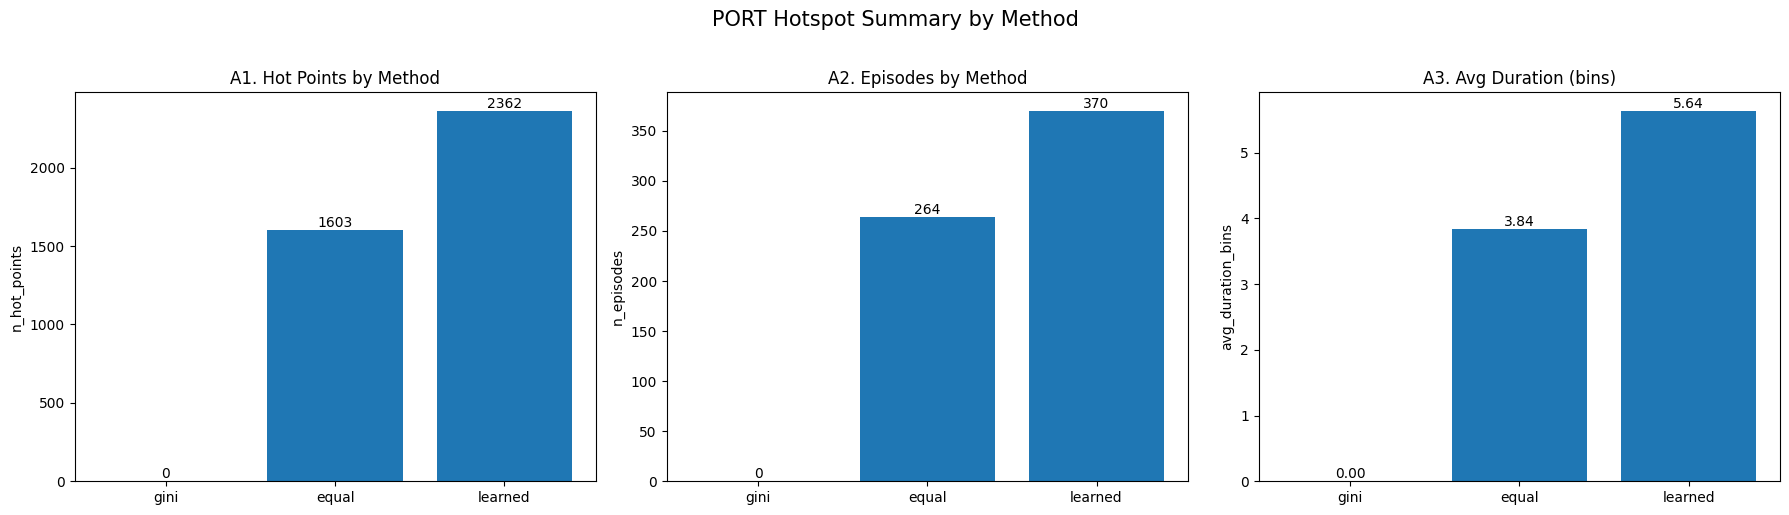


FIGURE A SOURCE TABLE
    method  n_hot_points  point_ratio  n_episodes  avg_duration_bins  \
0     gini             0     0.000000           0                NaN   
1    equal          1603     0.025353         264           3.844697   
2  learned          2362     0.037358         370           5.637838   

   median_duration_bins  avg_peak_score  max_peak_score  
0                   NaN             NaN             NaN  
1                   2.0        2.949317        8.625152  
2                   3.0        5.478022        7.182055  


/var/folders/v3/lqsz5m490hd47k0y02414k880000gn/T/ipykernel_27363/475845691.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_duration, labels=labels_duration)
/var/folders/v3/lqsz5m490hd47k0y02414k880000gn/T/ipykernel_27363/475845691.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_peak, labels=labels_peak)


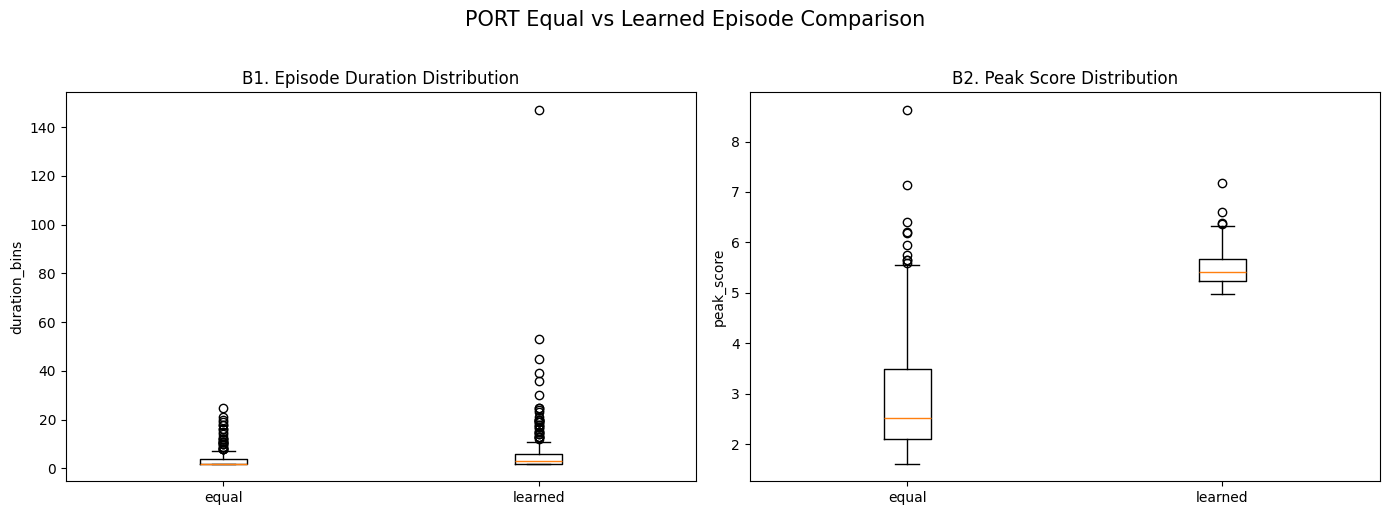


FIGURE B SUMMARY
equal episodes  : 264
learned episodes: 370

[equal duration describe]
count    264.000000
mean       3.844697
std        3.609574
min        2.000000
25%        2.000000
50%        2.000000
75%        4.000000
max       25.000000
Name: duration_bins, dtype: float64

[equal peak score describe]
count    264.000000
mean       2.949317
std        1.139858
min        1.613877
25%        2.105776
50%        2.526331
75%        3.495389
max        8.625152
Name: peak_score, dtype: float64

[learned duration describe]
count    370.000000
mean       5.637838
std        9.511863
min        2.000000
25%        2.000000
50%        3.000000
75%        5.750000
max      147.000000
Name: duration_bins, dtype: float64

[learned peak score describe]
count    370.000000
mean       5.478022
std        0.321435
min        4.984303
25%        5.235886
50%        5.407909
75%        5.674446
max        7.182055
Name: peak_score, dtype: float64


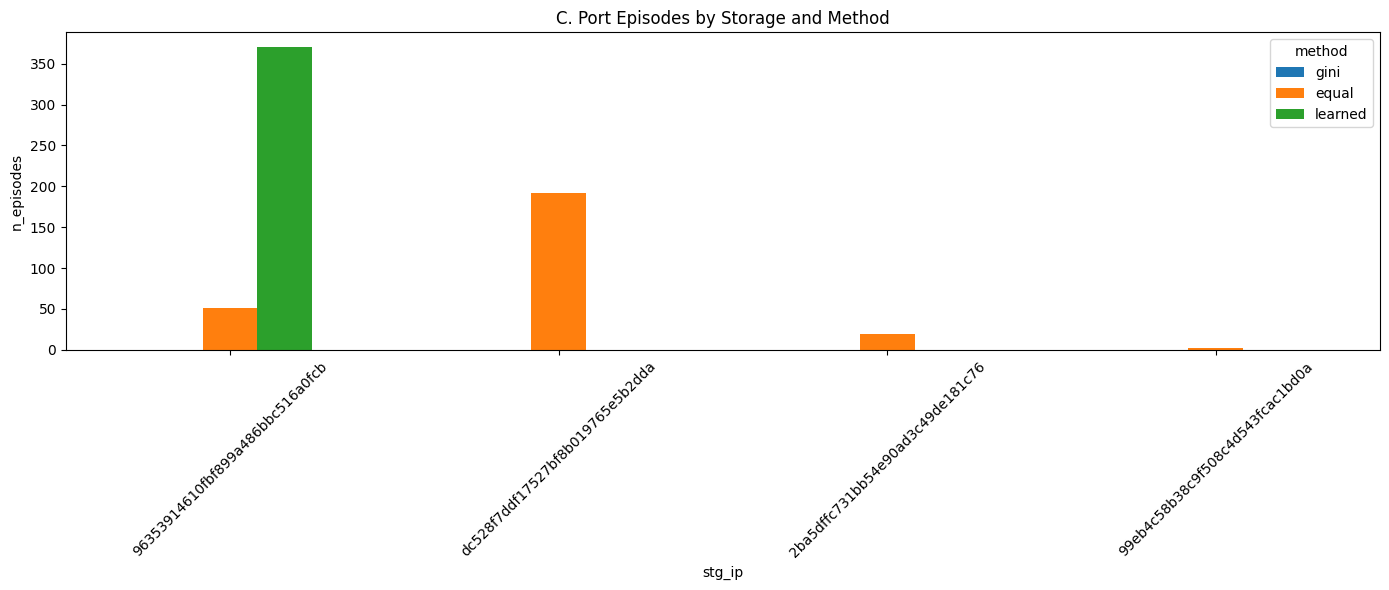


FIGURE C SOURCE TABLE
method                            gini  equal  learned
stg_ip                                                
96353914610fbf899a486bbc516a0fcb     0     51      370
dc528f7ddf17527bf8b019765e5b2dda     0    192        0
2ba5dffc731bb54e90ad3c49de181c76     0     19        0
99eb4c58b38c9f508c4d543fcac1bd0a     0      2        0


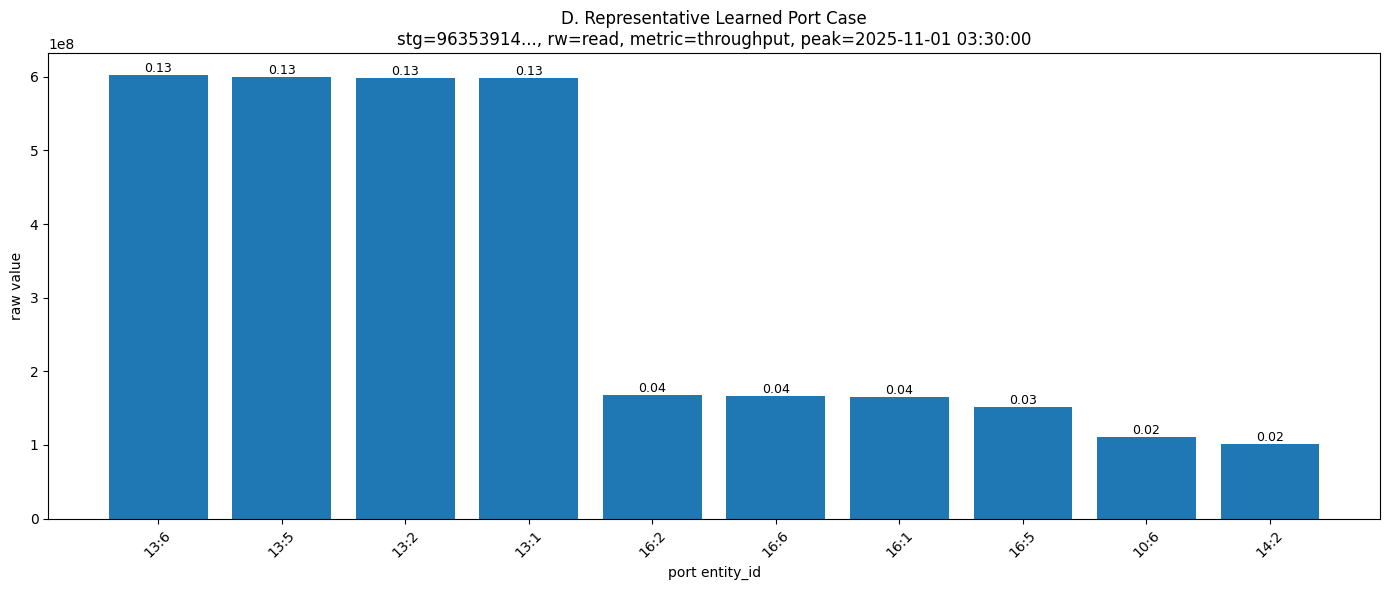


REPRESENTATIVE LEARNED PORT CASE
method                                             learned
stg_ip                    96353914610fbf899a486bbc516a0fcb
level                                                 port
rw                                                    read
src_metric                                      throughput
start_ts                               2025-10-30 23:00:00
end_ts                                 2025-11-03 01:30:00
peak_ts                                2025-11-01 03:30:00
peak_score                                        7.182055
raw_primary_port                                      13:6
raw_secondary_ports                             13:5, 13:2
raw_imbalance_port_set                    13:6, 13:5, 13:2
Name: 353, dtype: object

[TOP RAW PORTS @ PEAK]
        entity_id         value     share
2666065      13:6  6.019770e+08  0.134038
2666063      13:5  6.000377e+08  0.133606
2666057      13:2  5.980010e+08  0.133153
2666041      13:1  5.978013e+08  0.133108

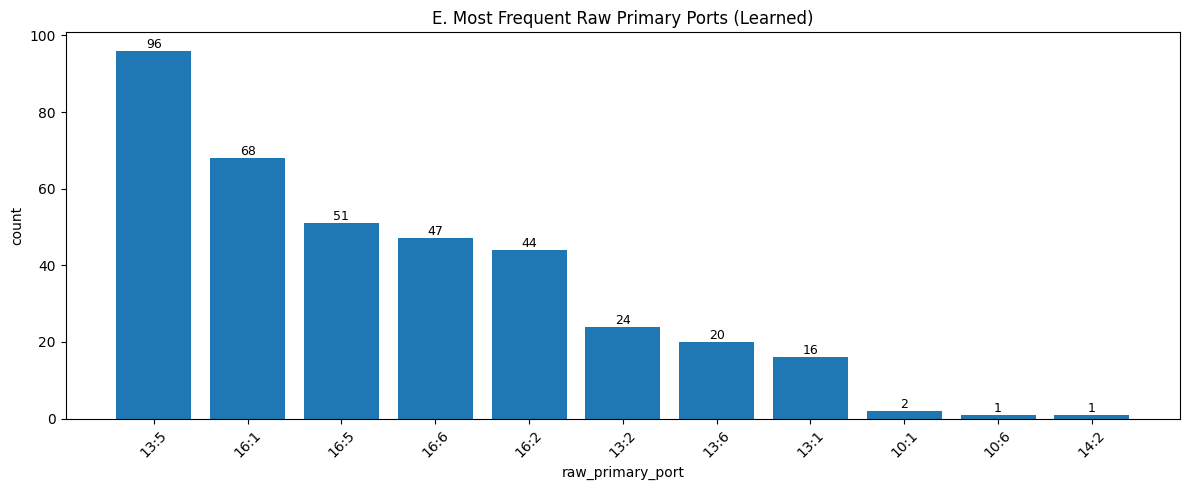


FIGURE E SOURCE TABLE
raw_primary_port
13:5    96
16:1    68
16:5    51
16:6    47
16:2    44
13:2    24
13:6    20
13:1    16
10:1     2
10:6     1
14:2     1
Name: count, dtype: int64


In [37]:
# ============================================================
# BLOCK 8-VIZ-SHOWONLY) PORT EXPERIMENT VISUALIZATION
# - 파일 저장 없음
# - 화면 출력만 수행
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) sanity check
# ------------------------------------------------------------
required_objs = [
    "port_episode_summary",
    "port_episode_df",
    "port_point_score_df",
    "port_project_long"
]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"❌ required object not found: {obj_name}")

if port_episode_summary is None or len(port_episode_summary) == 0:
    raise ValueError("❌ port_episode_summary is empty")

if port_episode_df is None or len(port_episode_df) == 0:
    raise ValueError("❌ port_episode_df is empty")

# ------------------------------------------------------------
# 1) normalize
# ------------------------------------------------------------
viz_summary = port_episode_summary.copy()
viz_eps = port_episode_df.copy()
viz_long = port_project_long.copy()

for df in [viz_summary, viz_eps, viz_long]:
    for c in ["method", "stg_ip", "level", "rw", "src_metric", "metric", "entity_id"]:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip().str.lower()
    for c in ["timestamp", "start_ts", "end_ts", "peak_ts"]:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")

method_order = ["gini", "equal", "learned"]
viz_summary["method"] = pd.Categorical(viz_summary["method"], categories=method_order, ordered=True)
viz_summary = viz_summary.sort_values("method").reset_index(drop=True)

# ------------------------------------------------------------
# 2) FIGURE A: method-level summary
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
bars = ax.bar(viz_summary["method"], viz_summary["n_hot_points"])
ax.set_title("A1. Hot Points by Method")
ax.set_ylabel("n_hot_points")
for b, v in zip(bars, viz_summary["n_hot_points"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{int(v)}",
            ha="center", va="bottom", fontsize=10)

ax = axes[1]
bars = ax.bar(viz_summary["method"], viz_summary["n_episodes"])
ax.set_title("A2. Episodes by Method")
ax.set_ylabel("n_episodes")
for b, v in zip(bars, viz_summary["n_episodes"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{int(v)}",
            ha="center", va="bottom", fontsize=10)

ax = axes[2]
bars = ax.bar(viz_summary["method"], viz_summary["avg_duration_bins"].fillna(0))
ax.set_title("A3. Avg Duration (bins)")
ax.set_ylabel("avg_duration_bins")
for b, v in zip(bars, viz_summary["avg_duration_bins"].fillna(0)):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.2f}",
            ha="center", va="bottom", fontsize=10)

fig.suptitle("PORT Hotspot Summary by Method", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# source table
print("\n" + "=" * 80)
print("FIGURE A SOURCE TABLE")
print("=" * 80)
print(viz_summary[[
    "method", "n_hot_points", "point_ratio", "n_episodes",
    "avg_duration_bins", "median_duration_bins",
    "avg_peak_score", "max_peak_score"
]])

# ------------------------------------------------------------
# 3) FIGURE B: equal vs learned distribution comparison
# ------------------------------------------------------------
eq_eps = viz_eps[viz_eps["method"] == "equal"].copy()
lr_eps = viz_eps[viz_eps["method"] == "learned"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
data_duration = []
labels_duration = []
if len(eq_eps) > 0:
    data_duration.append(eq_eps["duration_bins"].dropna().astype(float).values)
    labels_duration.append("equal")
if len(lr_eps) > 0:
    data_duration.append(lr_eps["duration_bins"].dropna().astype(float).values)
    labels_duration.append("learned")
if len(data_duration) > 0:
    ax.boxplot(data_duration, labels=labels_duration)
ax.set_title("B1. Episode Duration Distribution")
ax.set_ylabel("duration_bins")

ax = axes[1]
data_peak = []
labels_peak = []
if len(eq_eps) > 0:
    data_peak.append(eq_eps["peak_score"].dropna().astype(float).values)
    labels_peak.append("equal")
if len(lr_eps) > 0:
    data_peak.append(lr_eps["peak_score"].dropna().astype(float).values)
    labels_peak.append("learned")
if len(data_peak) > 0:
    ax.boxplot(data_peak, labels=labels_peak)
ax.set_title("B2. Peak Score Distribution")
ax.set_ylabel("peak_score")

fig.suptitle("PORT Equal vs Learned Episode Comparison", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("FIGURE B SUMMARY")
print("=" * 80)
print("equal episodes  :", len(eq_eps))
print("learned episodes:", len(lr_eps))
if len(eq_eps) > 0:
    print("\n[equal duration describe]")
    print(eq_eps["duration_bins"].describe())
    print("\n[equal peak score describe]")
    print(eq_eps["peak_score"].describe())
if len(lr_eps) > 0:
    print("\n[learned duration describe]")
    print(lr_eps["duration_bins"].describe())
    print("\n[learned peak score describe]")
    print(lr_eps["peak_score"].describe())

# ------------------------------------------------------------
# 4) FIGURE C: storage-level episode counts
# ------------------------------------------------------------
by_stg_method = (
    viz_eps.groupby(["stg_ip", "method"], observed=True)
    .size()
    .reset_index(name="n_episodes")
)

if not by_stg_method.empty:
    stg_total = (
        by_stg_method.groupby("stg_ip", observed=True)["n_episodes"]
        .sum()
        .sort_values(ascending=False)
    )
    top_stg = stg_total.head(10).index.tolist()

    plot_df = by_stg_method[by_stg_method["stg_ip"].isin(top_stg)].copy()
    pivot_df = plot_df.pivot_table(
        index="stg_ip",
        columns="method",
        values="n_episodes",
        aggfunc="sum",
        fill_value=0,
        observed=True
    )
    pivot_df = pivot_df.reindex(columns=method_order, fill_value=0)
    pivot_df = pivot_df.loc[stg_total.loc[top_stg].index]

    pivot_df.plot(kind="bar", figsize=(14, 6))
    plt.title("C. Port Episodes by Storage and Method")
    plt.ylabel("n_episodes")
    plt.xlabel("stg_ip")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 80)
    print("FIGURE C SOURCE TABLE")
    print("=" * 80)
    print(pivot_df)

# ------------------------------------------------------------
# 5) FIGURE D: representative learned case raw port distribution
# ------------------------------------------------------------
learned_eps = viz_eps[viz_eps["method"] == "learned"].copy()

if len(learned_eps) > 0:
    rep = learned_eps.sort_values(["peak_score", "duration_bins"], ascending=[False, False]).iloc[0]

    rep_stg = str(rep["stg_ip"]).lower()
    rep_level = str(rep["level"]).lower()
    rep_rw = str(rep["rw"]).lower()
    rep_src_metric = str(rep["src_metric"]).lower()
    rep_peak_ts = pd.to_datetime(rep["peak_ts"])

    ts_list = viz_long["timestamp"].dropna().drop_duplicates().sort_values().reset_index(drop=True)
    ts_set = set(ts_list.tolist())
    if rep_peak_ts not in ts_set:
        rep_peak_ts = ts_list.iloc[(ts_list - rep_peak_ts).abs().argmin()]

    rep_raw = viz_long[
        (viz_long["timestamp"] == rep_peak_ts) &
        (viz_long["stg_ip"] == rep_stg) &
        (viz_long["level"] == rep_level) &
        (viz_long["rw"] == rep_rw) &
        (viz_long["metric"] == rep_src_metric) &
        (viz_long["entity_id"] != "group")
    ].copy()

    if not rep_raw.empty:
        rep_raw["value"] = pd.to_numeric(rep_raw["value"], errors="coerce")
        rep_raw = rep_raw.dropna(subset=["value"]).sort_values("value", ascending=False).copy()

        total = float(rep_raw["value"].sum())
        rep_raw["share"] = rep_raw["value"] / total if total > 0 else 0.0

        topk = rep_raw.head(10).copy()

        plt.figure(figsize=(14, 6))
        bars = plt.bar(topk["entity_id"].astype(str), topk["value"].astype(float))
        plt.title(
            f"D. Representative Learned Port Case\n"
            f"stg={rep_stg[:8]}..., rw={rep_rw}, metric={rep_src_metric}, peak={rep_peak_ts}"
        )
        plt.ylabel("raw value")
        plt.xlabel("port entity_id")
        plt.xticks(rotation=45)

        for b, (_, row) in zip(bars, topk.iterrows()):
            plt.text(
                b.get_x() + b.get_width()/2,
                b.get_height(),
                f"{row['share']:.2f}",
                ha="center",
                va="bottom",
                fontsize=9
            )

        plt.tight_layout()
        plt.show()

        print("\n" + "=" * 80)
        print("REPRESENTATIVE LEARNED PORT CASE")
        print("=" * 80)
        print(rep[[
            "method", "stg_ip", "level", "rw", "src_metric",
            "start_ts", "end_ts", "peak_ts", "peak_score",
            "raw_primary_port", "raw_secondary_ports", "raw_imbalance_port_set"
        ]])

        print("\n[TOP RAW PORTS @ PEAK]")
        print(topk[["entity_id", "value", "share"]].head(10))

# ------------------------------------------------------------
# 6) FIGURE E: learned primary port frequency
# ------------------------------------------------------------
if "raw_primary_port" in viz_eps.columns:
    learned_primary = viz_eps[viz_eps["method"] == "learned"].copy()

    port_count = (
        learned_primary["raw_primary_port"]
        .fillna("")
        .astype(str)
        .str.strip()
        .value_counts()
    )

    port_count = port_count[port_count.index != ""].head(15)

    if len(port_count) > 0:
        plt.figure(figsize=(12, 5))
        bars = plt.bar(port_count.index.astype(str), port_count.values.astype(int))
        plt.title("E. Most Frequent Raw Primary Ports (Learned)")
        plt.ylabel("count")
        plt.xlabel("raw_primary_port")
        plt.xticks(rotation=45)

        for b, v in zip(bars, port_count.values):
            plt.text(
                b.get_x() + b.get_width()/2,
                b.get_height(),
                f"{int(v)}",
                ha="center",
                va="bottom",
                fontsize=9
            )

        plt.tight_layout()
        plt.show()

        print("\n" + "=" * 80)
        print("FIGURE E SOURCE TABLE")
        print("=" * 80)
        print(port_count)

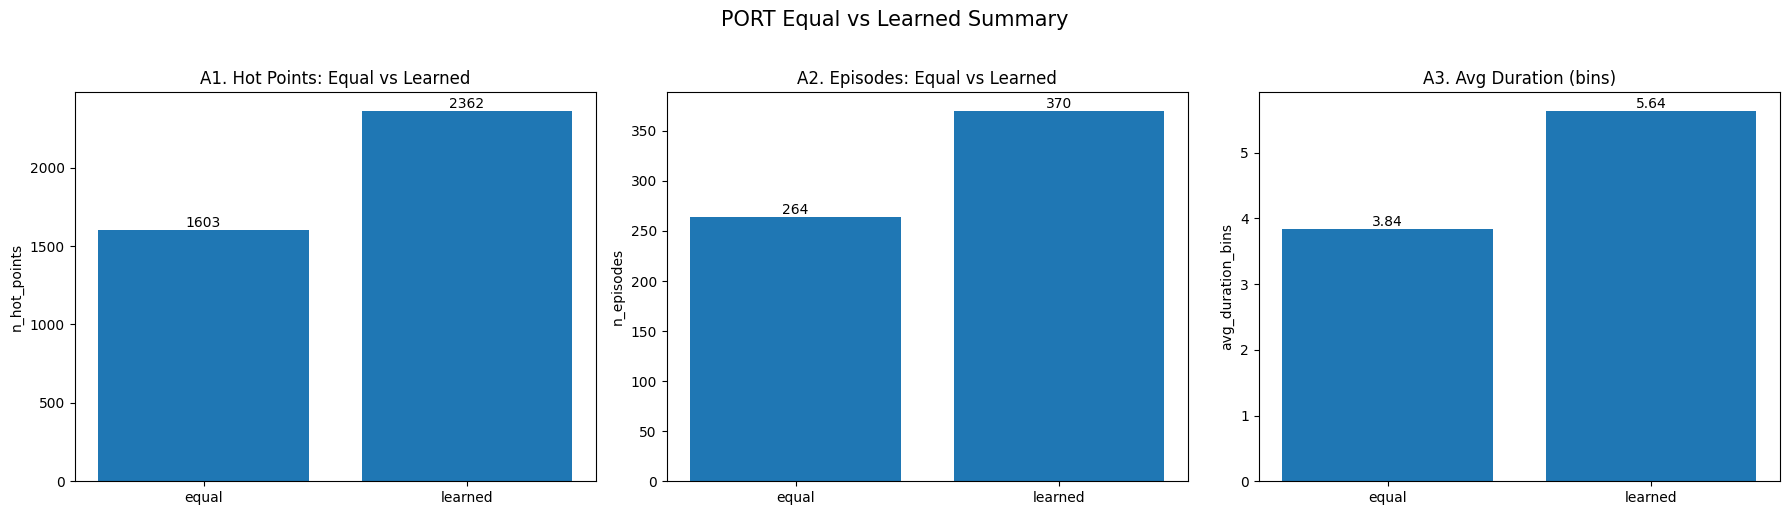


SUMMARY TABLE (EQUAL VS LEARNED)
    method  n_hot_points  point_ratio  n_episodes  avg_duration_bins  \
0    equal          1603     0.025353         264           3.844697   
1  learned          2362     0.037358         370           5.637838   

   median_duration_bins  avg_peak_score  max_peak_score  
0                   2.0        2.949317        8.625152  
1                   3.0        5.478022        7.182055  


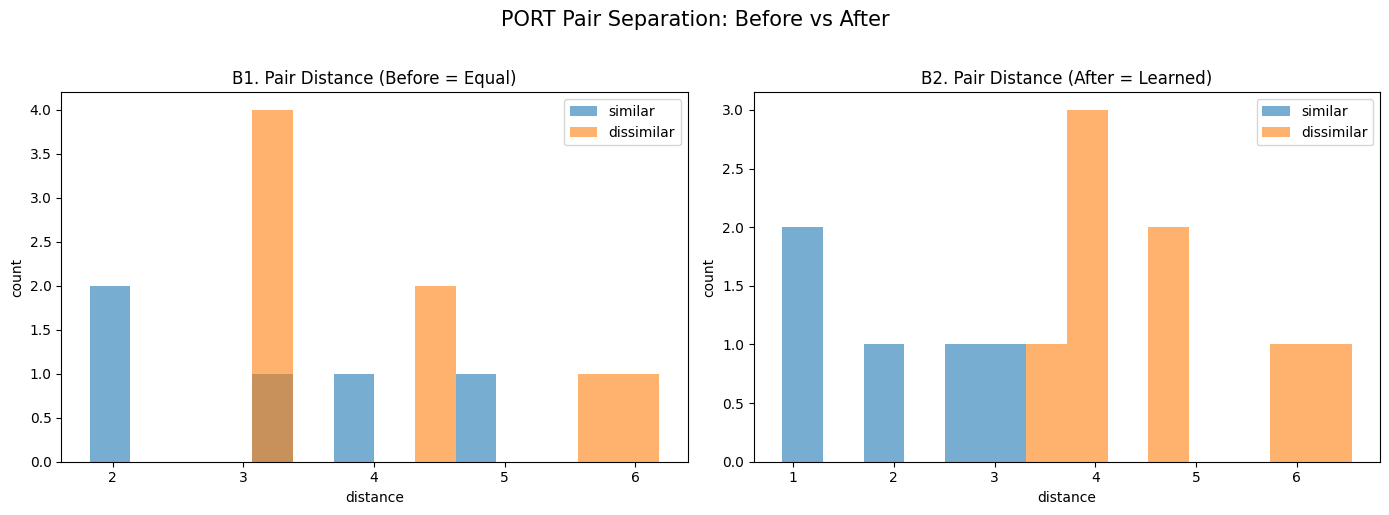


PAIR DISTANCE SUMMARY
           space  similar_mean  dissimilar_mean  gap_neg_minus_pos
0   before_equal      3.094362         4.223974           1.129612
1  after_learned      1.883812         4.666158           2.782346


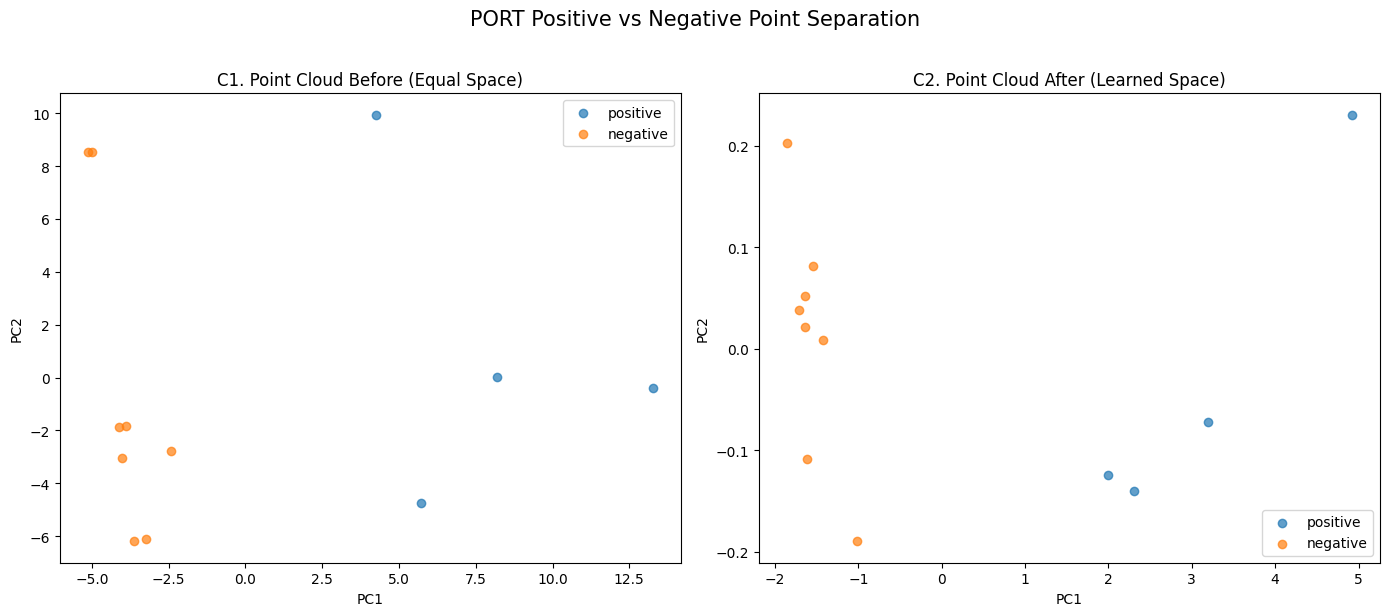

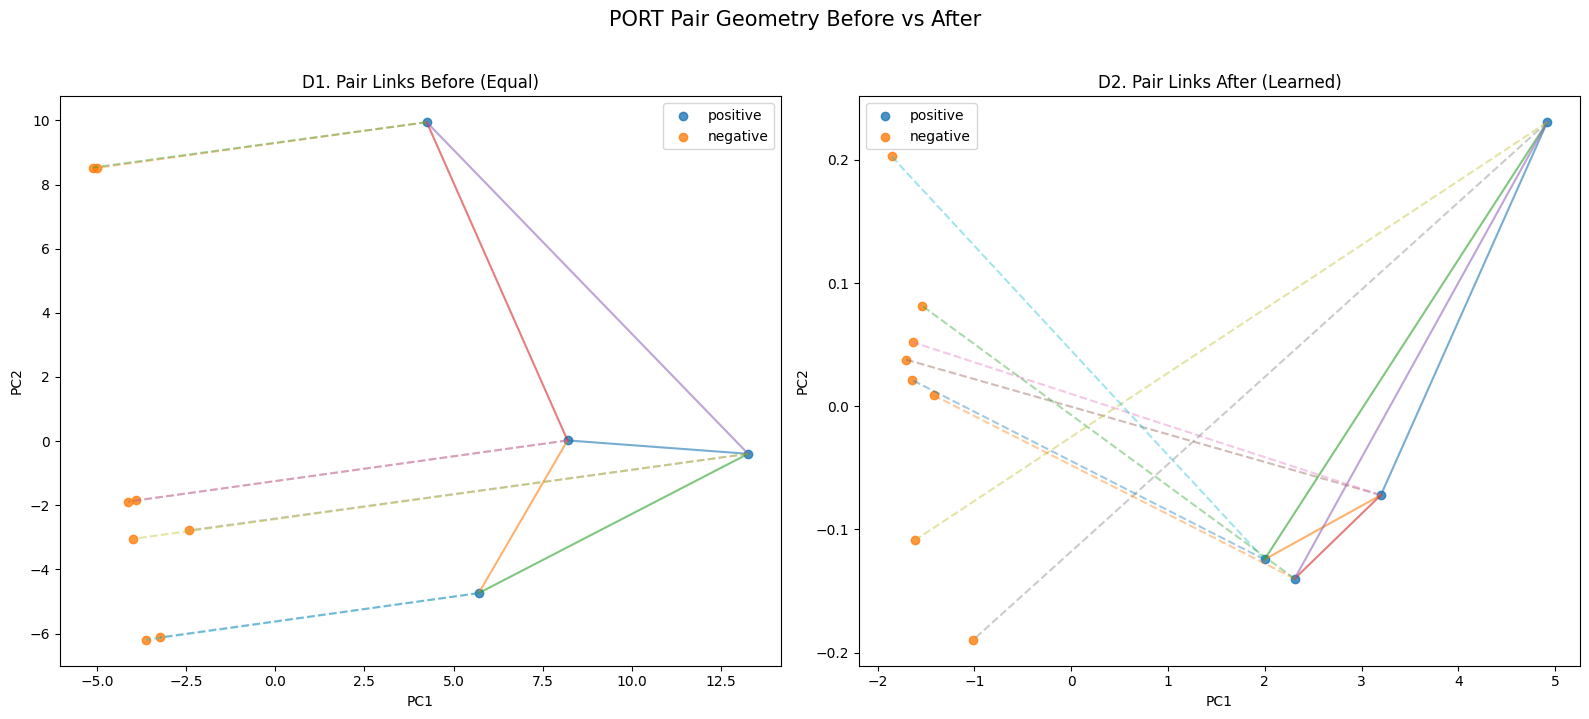


POINT ROLE COUNTS
sample_role
negative    8
positive    4
Name: count, dtype: int64

PAIR TYPE COUNTS
pair_type
dissimilar    8
similar       5
Name: count, dtype: int64


In [38]:
# ============================================================
# BLOCK 8-VIZ-PAIR) PORT equal vs learned visualization
# - 파일 저장 없음
# - 화면 출력만
# - pair separation before / after 포함
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 0) sanity check
# ------------------------------------------------------------
required_objs = [
    "port_episode_summary",
    "port_episode_df",
    "port_train_samples",
    "port_pair_table",
    "PORT_WL_FEATURE_COLS",
    "port_med",
    "port_mad",
    "port_w",
    "PORT_w_equal"
]
for obj_name in required_objs:
    if obj_name not in globals():
        raise ValueError(f"❌ required object not found: {obj_name}")

if len(port_pair_table) == 0:
    raise ValueError("❌ port_pair_table is empty")

# ------------------------------------------------------------
# 1) normalize copies
# ------------------------------------------------------------
viz_summary = port_episode_summary.copy()
viz_eps = port_episode_df.copy()
viz_samples = port_train_samples.copy()
viz_pairs = port_pair_table.copy()

for df in [viz_summary, viz_eps, viz_samples, viz_pairs]:
    for c in ["method", "stg_ip", "level", "rw", "src_metric", "pair_type", "sample_role"]:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip().str.lower()
    for c in ["timestamp", "start_ts", "end_ts", "peak_ts"]:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")

# ------------------------------------------------------------
# 2) method summary: equal vs learned only
# ------------------------------------------------------------
summary2 = viz_summary[viz_summary["method"].isin(["equal", "learned"])].copy()
summary2["method"] = pd.Categorical(summary2["method"], categories=["equal", "learned"], ordered=True)
summary2 = summary2.sort_values("method").reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# hot points
ax = axes[0]
bars = ax.bar(summary2["method"], summary2["n_hot_points"])
ax.set_title("A1. Hot Points: Equal vs Learned")
ax.set_ylabel("n_hot_points")
for b, v in zip(bars, summary2["n_hot_points"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{int(v)}",
            ha="center", va="bottom", fontsize=10)

# episodes
ax = axes[1]
bars = ax.bar(summary2["method"], summary2["n_episodes"])
ax.set_title("A2. Episodes: Equal vs Learned")
ax.set_ylabel("n_episodes")
for b, v in zip(bars, summary2["n_episodes"]):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{int(v)}",
            ha="center", va="bottom", fontsize=10)

# avg duration
ax = axes[2]
bars = ax.bar(summary2["method"], summary2["avg_duration_bins"].fillna(0))
ax.set_title("A3. Avg Duration (bins)")
ax.set_ylabel("avg_duration_bins")
for b, v in zip(bars, summary2["avg_duration_bins"].fillna(0)):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{v:.2f}",
            ha="center", va="bottom", fontsize=10)

fig.suptitle("PORT Equal vs Learned Summary", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("SUMMARY TABLE (EQUAL VS LEARNED)")
print("=" * 80)
print(summary2[[
    "method", "n_hot_points", "point_ratio", "n_episodes",
    "avg_duration_bins", "median_duration_bins",
    "avg_peak_score", "max_peak_score"
]])

# ------------------------------------------------------------
# 3) pair distance before / after
#    before = equal weight
#    after  = learned weight
# ------------------------------------------------------------
# robust scale
X_raw = viz_samples[PORT_WL_FEATURE_COLS].copy().fillna(0.0)
X_scaled = ((X_raw - port_med) / port_mad).fillna(0.0)

for c in PORT_WL_FEATURE_COLS:
    viz_samples[f"scaled__{c}"] = X_scaled[c].values

PORT_SCALED_COLS = [f"scaled__{c}" for c in PORT_WL_FEATURE_COLS]

feat_map = {
    int(idx): row.values.astype(float)
    for idx, row in viz_samples.set_index("point_id")[PORT_SCALED_COLS].iterrows()
}

pair_rows = []
for row in viz_pairs.itertuples(index=False):
    li = int(row.left_point_id)
    ri = int(row.right_point_id)
    if li not in feat_map or ri not in feat_map:
        continue

    xi = feat_map[li]
    xj = feat_map[ri]

    dist_equal = np.sqrt(np.sum(((xi - xj) ** 2) * PORT_w_equal))
    dist_learned = np.sqrt(np.sum(((xi - xj) ** 2) * port_w))

    pair_rows.append({
        "pair_type": str(row.pair_type).lower(),
        "y": int(row.y),
        "dist_equal": float(dist_equal),
        "dist_learned": float(dist_learned)
    })

pair_dist_df = pd.DataFrame(pair_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# before
ax = axes[0]
sim_before = pair_dist_df.loc[pair_dist_df["pair_type"] == "similar", "dist_equal"].values
dis_before = pair_dist_df.loc[pair_dist_df["pair_type"] == "dissimilar", "dist_equal"].values

bins_before = np.linspace(
    min(pair_dist_df["dist_equal"].min(), pair_dist_df["dist_equal"].min()),
    max(pair_dist_df["dist_equal"].max(), pair_dist_df["dist_equal"].max()),
    15
) if len(pair_dist_df) > 0 else 10

ax.hist(sim_before, bins=bins_before, alpha=0.6, label="similar")
ax.hist(dis_before, bins=bins_before, alpha=0.6, label="dissimilar")
ax.set_title("B1. Pair Distance (Before = Equal)")
ax.set_xlabel("distance")
ax.set_ylabel("count")
ax.legend()

# after
ax = axes[1]
sim_after = pair_dist_df.loc[pair_dist_df["pair_type"] == "similar", "dist_learned"].values
dis_after = pair_dist_df.loc[pair_dist_df["pair_type"] == "dissimilar", "dist_learned"].values

bins_after = np.linspace(
    min(pair_dist_df["dist_learned"].min(), pair_dist_df["dist_learned"].min()),
    max(pair_dist_df["dist_learned"].max(), pair_dist_df["dist_learned"].max()),
    15
) if len(pair_dist_df) > 0 else 10

ax.hist(sim_after, bins=bins_after, alpha=0.6, label="similar")
ax.hist(dis_after, bins=bins_after, alpha=0.6, label="dissimilar")
ax.set_title("B2. Pair Distance (After = Learned)")
ax.set_xlabel("distance")
ax.set_ylabel("count")
ax.legend()

fig.suptitle("PORT Pair Separation: Before vs After", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# pair summary numbers
pair_summary = pd.DataFrame([
    {
        "space": "before_equal",
        "similar_mean": np.mean(sim_before) if len(sim_before) else np.nan,
        "dissimilar_mean": np.mean(dis_before) if len(dis_before) else np.nan,
        "gap_neg_minus_pos": (np.mean(dis_before) - np.mean(sim_before)) if len(sim_before) and len(dis_before) else np.nan
    },
    {
        "space": "after_learned",
        "similar_mean": np.mean(sim_after) if len(sim_after) else np.nan,
        "dissimilar_mean": np.mean(dis_after) if len(dis_after) else np.nan,
        "gap_neg_minus_pos": (np.mean(dis_after) - np.mean(sim_after)) if len(sim_after) and len(dis_after) else np.nan
    }
])

print("\n" + "=" * 80)
print("PAIR DISTANCE SUMMARY")
print("=" * 80)
print(pair_summary)

# ------------------------------------------------------------
# 4) point cloud before / after
#    - pair에 등장한 point만 추출
#    - positive / negative 역할로 색 구분
# ------------------------------------------------------------
used_ids = sorted(set(viz_pairs["left_point_id"].tolist()) | set(viz_pairs["right_point_id"].tolist()))
cloud_df = viz_samples[viz_samples["point_id"].isin(used_ids)].copy()

# point role: positive / negative
if "sample_role" not in cloud_df.columns:
    cloud_df["sample_role"] = "unknown"

X_cloud_before = cloud_df[PORT_SCALED_COLS].to_numpy(float)
X_cloud_after = X_cloud_before * np.sqrt(port_w.reshape(1, -1))

# PCA
pca_before = PCA(n_components=2)
pca_after = PCA(n_components=2)

Z_before = pca_before.fit_transform(X_cloud_before)
Z_after = pca_after.fit_transform(X_cloud_after)

cloud_df["pc1_before"] = Z_before[:, 0]
cloud_df["pc2_before"] = Z_before[:, 1]
cloud_df["pc1_after"] = Z_after[:, 0]
cloud_df["pc2_after"] = Z_after[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# before
ax = axes[0]
for role in ["positive", "negative"]:
    sub = cloud_df[cloud_df["sample_role"] == role]
    if len(sub) == 0:
        continue
    ax.scatter(sub["pc1_before"], sub["pc2_before"], label=role, alpha=0.7)
ax.set_title("C1. Point Cloud Before (Equal Space)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()

# after
ax = axes[1]
for role in ["positive", "negative"]:
    sub = cloud_df[cloud_df["sample_role"] == role]
    if len(sub) == 0:
        continue
    ax.scatter(sub["pc1_after"], sub["pc2_after"], label=role, alpha=0.7)
ax.set_title("C2. Point Cloud After (Learned Space)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()

fig.suptitle("PORT Positive vs Negative Point Separation", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5) pair connection plot (optional, direct visual separation)
#    similar = solid
#    dissimilar = dashed
# ------------------------------------------------------------
# point_id -> projected coords
coord_after = cloud_df.set_index("point_id")[["pc1_after", "pc2_after"]].to_dict("index")
coord_before = cloud_df.set_index("point_id")[["pc1_before", "pc2_before"]].to_dict("index")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# before
ax = axes[0]
for role in ["positive", "negative"]:
    sub = cloud_df[cloud_df["sample_role"] == role]
    if len(sub) > 0:
        ax.scatter(sub["pc1_before"], sub["pc2_before"], label=role, alpha=0.8)

for row in viz_pairs.itertuples(index=False):
    li = int(row.left_point_id)
    ri = int(row.right_point_id)
    if li not in coord_before or ri not in coord_before:
        continue

    x1, y1 = coord_before[li]["pc1_before"], coord_before[li]["pc2_before"]
    x2, y2 = coord_before[ri]["pc1_before"], coord_before[ri]["pc2_before"]

    style = "-" if str(row.pair_type).lower() == "similar" else "--"
    alpha = 0.6 if str(row.pair_type).lower() == "similar" else 0.4
    ax.plot([x1, x2], [y1, y2], linestyle=style, alpha=alpha)

ax.set_title("D1. Pair Links Before (Equal)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()

# after
ax = axes[1]
for role in ["positive", "negative"]:
    sub = cloud_df[cloud_df["sample_role"] == role]
    if len(sub) > 0:
        ax.scatter(sub["pc1_after"], sub["pc2_after"], label=role, alpha=0.8)

for row in viz_pairs.itertuples(index=False):
    li = int(row.left_point_id)
    ri = int(row.right_point_id)
    if li not in coord_after or ri not in coord_after:
        continue

    x1, y1 = coord_after[li]["pc1_after"], coord_after[li]["pc2_after"]
    x2, y2 = coord_after[ri]["pc1_after"], coord_after[ri]["pc2_after"]

    style = "-" if str(row.pair_type).lower() == "similar" else "--"
    alpha = 0.6 if str(row.pair_type).lower() == "similar" else 0.4
    ax.plot([x1, x2], [y1, y2], linestyle=style, alpha=alpha)

ax.set_title("D2. Pair Links After (Learned)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()

fig.suptitle("PORT Pair Geometry Before vs After", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6) source prints
# ------------------------------------------------------------
print("\n" + "=" * 80)
print("POINT ROLE COUNTS")
print("=" * 80)
print(cloud_df["sample_role"].value_counts(dropna=False))

print("\n" + "=" * 80)
print("PAIR TYPE COUNTS")
print("=" * 80)
print(viz_pairs["pair_type"].value_counts(dropna=False))

FINAL_COMPARE_OUT_DIR = /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/final_compare_node_port_psd
node_psd_hot_col = score_psd_learned_hot q95 = 5.194315894948617
port_psd_hot_col = score_psd_learned_hot q95 = 41.82673423072801
✅ tables saved


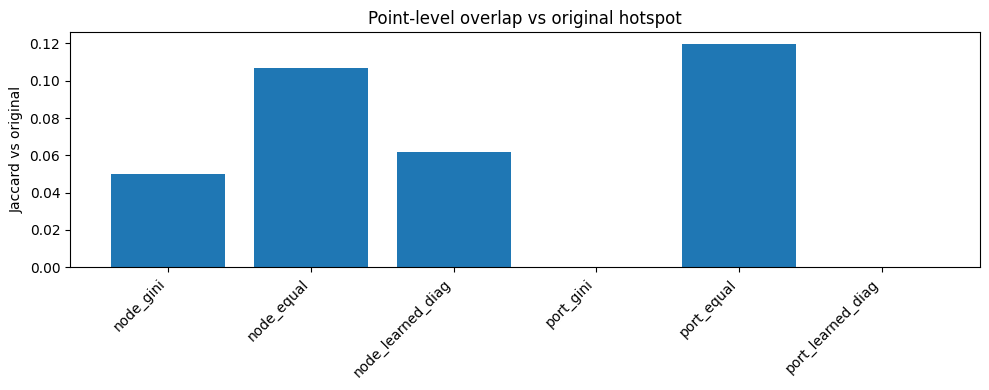

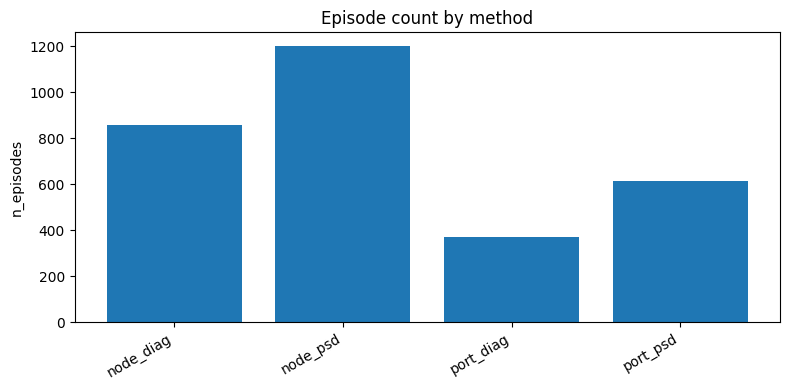

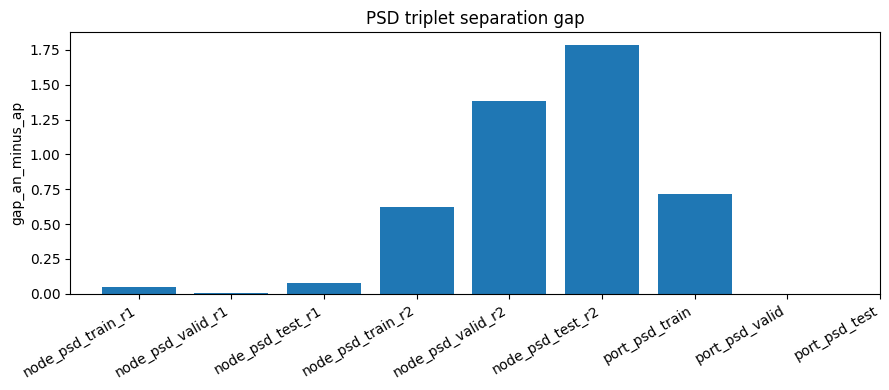

FINAL METHOD SUMMARY
       scope  n_points  hot_ratio  score_mean_hot  score_p95_hot  n_episodes  \
0  node_diag      4690   0.024393        8.459888      14.652625         859   
1   node_psd      8530   0.044366        6.619125      12.879251        1200   
2  port_diag      2362   0.037358        5.316517       5.951160         370   
3   port_psd      3424   0.054155       49.248140      60.949624         613   

   gap_an_minus_ap_test_r1  gap_an_minus_ap_test_r2  gap_an_minus_ap_train_r1  \
0                      NaN                      NaN                       NaN   
1                  0.08016                 1.786706                  0.048742   
2                      NaN                      NaN                       NaN   
3                      NaN                      NaN                       NaN   

   gap_an_minus_ap_train_r2  gap_an_minus_ap_valid_r1  \
0                       NaN                       NaN   
1                  0.620592                   0.00224   
2

In [49]:
# ============================================================
# BLOCK 8-F) FINAL COMPARISON + NODE/PORT COMBINE (STABLE)
# - node diagonal vs node PSD
# - port diagonal vs port PSD
# - node + port final hotspot point / episode combine
# - stable version: no MultiIndex merge error
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# 0) output dir
# ------------------------------------------------------------
FINAL_COMPARE_OUT_DIR = OUTPUT_DIR / "final_compare_node_port_psd"
FINAL_COMPARE_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("FINAL_COMPARE_OUT_DIR =", FINAL_COMPARE_OUT_DIR)
print("=" * 80)

# ------------------------------------------------------------
# 1) helper
# ------------------------------------------------------------
def _safe_exists(name):
    return name in globals() and globals()[name] is not None

def _copy_df(name):
    if _safe_exists(name):
        obj = globals()[name]
        if isinstance(obj, pd.DataFrame):
            return obj.copy()
    return None

def _normalize_str_cols(df, cols):
    x = df.copy()
    for c in cols:
        if c in x.columns:
            x[c] = x[c].astype(str).str.strip().str.lower()
    return x

def _normalize_time_cols(df, cols):
    x = df.copy()
    for c in cols:
        if c in x.columns:
            x[c] = pd.to_datetime(x[c], errors="coerce")
    return x

def _flatten_columns(df):
    x = df.copy()
    if isinstance(x.columns, pd.MultiIndex):
        new_cols = []
        for col in x.columns:
            parts = [str(c) for c in col if str(c) != "" and str(c) != "nan"]
            new_cols.append("_".join(parts))
        x.columns = new_cols
    else:
        x.columns = [str(c) for c in x.columns]
    return x

def _ensure_hot_col(df, score_col, split_col="split", q=0.95):
    """
    score_col이 있고 {score_col}_hot 이 없으면 valid q95 기준으로 생성
    """
    x = df.copy()
    hot_col = f"{score_col}_hot"

    if hot_col in x.columns:
        qcol = f"{score_col}_q95"
        qv = x[qcol].iloc[0] if qcol in x.columns and len(x) > 0 else np.nan
        return x, hot_col, qv

    if score_col not in x.columns:
        raise ValueError(f"missing score col: {score_col}")

    if split_col in x.columns:
        base = x.loc[x[split_col] == "valid", score_col].dropna().astype(float)
        if len(base) == 0:
            base = x[score_col].dropna().astype(float)
    else:
        base = x[score_col].dropna().astype(float)

    qv = float(base.quantile(q)) if len(base) > 0 else np.nan
    x[f"{score_col}_q95"] = qv
    x[hot_col] = (pd.to_numeric(x[score_col], errors="coerce") >= qv).astype(int)
    return x, hot_col, qv

def _point_compare_against_original(df, method_name, hot_col, original_col="original_hot"):
    if df is None or len(df) == 0 or hot_col not in df.columns or original_col not in df.columns:
        return None

    orig = df[original_col].fillna(0).astype(int).values
    pred = df[hot_col].fillna(0).astype(int).values

    inter = int(((orig == 1) & (pred == 1)).sum())
    union = int(((orig == 1) | (pred == 1)).sum())
    jacc = inter / union if union > 0 else np.nan

    return {
        "method": method_name,
        "overlap_points": inter,
        "union_points": union,
        "jaccard_vs_original": jacc,
        "new_only_points": int(((orig == 0) & (pred == 1)).sum()),
        "missed_original_points": int(((orig == 1) & (pred == 0)).sum()),
        "n_original_hot_points": int(orig.sum()),
        "n_method_hot_points": int(pred.sum()),
    }

def _extract_episodes_generic(df, score_col, hot_col,
                              entity_col="episode_entity",
                              time_col="timestamp",
                              min_bins=2,
                              gap_allow_min=60,
                              method_name=None):
    x = df[[entity_col, "stg_ip", "level", "rw", "src_metric", time_col, score_col, hot_col]].copy()
    x[time_col] = pd.to_datetime(x[time_col], errors="coerce")
    x = x.dropna(subset=[entity_col, time_col]).sort_values([entity_col, time_col]).reset_index(drop=True)

    rows = []
    allow_gap = pd.Timedelta(minutes=gap_allow_min)

    for ent, g in x.groupby(entity_col):
        hot = g[g[hot_col] == 1].copy()
        if hot.empty:
            continue

        hot["gap"] = hot[time_col].diff()
        hot["new_ep"] = ((hot["gap"].isna()) | (hot["gap"] > allow_gap)).astype(int)
        hot["ep_id"] = hot["new_ep"].cumsum()

        for _, ge in hot.groupby("ep_id"):
            if len(ge) < min_bins:
                continue

            peak_idx = ge[score_col].idxmax()
            peak_row = ge.loc[peak_idx]

            rows.append({
                "method": method_name if method_name is not None else score_col.replace("score_", ""),
                "episode_entity": ent,
                "stg_ip": str(peak_row["stg_ip"]).lower(),
                "level": str(peak_row["level"]).lower(),
                "rw": str(peak_row["rw"]).lower(),
                "src_metric": str(peak_row["src_metric"]).lower(),
                "start_ts": ge[time_col].min(),
                "end_ts": ge[time_col].max(),
                "duration_bins": int(len(ge)),
                "peak_ts": peak_row[time_col],
                "peak_score": float(peak_row[score_col]),
                "n_points_in_episode": int(len(ge))
            })

    return pd.DataFrame(rows)

def _episode_key(df):
    if df is None or len(df) == 0:
        return set()
    return set(
        zip(
            df["episode_entity"].astype(str),
            pd.to_datetime(df["start_ts"]).astype(str),
            pd.to_datetime(df["end_ts"]).astype(str)
        )
    )

def _compare_episode_sets(left_df, right_df, left_name, right_name):
    lk = _episode_key(left_df)
    rk = _episode_key(right_df)
    return {
        "compare": f"{left_name}_vs_{right_name}",
        "left_episode_count": len(lk),
        "right_episode_count": len(rk),
        "overlap_episode_count": len(lk & rk),
        "left_only_episode_count": len(lk - rk),
        "right_only_episode_count": len(rk - lk),
    }

def _make_episode_entity_if_missing(df):
    x = df.copy()
    if "episode_entity" not in x.columns:
        x["episode_entity"] = (
            x["stg_ip"].astype(str) + "|" +
            x["rw"].astype(str) + "|" +
            x["src_metric"].astype(str)
        )
    return x

def _describe_hotspots(df, hot_col, score_col, scope_name):
    if df is None or len(df) == 0 or hot_col not in df.columns:
        return {
            "scope": scope_name,
            "n_points": 0,
            "hot_ratio": np.nan,
            "score_mean_hot": np.nan,
            "score_p95_hot": np.nan
        }

    hot = df[df[hot_col] == 1].copy()
    if hot.empty:
        return {
            "scope": scope_name,
            "n_points": 0,
            "hot_ratio": 0.0,
            "score_mean_hot": np.nan,
            "score_p95_hot": np.nan
        }

    s = pd.to_numeric(hot[score_col], errors="coerce").dropna()
    return {
        "scope": scope_name,
        "n_points": int(len(hot)),
        "hot_ratio": float((df[hot_col] == 1).mean()),
        "score_mean_hot": float(s.mean()) if len(s) else np.nan,
        "score_p95_hot": float(s.quantile(0.95)) if len(s) else np.nan
    }

def _eval_wide_from_psd_summary(psd_eval_df, scope_name):
    if psd_eval_df is None or len(psd_eval_df) == 0:
        return pd.DataFrame(columns=["scope"])

    x = psd_eval_df.copy()
    x["scope"] = scope_name

    wide = (
        x[["scope", "split", "gap_an_minus_ap", "triplet_acc"]]
        .pivot_table(
            index="scope",
            columns="split",
            values=["gap_an_minus_ap", "triplet_acc"],
            aggfunc="first"
        )
        .reset_index()
    )
    wide = _flatten_columns(wide)
    return wide

# ------------------------------------------------------------
# 2) load node / port base tables
# ------------------------------------------------------------
node_point_diag = _copy_df("point_score_df")
port_point_diag = _copy_df("port_point_score_df")

node_episode_diag = _copy_df("episode_df")
port_episode_diag = _copy_df("port_episode_df")  # 있으면 사용, 없으면 아래에서 재생성

node_point_psd = _copy_df("point_features_psd")
port_point_psd = _copy_df("port_point_score_psd")

psd_eval_summary_node = _copy_df("psd_eval_summary")
psd_eval_summary_port = _copy_df("port_psd_eval_summary")

if node_point_diag is None:
    raise ValueError("❌ point_score_df not found")
if port_point_diag is None:
    raise ValueError("❌ port_point_score_df not found")
if node_point_psd is None:
    raise ValueError("❌ point_features_psd not found (run 6-E-ALT first)")
if port_point_psd is None:
    raise ValueError("❌ port_point_score_psd not found (run 8-E-ALT first)")

# normalize point tables
node_point_diag = _normalize_str_cols(node_point_diag, ["stg_ip", "level", "rw", "src_metric"])
node_point_diag = _normalize_time_cols(node_point_diag, ["timestamp"])

port_point_diag = _normalize_str_cols(port_point_diag, ["stg_ip", "level", "rw", "src_metric"])
port_point_diag = _normalize_time_cols(port_point_diag, ["timestamp"])

node_point_psd = _normalize_str_cols(node_point_psd, ["stg_ip", "level", "rw", "src_metric"])
node_point_psd = _normalize_time_cols(node_point_psd, ["timestamp"])

port_point_psd = _normalize_str_cols(port_point_psd, ["stg_ip", "level", "rw", "src_metric"])
port_point_psd = _normalize_time_cols(port_point_psd, ["timestamp"])

# ------------------------------------------------------------
# 3) ensure PSD hot flags
# ------------------------------------------------------------
node_point_psd, node_psd_hot_col, node_psd_q95 = _ensure_hot_col(node_point_psd, "score_psd_learned", split_col="split", q=0.95)
port_point_psd, port_psd_hot_col, port_psd_q95 = _ensure_hot_col(port_point_psd, "score_psd_learned", split_col="split", q=0.95)

print("node_psd_hot_col =", node_psd_hot_col, "q95 =", node_psd_q95)
print("port_psd_hot_col =", port_psd_hot_col, "q95 =", port_psd_q95)

# ------------------------------------------------------------
# 4) point-level comparison vs original
# ------------------------------------------------------------
node_compare_rows = []
for method_name, hot_col in [
    ("node_gini", "score_gini_hot"),
    ("node_equal", "score_equal_hot"),
    ("node_learned_diag", "score_learned_hot"),
]:
    if hot_col in node_point_diag.columns:
        row = _point_compare_against_original(node_point_diag, method_name, hot_col, original_col="original_hot")
        if row is not None:
            node_compare_rows.append(row)

row = _point_compare_against_original(node_point_psd, "node_learned_psd", node_psd_hot_col, original_col="original_hot")
if row is not None:
    node_compare_rows.append(row)

node_point_compare_final = pd.DataFrame(node_compare_rows)

port_compare_rows = []
for method_name, hot_col in [
    ("port_gini", "score_gini_hot"),
    ("port_equal", "score_equal_hot"),
    ("port_learned_diag", "score_learned_hot"),
]:
    if hot_col in port_point_diag.columns:
        row = _point_compare_against_original(port_point_diag, method_name, hot_col, original_col="original_hot")
        if row is not None:
            port_compare_rows.append(row)

row = _point_compare_against_original(port_point_psd, "port_learned_psd", port_psd_hot_col, original_col="original_hot")
if row is not None:
    port_compare_rows.append(row)

port_point_compare_final = pd.DataFrame(port_compare_rows)

# ------------------------------------------------------------
# 5) episode extraction for PSD
# ------------------------------------------------------------
if "episode_entity" not in node_point_psd.columns:
    node_point_psd = _make_episode_entity_if_missing(node_point_psd)
if "episode_entity" not in port_point_psd.columns:
    port_point_psd = _make_episode_entity_if_missing(port_point_psd)

# node
node_freq_min = infer_freq_minutes_from_points(node_point_diag) if "infer_freq_minutes_from_points" in globals() else 30
node_gap_allow_min = FINAL_GAP_ALLOW_BINS * node_freq_min if "FINAL_GAP_ALLOW_BINS" in globals() else 60
node_min_bins = FINAL_MIN_DURATION_BINS if "FINAL_MIN_DURATION_BINS" in globals() else 2

node_episode_psd = _extract_episodes_generic(
    node_point_psd,
    score_col="score_psd_learned",
    hot_col=node_psd_hot_col,
    entity_col="episode_entity",
    time_col="timestamp",
    min_bins=node_min_bins,
    gap_allow_min=node_gap_allow_min,
    method_name="psd"
)

# port
if port_episode_diag is None:
    port_freq_min = 30
    if "PORT_FREQ_MIN" in globals():
        port_freq_min = PORT_FREQ_MIN
    else:
        s = pd.to_datetime(port_point_diag["timestamp"], errors="coerce").dropna().sort_values().diff().dropna()
        if len(s) > 0:
            med_sec = float(np.median(s.dt.total_seconds().values))
            if np.isfinite(med_sec) and med_sec > 0:
                port_freq_min = max(1, int(round(med_sec / 60.0)))

    port_gap_allow_min = PORT_FINAL_GAP_ALLOW_BINS * port_freq_min if "PORT_FINAL_GAP_ALLOW_BINS" in globals() else 60
    port_min_bins = PORT_FINAL_MIN_DURATION_BINS if "PORT_FINAL_MIN_DURATION_BINS" in globals() else 2

    if "episode_entity" not in port_point_diag.columns:
        port_point_diag = _make_episode_entity_if_missing(port_point_diag)

    port_episode_diag = _extract_episodes_generic(
        port_point_diag,
        score_col="score_learned",
        hot_col="score_learned_hot",
        entity_col="episode_entity",
        time_col="timestamp",
        min_bins=port_min_bins,
        gap_allow_min=port_gap_allow_min,
        method_name="learned"
    )

port_freq_min = PORT_FREQ_MIN if "PORT_FREQ_MIN" in globals() else 30
port_gap_allow_min = PORT_FINAL_GAP_ALLOW_BINS * port_freq_min if "PORT_FINAL_GAP_ALLOW_BINS" in globals() else 60
port_min_bins = PORT_FINAL_MIN_DURATION_BINS if "PORT_FINAL_MIN_DURATION_BINS" in globals() else 2

port_episode_psd = _extract_episodes_generic(
    port_point_psd,
    score_col="score_psd_learned",
    hot_col=port_psd_hot_col,
    entity_col="episode_entity",
    time_col="timestamp",
    min_bins=port_min_bins,
    gap_allow_min=port_gap_allow_min,
    method_name="psd"
)

# normalize episode tables
for nm in ["node_episode_diag", "node_episode_psd", "port_episode_diag", "port_episode_psd"]:
    obj = locals()[nm]
    if obj is not None and len(obj) > 0:
        obj = _normalize_str_cols(obj, ["method", "episode_entity", "stg_ip", "level", "rw", "src_metric"])
        obj = _normalize_time_cols(obj, ["start_ts", "end_ts", "peak_ts"])
        locals()[nm] = obj

# ------------------------------------------------------------
# 6) episode-level compare
# ------------------------------------------------------------
episode_compare_rows = []

if node_episode_diag is not None and len(node_episode_diag) > 0:
    learned_node_eps = node_episode_diag[node_episode_diag["method"] == "learned"].copy()
    equal_node_eps = node_episode_diag[node_episode_diag["method"] == "equal"].copy()
    gini_node_eps = node_episode_diag[node_episode_diag["method"] == "gini"].copy()

    episode_compare_rows.append(_compare_episode_sets(learned_node_eps, equal_node_eps, "node_diag", "node_equal"))
    episode_compare_rows.append(_compare_episode_sets(learned_node_eps, gini_node_eps, "node_diag", "node_gini"))
    episode_compare_rows.append(_compare_episode_sets(node_episode_psd, learned_node_eps, "node_psd", "node_diag"))

if port_episode_diag is not None and len(port_episode_diag) > 0:
    learned_port_eps = port_episode_diag[port_episode_diag["method"] == "learned"].copy()
    equal_port_eps = port_episode_diag[port_episode_diag["method"] == "equal"].copy() if "method" in port_episode_diag.columns else pd.DataFrame()
    gini_port_eps = port_episode_diag[port_episode_diag["method"] == "gini"].copy() if "method" in port_episode_diag.columns else pd.DataFrame()

    if len(equal_port_eps) > 0:
        episode_compare_rows.append(_compare_episode_sets(learned_port_eps, equal_port_eps, "port_diag", "port_equal"))
    if len(gini_port_eps) > 0:
        episode_compare_rows.append(_compare_episode_sets(learned_port_eps, gini_port_eps, "port_diag", "port_gini"))
    episode_compare_rows.append(_compare_episode_sets(port_episode_psd, learned_port_eps, "port_psd", "port_diag"))

episode_compare_final = pd.DataFrame(episode_compare_rows)

# ------------------------------------------------------------
# 7) node/port summary table
# ------------------------------------------------------------
summary_rows = []

summary_rows.append(_describe_hotspots(node_point_diag, "score_learned_hot", "score_learned", "node_diag"))
summary_rows.append(_describe_hotspots(node_point_psd, node_psd_hot_col, "score_psd_learned", "node_psd"))
summary_rows.append(_describe_hotspots(port_point_diag, "score_learned_hot", "score_learned", "port_diag"))
summary_rows.append(_describe_hotspots(port_point_psd, port_psd_hot_col, "score_psd_learned", "port_psd"))

final_method_summary = pd.DataFrame(summary_rows)

episode_count_rows = []
episode_count_rows.append({
    "scope": "node_diag",
    "n_episodes": int(len(node_episode_diag[node_episode_diag["method"] == "learned"])) if node_episode_diag is not None and "method" in node_episode_diag.columns else np.nan
})
episode_count_rows.append({
    "scope": "node_psd",
    "n_episodes": int(len(node_episode_psd))
})
episode_count_rows.append({
    "scope": "port_diag",
    "n_episodes": int(len(port_episode_diag[port_episode_diag["method"] == "learned"])) if port_episode_diag is not None and "method" in port_episode_diag.columns else np.nan
})
episode_count_rows.append({
    "scope": "port_psd",
    "n_episodes": int(len(port_episode_psd))
})

episode_count_df = pd.DataFrame(episode_count_rows)
final_method_summary = final_method_summary.merge(episode_count_df, on="scope", how="left")

# stable PSD eval merge
node_eval_wide = _eval_wide_from_psd_summary(psd_eval_summary_node, "node_psd")
port_eval_wide = _eval_wide_from_psd_summary(psd_eval_summary_port, "port_psd")

if len(node_eval_wide) > 0:
    final_method_summary = final_method_summary.merge(node_eval_wide, on="scope", how="left")

if len(port_eval_wide) > 0:
    final_method_summary = final_method_summary.merge(port_eval_wide, on="scope", how="left")

# ------------------------------------------------------------
# 8) node + port final hotspot point combine
# ------------------------------------------------------------
node_diag_hot_points = node_point_diag[
    node_point_diag["score_learned_hot"] == 1
].copy()
node_diag_hot_points["scope"] = "node_diag"
node_diag_hot_points["ml_level"] = "node"
node_diag_hot_points["ml_method"] = "diag"

port_diag_hot_points = port_point_diag[
    port_point_diag["score_learned_hot"] == 1
].copy()
port_diag_hot_points["scope"] = "port_diag"
port_diag_hot_points["ml_level"] = "port"
port_diag_hot_points["ml_method"] = "diag"

node_psd_hot_points = node_point_psd[
    node_point_psd[node_psd_hot_col] == 1
].copy()
node_psd_hot_points["scope"] = "node_psd"
node_psd_hot_points["ml_level"] = "node"
node_psd_hot_points["ml_method"] = "psd"

port_psd_hot_points = port_point_psd[
    port_point_psd[port_psd_hot_col] == 1
].copy()
port_psd_hot_points["scope"] = "port_psd"
port_psd_hot_points["ml_level"] = "port"
port_psd_hot_points["ml_method"] = "psd"

combined_hot_points = pd.concat([
    node_diag_hot_points,
    node_psd_hot_points,
    port_diag_hot_points,
    port_psd_hot_points
], ignore_index=True, sort=False)

core_point_cols = [
    "scope", "ml_level", "ml_method",
    "timestamp", "stg_ip", "level", "rw", "src_metric",
    "point_id", "original_hot",
    "score_learned", "score_psd_learned",
    "score_learned_hot", "score_psd_learned_hot"
]
core_point_cols = [c for c in core_point_cols if c in combined_hot_points.columns] + \
                  [c for c in combined_hot_points.columns if c not in core_point_cols]

combined_hot_points = combined_hot_points[core_point_cols].copy()

# ------------------------------------------------------------
# 9) node + port final hotspot episode combine
# ------------------------------------------------------------
node_diag_hot_eps = node_episode_diag[node_episode_diag["method"] == "learned"].copy() if node_episode_diag is not None and "method" in node_episode_diag.columns else pd.DataFrame()
node_diag_hot_eps["scope"] = "node_diag"
node_diag_hot_eps["ml_level"] = "node"
node_diag_hot_eps["ml_method"] = "diag"

node_episode_psd["scope"] = "node_psd"
node_episode_psd["ml_level"] = "node"
node_episode_psd["ml_method"] = "psd"

port_diag_hot_eps = port_episode_diag[port_episode_diag["method"] == "learned"].copy() if port_episode_diag is not None and "method" in port_episode_diag.columns else pd.DataFrame()
port_diag_hot_eps["scope"] = "port_diag"
port_diag_hot_eps["ml_level"] = "port"
port_diag_hot_eps["ml_method"] = "diag"

port_episode_psd["scope"] = "port_psd"
port_episode_psd["ml_level"] = "port"
port_episode_psd["ml_method"] = "psd"

combined_hot_episodes = pd.concat([
    node_diag_hot_eps,
    node_episode_psd,
    port_diag_hot_eps,
    port_episode_psd
], ignore_index=True, sort=False)

core_ep_cols = [
    "scope", "ml_level", "ml_method",
    "method", "episode_entity", "stg_ip", "level", "rw", "src_metric",
    "start_ts", "end_ts", "duration_bins", "peak_ts", "peak_score", "n_points_in_episode"
]
core_ep_cols = [c for c in core_ep_cols if c in combined_hot_episodes.columns] + \
               [c for c in combined_hot_episodes.columns if c not in core_ep_cols]

combined_hot_episodes = combined_hot_episodes[core_ep_cols].copy()

# ------------------------------------------------------------
# 10) PSD learned-only meaningful case candidates
# ------------------------------------------------------------
node_psd_new_only = node_point_psd[
    (node_point_psd.get("original_hot", 0) == 0) &
    (node_point_psd[node_psd_hot_col] == 1)
].copy()

if "score_psd_learned" in node_psd_new_only.columns:
    node_psd_new_only = node_psd_new_only.sort_values("score_psd_learned", ascending=False).reset_index(drop=True)

port_psd_new_only = port_point_psd[
    (port_point_psd.get("original_hot", 0) == 0) &
    (port_point_psd[port_psd_hot_col] == 1)
].copy()

if "score_psd_learned" in port_psd_new_only.columns:
    port_psd_new_only = port_psd_new_only.sort_values("score_psd_learned", ascending=False).reset_index(drop=True)

# ------------------------------------------------------------
# 11) optional: best-only combined outputs
#     node = psd, port = psd
# ------------------------------------------------------------
final_hotspot_points_best = combined_hot_points[
    ((combined_hot_points["ml_level"] == "node") & (combined_hot_points["ml_method"] == "psd")) |
    ((combined_hot_points["ml_level"] == "port") & (combined_hot_points["ml_method"] == "psd"))
].copy()

final_hotspot_episodes_best = combined_hot_episodes[
    ((combined_hot_episodes["ml_level"] == "node") & (combined_hot_episodes["ml_method"] == "psd")) |
    ((combined_hot_episodes["ml_level"] == "port") & (combined_hot_episodes["ml_method"] == "psd"))
].copy()

# ------------------------------------------------------------
# 12) save tables
# ------------------------------------------------------------
final_method_summary.to_csv(FINAL_COMPARE_OUT_DIR / "FINAL_METHOD_SUMMARY.csv", index=False, encoding="utf-8-sig")
node_point_compare_final.to_csv(FINAL_COMPARE_OUT_DIR / "NODE_POINT_COMPARE_FINAL.csv", index=False, encoding="utf-8-sig")
port_point_compare_final.to_csv(FINAL_COMPARE_OUT_DIR / "PORT_POINT_COMPARE_FINAL.csv", index=False, encoding="utf-8-sig")
episode_compare_final.to_csv(FINAL_COMPARE_OUT_DIR / "EPISODE_COMPARE_FINAL.csv", index=False, encoding="utf-8-sig")

combined_hot_points.to_parquet(FINAL_COMPARE_OUT_DIR / "COMBINED_HOT_POINTS_NODE_PORT.parquet", index=False)
combined_hot_episodes.to_parquet(FINAL_COMPARE_OUT_DIR / "COMBINED_HOT_EPISODES_NODE_PORT.parquet", index=False)

final_hotspot_points_best.to_parquet(FINAL_COMPARE_OUT_DIR / "FINAL_HOT_POINTS_BEST_NODE_PORT.parquet", index=False)
final_hotspot_episodes_best.to_parquet(FINAL_COMPARE_OUT_DIR / "FINAL_HOT_EPISODES_BEST_NODE_PORT.parquet", index=False)

node_psd_new_only.to_parquet(FINAL_COMPARE_OUT_DIR / "NODE_PSD_NEW_ONLY_POINTS.parquet", index=False)
port_psd_new_only.to_parquet(FINAL_COMPARE_OUT_DIR / "PORT_PSD_NEW_ONLY_POINTS.parquet", index=False)

with pd.ExcelWriter(FINAL_COMPARE_OUT_DIR / "FINAL_COMPARE_NODE_PORT_PSD.xlsx", engine="openpyxl") as writer:
    final_method_summary.to_excel(writer, sheet_name="METHOD_SUMMARY", index=False)
    node_point_compare_final.to_excel(writer, sheet_name="NODE_POINT_COMPARE", index=False)
    port_point_compare_final.to_excel(writer, sheet_name="PORT_POINT_COMPARE", index=False)
    episode_compare_final.to_excel(writer, sheet_name="EPISODE_COMPARE", index=False)
    combined_hot_points.head(20000).to_excel(writer, sheet_name="COMBINED_HOT_POINTS_HEAD", index=False)
    combined_hot_episodes.to_excel(writer, sheet_name="COMBINED_HOT_EPISODES", index=False)
    final_hotspot_points_best.head(20000).to_excel(writer, sheet_name="FINAL_HOT_POINTS_BEST", index=False)
    final_hotspot_episodes_best.to_excel(writer, sheet_name="FINAL_HOT_EPISODES_BEST", index=False)
    node_psd_new_only.head(5000).to_excel(writer, sheet_name="NODE_PSD_NEW_ONLY", index=False)
    port_psd_new_only.head(5000).to_excel(writer, sheet_name="PORT_PSD_NEW_ONLY", index=False)
    if psd_eval_summary_node is not None:
        psd_eval_summary_node.to_excel(writer, sheet_name="NODE_PSD_EVAL", index=False)
    if psd_eval_summary_port is not None:
        psd_eval_summary_port.to_excel(writer, sheet_name="PORT_PSD_EVAL", index=False)

print("✅ tables saved")

# ------------------------------------------------------------
# 13) plots
# ------------------------------------------------------------
plot_df = pd.concat([
    node_point_compare_final.assign(group="node"),
    port_point_compare_final.assign(group="port")
], ignore_index=True)

if len(plot_df) > 0:
    fig = plt.figure(figsize=(10, 4))
    ax = fig.add_subplot(1, 1, 1)
    x = np.arange(len(plot_df))
    ax.bar(x, plot_df["jaccard_vs_original"].values)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["method"].tolist(), rotation=45, ha="right")
    ax.set_ylabel("Jaccard vs original")
    ax.set_title("Point-level overlap vs original hotspot")
    plt.tight_layout()
    plt.savefig(FINAL_COMPARE_OUT_DIR / "PLOT_POINT_JACCARD_VS_ORIGINAL.png", dpi=180, bbox_inches="tight")
    plt.show()

ep_count_plot = pd.DataFrame([
    {"scope": "node_diag", "n_episodes": int(len(node_diag_hot_eps))},
    {"scope": "node_psd", "n_episodes": int(len(node_episode_psd))},
    {"scope": "port_diag", "n_episodes": int(len(port_diag_hot_eps))},
    {"scope": "port_psd", "n_episodes": int(len(port_episode_psd))}
]).dropna(subset=["n_episodes"])

if len(ep_count_plot) > 0:
    fig = plt.figure(figsize=(8, 4))
    ax = fig.add_subplot(1, 1, 1)
    x = np.arange(len(ep_count_plot))
    ax.bar(x, ep_count_plot["n_episodes"].values)
    ax.set_xticks(x)
    ax.set_xticklabels(ep_count_plot["scope"].tolist(), rotation=30, ha="right")
    ax.set_ylabel("n_episodes")
    ax.set_title("Episode count by method")
    plt.tight_layout()
    plt.savefig(FINAL_COMPARE_OUT_DIR / "PLOT_EPISODE_COUNT_BY_METHOD.png", dpi=180, bbox_inches="tight")
    plt.show()

gap_rows_plot = []
if psd_eval_summary_node is not None and len(psd_eval_summary_node) > 0:
    for _, r in psd_eval_summary_node.iterrows():
        gap_rows_plot.append({"scope": "node_psd_" + str(r["split"]), "gap": r["gap_an_minus_ap"]})
if psd_eval_summary_port is not None and len(psd_eval_summary_port) > 0:
    for _, r in psd_eval_summary_port.iterrows():
        gap_rows_plot.append({"scope": "port_psd_" + str(r["split"]), "gap": r["gap_an_minus_ap"]})

gap_plot_df = pd.DataFrame(gap_rows_plot)

if len(gap_plot_df) > 0:
    fig = plt.figure(figsize=(9, 4))
    ax = fig.add_subplot(1, 1, 1)
    x = np.arange(len(gap_plot_df))
    ax.bar(x, gap_plot_df["gap"].values)
    ax.set_xticks(x)
    ax.set_xticklabels(gap_plot_df["scope"].tolist(), rotation=30, ha="right")
    ax.set_ylabel("gap_an_minus_ap")
    ax.set_title("PSD triplet separation gap")
    plt.tight_layout()
    plt.savefig(FINAL_COMPARE_OUT_DIR / "PLOT_PSD_TRIPLET_GAP.png", dpi=180, bbox_inches="tight")
    plt.show()

# ------------------------------------------------------------
# 14) brief print
# ------------------------------------------------------------
print("=" * 80)
print("FINAL METHOD SUMMARY")
print("=" * 80)
print(final_method_summary)

print("=" * 80)
print("NODE POINT COMPARE")
print("=" * 80)
print(node_point_compare_final)

print("=" * 80)
print("PORT POINT COMPARE")
print("=" * 80)
print(port_point_compare_final)

print("=" * 80)
print("EPISODE COMPARE")
print("=" * 80)
print(episode_compare_final)

print("=" * 80)
print("COMBINED HOT POINTS")
print("=" * 80)
print(combined_hot_points.shape)

print("=" * 80)
print("COMBINED HOT EPISODES")
print("=" * 80)
print(combined_hot_episodes.shape)

print("=" * 80)
print("FINAL HOT POINTS BEST")
print("=" * 80)
print(final_hotspot_points_best.shape)

print("=" * 80)
print("FINAL HOT EPISODES BEST")
print("=" * 80)
print(final_hotspot_episodes_best.shape)

print("=" * 80)
print("TOP NODE PSD NEW-ONLY")
print("=" * 80)
print(node_psd_new_only.head(10))

print("=" * 80)
print("TOP PORT PSD NEW-ONLY")
print("=" * 80)
print(port_psd_new_only.head(10))

print("✅ FINAL COMPARISON DONE")

VIZ3D_OUT_DIR = /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/realdata_3d_method_compare_balanced
NODE REAL-DATA 3D VIS (BALANCED)


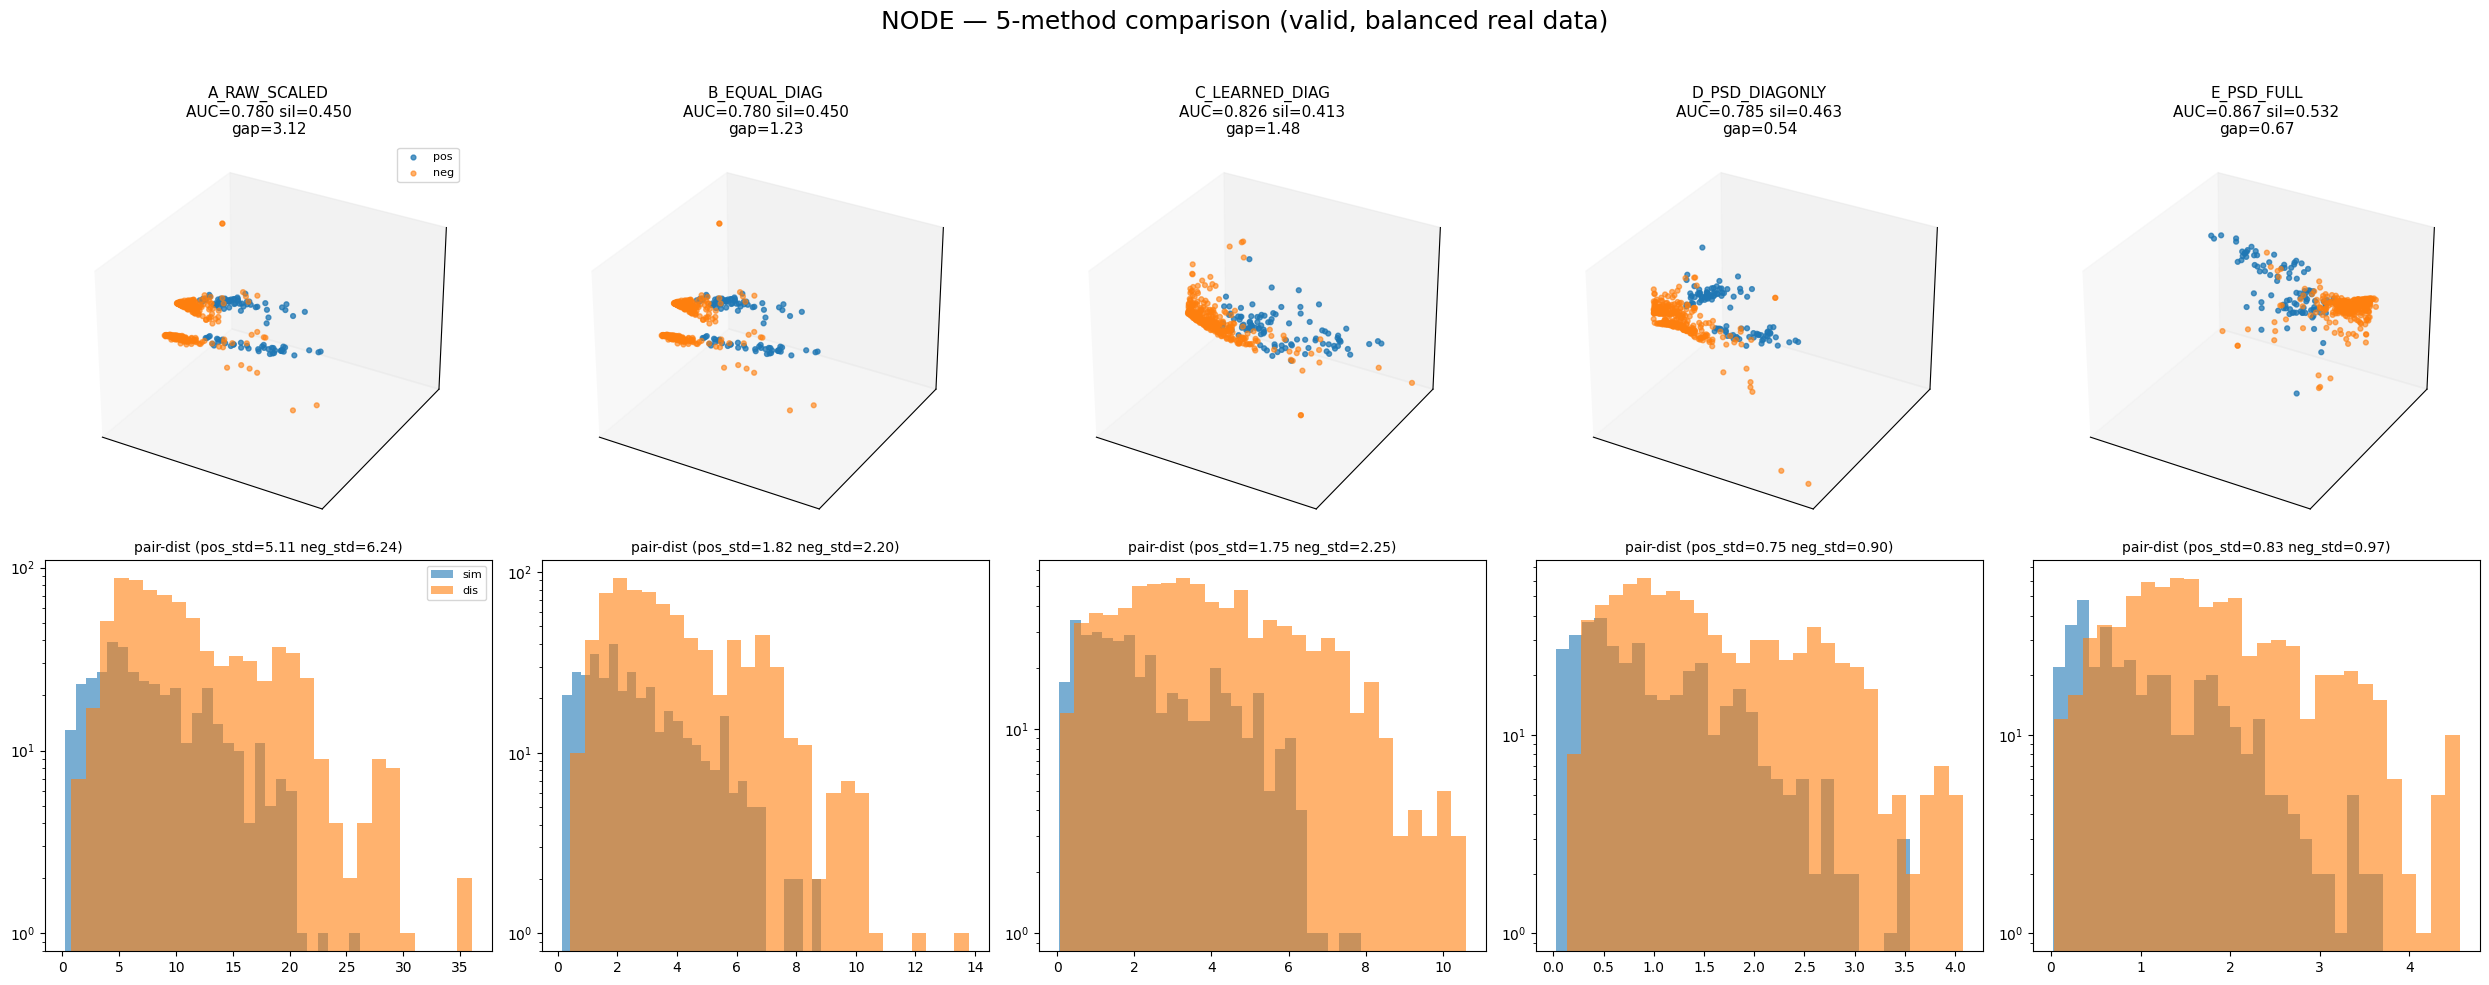

✅ saved: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/realdata_3d_method_compare_balanced/NODE_REALDATA_5METHOD_3D_COMPARE_BALANCED.png
PORT REAL-DATA 3D VIS (BALANCED)


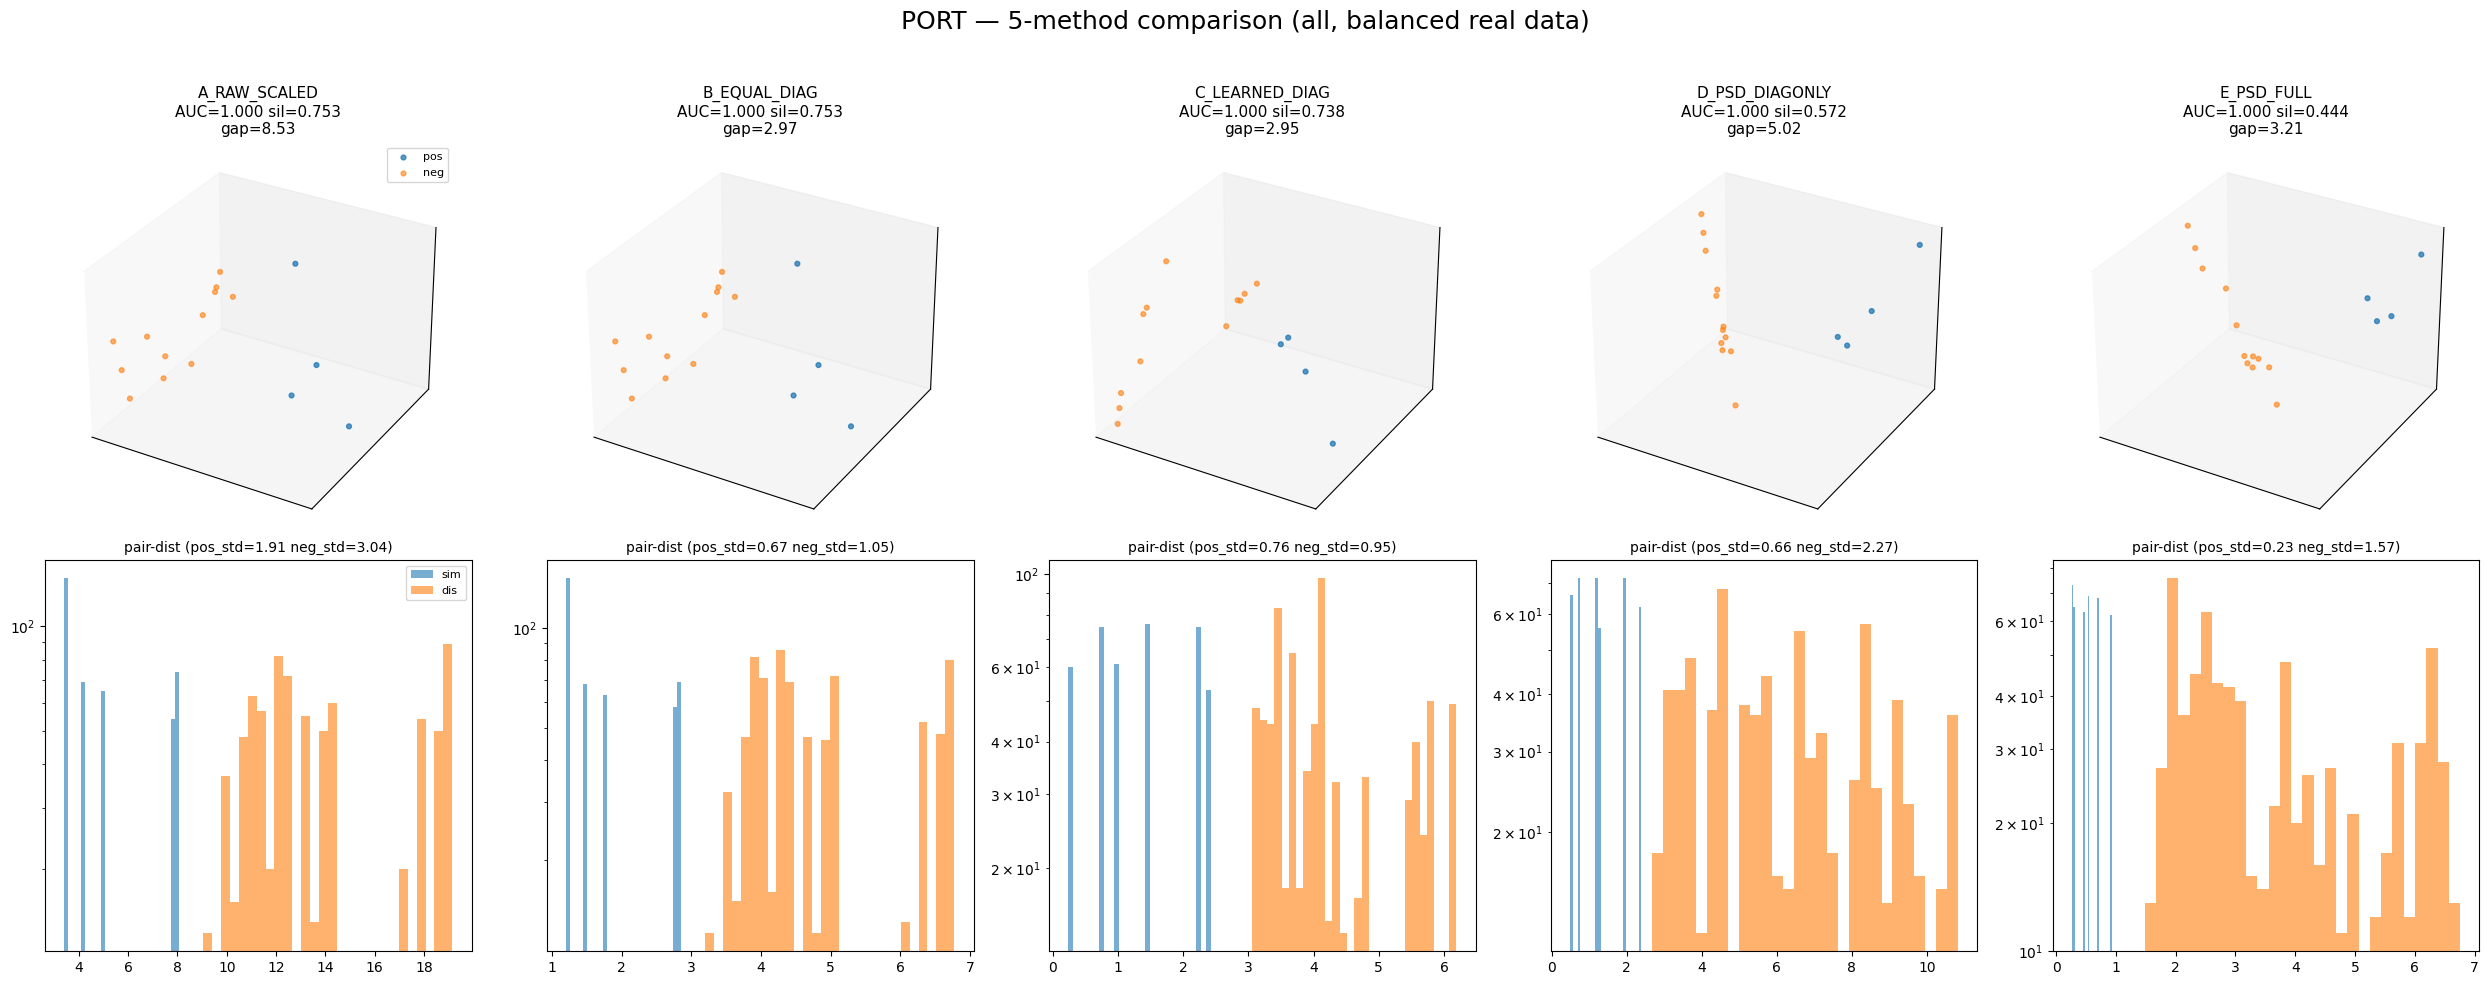

✅ saved: /Users/jojunho/Documents/4-1/졸업논문/매핑결과_rebuild/notebook_a_revised_labels_v1/realdata_3d_method_compare_balanced/PORT_REALDATA_5METHOD_3D_COMPARE_BALANCED.png
  level split_used          method  n_points_balanced  n_pos  n_neg  \
0  node      valid    A_RAW_SCALED                400    100    300   
1  node      valid    B_EQUAL_DIAG                400    100    300   
2  node      valid  C_LEARNED_DIAG                400    100    300   
3  node      valid  D_PSD_DIAGONLY                400    100    300   
4  node      valid      E_PSD_FULL                400    100    300   
5  port        all    A_RAW_SCALED                 16      4     12   
6  port        all    B_EQUAL_DIAG                 16      4     12   
7  port        all  C_LEARNED_DIAG                 16      4     12   
8  port        all  D_PSD_DIAGONLY                 16      4     12   
9  port        all      E_PSD_FULL                 16      4     12   

   auc_center_dist  silhouette  sim_mean_dist  dis_

In [51]:
# ============================================================
# BLOCK 8-G-ALT) REAL-DATA 3D VISUALIZATION (BALANCED VERSION)
# - node / port 둘 다 balanced subset 기반
# - port valid positive scarcity 대응
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

VIZ3D_OUT_DIR = OUTPUT_DIR / "realdata_3d_method_compare_balanced"
VIZ3D_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("VIZ3D_OUT_DIR =", VIZ3D_OUT_DIR)
print("=" * 80)

def _safe_df(name):
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        return globals()[name].copy()
    return None

def _safe_arr(name):
    if name in globals():
        return globals()[name]
    return None

def _normalize_basic(df):
    x = df.copy()
    for c in ["stg_ip", "level", "rw", "src_metric", "split"]:
        if c in x.columns:
            x[c] = x[c].astype(str).str.strip().str.lower()
    if "timestamp" in x.columns:
        x["timestamp"] = pd.to_datetime(x["timestamp"], errors="coerce")
    return x

def _find_diag_weight(level_name, feat_cols):
    d = len(feat_cols)
    candidate_names = ["w", "w_final", "best_w", "wl_w", "WL_w", "diag_w"] if level_name == "node" \
        else ["port_w", "PORT_w", "port_w_final", "PORT_WEIGHT_VEC"]

    for nm in candidate_names:
        if nm in globals():
            arr = np.array(globals()[nm], dtype=float).reshape(-1)
            if len(arr) == d and arr.sum() > 0:
                return arr / arr.sum()

    return np.ones(d, dtype=float) / d

def _get_psd_M_L(level_name, feat_cols):
    d = len(feat_cols)
    M = None
    L = None

    if level_name == "node":
        if "M_psd_final" in globals():
            M = np.array(globals()["M_psd_final"], dtype=float)
        if "L_psd_final" in globals():
            L = np.array(globals()["L_psd_final"], dtype=float)
    else:
        if "PORT_M_psd_final" in globals():
            M = np.array(globals()["PORT_M_psd_final"], dtype=float)
        if "PORT_L_psd_final" in globals():
            L = np.array(globals()["PORT_L_psd_final"], dtype=float)

    if M is None and L is not None:
        M = L @ L.T
    if L is None and M is not None:
        evals, evecs = np.linalg.eigh(M)
        evals = np.clip(evals, 0.0, None)
        L = evecs @ np.diag(np.sqrt(evals))

    if M is None or L is None:
        M = np.eye(d)
        L = np.eye(d)

    return M, L

def _prepare_vis_df_with_fallback(level_name):
    if level_name == "node":
        base_df = _safe_df("point_features_psd")
        pos_df = _safe_df("pos_samples")
        neg_df = _safe_df("neg_pool")
        feat_cols = list(_safe_arr("WL_FEATURE_COLS"))
        med = _safe_arr("psd_med")
        mad = _safe_arr("psd_mad")
        scale_func = globals().get("robust_scale_transform", None)
    else:
        base_df = _safe_df("port_point_score_psd")
        pos_df = _safe_df("port_pos_samples")
        neg_df = _safe_df("port_neg_pool")
        feat_cols = list(_safe_arr("PORT_WL_FEATURE_COLS"))
        med = _safe_arr("port_psd_med")
        mad = _safe_arr("port_psd_mad")
        scale_func = globals().get("_port_robust_scale_transform", None)

    if base_df is None or pos_df is None or neg_df is None:
        raise ValueError(f"missing base/pos/neg for {level_name}")

    base_df = _normalize_basic(base_df)
    pos_df = _normalize_basic(pos_df)
    neg_df = _normalize_basic(neg_df)

    # 1) valid 우선
    pos_ids = set(pos_df.loc[pos_df["split"] == "valid", "point_id"].tolist()) if "split" in pos_df.columns else set()
    neg_ids = set(neg_df.loc[neg_df["split"] == "valid", "point_id"].tolist()) if "split" in neg_df.columns else set()
    split_used = "valid"

    # 2) valid에 positive 거의 없으면 train+valid
    if len(pos_ids) < 10:
        pos_ids = set(pos_df.loc[pos_df["split"].isin(["train", "valid"]), "point_id"].tolist()) if "split" in pos_df.columns else set()
        neg_ids = set(neg_df.loc[neg_df["split"].isin(["train", "valid"]), "point_id"].tolist()) if "split" in neg_df.columns else set()
        split_used = "train+valid"

    # 3) 그래도 없으면 all
    if len(pos_ids) < 10:
        pos_ids = set(pos_df["point_id"].tolist())
        neg_ids = set(neg_df["point_id"].tolist())
        split_used = "all"

    vis_df = base_df[base_df["point_id"].isin(pos_ids | neg_ids)].copy()
    vis_df["y_vis"] = np.where(vis_df["point_id"].isin(pos_ids), 1, 0)

    scaled_cols = [f"scaled__{c}" for c in feat_cols]
    has_scaled = all(c in vis_df.columns for c in scaled_cols)

    if not has_scaled:
        if med is None or mad is None or scale_func is None:
            raise ValueError(f"missing scaling objects for {level_name}")
        Xraw = vis_df[feat_cols].fillna(0.0).copy()
        Xscaled = scale_func(Xraw, med, mad).fillna(0.0)
        for c in feat_cols:
            vis_df[f"scaled__{c}"] = Xscaled[c].values

    return vis_df, feat_cols, scaled_cols, split_used

def _balanced_subsample(vis_df, pos_mult=3, max_total=1200, seed=42):
    rng = np.random.default_rng(seed)

    pos = vis_df[vis_df["y_vis"] == 1].copy()
    neg = vis_df[vis_df["y_vis"] == 0].copy()

    n_pos = len(pos)
    n_neg = len(neg)

    if n_pos == 0 or n_neg == 0:
        return vis_df.copy()

    keep_pos = min(n_pos, max_total // 4 if max_total >= 4 else n_pos)
    pos = pos.sample(n=keep_pos, random_state=seed) if n_pos > keep_pos else pos

    keep_neg = min(len(neg), pos_mult * len(pos), max_total - len(pos))
    neg = neg.sample(n=keep_neg, random_state=seed) if len(neg) > keep_neg else neg

    out = pd.concat([pos, neg], ignore_index=True)
    out = out.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

def _build_method_embeddings(vis_df, feat_cols, scaled_cols, level_name):
    Xs = vis_df[scaled_cols].astype(float).values
    d = Xs.shape[1]

    w_equal = np.ones(d, dtype=float) / d
    w_diag = _find_diag_weight(level_name, feat_cols)
    M_psd, L_psd = _get_psd_M_L(level_name, feat_cols)
    M_diag_psd = np.diag(np.diag(M_psd))

    E_raw = Xs.copy()
    E_equal = Xs * np.sqrt(np.clip(w_equal, 1e-12, None))[None, :]
    E_diag = Xs * np.sqrt(np.clip(w_diag, 1e-12, None))[None, :]
    E_psd_diag = Xs * np.sqrt(np.clip(np.diag(M_diag_psd), 1e-12, None))[None, :]
    E_psd_full = Xs @ L_psd

    return {
        "A_RAW_SCALED": E_raw,
        "B_EQUAL_DIAG": E_equal,
        "C_LEARNED_DIAG": E_diag,
        "D_PSD_DIAGONLY": E_psd_diag,
        "E_PSD_FULL": E_psd_full,
    }

def _project_3d_balanced(E):
    if E.shape[1] >= 3:
        pca = PCA(n_components=3, random_state=42)
        Z = pca.fit_transform(E)
    elif E.shape[1] == 2:
        Z = np.column_stack([E, np.zeros(len(E))])
    elif E.shape[1] == 1:
        Z = np.column_stack([E[:, 0], np.zeros(len(E)), np.zeros(len(E))])
    else:
        raise ValueError("embedding dim = 0")
    return Z

def _sample_pair_dists(E, y, max_sim=400, max_dis=800, seed=42):
    rng = np.random.default_rng(seed)
    pos_idx = np.where(y == 1)[0]
    neg_idx = np.where(y == 0)[0]

    sim_d, dis_d = [], []

    if len(pos_idx) >= 2:
        for _ in range(max_sim * 5):
            i, j = rng.choice(pos_idx, size=2, replace=False)
            sim_d.append(np.linalg.norm(E[i] - E[j]))
            if len(sim_d) >= max_sim:
                break

    if len(pos_idx) >= 1 and len(neg_idx) >= 1:
        for _ in range(max_dis * 5):
            i = rng.choice(pos_idx)
            j = rng.choice(neg_idx)
            dis_d.append(np.linalg.norm(E[i] - E[j]))
            if len(dis_d) >= max_dis:
                break

    return np.array(sim_d, dtype=float), np.array(dis_d, dtype=float)

def _simple_auc_from_center_distance(E, y):
    try:
        from sklearn.metrics import roc_auc_score
    except Exception:
        return np.nan
    if len(np.unique(y)) < 2:
        return np.nan
    pos = E[y == 1]
    if len(pos) == 0:
        return np.nan
    center = np.median(pos, axis=0)
    dist = np.linalg.norm(E - center[None, :], axis=1)
    try:
        return float(roc_auc_score(y, -dist))
    except Exception:
        return np.nan

def _silhouette_like(E, y):
    try:
        from sklearn.metrics import silhouette_score
        if len(np.unique(y)) < 2:
            return np.nan
        return float(silhouette_score(E, y))
    except Exception:
        return np.nan

def _draw_one_level_figure(level_name, vis_df, emb_dict, split_used, out_dir):
    y = vis_df["y_vis"].astype(int).values
    method_names = list(emb_dict.keys())
    n = len(method_names)

    fig = plt.figure(figsize=(5 * n, 10))
    fig.suptitle(
        f"{level_name.upper()} — 5-method comparison ({split_used}, balanced real data)",
        fontsize=18, y=0.98
    )

    for i, mname in enumerate(method_names):
        E = emb_dict[mname]
        Z3 = _project_3d_balanced(E)
        sim_d, dis_d = _sample_pair_dists(E, y, max_sim=400, max_dis=800, seed=42+i)

        auc = _simple_auc_from_center_distance(E, y)
        sil = _silhouette_like(E, y)
        gap = float(np.nanmean(dis_d) - np.nanmean(sim_d)) if len(sim_d) and len(dis_d) else np.nan

        ax = fig.add_subplot(2, n, i + 1, projection="3d")
        pos = Z3[y == 1]
        neg = Z3[y == 0]

        if len(pos):
            ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], s=12, alpha=0.75, label="pos")
        if len(neg):
            ax.scatter(neg[:, 0], neg[:, 1], neg[:, 2], s=12, alpha=0.60, label="neg")

        ax.set_title(f"{mname}\nAUC={auc:.3f} sil={sil:.3f}\ngap={gap:.2f}", fontsize=11)
        ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
        if i == 0:
            ax.legend(loc="upper right", fontsize=8)

        ax2 = fig.add_subplot(2, n, n + i + 1)
        if len(sim_d):
            ax2.hist(sim_d, bins=28, alpha=0.6, label="sim")
        if len(dis_d):
            ax2.hist(dis_d, bins=28, alpha=0.6, label="dis")
        ax2.set_yscale("log")
        ax2.set_title(
            f"pair-dist (pos_std={np.std(sim_d):.2f} neg_std={np.std(dis_d):.2f})",
            fontsize=10
        )
        if i == 0:
            ax2.legend(fontsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    out_path = out_dir / f"{level_name.upper()}_REALDATA_5METHOD_3D_COMPARE_BALANCED.png"
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("✅ saved:", out_path)

# ------------------------------
# node
# ------------------------------
print("=" * 80)
print("NODE REAL-DATA 3D VIS (BALANCED)")
print("=" * 80)

node_vis_df, node_feat_cols, node_scaled_cols, node_split_used = _prepare_vis_df_with_fallback("node")
node_vis_df_bal = _balanced_subsample(node_vis_df, pos_mult=3, max_total=1200, seed=42)
node_emb_dict = _build_method_embeddings(node_vis_df_bal, node_feat_cols, node_scaled_cols, "node")
_draw_one_level_figure("node", node_vis_df_bal, node_emb_dict, node_split_used, VIZ3D_OUT_DIR)

# ------------------------------
# port
# ------------------------------
print("=" * 80)
print("PORT REAL-DATA 3D VIS (BALANCED)")
print("=" * 80)

port_vis_df, port_feat_cols, port_scaled_cols, port_split_used = _prepare_vis_df_with_fallback("port")
port_vis_df_bal = _balanced_subsample(port_vis_df, pos_mult=3, max_total=1200, seed=42)
port_emb_dict = _build_method_embeddings(port_vis_df_bal, port_feat_cols, port_scaled_cols, "port")
_draw_one_level_figure("port", port_vis_df_bal, port_emb_dict, port_split_used, VIZ3D_OUT_DIR)

# compact summary
summary_rows = []
for level_name, vis_df_bal, emb_dict, split_used in [
    ("node", node_vis_df_bal, node_emb_dict, node_split_used),
    ("port", port_vis_df_bal, port_emb_dict, port_split_used),
]:
    y = vis_df_bal["y_vis"].astype(int).values
    for mname, E in emb_dict.items():
        sim_d, dis_d = _sample_pair_dists(E, y, max_sim=400, max_dis=800, seed=42)
        summary_rows.append({
            "level": level_name,
            "split_used": split_used,
            "method": mname,
            "n_points_balanced": int(len(vis_df_bal)),
            "n_pos": int((y == 1).sum()),
            "n_neg": int((y == 0).sum()),
            "auc_center_dist": _simple_auc_from_center_distance(E, y),
            "silhouette": _silhouette_like(E, y),
            "sim_mean_dist": float(np.mean(sim_d)) if len(sim_d) else np.nan,
            "dis_mean_dist": float(np.mean(dis_d)) if len(dis_d) else np.nan,
            "gap_dis_minus_sim": float(np.mean(dis_d) - np.mean(sim_d)) if len(sim_d) and len(dis_d) else np.nan,
        })

realdata_3d_summary_bal = pd.DataFrame(summary_rows)
realdata_3d_summary_bal.to_csv(VIZ3D_OUT_DIR / "REALDATA_3D_METHOD_SUMMARY_BALANCED.csv", index=False, encoding="utf-8-sig")
realdata_3d_summary_bal.to_excel(VIZ3D_OUT_DIR / "REALDATA_3D_METHOD_SUMMARY_BALANCED.xlsx", index=False)

print(realdata_3d_summary_bal)
print("✅ saved:", VIZ3D_OUT_DIR / "REALDATA_3D_METHOD_SUMMARY_BALANCED.xlsx")